In [1]:
%matplotlib inline

import io

from pathlib import Path
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipywidgets as widgets

from IPython.display import (
    display,
    clear_output
)

from scipy.optimize import (
    fsolve,
    least_squares
)
import tkinter as tk

from tkinter import filedialog
from scipy.interpolate import PchipInterpolator

from scipy.ndimage import gaussian_filter1d
from numba import njit
ITC_EVAL_COUNT = 0
NMR_EVAL_COUNT = 0

In [2]:
# ============================================================
# CONSTANTS
# ============================================================

Kw = 1e-14

USE_DH = True
FAST_CALIBRATION = True

# ============================================================
# DEFAULT PARAMETERS
# ============================================================

params = {

    "pKa_alpha": 8.95,
    "pKa_eps": 10.53,
    "pKa_cooh": 2.18,

    "pKa1": 6.351,
    "pKa2": 10.329,

    "logK10_alpha": -4.5,
    "logK10_eps": -3.5,

    "logK_double": 0.5,

    "use_alpha": True,
    "use_eps": True
}

# ============================================================
# GLOBAL HOLDERS
# ============================================================

naoh_conc_spline = None

pH_axis = None
Na_axis = None

LAST_I = 0.0

# ============================================================
# CALIBRATION CACHE
# ============================================================

LAST_NAOH_CALIBRATION_KEY = None

# ============================================================
# DAVIES ACTIVITY MODEL
# ============================================================

@njit(cache=True)
def gamma_DH(z, I):

    if (not USE_DH) or (z == 0):

        return 1.0

    I = min(max(I,1e-8),1.0)

    sqrtI = np.sqrt(I)

    log10_gamma = (

        -0.509 * z**2 *

        (
            sqrtI/(1.0 + sqrtI)
            -
            0.3*I
        )
    )

    log10_gamma = min(
        max(log10_gamma,-2.0),
        0.0
    )

    return 10.0**log10_gamma

# ============================================================
# CARBONATE SPECIATION
# ============================================================

@njit(cache=True)
def carbonate_species(

    H,
    OH,
    CT,
    I,

    pKa1,
    pKa2
):

    gH    = gamma_DH(+1, I)
    gHCO3 = gamma_DH(-1, I)
    gCO3  = gamma_DH(-2, I)

    Ka1 = 10.0**(-pKa1)
    Ka2 = 10.0**(-pKa2)

    beta0 = 1.0

    beta1 = (

        Ka1 /

        max(
            H * gH * gHCO3,
            1e-30
        )
    )

    beta2 = (

        Ka1 * Ka2 /

        max(
            H**2 * gH**2 * gCO3,
            1e-30
        )
    )

    denom = max(
        beta0 + beta1 + beta2,
        1e-30
    )

    CO2  = CT * beta0 / denom
    HCO3 = CT * beta1 / denom
    CO3  = CT * beta2 / denom

    return CO2,HCO3,CO3

# ============================================================
# AMINE SPECIATION
# ============================================================
# ============================================================
# FULL MOLECULAR PARTITION-FUNCTION AMINE MODEL
# IDENTICAL TO MAIN SOLVER
# ============================================================

@njit(cache=True)
def amine_speciation(

    H,
    CO2,
    AA_tot,
    I,

    pKa_alpha,
    pKa_eps,
    pKa_cooh,

    logK10_alpha,
    logK10_eps,
    logK_double,

    use_alpha,
    use_eps
):

    # ========================================================
    # activity coefficients
    # ========================================================

    gH    = gamma_DH(+1, I)
    gNH3  = gamma_DH(+1, I)
    gCarb = gamma_DH(-1, I)
    gCOO  = gamma_DH(-1, I)

    # ========================================================
    # equilibrium constants
    # ========================================================

    Ka_a  = 10.0**(-pKa_alpha)
    Ka_e  = 10.0**(-pKa_eps)
    Ka_co = 10.0**(-pKa_cooh)

    Kca = 10.0**(logK10_alpha)
    Kce = 10.0**(logK10_eps)

    if use_alpha and use_eps:

        Kd = 10.0**(logK_double)

    else:

        Kd = 0.0

    # ========================================================
    # statistical weights
    # ========================================================

    if use_alpha:

        A_a = (
            (H * gH * gNH3) /
            max(Ka_a,1e-30)
        )

    else:

        A_a = 0.0

    if use_eps:

        A_e = (
            (H * gH * gNH3) /
            max(Ka_e,1e-30)
        )

    else:

        A_e = 0.0

    if use_alpha:

        B_a = (
            (Kca * CO2) /
            max(H * gH * gCarb,1e-30)
        )

    else:

        B_a = 0.0

    if use_eps:

        B_e = (
            (Kce * CO2) /
            max(H * gH * gCarb,1e-30)
        )

    else:

        B_e = 0.0

    # ========================================================
    # microstates
    # ========================================================

    w_L      = 1.0

    w_HaL    = A_a
    w_HeL    = A_e
    w_H2L    = A_a * A_e

    w_Ca     = B_a
    w_Ce     = B_e

    w_CaHeL  = B_a * A_e
    w_HaCeL  = A_a * B_e

    w_Cae    = Kd * B_a * B_e

    # ========================================================
    # partition function
    # ========================================================

    Z = max(

        w_L +

        w_HaL +
        w_HeL +
        w_H2L +

        w_Ca +
        w_Ce +

        w_CaHeL +
        w_HaCeL +

        w_Cae,

        1e-30
    )

    # ========================================================
    # populations
    # ========================================================

    L      = AA_tot * w_L     / Z

    HaL    = AA_tot * w_HaL   / Z
    HeL    = AA_tot * w_HeL   / Z
    H2L    = AA_tot * w_H2L   / Z

    Ca     = AA_tot * w_Ca    / Z
    Ce     = AA_tot * w_Ce    / Z

    CaHeL  = AA_tot * w_CaHeL / Z
    HaCeL  = AA_tot * w_HaCeL / Z

    Cae    = AA_tot * w_Cae   / Z

    # ========================================================
    # carboxylate
    # ========================================================

    A_coo = (
        Ka_co /
        max(H * gH * gCOO,1e-30)
    )

    Z_back = 1.0 + A_coo

    COO = AA_tot * (A_coo / Z_back)

    # ========================================================
    # grouped observables
    # ========================================================

    carb_total = (

        Ca +
        Ce +

        CaHeL +
        HaCeL +

        2.0 * Cae
    )

    # ========================================================
    # exact charge accounting
    # ========================================================

    amine_charge = (

        + HaL
        + HeL

        + 2.0 * H2L

        - Ca
        - Ce

        - 2.0 * Cae
    )

    AA_charge = (
        amine_charge
        - COO
    )

    # ========================================================
    # ionic strength
    # ========================================================

    I_amines = 0.5 * (

        1.0 * HaL +
        1.0 * HeL +

        4.0 * H2L +

        1.0 * Ca +
        1.0 * Ce +

        4.0 * Cae +

        1.0 * COO
    )

    return (

        carb_total,

        AA_charge,

        I_amines
    )

# ============================================================
# FULL EQUILIBRIUM
# ============================================================
# ============================================================
# FULL THERMODYNAMIC EQUILIBRIUM
# IDENTICAL TO MAIN SOLVER
# ============================================================

@njit(cache=True)
def equilibrium(

    vars,
    CO2_tot,
    AA_tot,
    Na,
    Cl,

    pKa1,
    pKa2,

    pKa_alpha,
    pKa_eps,
    pKa_cooh,

    logK10_alpha,
    logK10_eps,
    logK_double,

    use_alpha,
    use_eps
):

    logH = vars[0]

    if logH < -14.0:
        logH = -14.0

    if logH > 0.0:
        logH = 0.0

    H = max(
        10.0**logH,
        1e-30
    )

    # ========================================================
    # initial ionic strength
    # ========================================================

    I = 0.5 * (Na + Cl + 1e-7)

    I = min(max(I,1e-8),5.0)

    # ========================================================
    # self-consistent iteration
    # ========================================================

    for _ in range(10):

        I = min(max(I,1e-8),5.0)

        gH  = gamma_DH(+1, I)
        gOH = gamma_DH(-1, I)

        logOH = (

            np.log10(Kw)

            -

            np.log10(max(H,1e-30))

            -

            np.log10(max(gH * gOH,1e-30))
        )

        OH = 10.0**logOH

        # ----------------------------------------------------
        # carbonate / carbamate coupling
        # ----------------------------------------------------

        if AA_tot <= 1e-25:

            CO2,HCO3,CO3 = carbonate_species(

                H,
                OH,
                CO2_tot,
                I,

                pKa1,
                pKa2
            )

            carb_total = 0.0

            AA_charge = 0.0

            I_amines = 0.0

        else:

            # ------------------------------------------------
            # initialize from total carbon
            # ------------------------------------------------

            CT_free = max(CO2_tot,1e-30)

            CO2_old  = 0.0
            carb_old = 0.0

            # ------------------------------------------------
            # fast self-consistent loop
            # ------------------------------------------------

            for inner in range(20):

                # --------------------------------------------
                # carbonate partition
                # --------------------------------------------

                CO2,HCO3,CO3 = carbonate_species(

                    H,
                    OH,
                    CT_free,
                    I,

                    pKa1,
                    pKa2
                )

                # --------------------------------------------
                # amine partition
                # --------------------------------------------

                (
                    carb_total,
                    AA_charge,
                    I_amines

                ) = amine_speciation(

                    H,
                    CO2,
                    AA_tot,
                    I,

                    pKa_alpha,
                    pKa_eps,
                    pKa_cooh,

                    logK10_alpha,
                    logK10_eps,
                    logK_double,

                    use_alpha,
                    use_eps
                )

                carb = carb_total

                # --------------------------------------------
                # update free inorganic carbon
                # --------------------------------------------

                CT_free_new = max(
                    CO2_tot - carb,
                    1e-30
                )

                # --------------------------------------------
                # convergence
                # --------------------------------------------

                err = max(

                    abs(CO2 - CO2_old),

                    abs(carb - carb_old),

                    abs(CT_free_new - CT_free)
                )

                if err < 1e-9:

                    CT_free = CT_free_new
                    break

                # --------------------------------------------
                # adaptive damping
                # --------------------------------------------

                if err > 1e-3:

                    mix = 0.2

                else:

                    mix = 0.5

                CT_free = (

                    (1.0 - mix)*CT_free
                    +
                    mix*CT_free_new
                )

                CO2_old  = CO2
                carb_old = carb

        # ----------------------------------------------------
        # ionic strength update
        # ----------------------------------------------------

        I_new = 0.5 * (

            H +
            OH +

            HCO3 +
            4.0 * CO3 +

            Na +
            Cl +

            2.0 * I_amines
        )

        I_new = min(max(I_new,1e-8),2.0)

        if abs(I_new - I) < 1e-12:

            I = I_new
            break

        I = 0.5 * (I + I_new)

    # ========================================================
    # recompute OH using converged ionic strength
    # ========================================================
    I = min(max(I,1e-8),2.0)
    
    gH  = gamma_DH(+1, I)
    gOH = gamma_DH(-1, I)

    logOH = (

        np.log10(Kw)

        -

        np.log10(max(H,1e-30))

        -

        np.log10(max(gH * gOH,1e-30))
    )

    OH = 10.0**logOH

    # ========================================================
    # charge balance
    # ========================================================

    charge_balance = (

        H +
        Na +

        AA_charge

        -

        OH
        -
        HCO3
        -
        2.0 * CO3
        -
        Cl
    )

    return charge_balance
# ============================================================
# BUILD STABLE NaOH CALIBRATION
# ============================================================

def build_naoh_calibration(

    params,
    CO2_tot,
    AA_tot,

    Cl=0.0,

    Na_min=1e-12,
    Na_max=5.0,

    resolution = (
        150
        if FAST_CALIBRATION
        else 400
    ),

    verbose=False
):

    global LAST_NAOH_CALIBRATION_KEY
    global naoh_conc_spline
    global pH_axis
    global Na_axis

    # ========================================================
    # cache key
    # ONLY acid-base parameters
    # ========================================================
    
    key = (
    
        CO2_tot,
        AA_tot,
        Cl,
    
        round(params["pKa_alpha"], 2),
        round(params["pKa_eps"], 2),
        round(params["pKa_cooh"], 1),
        
        round(params["pKa1"], 2),
        round(params["pKa2"], 2),
    
        params["use_alpha"],
        params["use_eps"],
    
        USE_DH
    )

    if key == LAST_NAOH_CALIBRATION_KEY:

        return

    LAST_NAOH_CALIBRATION_KEY = key

    # ========================================================
    # Na sweep
    # ========================================================

    Na_grid = np.logspace(

        np.log10(Na_min),
        np.log10(Na_max),

        resolution
    )

    pH_values = np.full_like(
        Na_grid,
        np.nan
    )

    # continuation initial guess

    logH_guess = -7.0

    for i,Na in enumerate(Na_grid):

        sol,info,ier,msg = fsolve(

            equilibrium,

            [logH_guess],

            args=(
            
                CO2_tot,
                AA_tot,
                Na,
                Cl,
            
                params["pKa1"],
                params["pKa2"],
            
                params["pKa_alpha"],
                params["pKa_eps"],
                params["pKa_cooh"],
            
                params["logK10_alpha"],
                params["logK10_eps"],
                params["logK_double"],
            
                params["use_alpha"],
                params["use_eps"]
            ),

            full_output=True,

            xtol=1e-12,
            maxfev=10000
        )

        if ier != 1:

            if verbose:

                print(
                    f"FAILED: "
                    f"Na={Na:.3e}"
                )

            continue

        logH = float(sol[0])

        pH_values[i] = -logH

        # continuation

        logH_guess = logH

        if verbose and (i % 20 == 0):

            print(

                f"{i:4d}   "

                f"Na={Na:.3e}   "

                f"pH={pH_values[i]:.4f}"
            )

    # ========================================================
    # remove failed points
    # ========================================================

    mask = np.isfinite(pH_values)

    Na_grid = Na_grid[mask]
    pH_values = pH_values[mask]

    # ========================================================
    # sort
    # ========================================================

    order = np.argsort(pH_values)

    pH_values = pH_values[order]
    Na_grid   = Na_grid[order]

    # ========================================================
    # remove duplicates
    # ========================================================

    unique_mask = np.diff(

        pH_values,

        prepend=-999

    ) > 1e-6

    pH_values = pH_values[unique_mask]
    Na_grid   = Na_grid[unique_mask]

    # ========================================================
    # spline
    # ========================================================

    naoh_conc_spline = PchipInterpolator(

        pH_values,
        Na_grid,

        extrapolate=True
    )

    pH_axis = pH_values
    Na_axis = Na_grid
# ============================================================
# QUERY FUNCTION
# ============================================================

def naoh_required(pH):

    if naoh_conc_spline is None:

        raise RuntimeError(
            "Calibration not built"
        )

    return max(

        float(
            naoh_conc_spline(pH)
        ),

        0.0
    )

# ============================================================
# VALIDATION
# ============================================================

def validate_calibration(

    pH_target,

    params,

    CO2_tot,

    AA_tot,

    Cl = 0.0
):

    Na = naoh_required(
        pH_target
    )

    sol = fsolve(

        equilibrium,

        [-pH_target],

        args=(
        
            CO2_tot,
            AA_tot,
            Na,
            Cl,
        
            params["pKa1"],
            params["pKa2"],
        
            params["pKa_alpha"],
            params["pKa_eps"],
            params["pKa_cooh"],
        
            params["logK10_alpha"],
            params["logK10_eps"],
            params["logK_double"],
        
            params["use_alpha"],
            params["use_eps"]
        ),

        xtol   = 1e-12,
        maxfev = 10000
    )

    logH = float(sol[0])

    recovered_pH = -logH

    print("="*60)

    print(
        f"Target pH    : "
        f"{pH_target:.4f}"
    )

    print(
        f"Recovered pH : "
        f"{recovered_pH:.4f}"
    )

    print(
        f"Na required  : "
        f"{Na:.6e} M"
    )

    print(
        f"ΔpH          : "
        f"{recovered_pH - pH_target:+.6f}"
    )

    print("="*60)

# ============================================================
# PLOT
# ============================================================

def plot_calibration():

    plt.figure(figsize=(6,4))

    plt.plot(

        pH_axis,

        Na_axis,

        lw=2
    )

    plt.xlabel("pH")

    plt.ylabel(
        "[Na+] required (M)"
    )

    plt.title(
        "Consistent NaOH Calibration"
    )

    plt.grid(True)

    plt.show()

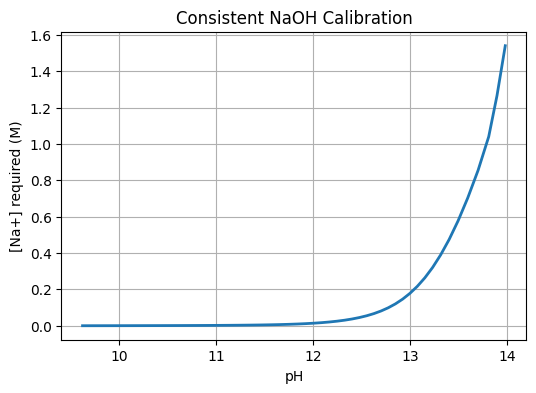

Target pH    : 11.0000
Recovered pH : 11.0000
Na required  : 1.864411e-03 M
ΔpH          : +0.000029


In [3]:
# ============================================================
# CONFIRM NaOH CALIBRATION
# ============================================================

build_naoh_calibration(

    params  = params,

    CO2_tot = 0.0,

    AA_tot  = 1e-3,
)

plot_calibration()

validate_calibration(

    pH_target = 11.0,

    params    = params,

    CO2_tot   = 0.0,

    AA_tot    = 1e-3
)

In [4]:
# ============================================================
# HCl CALIBRATION + EQUILIBRIUM SOLVER
# ============================================================
# ============================================================
# CONSTANTS
# ============================================================

Kw = 1e-14

USE_DH = True

# ============================================================
# DEFAULT PARAMETERS
# ============================================================

params = {

    "pKa_alpha": 8.95,
    "pKa_eps": 10.53,
    "pKa_cooh": 2.18,

    "pKa1": 6.351,
    "pKa2": 10.329,

    "logK10_alpha": -4.5,
    "logK10_eps": -3.5,

    "logK_double": 0.5,

    "use_alpha": True,
    "use_eps": True
}

# ============================================================
# GLOBAL HOLDERS
# ============================================================

hcl_conc_spline = None

pH_axis = None
Cl_axis = None

LAST_I = 0.0

# ============================================================
# CALIBRATION CACHE
# ============================================================

LAST_HCL_CALIBRATION_KEY = None

# ============================================================
# DAVIES ACTIVITY MODEL
# ============================================================

@njit(cache=True)
def gamma_DH(z, I):

    if (not USE_DH) or (z == 0):

        return 1.0

    I = min(max(I,1e-8),1.0)

    sqrtI = np.sqrt(I)

    log10_gamma = (

        -0.509 * z**2 *

        (
            sqrtI/(1.0 + sqrtI)
            -
            0.3*I
        )
    )

    log10_gamma = min(
        max(log10_gamma,-2.0),
        0.0
    )

    return 10.0**log10_gamma

# ============================================================
# CARBONATE SPECIATION
# ============================================================

@njit(cache=True)
def carbonate_species(

    H,
    OH,
    CT,
    I,

    pKa1,
    pKa2
):

    gH    = gamma_DH(+1, I)
    gHCO3 = gamma_DH(-1, I)
    gCO3  = gamma_DH(-2, I)

    Ka1 = 10.0**(-pKa1)
    Ka2 = 10.0**(-pKa2)

    beta0 = 1.0

    beta1 = (

        Ka1 /

        max(
            H * gH * gHCO3,
            1e-30
        )
    )

    beta2 = (

        Ka1 * Ka2 /

        max(
            H**2 * gH**2 * gCO3,
            1e-30
        )
    )

    denom = max(
        beta0 + beta1 + beta2,
        1e-30
    )

    CO2  = CT * beta0 / denom
    HCO3 = CT * beta1 / denom
    CO3  = CT * beta2 / denom

    return CO2,HCO3,CO3

# ============================================================
# FULL MOLECULAR PARTITION-FUNCTION AMINE MODEL
# ============================================================

@njit(cache=True)
def amine_speciation(

    H,
    CO2,
    AA_tot,
    I,

    pKa_alpha,
    pKa_eps,
    pKa_cooh,

    logK10_alpha,
    logK10_eps,
    logK_double,

    use_alpha,
    use_eps
):

    # ========================================================
    # activity coefficients
    # ========================================================

    gH    = gamma_DH(+1, I)
    gNH3  = gamma_DH(+1, I)
    gCarb = gamma_DH(-1, I)
    gCOO  = gamma_DH(-1, I)

    # ========================================================
    # equilibrium constants
    # ========================================================

    Ka_a  = 10.0**(-pKa_alpha)
    Ka_e  = 10.0**(-pKa_eps)
    Ka_co = 10.0**(-pKa_cooh)

    Kca = 10.0**(logK10_alpha)
    Kce = 10.0**(logK10_eps)

    if use_alpha and use_eps:

        Kd = 10.0**(logK_double)

    else:

        Kd = 0.0

    # ========================================================
    # statistical weights
    # ========================================================

    if use_alpha:

        A_a = (
            (H * gH * gNH3)
            /
            max(Ka_a,1e-30)
        )

    else:

        A_a = 0.0

    if use_eps:

        A_e = (
            (H * gH * gNH3)
            /
            max(Ka_e,1e-30)
        )

    else:

        A_e = 0.0

    if use_alpha:

        B_a = (
            (Kca * CO2)
            /
            max(H * gH * gCarb,1e-30)
        )

    else:

        B_a = 0.0

    if use_eps:

        B_e = (
            (Kce * CO2)
            /
            max(H * gH * gCarb,1e-30)
        )

    else:

        B_e = 0.0

    # ========================================================
    # microstates
    # ========================================================

    w_L      = 1.0

    w_HaL    = A_a
    w_HeL    = A_e
    w_H2L    = A_a * A_e

    w_Ca     = B_a
    w_Ce     = B_e

    w_CaHeL  = B_a * A_e
    w_HaCeL  = A_a * B_e

    w_Cae    = Kd * B_a * B_e

    # ========================================================
    # partition function
    # ========================================================

    Z = max(

        w_L +

        w_HaL +
        w_HeL +
        w_H2L +

        w_Ca +
        w_Ce +

        w_CaHeL +
        w_HaCeL +

        w_Cae,

        1e-30
    )

    # ========================================================
    # populations
    # ========================================================

    HaL    = AA_tot * w_HaL   / Z
    HeL    = AA_tot * w_HeL   / Z
    H2L    = AA_tot * w_H2L   / Z

    Ca     = AA_tot * w_Ca    / Z
    Ce     = AA_tot * w_Ce    / Z

    CaHeL  = AA_tot * w_CaHeL / Z
    HaCeL  = AA_tot * w_HaCeL / Z

    Cae    = AA_tot * w_Cae   / Z

    # ========================================================
    # carboxylate
    # ========================================================

    A_coo = (
        Ka_co /
        max(H * gH * gCOO,1e-30)
    )

    Z_back = 1.0 + A_coo

    COO = AA_tot * (A_coo / Z_back)

    # ========================================================
    # grouped observables
    # ========================================================

    carb_total = (

        Ca +
        Ce +

        CaHeL +
        HaCeL +

        2.0 * Cae
    )

    # ========================================================
    # exact charge accounting
    # ========================================================

    amine_charge = (

        + HaL
        + HeL

        + 2.0 * H2L

        - Ca
        - Ce

        - 2.0 * Cae
    )

    AA_charge = (
        amine_charge
        - COO
    )

    # ========================================================
    # ionic strength
    # ========================================================

    I_amines = 0.5 * (

        1.0 * HaL +
        1.0 * HeL +

        4.0 * H2L +

        1.0 * Ca +
        1.0 * Ce +

        4.0 * Cae +

        1.0 * COO
    )

    return (

        carb_total,

        AA_charge,

        I_amines
    )

# ============================================================
# FULL THERMODYNAMIC EQUILIBRIUM
# ============================================================

@njit(cache=True)
def equilibrium(

    vars,
    CO2_tot,
    AA_tot,
    Na,
    Cl,

    pKa1,
    pKa2,

    pKa_alpha,
    pKa_eps,
    pKa_cooh,

    logK10_alpha,
    logK10_eps,
    logK_double,

    use_alpha,
    use_eps
):

    logH = vars[0]

    if logH < -14.0:
        logH = -14.0

    if logH > 0.0:
        logH = 0.0

    H = max(
        10.0**logH,
        1e-30
    )

    # ========================================================
    # initial ionic strength
    # ========================================================

    I = 0.5 * (Cl + 1e-7)

    I = min(max(I,1e-8),5.0)

    # ========================================================
    # self-consistent iteration
    # ========================================================

    for _ in range(10):

        I = min(max(I,1e-8),5.0)

        gH  = gamma_DH(+1, I)
        gOH = gamma_DH(-1, I)

        logOH = (

            np.log10(Kw)

            -

            np.log10(max(H,1e-30))

            -

            np.log10(max(gH * gOH,1e-30))
        )

        OH = 10.0**logOH

        # ----------------------------------------------------
        # carbonate / carbamate coupling
        # ----------------------------------------------------

        if AA_tot <= 1e-25:

            CO2,HCO3,CO3 = carbonate_species(

                H,
                OH,
                CO2_tot,
                I,

                pKa1,
                pKa2
            )

            carb_total = 0.0
            AA_charge = 0.0
            I_amines = 0.0

        else:

            CT_free = max(CO2_tot,1e-30)

            CO2_old  = 0.0
            carb_old = 0.0

            for inner in range(20):

                CO2,HCO3,CO3 = carbonate_species(

                    H,
                    OH,
                    CT_free,
                    I,

                    pKa1,
                    pKa2
                )

                (
                    carb_total,
                    AA_charge,
                    I_amines

                ) = amine_speciation(

                    H,
                    CO2,
                    AA_tot,
                    I,

                    pKa_alpha,
                    pKa_eps,
                    pKa_cooh,

                    logK10_alpha,
                    logK10_eps,
                    logK_double,

                    use_alpha,
                    use_eps
                )

                carb = carb_total

                CT_free_new = max(
                    CO2_tot - carb,
                    1e-30
                )

                err = max(

                    abs(CO2 - CO2_old),

                    abs(carb - carb_old),

                    abs(CT_free_new - CT_free)
                )

                if err < 1e-9:

                    CT_free = CT_free_new
                    break

                if err > 1e-3:

                    mix = 0.2

                else:

                    mix = 0.5

                CT_free = (

                    (1.0 - mix)*CT_free
                    +
                    mix*CT_free_new
                )

                CO2_old  = CO2
                carb_old = carb

        # ----------------------------------------------------
        # ionic strength update
        # ----------------------------------------------------

        I_new = 0.5 * (

            H +
            OH +

            HCO3 +
            4.0 * CO3 +

            Na +
            Cl +

            2.0 * I_amines
        )

        I_new = min(max(I_new,1e-8),2.0)

        if abs(I_new - I) < 1e-12:

            I = I_new
            break

        I = 0.5 * (I + I_new)

    # ========================================================
    # recompute OH using converged ionic strength
    # ========================================================

    I = min(max(I,1e-8),2.0)

    gH  = gamma_DH(+1, I)
    gOH = gamma_DH(-1, I)

    logOH = (

        np.log10(Kw)

        -

        np.log10(max(H,1e-30))

        -

        np.log10(max(gH * gOH,1e-30))
    )

    OH = 10.0**logOH

    # ========================================================
    # charge balance
    # ========================================================

    charge_balance = (

        H +
        Na +

        AA_charge

        -

        OH
        -
        HCO3
        -
        2.0 * CO3
        -
        Cl
    )

    return charge_balance

# ============================================================
# BUILD STABLE HCl CALIBRATION
# ============================================================

def build_hcl_calibration(

    params,
    CO2_tot,
    AA_tot,

    Na=0.0,

    Cl_min=1e-12,
    Cl_max=5.0,

    resolution=400,

    verbose=False
):

    global LAST_HCL_CALIBRATION_KEY
    global hcl_conc_spline
    global pH_axis
    global Cl_axis

    # ========================================================
    # cache key
    # ========================================================

    key = (

        CO2_tot,
        AA_tot,
        Na,

        params["pKa_alpha"],
        params["pKa_eps"],
        params["pKa_cooh"],

        params["pKa1"],
        params["pKa2"],

        params["use_alpha"],
        params["use_eps"],

        USE_DH
    )

    if key == LAST_HCL_CALIBRATION_KEY:

        return

    LAST_HCL_CALIBRATION_KEY = key

    # ========================================================
    # Cl sweep
    # ========================================================

    Cl_grid = np.logspace(

        np.log10(Cl_min),
        np.log10(Cl_max),

        resolution
    )

    pH_values = np.full_like(
        Cl_grid,
        np.nan
    )

    logH_guess = -7.0

    for i,Cl in enumerate(Cl_grid):

        sol,info,ier,msg = fsolve(

            equilibrium,

            [logH_guess],
            args=(
            
                CO2_tot,
                AA_tot,
                Na,
                Cl,
            
                params["pKa1"],
                params["pKa2"],
            
                params["pKa_alpha"],
                params["pKa_eps"],
                params["pKa_cooh"],
            
                params["logK10_alpha"],
                params["logK10_eps"],
                params["logK_double"],
            
                params["use_alpha"],
                params["use_eps"]
            ),

            full_output=True,

            xtol=1e-12,
            maxfev=10000
        )

        if ier != 1:

            if verbose:

                print(
                    f"FAILED: "
                    f"Cl={Cl:.3e}"
                )

            continue

        logH = float(sol[0])

        pH_values[i] = -logH

        logH_guess = logH

        if verbose and (i % 20 == 0):

            print(

                f"{i:4d}   "

                f"Cl={Cl:.3e}   "

                f"pH={pH_values[i]:.4f}"
            )

    # ========================================================
    # remove failed points
    # ========================================================

    mask = np.isfinite(pH_values)

    Cl_grid = Cl_grid[mask]
    pH_values = pH_values[mask]

    # ========================================================
    # sort
    # ========================================================

    order = np.argsort(pH_values)

    pH_values = pH_values[order]
    Cl_grid   = Cl_grid[order]

    # ========================================================
    # remove duplicates
    # ========================================================

    unique_mask = np.diff(

        pH_values,

        prepend=-999

    ) > 1e-6

    pH_values = pH_values[unique_mask]
    Cl_grid   = Cl_grid[unique_mask]

    # ========================================================
    # spline
    # ========================================================

    hcl_conc_spline = PchipInterpolator(

        pH_values,
        Cl_grid,

        extrapolate=True
    )

    pH_axis = pH_values
    Cl_axis = Cl_grid

# ============================================================
# QUERY FUNCTION
# ============================================================

def hcl_required(pH):

    if hcl_conc_spline is None:

        raise RuntimeError(
            "Calibration not built"
        )

    return max(

        float(
            hcl_conc_spline(pH)
        ),

        0.0
    )

# ============================================================
# VALIDATION
# ============================================================

def validate_calibration(

    pH_target,

    params,

    CO2_tot,

    AA_tot,

    Na = 0.0
):

    Cl = hcl_required(
        pH_target
    )

    sol = fsolve(

        equilibrium,

        [-pH_target],

        args=(
        
            CO2_tot,
            AA_tot,
            Na,
            Cl,
        
            params["pKa1"],
            params["pKa2"],
        
            params["pKa_alpha"],
            params["pKa_eps"],
            params["pKa_cooh"],
        
            params["logK10_alpha"],
            params["logK10_eps"],
            params["logK_double"],
        
            params["use_alpha"],
            params["use_eps"]
        ),

        xtol   = 1e-12,
        maxfev = 10000
    )

    logH = float(sol[0])

    recovered_pH = -logH

    print("="*60)

    print(
        f"Target pH    : "
        f"{pH_target:.4f}"
    )

    print(
        f"Recovered pH : "
        f"{recovered_pH:.4f}"
    )

    print(
        f"Cl required  : "
        f"{Cl:.6e} M"
    )

    print(
        f"ΔpH          : "
        f"{recovered_pH - pH_target:+.6f}"
    )

    print("="*60)

# ============================================================
# PLOT
# ============================================================

def plot_calibration():

    # ============================================================
    # PLOT ONLY TO pH 2
    # ============================================================
    
    mask = pH_axis >= 2.0
    
    plt.figure(figsize=(6,4))
    
    plt.plot(
    
        pH_axis[mask],
    
        Cl_axis[mask],
    
        lw=2
    )
    
    plt.xlabel("pH")
    
    plt.ylabel("[Cl-] required (M)")
    
    plt.title("Consistent HCl Calibration")
    
    plt.grid(True)
    
    plt.xlim(
        np.max(pH_axis[mask]),
        2.0
    )
    
    plt.show()

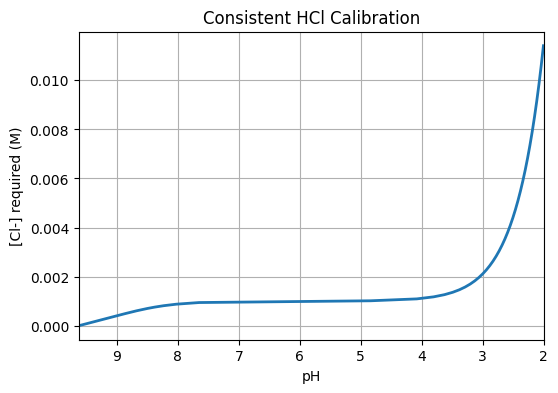

Target pH    : 3.0000
Recovered pH : 3.0000
Cl required  : 2.116633e-03 M
ΔpH          : +0.000002

NaOH ↔ HCl SWITCH
External HCl begins being required below pH ≈ 9.6089
[Cl-] at switch = 1.004e-05 M


In [5]:
# ============================================================
# CONFIRM HCl CALIBRATION
# ============================================================

build_hcl_calibration(

    params  = params,

    CO2_tot = 0.0,

    AA_tot  = 1e-3,
)

plot_calibration()

validate_calibration(

    pH_target = 3.0,

    params    = params,

    CO2_tot   = 0.0,

    AA_tot    = 1e-3
)
# ============================================================
# GLOBAL SWITCH POINT
# ============================================================

PH_HCL_SWITCH = None

threshold = 1e-5   # 10 µM acid

valid = np.where(
    Cl_axis > threshold
)[0]

if len(valid) == 0:

    print("No HCl region detected.")

else:

    idx_switch = valid[-1]

    PH_HCL_SWITCH = pH_axis[idx_switch]

    print("\n" + "="*60)
    print("NaOH ↔ HCl SWITCH")
    print("="*60)

    print(
        f"External HCl begins being required below pH ≈ "
        f"{PH_HCL_SWITCH:.4f}"
    )

    print(
        f"[Cl-] at switch = "
        f"{Cl_axis[idx_switch]:.3e} M"
    )
# ============================================================
# INITIALIZE STRONG IONS FROM TARGET pH
# ============================================================

def initialize_strong_ions(

    pH_target,
    AA_tot,
    params
):
    # ========================================================
    # intrinsic equilibrium mode
    #
    # no external NaOH added
    # ========================================================

    if not params.get("use_naoh", True):

        return 0.0, 0.0
    global PH_HCL_SWITCH

    # --------------------------------------------------------
    # legacy compatibility
    # --------------------------------------------------------

    #
    # old scripts expect:
    #
    # params["use_naoh"] = False
    #
    # to mean:
    #
    # "do not externally force pH"
    #
    # preserve that behavior
    #

    if not params.get("use_naoh", True):

        return 0.0,0.0

    # --------------------------------------------------------
    # hysteresis window
    # --------------------------------------------------------

    delta_switch = 0.01

    # --------------------------------------------------------
    # alkaline side
    # --------------------------------------------------------

    if pH_target > (PH_HCL_SWITCH + delta_switch):

        Cl = 0.0

        # ----------------------------------------------------
        # no amine shortcut
        # ----------------------------------------------------

        if AA_tot <= 1e-25:

            H_target = 10.0**(-pH_target)

            OH = Kw / H_target

            Na = max(
                OH - H_target,
                0.0
            )

        else:

            Na = max(
                naoh_required(pH_target),
                0.0
            )

        return Na,Cl

    # --------------------------------------------------------
    # acidic side
    # --------------------------------------------------------

    elif pH_target < (PH_HCL_SWITCH - delta_switch):

        Na = 0.0

        Cl = max(
            hcl_required(pH_target),
            0.0
        )

        return Na,Cl

    # --------------------------------------------------------
    # intrinsic region
    # --------------------------------------------------------

    else:

        return 0.0,0.0

In [6]:

# ============================================================
# CONSTANTS
# ============================================================

Kw = 1e-14
A_DH, B_DH = 0.509, 0.328
USE_DH = True
LAST_I = 0.0
# ============================================================
# PARAMETERS
# direct CO2 carbamation formalism
# ============================================================

params = {
    "pKa_alpha": 8.95,
    "pKa_eps": 10.53,
    "pKa_cooh": 2.18,

    "pKa1": 6.351,
    "pKa2": 10.329,

    # logK10 style direct CO2 reaction:
    # RNH2 + CO2 <-> RNHCOO- + H+
    "logK10_alpha": -4.5,
    "logK10_eps": -3.5,

    "logK_double": -1.0,

    "dH_carb_alpha": -29.7,
    "dH_carb_eps": -29.7,
    "dH_prot_alpha": -51.3,
    "dH_prot_eps": -51.3,
    "dH_carb_double": -59.4,
    "dH_cooh": 0.0,
    "dH_prot_double": 0.0,    
    "dH_bicarb": 8.9,
    "dH_carbonate": 15.4,
    "dH_HCl_dilution": 0.0,
    "dH_water": 55.8,
    "use_alpha": True,
    "use_eps": True,
    "use_naoh": True,
}
settings = {
    "CO2_syr": 20e-3,
    "HCl_syr": 30e-3,
    "CO2_contam_frac": 0.0,
    "CO2_cell_init": 0.0e-3,
    "AA_cell": 1e-3,
    "AA_norm": 1e-3,
    "V_cell0": 1.4e-3,
    "V_inj": 5e-6,

    "debug_heat": False,
    "debug_amines": False,
    "debug_buffer": False,
    "debug_base": False,
    "lock_pKa_sites": False,
    "lock_kcarb_sites": False,
}

In [7]:
# ============================================================
# DAVIES ACTIVITY MODEL
# ============================================================
@njit(cache=True)
def gamma_DH(z, I, a=0.0):

    if (not USE_DH) or (z == 0):
        return 1.0

    I = min(max(I,1e-6),1.0)

    sqrtI = np.sqrt(I)

    log10_gamma = (

        -0.509 * z*z *

        (
            (sqrtI/(1.0 + sqrtI))
            -
            0.3*I
        )
    )

    log10_gamma = min(
        max(log10_gamma,-2.0),
        0.0
    )

    return 10.0**(log10_gamma)
# ============================================================
# MIXING
# ============================================================

def mix_ph(Cc, Cs, V, Vi):
    return (Cc*V + Cs*Vi)/(V + Vi)

def mix_itc(Cc, Cs, V, Vi):
    return Cc + (Vi/V)*(Cs - Cc)

@njit(cache=True)
def carbonate_species(H, OH, CT, I, pKa1, pKa2):
    gH    = gamma_DH(+1, I, 9.0)
    gHCO3 = gamma_DH(-1, I, 4.0)
    gCO3  = gamma_DH(-2, I, 4.5)

    Ka1 = 10.0**(-pKa1)
    Ka2 = 10.0**(-pKa2)

    beta0 = 1.0

    beta1 = (
        Ka1 /
        max(H * gH * gHCO3, 1e-30)
    )

    beta2 = (
        Ka1 * Ka2 /
        max(H**2 * gH**2 * gCO3, 1e-30)
    )

    denom = max(beta0 + beta1 + beta2, 1e-30)

    CO2  = CT * beta0 / denom
    HCO3 = CT * beta1 / denom
    CO3  = CT * beta2 / denom

    return CO2, HCO3, CO3
# ============================================================
# FULL MOLECULAR PARTITION-FUNCTION AMINE MODEL
# ============================================================

@njit(cache=True)
def amine_speciation(

    H,
    CO2,
    AA_tot,
    I,

    pKa_alpha,
    pKa_eps,
    pKa_cooh,

    logK10_alpha,
    logK10_eps,
    logK_double,

    use_alpha,
    use_eps
):

    # ========================================================
    # activity coefficients
    # ========================================================

    gH    = gamma_DH(+1, I, 9.0)
    gNH3  = gamma_DH(+1, I, 5.0)
    gCarb = gamma_DH(-1, I, 5.0)
    gCOO  = gamma_DH(-1, I, 4.0)

    # ========================================================
    # equilibrium constants
    # ========================================================

    Ka_a  = 10.0**(-pKa_alpha)
    Ka_e  = 10.0**(-pKa_eps)
    Ka_co = 10.0**(-pKa_cooh)

    Kca = 10.0**(logK10_alpha)
    Kce = 10.0**(logK10_eps)

    # ========================================================
    # cooperative double-carbamate term
    # ========================================================

    if use_alpha and use_eps:

        Kd = 10.0**(logK_double)

    else:

        Kd = 0.0

    # ========================================================
    # site statistical weights
    # ========================================================

    if use_alpha:

        A_a = (
            (H * gH * gNH3)
            /
            max(Ka_a,1e-30)
        )

    else:

        A_a = 0.0

    if use_eps:

        A_e = (
            (H * gH * gNH3)
            /
            max(Ka_e,1e-30)
        )

    else:

        A_e = 0.0

    if use_alpha:

        B_a = (
            (Kca * CO2)
            /
            max(H * gH * gCarb,1e-30)
        )

    else:

        B_a = 0.0

    if use_eps:

        B_e = (
            (Kce * CO2)
            /
            max(H * gH * gCarb,1e-30)
        )

    else:

        B_e = 0.0

    # ========================================================
    # molecular microstates
    # ========================================================

    w_L      = 1.0

    w_HaL    = A_a
    w_HeL    = A_e
    w_H2L    = A_a * A_e

    w_Ca     = B_a
    w_Ce     = B_e

    w_CaHeL  = B_a * A_e
    w_HaCeL  = A_a * B_e

    w_Cae    = Kd * B_a * B_e

    # ========================================================
    # molecular partition function
    # ========================================================

    Z = max(

        w_L +

        w_HaL +
        w_HeL +
        w_H2L +

        w_Ca +
        w_Ce +

        w_CaHeL +
        w_HaCeL +

        w_Cae,

        1e-30
    )

    # ========================================================
    # state populations
    # ========================================================

    L      = AA_tot * w_L     / Z

    HaL    = AA_tot * w_HaL   / Z
    HeL    = AA_tot * w_HeL   / Z
    H2L    = AA_tot * w_H2L   / Z

    Ca     = AA_tot * w_Ca    / Z
    Ce     = AA_tot * w_Ce    / Z

    CaHeL  = AA_tot * w_CaHeL / Z
    HaCeL  = AA_tot * w_HaCeL / Z

    Cae    = AA_tot * w_Cae   / Z

    # ========================================================
    # carboxylate partition
    # ========================================================

    A_coo = (
        Ka_co
        /
        max(H * gH * gCOO,1e-30)
    )

    Z_back = 1.0 + A_coo

    COOH = AA_tot * (1.0 / Z_back)
    COO  = AA_tot * (A_coo / Z_back)

    # ========================================================
    # grouped observables
    # ========================================================

    alpha_H = (
        HaL +
        H2L +
        HaCeL
    )

    eps_H = (
        HeL +
        H2L +
        CaHeL
    )

    alpha_carb = (
        Ca +
        CaHeL +
        Cae
    )

    eps_carb = (
        Ce +
        HaCeL +
        Cae
    )

    carb_total = (

        Ca +
        Ce +

        CaHeL +
        HaCeL +

        2.0 * Cae
    )

    # ========================================================
    # carbamate ratios
    # ========================================================

    single_carb_total = (

        Ca +
        Ce +

        CaHeL +
        HaCeL
    )

    f_alpha_carb = (

        alpha_carb
        /
        max(carb_total,1e-30)
    )

    f_eps_carb = (

        eps_carb
        /
        max(carb_total,1e-30)
    )

    f_double_sites = (

        2.0 * Cae
        /
        max(carb_total,1e-30)
    )

    f_double_molecules = (

        Cae
        /
        max(single_carb_total + Cae,1e-30)
    )

    R_double_single = (

        Cae
        /
        max(single_carb_total,1e-30)
    )

    R_alpha_eps = (

        alpha_carb
        /
        max(eps_carb,1e-30)
    )

    # ========================================================
    # numerical cutoff
    # ========================================================

    carb_cutoff = 1e-12

    if carb_total < carb_cutoff:

        f_alpha_carb = np.nan
        f_eps_carb = np.nan

        f_double_sites = 0.0
        f_double_molecules = 0.0

        R_double_single = 0.0
        R_alpha_eps = 1.0

    # ========================================================
    # exact molecular charge accounting
    # ========================================================

    amine_charge = (

        + HaL
        + HeL
        + 2.0 * H2L

        - Ca
        - Ce

        - 2.0 * Cae
    )

    AA_charge = (
        amine_charge
        - COO
    )

    # ========================================================
    # ionic strength contribution
    # ========================================================

    I_amines = 0.5 * (

        1.0 * HaL +
        1.0 * HeL +

        4.0 * H2L +

        1.0 * Ca +
        1.0 * Ce +

        4.0 * Cae +

        1.0 * COO
    )

    # ========================================================
    # NUMBA-COMPATIBLE RETURN
    # ========================================================

    return (

        L,

        HaL,
        HeL,
        H2L,

        Ca,
        Ce,

        CaHeL,
        HaCeL,

        Cae,

        alpha_H,
        eps_H,

        alpha_carb,
        eps_carb,

        carb_total,

        COOH,
        COO,

        AA_charge,
        I_amines,

        single_carb_total,

        f_alpha_carb,
        f_eps_carb,

        f_double_sites,
        f_double_molecules,

        R_double_single,
        R_alpha_eps
    )
# ============================================================
# FULLY THERMODYNAMICALLY CLOSED EQUILIBRIUM SOLVER
# ============================================================

@njit(cache=True)
def equilibrium(

    vars,
    CO2_tot,
    AA_tot,
    Na,
    Cl,

    pKa1,
    pKa2,

    pKa_alpha,
    pKa_eps,
    pKa_cooh,

    logK10_alpha,
    logK10_eps,
    logK_double,

    use_alpha,
    use_eps
):

    # ========================================================
    # hydrogen ion variable
    # ========================================================

    logH = vars[0]

    if logH < -14.0:
        logH = -14.0

    if logH > 0.0:
        logH = 0.0

    H = max(10.0**logH,1e-30)

    # ========================================================
    # initial ionic strength estimate
    # ========================================================

    I = 0.5 * (Na + Cl + 1e-7)

    I = min(max(I,1e-8),5.0)

    gH  = gamma_DH(+1, I, 9.0)
    gOH = gamma_DH(-1, I, 3.5)

    logOH = (

        np.log10(Kw)

        -

        np.log10(max(H,1e-30))

        -

        np.log10(max(gH * gOH,1e-30))
    )

    OH = 10.0**logOH

    # ========================================================
    # total inorganic carbon
    # ========================================================

    CT_total = max(CO2_tot,1e-30)

    # ========================================================
    # improved ionic strength estimate
    # ========================================================

    I = 0.5 * (

        Na +
        Cl +

        H +
        OH
    )

    I = min(max(I,1e-8),5.0)

    # ========================================================
    # self-consistent activity iteration
    # ========================================================

    for _ in range(12):

        I = min(max(I,1e-8),5.0)

        gH  = gamma_DH(+1, I, 9.0)
        gOH = gamma_DH(-1, I, 3.5)

        logOH = (

            np.log10(Kw)

            -

            np.log10(max(H,1e-30))

            -

            np.log10(max(gH * gOH,1e-30))
        )

        OH = 10.0**logOH

        # ====================================================
        # carbonate chemistry
        # ====================================================

        CO2, HCO3, CO3 = carbonate_species(

            H,
            OH,
            CT_total,
            I,

            pKa1,
            pKa2
        )

        # ====================================================
        # no-amine shortcut
        # ====================================================

        if AA_tot <= 1e-25:

            carb_total = 0.0
            AA_charge = 0.0
            I_amines = 0.0

        else:

            # =================================================
            # first amine solve
            # =================================================

            spec = amine_speciation(

                H,
                CO2,
                AA_tot,
                I,

                pKa_alpha,
                pKa_eps,
                pKa_cooh,

                logK10_alpha,
                logK10_eps,
                logK_double,

                use_alpha,
                use_eps
            )

            (
                L,

                HaL,
                HeL,
                H2L,

                Ca,
                Ce,

                CaHeL,
                HaCeL,

                Cae,

                alpha_H,
                eps_H,

                alpha_carb,
                eps_carb,

                carb_total,

                COOH,
                COO,

                AA_charge,
                I_amines,

                single_carb_total,

                f_alpha_carb,
                f_eps_carb,

                f_double_sites,
                f_double_molecules,

                R_double_single,
                R_alpha_eps

            ) = spec

            # =================================================
            # free inorganic carbon correction
            # =================================================

            CT_free = max(
                CT_total - carb_total,
                1e-30
            )

            CO2, HCO3, CO3 = carbonate_species(

                H,
                OH,
                CT_free,
                I,

                pKa1,
                pKa2
            )

            # =================================================
            # recompute amine speciation
            # =================================================

            spec = amine_speciation(

                H,
                CO2,
                AA_tot,
                I,

                pKa_alpha,
                pKa_eps,
                pKa_cooh,

                logK10_alpha,
                logK10_eps,
                logK_double,

                use_alpha,
                use_eps
            )

            (
                L,

                HaL,
                HeL,
                H2L,

                Ca,
                Ce,

                CaHeL,
                HaCeL,

                Cae,

                alpha_H,
                eps_H,

                alpha_carb,
                eps_carb,

                carb_total,

                COOH,
                COO,

                AA_charge,
                I_amines,

                single_carb_total,

                f_alpha_carb,
                f_eps_carb,

                f_double_sites,
                f_double_molecules,

                R_double_single,
                R_alpha_eps

            ) = spec

        # ====================================================
        # ionic strength update
        # ====================================================

        I_new = 0.5 * (

            H +
            OH +

            HCO3 +
            4.0 * CO3 +

            Na +
            Cl +

            2.0 * I_amines
        )

        I_new = min(max(I_new,1e-8),2.0)

        # ====================================================
        # convergence
        # ====================================================

        if abs(I_new - I) < 1e-12:

            I = I_new
            break

        I = 0.5 * (I + I_new)

    # ========================================================
    # exact charge balance
    # ========================================================

    charge_balance = (

        H +
        Na +

        AA_charge

        -

        OH
        - HCO3
        - 2.0 * CO3
        - Cl
    )

    return charge_balance

In [8]:
# ============================================================
# REACTION-EXTENT CALORIMETRY
# ============================================================

def global_heat(
    prev,
    curr,
    Vavg,
    p,
    xi_HCl=0.0
):

    # ========================================================
    # species mole changes
    # ========================================================

    d_HaL = Vavg * (
        curr["HaL"] - prev["HaL"]
    )

    d_HeL = Vavg * (
        curr["HeL"] - prev["HeL"]
    )

    d_H2L = Vavg * (
        curr["H2L"] - prev["H2L"]
    )

    d_Ca = Vavg * (
        curr["Ca"] - prev["Ca"]
    )

    d_Ce = Vavg * (
        curr["Ce"] - prev["Ce"]
    )

    d_CaHeL = Vavg * (
        curr["CaHeL"] - prev["CaHeL"]
    )

    d_HaCeL = Vavg * (
        curr["HaCeL"] - prev["HaCeL"]
    )

    d_Cae = Vavg * (
        curr["Cae"] - prev["Cae"]
    )

    d_COO = Vavg * (
        curr["COO"] - prev["COO"]
    )

    d_HCO3 = Vavg * (
        curr["HCO3"] - prev["HCO3"]
    )

    d_CO3 = Vavg * (
        curr["CO3"] - prev["CO3"]
    )

    d_OH = Vavg * (
        curr["OH"] - prev["OH"]
    )

    # ========================================================
    # TOPOLOGY-AWARE PROTONATION EXTENTS
    # ========================================================

    if p["use_alpha"] and p["use_eps"]:

        xi_prot_alpha = (

            d_HaL
            +
            d_H2L
            +
            d_HaCeL
        )

        xi_prot_eps = (

            d_HeL
            +
            d_H2L
            +
            d_CaHeL
        )

    elif p["use_alpha"]:

        xi_prot_alpha = d_HaL

        xi_prot_eps = 0.0

    elif p["use_eps"]:

        xi_prot_alpha = 0.0

        xi_prot_eps = d_HeL

    else:

        xi_prot_alpha = 0.0
        xi_prot_eps = 0.0

    # ========================================================
    # TOPOLOGY-AWARE CARBAMATE EXTENTS
    # ========================================================

    if p["use_alpha"] and p["use_eps"]:

        xi_carb_alpha = (

            d_Ca
            +
            d_CaHeL
            +
            d_Cae
        )

        xi_carb_eps = (

            d_Ce
            +
            d_HaCeL
            +
            d_Cae
        )

    elif p["use_alpha"]:

        xi_carb_alpha = d_Ca

        xi_carb_eps = 0.0

    elif p["use_eps"]:

        xi_carb_alpha = 0.0

        xi_carb_eps = d_Ce

    else:

        xi_carb_alpha = 0.0
        xi_carb_eps = 0.0

    # ========================================================
    # CARBONATE CHEMISTRY
    # ========================================================

    xi_bicarb = (
        d_HCO3
        +
        d_CO3
    )

    xi_carbonate = d_CO3

    # ========================================================
    # CARBOXYLATE PROTONATION
    # ========================================================

    xi_COO = d_COO

    # ========================================================
    # WATER AUTOIONIZATION
    # ========================================================

    xi_OH = d_OH

    # ========================================================
    # HEAT TERMS
    # ========================================================

    q_prot_alpha = (

        p["dH_prot_alpha"]
        *
        xi_prot_alpha
    )

    q_prot_eps = (

        p["dH_prot_eps"]
        *
        xi_prot_eps
    )

    q_carb_alpha = (

        p["dH_carb_alpha"]
        *
        xi_carb_alpha
    )

    q_carb_eps = (

        p["dH_carb_eps"]
        *
        xi_carb_eps
    )

    q_COO = (

        p["dH_cooh"]
        *
        xi_COO
    )

    q_bicarb = (

        p["dH_bicarb"]
        *
        xi_bicarb
    )

    q_carbonate = (

        p["dH_carbonate"]
        *
        xi_carbonate
    )

    q_OH = (

        p["dH_water"]
        *
        xi_OH
    )

    q_HCl_dilution = (

        p.get("dH_HCl_dilution",0.0)
        *
        xi_HCl
    )

    # ========================================================
    # q_terms dictionary
    # ========================================================

    q_terms = {

        "prot_alpha":
            q_prot_alpha,

        "prot_eps":
            q_prot_eps,

        "carb_alpha":
            q_carb_alpha,

        "carb_eps":
            q_carb_eps,

        "COO":
            q_COO,

        "bicarb":
            q_bicarb,

        "carbonate":
            q_carbonate,

        "OH":
            q_OH,

        "HCl_dilution":
            q_HCl_dilution
    }

    # ========================================================
    # TOTAL REACTION HEAT
    # ========================================================

    q_reaction = (

        q_prot_alpha
        +
        q_prot_eps

        +
        
        q_carb_alpha
        +
        q_carb_eps

        +
        
        q_COO

        +
        
        q_bicarb
        +
        q_carbonate

        +
        
        q_OH

        +
        
        q_HCl_dilution
    )

    # ========================================================
    # OPTIONAL EMPIRICAL BASELINE
    # ========================================================

    if (

        p["use_alpha"]
        and
        p["use_eps"]

    ):

        active_population = (

            abs(curr["HaL"])
            +
            abs(curr["HeL"])
            +
            abs(curr["H2L"])

            +

            abs(curr["Ca"])
            +
            abs(curr["Ce"])

            +

            abs(curr["CaHeL"])
            +
            abs(curr["HaCeL"])

            +

            abs(curr["Cae"])
        )

        if active_population > 1e-20:

            q_background = -1.5e-7

        else:

            if abs(curr["L"]) < 1e-30:

                q_background = 0.0

            else:

                q_background = 0

    else:

        q_background = 0.0

    q_terms["heat_background"] = q_background

    # ========================================================
    # FINAL TOTAL HEAT
    # ========================================================

    q_total = (
        q_reaction
        +
        q_background
    )

    # ========================================================
    # residual dictionary
    # ========================================================

    dn = {

        "HaL":
            d_HaL,

        "HeL":
            d_HeL,

        "H2L":
            d_H2L,

        "Ca":
            d_Ca,

        "Ce":
            d_Ce,

        "CaHeL":
            d_CaHeL,

        "HaCeL":
            d_HaCeL,

        "Cae":
            d_Cae,

        "COO":
            d_COO,

        "HCO3":
            d_HCO3,

        "CO3":
            d_CO3,

        "OH":
            d_OH
    }

    return q_total, q_terms, dn
# ============================================================
# SIMULATION
# ============================================================

def simulate(pH_start,n_inj,mode,params,settings):

    CO2_tot = settings["CO2_cell_init"]
    AA_tot  = settings["AA_cell"]

    V     = settings["V_cell0"]
    V_inj = settings["V_inj"]
    CO2_syr = settings["CO2_syr"]
    CO2_contam_frac = settings["CO2_contam_frac"]
    HCl_syr = settings.get("HCl_syr", 0.0)

    # ============================================================
    # INITIAL STRONG IONS
    # ============================================================

    if (
        pH_start is None
        or
        not params.get("use_naoh", True)
    ):

        Na = 0.0
        Cl = 0.0

    else:

        Na,Cl = initialize_strong_ions(

            pH_target=pH_start,

            AA_tot=settings["AA_cell"],

            params=params
        )

    # --------------------------------------------------------
    # initial numerical pH guess
    # --------------------------------------------------------

    if (
        pH_start is None
        or
        not params.get("use_naoh", True)
    ):

        pH_guess = 9.6

    else:

        pH_guess = pH_start

    # --------------------------------------------------------
    # initial equilibrium solve
    # --------------------------------------------------------

    state = np.atleast_1d(

        fsolve(

            equilibrium,

            [-pH_guess],

            args=(

                CO2_tot,
                AA_tot,
                Na,
                Cl,

                params["pKa1"],
                params["pKa2"],

                params["pKa_alpha"],
                params["pKa_eps"],
                params["pKa_cooh"],

                params["logK10_alpha"],
                params["logK10_eps"],
                params["logK_double"],

                params["use_alpha"],
                params["use_eps"]
            ),

            xtol=1e-10,

            maxfev=10000
        )
    )

    # --------------------------------------------------------
    # active-site normalization
    # --------------------------------------------------------

    n_active_sites = (
        int(params["use_alpha"])
        +
        int(params["use_eps"])
    )

    AA_norm = settings["AA_norm"]

    if n_active_sites > 0 and AA_tot > 0:

        nsites = n_active_sites * AA_tot * V
        theta_label = "amine"

    else:

        nsites = max(AA_norm * V,1e-30)
        theta_label = "reference amine"

    # --------------------------------------------------------
    # outputs
    # --------------------------------------------------------

    out = {
    
        "pH":[],
    
        "CO2":[],
    
        "HCO3":[],
    
        "CO3":[],
    
        "capture_total":[],
    
        "capture_capacity":[],
    
        "CT_free":[],
        "alpha_H":[],
        "eps_H":[],
        "carb_alpha":[],
        "carb_eps":[],
        "carb_double":[],
        "carb_total":[],
        "Ca":[],
        "Ce":[],
        
        "CaHeL":[],
        "HaCeL":[],
        
        "Cae":[],
        "single_carb_total":[],

        "f_alpha_carb":[],
        "f_eps_carb":[],

        "f_double_sites":[],
        "f_double_molecules":[],

        "R_double_single":[],
        "R_alpha_eps":[],

        "heat":[],
        "theta":[],
        "I":[],

        "OH":[],
        "Na_init": Na,
        
        "Cl_init": Cl,
        
        "alk_init": np.nan,
        "theta_label": theta_label

    }

    # ========================================================
    # helper
    # ========================================================

    def store_state(state, AA_tot, Na, Cl):

        logH = float(state[0])

        H  = max(10.0**logH,1e-30)
        I_local = 1e-6
        
        gH  = gamma_DH(+1, I_local, 9.0)
        gOH = gamma_DH(-1, I_local, 3.5)

        logOH = (
            np.log10(Kw)
            -
            np.log10(max(H,1e-30))
            -
            np.log10(max(gH * gOH,1e-30))
        )

        OH = 10.0**logOH

        pH = -np.log10(H)

        CT_total = max(CO2_tot,1e-30)

        I_local = 1e-6

        # ----------------------------------------------------
        # self-consistent local iteration
        # ----------------------------------------------------

        for _ in range(20):

            I_local = min(max(I_local,1e-8),2.0)

            # ------------------------------------------------
            # initial carbonate estimate
            # ------------------------------------------------

            CO2,HCO3,CO3 = carbonate_species(

                H,
                OH,
                CT_total,
                I_local,

                params["pKa1"],
                params["pKa2"]
            )

            # ------------------------------------------------
            # amine speciation
            # ------------------------------------------------

            spec = amine_speciation(

                H,
                CO2,
                AA_tot,
                I_local,

                params["pKa_alpha"],
                params["pKa_eps"],
                params["pKa_cooh"],

                params["logK10_alpha"],
                params["logK10_eps"],
                params["logK_double"],

                params["use_alpha"],
                params["use_eps"]
            )

            (
                L,

                HaL,
                HeL,
                H2L,

                Ca,
                Ce,

                CaHeL,
                HaCeL,

                Cae,

                alpha_H,
                eps_H,

                alpha_carb,
                eps_carb,

                carb_total,

                COOH,
                COO,

                AA_charge,
                I_amines,

                single_carb_total,

                f_alpha_carb,
                f_eps_carb,

                f_double_sites,
                f_double_molecules,

                R_double_single,
                R_alpha_eps

            ) = spec

            # ------------------------------------------------
            # free inorganic carbon
            # ------------------------------------------------

            CT_free = max(
                CT_total - carb_total,
                1e-30
            )

            # ------------------------------------------------
            # recompute carbonate chemistry
            # ------------------------------------------------

            CO2,HCO3,CO3 = carbonate_species(

                H,
                OH,
                CT_free,
                I_local,

                params["pKa1"],
                params["pKa2"]
            )

            # ------------------------------------------------
            # recompute amines
            # ------------------------------------------------

            if AA_tot <= 1e-25:

                L = 0.0

                HaL = 0.0
                HeL = 0.0
                H2L = 0.0

                Ca = 0.0
                Ce = 0.0

                CaHeL = 0.0
                HaCeL = 0.0

                Cae = 0.0

                alpha_H = 0.0
                eps_H = 0.0

                alpha_carb = 0.0
                eps_carb = 0.0

                carb_total = 0.0

                COOH = 0.0
                COO = 0.0

                AA_charge = 0.0
                I_amines = 0.0

                single_carb_total = 0.0

                f_alpha_carb = np.nan
                f_eps_carb = np.nan

                f_double_sites = np.nan
                f_double_molecules = np.nan

                R_double_single = np.nan
                R_alpha_eps = np.nan

            else:

                spec = amine_speciation(

                    H,
                    CO2,
                    AA_tot,
                    I_local,

                    params["pKa_alpha"],
                    params["pKa_eps"],
                    params["pKa_cooh"],

                    params["logK10_alpha"],
                    params["logK10_eps"],
                    params["logK_double"],

                    params["use_alpha"],
                    params["use_eps"]
                )

                (
                    L,

                    HaL,
                    HeL,
                    H2L,

                    Ca,
                    Ce,

                    CaHeL,
                    HaCeL,

                    Cae,

                    alpha_H,
                    eps_H,

                    alpha_carb,
                    eps_carb,

                    carb_total,

                    COOH,
                    COO,

                    AA_charge,
                    I_amines,

                    single_carb_total,

                    f_alpha_carb,
                    f_eps_carb,

                    f_double_sites,
                    f_double_molecules,

                    R_double_single,
                    R_alpha_eps

                ) = spec

            # ------------------------------------------------
            # ionic strength update
            # ------------------------------------------------

            I_new = 0.5 * (

                H +
                OH +

                HCO3 +
                4.0 * CO3 +

                Na +
                Cl +

                2.0 * I_amines
            )

            I_new = min(max(I_new,1e-8),2.0)

            if abs(I_new - I_local) < 1e-12:

                I_local = I_new
                break

            I_local = 0.5 * (I_local + I_new)

        # ========================================================
        # suppress meaningless ratios
        # ========================================================

        # ----------------------------------------------------
        # outputs
        # ----------------------------------------------------

        out["pH"].append(pH)

        out["alpha_H"].append(
            alpha_H
        )

        out["eps_H"].append(
            eps_H
        )

        out["carb_alpha"].append(
            alpha_carb
        )

        out["carb_eps"].append(
            eps_carb
        )

        out["carb_double"].append(
            Cae
        )
        out["Ca"].append(
            Ca
        )
        
        out["Ce"].append(
            Ce
        )
        
        out["CaHeL"].append(
            CaHeL
        )
        
        out["HaCeL"].append(
            HaCeL
        )
        
        out["Cae"].append(
            Cae
        )
        out["carb_total"].append(
            carb_total
        )

        out["OH"].append(OH)
        out["CO2"].append(
            CO2
        )
        
        out["HCO3"].append(
            HCO3
        )
        
        out["CO3"].append(
            CO3
        )
        
        out["CT_free"].append(
            CT_free
        )
        
        out["capture_total"].append(
            carb_total
            +
            HCO3
            +
            CO3
        )
        
        out["capture_capacity"].append(
            (
                carb_total
                +
                HCO3
                +
                CO3
            )
            /
            max(AA_tot,1e-30)
        )
        out["single_carb_total"].append(
            single_carb_total
        )

        out["f_alpha_carb"].append(
            f_alpha_carb
        )

        out["f_eps_carb"].append(
            f_eps_carb
        )

        out["f_double_sites"].append(
            f_double_sites
        )

        out["f_double_molecules"].append(
            f_double_molecules
        )

        out["R_double_single"].append(
            R_double_single
        )

        out["R_alpha_eps"].append(
            R_alpha_eps
        )

        # ========================================================
        # AMINE DIAGNOSTIC
        # ========================================================

        if settings.get("debug_amines", False):

            print("\n" + "="*60)
            print("AMINE DIAGNOSTIC")
            print("="*60)

            gH    = gamma_DH(+1, I_local, 9.0)
            gNH3  = gamma_DH(+1, I_local, 5.0)
            gCarb = gamma_DH(-1, I_local, 5.0)

            Ka_a = 10.0**(-params["pKa_alpha"])
            Ka_e = 10.0**(-params["pKa_eps"])

            Kca = 10.0**(params["logK10_alpha"])
            Kce = 10.0**(params["logK10_eps"])

            A_a = (
                (H * gH * gNH3) /
                max(Ka_a,1e-30)
            )

            B_a = (
                (Kca * CO2) /
                max(H * gH * gCarb,1e-30)
            )

            A_e = (
                (H * gH * gNH3) /
                max(Ka_e,1e-30)
            )

            B_e = (
                (Kce * CO2) /
                max(H * gH * gCarb,1e-30)
            )

            print(f"pH           = {pH:.4f}")
            print(f"I            = {I_local:.4f}")

            print(f"CO2          = {CO2:.3e}")
            print(f"HCO3         = {HCO3:.3e}")
            print(f"CO3          = {CO3:.3e}")

            print("\nALPHA SITE")

            print(f"A_a          = {A_a:.3e}")
            print(f"B_a          = {B_a:.3e}")

            print(f"log10(A_a)   = {np.log10(max(A_a,1e-300)):.2f}")
            print(f"log10(B_a)   = {np.log10(max(B_a,1e-300)):.2f}")

            print("\nEPSILON SITE")

            print(f"A_e          = {A_e:.3e}")
            print(f"B_e          = {B_e:.3e}")

            print(f"log10(A_e)   = {np.log10(max(A_e,1e-300)):.2f}")
            print(f"log10(B_e)   = {np.log10(max(B_e,1e-300)):.2f}")

            print("\nFRACTIONS")

            print(f"alpha_H      = {alpha_H:.3e}")
            print(f"alpha_carb   = {alpha_carb:.3e}")

            print(f"eps_H        = {eps_H:.3e}")
            print(f"eps_carb     = {eps_carb:.3e}")

        return {

            "H": H,
            "OH": OH,

            "CO2": CO2,
            "HCO3": HCO3,
            "CO3": CO3,
            "CT_free": CT_free,
            
            "capture_total":
            (
                carb_total
                +
                HCO3
                +
                CO3
            ),
            
            "capture_capacity":
            (
                carb_total
                +
                HCO3
                +
                CO3
            )
            /
            max(AA_tot,1e-30),
            "alpha_H": alpha_H,
            "eps_H": eps_H,
            "L": L,

            "HaL": HaL,
            "HeL": HeL,
            "H2L": H2L,

            "Ca": Ca,
            "Ce": Ce,

            "CaHeL": CaHeL,
            "HaCeL": HaCeL,

            "Cae": Cae,

            "alpha_carb": alpha_carb,
            "eps_carb": eps_carb,

            "COOH": COOH,
            "COO": COO,

            "AA_charge": AA_charge,

            "I": I_local,

            "single_carb_total": single_carb_total,

            "f_alpha_carb": f_alpha_carb,
            "f_eps_carb": f_eps_carb,

            "f_double_sites": f_double_sites,
            "f_double_molecules": f_double_molecules,

            "R_double_single": R_double_single,
            "R_alpha_eps": R_alpha_eps,
        }

    # --------------------------------------------------------
    # initial state
    # --------------------------------------------------------

    prev = store_state(state,AA_tot,Na,Cl)
    
    # ========================================================
    # INITIAL ALKALINITY
    # ========================================================
    out["alk_init"] = (
    
        Na
    
        -
    
        Cl
    
    )
    # ========================================================
    # INITIAL BUFFER DIAGNOSTIC
    # ========================================================

    if settings.get("debug_base", False):

        print("\n" + "="*60)
        print("INITIAL BUFFER STATE")
        print("="*60)

        print(f"target pH = {pH_start:.3f}")

        print(f"Na total  = {Na:.4e}")
        print(f"Cl total  = {Cl:.4e}")
        print(f"OH        = {prev['OH']:.4e}")

        print(f"CO2       = {prev['CO2']:.4e}")
        print(f"HCO3      = {prev['HCO3']:.4e}")
        print(f"CO3       = {prev['CO3']:.4e}")

        carb_frac = (
            prev["CO3"] /
            max(prev["HCO3"] + prev["CO3"],1e-30)
        )

        print(
            f"carbonate fraction = "
            f"{carb_frac:.3f}"
        )

    n_titrant = 0.0

    # ========================================================
    # titration loop
    # ========================================================

    for i in range(n_inj):

        CO2_syr_eff = (
            CO2_syr +
            CO2_contam_frac
        )

        # ========================================================
        # CO2 TITRATION
        # ========================================================

        if mode in ["pH titration", "ITC CO2"]:

            CO2_syr_eff = (
                CO2_syr +
                CO2_contam_frac
            )

            if mode == "pH titration":

                CO2_tot = mix_ph(
                    CO2_tot,
                    CO2_syr_eff,
                    V,
                    V_inj
                )

                AA_tot = mix_ph(
                    AA_tot,
                    0,
                    V,
                    V_inj
                )

                Na = mix_ph(
                    Na,
                    0,
                    V,
                    V_inj
                )

                Cl = mix_ph(
                    Cl,
                    0,
                    V,
                    V_inj
                )

                V += V_inj

            else:

                CO2_tot = mix_itc(
                    CO2_tot,
                    CO2_syr_eff,
                    V,
                    V_inj
                )

                AA_tot = mix_itc(
                    AA_tot,
                    0,
                    V,
                    V_inj
                )

                Na = mix_itc(
                    Na,
                    0,
                    V,
                    V_inj
                )

                Cl = mix_itc(
                    Cl,
                    0,
                    V,
                    V_inj
                )

        # ========================================================
        # HCl TITRATION
        # ========================================================

        elif mode in ["ITC HCl", "HCl titration"]:

            if mode == "HCl titration":

                Cl = mix_ph(
                    Cl,
                    HCl_syr,
                    V,
                    V_inj
                )

                CO2_tot = mix_ph(
                    CO2_tot,
                    0,
                    V,
                    V_inj
                )

                AA_tot = mix_ph(
                    AA_tot,
                    0,
                    V,
                    V_inj
                )

                Na = mix_ph(
                    Na,
                    0,
                    V,
                    V_inj
                )

                V += V_inj

            else:

                Cl = mix_itc(
                    Cl,
                    HCl_syr,
                    V,
                    V_inj
                )

                CO2_tot = mix_itc(
                    CO2_tot,
                    0,
                    V,
                    V_inj
                )

                AA_tot = mix_itc(
                    AA_tot,
                    0,
                    V,
                    V_inj
                )

                Na = mix_itc(
                    Na,
                    0,
                    V,
                    V_inj
                )

        # ----------------------------------------------------
        # equilibrium solve
        # ----------------------------------------------------
        state = np.clip(
            state,
            -14,
            0
        )
        sol,info,ier,msg = fsolve(

            equilibrium,

            state,

            args=(

                CO2_tot,
                AA_tot,
                Na,
                Cl,

                params["pKa1"],
                params["pKa2"],

                params["pKa_alpha"],
                params["pKa_eps"],
                params["pKa_cooh"],

                params["logK10_alpha"],
                params["logK10_eps"],
                params["logK_double"],

                params["use_alpha"],
                params["use_eps"]
            ),

            full_output=True,
            xtol=1e-8,
            maxfev=10000
        )

        if ier != 1:

            print("\n" + "="*70)
            print("FSOLVE FAILURE")
            print("="*70)

            print(f"injection = {i}")

            try:
                print(f"previous pH = {-np.log10(prev['H']):.6f}")
            except:
                pass

            print(f"CO2_tot = {CO2_tot:.6e}")
            print(f"AA_tot  = {AA_tot:.6e}")

            print(f"Na      = {Na:.6e}")
            print(f"Cl      = {Cl:.6e}")

            print("state =", state)

            print("ier =", ier)
            print("msg =", msg)

            return None

        state = sol

        curr = store_state(state,AA_tot,Na,Cl)

        if mode in ["ITC HCl", "HCl titration"]:

            ninj = HCl_syr * V_inj

        else:

            ninj = CO2_syr * V_inj

        # ----------------------------------------------------
        # calorimetry
        # ----------------------------------------------------

        q, q_terms, residuals = global_heat(

            prev,
            curr,
            V,

            params,

            xi_HCl=(

                ninj

                if mode in ["ITC HCl", "HCl titration"]

                else 0.0
            )
        )

        # ----------------------------------------------------
        # diagnostics
        # ----------------------------------------------------

        if settings["debug_heat"]:

            qnorm = q / max(ninj,1e-30)

            print("\n" + "="*70)
            print(f"Injection {i+1}")
            print("="*70)

            print(f"Total heat (J/mol inj): {qnorm: .6f}")

            print("\nHEAT TERMS")

            for k,v in q_terms.items():

                print(
                    f"{k:15s}"
                    f"{(v/max(ninj,1e-30)): .6f}"
                )

            print("\nSPECIES DELTAS (mol in cell)")

            species_debug = {

                "d_alpha_H":
                    V*(curr["alpha_H"] - prev["alpha_H"]),

                "d_eps_H":
                    V*(curr["eps_H"] - prev["eps_H"]),

                "d_alpha_carb":
                    V*(curr["alpha_carb"] - prev["alpha_carb"]),

                "d_eps_carb":
                    V*(curr["eps_carb"] - prev["eps_carb"]),

                "d_HCO3":
                    V*(curr["HCO3"] - prev["HCO3"]),

                "d_CO3":
                    V*(curr["CO3"] - prev["CO3"]),

                "d_OH":
                    V*(curr["OH"] - prev["OH"]),
            }

            for k,v in species_debug.items():

                print(f"{k:15s}{v: .3e}")

            print("\nCURRENT STATE")

            print(f"pH        : {-np.log10(curr['H']): .4f}")
            print(f"OH        : {curr['OH']: .3e}")
            print(f"CO2       : {curr['CO2']: .3e}")
            print(f"HCO3      : {curr['HCO3']: .3e}")
            print(f"CO3       : {curr['CO3']: .3e}")

            print(f"alpha carb: {curr['alpha_carb']: .3e}")
            print(f"eps carb  : {curr['eps_carb']: .3e}")

            print(f"Ionic str.: {curr['I']: .5f}")

            carb_change = abs(
                species_debug["d_alpha_carb"]
                +
                species_debug["d_eps_carb"]
            )

            carbonate_change = abs(
                species_debug["d_HCO3"]
            ) + abs(
                species_debug["d_CO3"]
            )

            oh_change = abs(
                species_debug["d_OH"]
            )

            if carb_change < 1e-12:

                print("\n*** CARBAMATE SATURATED ***")

                print(
                    "Residual heat source analysis:"
                )

                print(
                    f"carbonate redistribution = "
                    f"{carbonate_change:.3e}"
                )

                print(
                    f"OH redistribution = "
                    f"{oh_change:.3e}"
                )

                dominant = max(

                    abs(q_terms["bicarb"]),
                    abs(q_terms["carbonate"]),
                    abs(q_terms["OH"])

                )

                if dominant == abs(q_terms["OH"]):

                    print(
                        "Dominant residual source: "
                        "OH neutralization"
                    )

                elif dominant == abs(q_terms["carbonate"]):

                    print(
                        "Dominant residual source: "
                        "carbonate formation"
                    )

                elif dominant == abs(q_terms["bicarb"]):

                    print(
                        "Dominant residual source: "
                        "bicarbonate formation"
                    )

        out["heat"].append(
            q / max(ninj,1e-30)
        )

        n_titrant += ninj

        out["theta"].append(
            n_titrant / nsites
        )

        out["I"].append(
            curr["I"]
        )

        # ========================================================
        # BUFFER DIAGNOSTIC
        # ========================================================

        if settings.get("debug_buffer", False):

            if len(out["pH"]) >= 2:

                dpH = out["pH"][-1] - out["pH"][-2]

                dn_base = ninj

                beta = dn_base / max(abs(dpH),1e-30)

                print(
                    f"inj {i+1:3d} | "
                    f"pH = {out['pH'][-1]:.4f} | "
                    f"dpH = {dpH:.4e} | "
                    f"beta = {beta:.3e} mol/pH"
                )

        prev = curr

    # ========================================================
    # arrays
    # ========================================================

    for k in out:

        if k == "theta_label":
            continue

        out[k] = np.array(out[k])

        if out[k].size > 1:

            out[k] = out[k][1:]

    return out

DIAMINE CO2 EQUILIBRIUM MODEL LOADED

TEST pH = 11.0000
Na = 1.8644e-03 M | Cl = 0.0000e+00 M

--- CO2 TITRATION TEST ---
CO2 simulation: PASSED
Points generated: 100
Initial pH: 10.9540
Final pH: 6.1200
Final carbamate: 0.0002 mM
Final ionic strength: 0.0036
Initial alkalinity: 1.864 mM
Na inventory: 1.864 mM
Cl inventory: 0.000 mM

--- HCl TITRATION TEST ---
HCl simulation: PASSED
Points generated: 20
Initial pH: 10.9615
Final pH: 9.1758
Final carbamate: 0.0000 mM
Final ionic strength: 0.0033
Initial alkalinity: 1.864 mM
Na inventory: 1.864 mM
Cl inventory: 0.000 mM

ALKALINITY CHECK
AA concentration = 1.0 mM
Initial alkalinity = 1.864 mM
Alkalinity / AA = 1.864


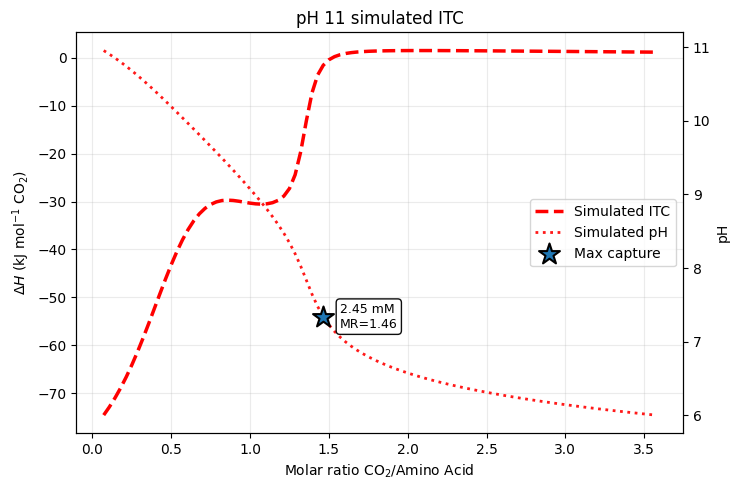


Peak capture = 2.449 mM
Final alpha protonation: 0.3214 mM
Final epsilon protonation: 0.8888 mM

TEST pH = 9.8089
Na = 1.2613e-04 M | Cl = 0.0000e+00 M

--- CO2 TITRATION TEST ---
CO2 simulation: PASSED
Points generated: 100
Initial pH: 9.6804
Final pH: 5.5788
Final carbamate: 0.0000 mM
Final ionic strength: 0.0023
Initial alkalinity: 0.126 mM
Na inventory: 0.126 mM
Cl inventory: 0.000 mM

--- HCl TITRATION TEST ---
HCl simulation: PASSED
Points generated: 20
Initial pH: 9.6514
Final pH: 3.0685
Final carbamate: 0.0000 mM
Final ionic strength: 0.0038
Initial alkalinity: 0.126 mM
Na inventory: 0.126 mM
Cl inventory: 0.000 mM

ALKALINITY CHECK
AA concentration = 1.0 mM
Initial alkalinity = 0.126 mM
Alkalinity / AA = 0.126
Final alpha protonation: 0.9333 mM
Final epsilon protonation: 0.9333 mM

TEST pH = 9.6589
Na = 2.2891e-05 M | Cl = 0.0000e+00 M

--- CO2 TITRATION TEST ---
CO2 simulation: PASSED
Points generated: 100
Initial pH: 9.5285
Final pH: 5.5308
Final carbamate: 0.0000 mM
Final 

In [9]:
# ============================================================
# LOAD TEST
# ============================================================

print("="*60)
print("DIAMINE CO2 EQUILIBRIUM MODEL LOADED")
print("="*60)

# ============================================================
# TEST pH VALUES
# ============================================================

test_pHs = [

    # strongly basic
    11.0,
    # near crossover
    PH_HCL_SWITCH + 0.20,
    PH_HCL_SWITCH + 0.05,
    PH_HCL_SWITCH,
    PH_HCL_SWITCH - 0.05,
    PH_HCL_SWITCH - 0.20,

    # acidic
    5.0
]

# remove duplicates
test_pHs = sorted(
    list(set(test_pHs)),
    reverse=True
)

# ============================================================
# RUN TESTS
# ============================================================

for pH_test in test_pHs:

    print("\n" + "="*60)
    print(f"TEST pH = {pH_test:.4f}")
    print("="*60)

    try:

        # ----------------------------------------------------
        # initialize strong ions
        # ----------------------------------------------------

        Na,Cl = initialize_strong_ions(

            pH_target = pH_test,

            AA_tot = settings["AA_cell"],

            params = params
        )

        print(
            f"Na = {Na:.4e} M | "
            f"Cl = {Cl:.4e} M"
        )

        # ====================================================
        # CO2 TITRATION TEST
        # ====================================================

        print("\n--- CO2 TITRATION TEST ---")

        test = simulate(

            pH_start = pH_test,

            n_inj = 100,

            mode = "pH titration",

            params = params,

            settings = settings
        )

        print("CO2 simulation: PASSED")

        print(
            f"Points generated: "
            f"{len(test['pH'])}"
        )

        if len(test["pH"]) > 0:

            print(
                f"Initial pH: "
                f"{test['pH'][0]:.4f}"
            )

            print(
                f"Final pH: "
                f"{test['pH'][-1]:.4f}"
            )

            print(
                f"Final carbamate: "
                f"{test['carb_total'][-1]*1e3:.4f} mM"
            )

            print(
                f"Final ionic strength: "
                f"{test['I'][-1]:.4f}"
            )
            print(
                f"Initial alkalinity: "
                f"{test['alk_init']*1e3:.3f} mM"
            )
            
            
            print(
                f"Na inventory: "
                f"{test['Na_init']*1e3:.3f} mM"
            )
            
            
            print(
                f"Cl inventory: "
                f"{test['Cl_init']*1e3:.3f} mM"
            )
            # ------------------------------------------------
            # sanity checks
            # ------------------------------------------------

            if np.any(np.isnan(test["pH"])):

                print("*** WARNING: NaN pH detected")

            if np.any(np.isnan(test["I"])):

                print("*** WARNING: NaN ionic strength detected")

            if np.any(test["I"] < 0):

                print("*** WARNING: negative ionic strength")

            if np.any(test["carb_total"] < -1e-12):

                print("*** WARNING: negative carbamate")

        # ====================================================
        # HCl TITRATION TEST
        # ====================================================

        print("\n--- HCl TITRATION TEST ---")

        test_hcl = simulate(

            pH_start = pH_test,

            n_inj = 20,

            mode = "HCl titration",

            params = params,

            settings = settings
        )

        print("HCl simulation: PASSED")

        print(
            f"Points generated: "
            f"{len(test_hcl['pH'])}"
        )

        if len(test_hcl["pH"]) > 0:

            print(
                f"Initial pH: "
                f"{test_hcl['pH'][0]:.4f}"
            )

            print(
                f"Final pH: "
                f"{test_hcl['pH'][-1]:.4f}"
            )

            print(
                f"Final carbamate: "
                f"{test_hcl['carb_total'][-1]*1e3:.4f} mM"
            )

            print(
                f"Final ionic strength: "
                f"{test_hcl['I'][-1]:.4f}"
            )
            print(
                f"Initial alkalinity: "
                f"{test_hcl['alk_init']*1e3:.3f} mM"
            )
            
            
            print(
                f"Na inventory: "
                f"{test_hcl['Na_init']*1e3:.3f} mM"
            )
            
            
            print(
                f"Cl inventory: "
                f"{test_hcl['Cl_init']*1e3:.3f} mM"
            )
            # ------------------------------------------------
            # pH 11 SIMULATED ITC + pH + MAX CAPTURE
            # ------------------------------------------------
            print("\nALKALINITY CHECK")
            
            print(
                f"AA concentration = "
                f"{settings['AA_cell']*1e3:.1f} mM"
            )
            
            print(
                f"Initial alkalinity = "
                f"{test['alk_init']*1e3:.3f} mM"
            )
            
            print(
                f"Alkalinity / AA = "
                f"{test['alk_init']/max(settings['AA_cell'],1e-30):.3f}"
            )
            if np.isclose(pH_test, 11.0):

                sim_itc = simulate(

                    pH_start=11.0,

                    n_inj=100,

                    mode="ITC CO2",

                    params=params,

                    settings=settings
                )

                fig, ax = plt.subplots(
                    figsize=(7.5,5.0)
                )

                ax_ph = ax.twinx()

                # --------------------------------------------
                # force same length everywhere
                # --------------------------------------------

                n = min(

                    len(sim_itc["theta"]),

                    len(sim_itc["heat"]),

                    len(sim_itc["pH"]),

                    len(sim_itc["capture_total"])
                )

                theta = np.asarray(
                    sim_itc["theta"][:n]
                )

                heat = np.asarray(
                    sim_itc["heat"][:n]
                )

                pH = np.asarray(
                    sim_itc["pH"][:n]
                )

                capture = np.asarray(
                    sim_itc["capture_total"][:n]
                )

                # --------------------------------------------
                # simulated ITC
                # --------------------------------------------

                ax.plot(

                    theta,

                    heat,

                    color="red",

                    lw=2.5,

                    ls="--",

                    label="Simulated ITC"
                )

                # --------------------------------------------
                # simulated pH
                # --------------------------------------------

                ax_ph.plot(

                    theta,

                    pH,

                    color="red",

                    lw=2.0,

                    ls=":",

                    alpha=0.9,

                    label="Simulated pH"
                )

                # --------------------------------------------
                # maximum capture
                # --------------------------------------------

                imax = np.nanargmax(
                    capture
                )

                ax_ph.scatter(

                    theta[imax],

                    pH[imax],

                    marker="*",

                    s=250,

                    edgecolor="black",

                    linewidth=1.5,

                    zorder=50,

                    label="Max capture"
                )

                ax_ph.annotate(

                    (
                        f"{capture[imax]*1e3:.2f} mM\n"
                        f"MR={theta[imax]:.2f}"
                    ),

                    xy=(
                        theta[imax],
                        pH[imax]
                    ),

                    xytext=(
                        12,
                        -8
                    ),

                    textcoords="offset points",

                    fontsize=9,

                    bbox=dict(

                        boxstyle="round",

                        fc="white",

                        alpha=0.95
                    )
                )

                # --------------------------------------------
                # styling
                # --------------------------------------------

                ax.set_xlabel(
                    r"Molar ratio CO$_2$/Amino Acid"
                )

                ax.set_ylabel(
                    r"$\Delta H$ (kJ mol$^{-1}$ CO$_2$)"
                )

                ax_ph.set_ylabel(
                    "pH"
                )

                ax.set_title(
                    "pH 11 simulated ITC"
                )

                ax.grid(
                    alpha=0.25
                )

                h1,l1 = (
                    ax.get_legend_handles_labels()
                )

                h2,l2 = (
                    ax_ph.get_legend_handles_labels()
                )

                ax.legend(

                    h1+h2,

                    l1+l2,

                    loc="center right"
                )

                plt.tight_layout()

                plt.show()

                print(
                    f"\nPeak capture = "
                    f"{capture[imax]*1e3:.3f} mM"
                )
            print(
                f"Final alpha protonation: "
                f"{test_hcl['alpha_H'][-1]*1e3:.4f} mM"
            )
            
            print(
                f"Final epsilon protonation: "
                f"{test_hcl['eps_H'][-1]*1e3:.4f} mM"
            )

            # ------------------------------------------------
            # sanity checks
            # ------------------------------------------------

            if np.any(np.isnan(test_hcl["pH"])):

                print("*** WARNING: NaN pH detected")

            if np.any(np.isnan(test_hcl["I"])):

                print("*** WARNING: NaN ionic strength detected")

            if np.any(test_hcl["I"] < 0):

                print("*** WARNING: negative ionic strength")

            if np.any(test_hcl["carb_total"] < -1e-12):

                print("*** WARNING: negative carbamate")
    except Exception as e:

        print("Simulation check FAILED")

        print(type(e).__name__)
        print(e)

print("\n" + "="*60)
print("LOAD TEST COMPLETE")
print("="*60)

In [10]:
# ============================================================
# GLOBAL LATEX LABELS
# ============================================================

LATEX_NAMES = {

    "pKa_alpha":
        r"$\mathrm{p}K_{a,\alpha}$",

    "pKa_eps":
        r"$\mathrm{p}K_{a,\varepsilon}$",

    "pKa_cooh":
        r"$\mathrm{p}K_{a,\mathrm{COOH}}$",

    "pKa1":
        r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",

    "pKa2":
        r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",

    "dH_bicarb":
        r"$\Delta H_{\mathrm{HCO_3^-}}$",

    "dH_carbonate":
        r"$\Delta H_{\mathrm{CO_3^{2-}}}$",

    "dH_carb_alpha":
        r"$\Delta H_{\alpha}$",

    "dH_carb_eps":
        r"$\Delta H_{\varepsilon}$",

    "dH_carb_double":
        r"$\Delta H_{\mathrm{double}}$",

    "logK10_alpha":
        r"$\log K_{\mathrm{carb},\alpha}$",

    "logK10_eps":
        r"$\log K_{\mathrm{carb},\varepsilon}$",

    "logK_double":
        r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",

    "dH_prot_alpha":
        r"$\Delta H_{\mathrm{prot},\alpha}$",

    "dH_prot_eps":
        r"$\Delta H_{\mathrm{prot},\varepsilon}$",

    "dH_cooh":
        r"$\Delta H_{\mathrm{COOH}}$",

    "dH_HCl_dilution":
        r"$\Delta H_{\mathrm{HCl\ dilution}}$",
}

In [11]:
# ============================================================
# ITC BACKEND
# ============================================================

ITC = {}
# ============================================================
# GLOBAL pH CACHE
# ============================================================

ITC_PH_CACHE = {}
# ============================================================
# DATA DIRECTORY
# ============================================================

ITC["data_dir"] = Path(
    r"C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\thermograms\Lys"
)

# ============================================================
# CONSTANTS
# ============================================================

ITC["LOW_POINT_THRESHOLD"] = 25

ITC["SUBSAMPLE"] = 2

ITC["PH_PRIORS"] = {

    "12": 12.0,
    "115": 11.0,
    "11": 11.0,
    "105": 10.5,
    "10": 10.0,
    "95": 9.5,
    "9": 9.0,
    "85": 8.5
}

# ============================================================
# PARAMETER GROUPS
# ============================================================

ITC["ALPHA_PARAMS"] = {

    "dH_carb_alpha",
    "logK10_alpha",
    "dH_prot_alpha"
}

ITC["EPS_PARAMS"] = {

    "dH_carb_eps",
    "logK10_eps",
    "dH_prot_eps"
}

ITC["DOUBLE_PARAMS"] = {

    "logK_double",
    "dH_carb_double"
}

ITC["BACKBONE_PARAMS"] = {

    "dH_cooh"
}

# ============================================================
# FIT PARAMETERS
# ============================================================

ITC["FIT_PARAMS"] = [
    {
        "name": "pKa1",
        "target": "params",
        "key": "pKa1",
        "x0": 6.351,
        "lb": 5.8,
        "ub": 7.5
    },
    
    {
        "name": "pKa2",
        "target": "params",
        "key": "pKa2",
        "x0": 10.329,
        "lb": 9.8,
        "ub": 10.8
    },
    {
        "name": "pKa_alpha",
        "target": "params",
        "key": "pKa_alpha",
        "x0": 8.95,
        "lb": 7.5,
        "ub": 10.5
    },
    
    {
        "name": "pKa_eps",
        "target": "params",
        "key": "pKa_eps",
        "x0": 10.53,
        "lb": 9.0,
        "ub": 12.5
    },
    
    {
        "name": "pKa_cooh",
        "target": "params",
        "key": "pKa_cooh",
        "x0": 2.18,
        "lb": 1.0,
        "ub": 5.0
    },
    {
        "name": "dH_bicarb",
        "target": "params",
        "key": "dH_bicarb",
        "x0": 9.35,
        "lb": 5,
        "ub": 15
    },

    {
        "name": "dH_carbonate",
        "target": "params",
        "key": "dH_carbonate",
        "x0": 14.22,
        "lb": 7,
        "ub": 20
    },

    {
        "name": "dH_carb_alpha",
        "target": "params",
        "key": "dH_carb_alpha",
        "x0": -33.5938,
        "lb": -100,
        "ub": 20
    },

    {
        "name": "dH_carb_eps",
        "target": "params",
        "key": "dH_carb_eps",
        "x0": -24.2857,
        "lb": -100,
        "ub": 20
    },

    {
        "name": "dH_carb_double",
        "target": "params",
        "key": "dH_carb_double",
        "x0": -59.4,
        "lb": -100,
        "ub": 50
    },

    {
        "name": "logK10_alpha",
        "target": "params",
        "key": "logK10_alpha",
        "x0": -4.3125,
        "lb": -6,
        "ub": -1
    },

    {
        "name": "logK10_eps",
        "target": "params",
        "key": "logK10_eps",
        "x0": -3.23429,
        "lb": -6,
        "ub": -1
    },

    {
        "name": "logK_double",
        "target": "params",
        "key": "logK_double",
        "x0": -1,
        "lb": -5,
        "ub": 2
    },

    {
        "name": "dH_prot_alpha",
        "target": "params",
        "key": "dH_prot_alpha",
        "x0": -48.61,
        "lb": -56,
        "ub": -38
    },

    {
        "name": "dH_prot_eps",
        "target": "params",
        "key": "dH_prot_eps",
        "x0": -50.0186,
        "lb": -54,
        "ub": -31
    },

    {
        "name": "dH_cooh",
        "target": "params",
        "key": "dH_cooh",
        "x0": -5,
        "lb": -40,
        "ub": 20
    },
    {
        "name": "dH_HCl_dilution",
        "target": "params",
        "key": "dH_HCl_dilution",
        "x0": 0.0,
        "lb": -50,
        "ub": 20
    },
]

# ============================================================
# LOAD DATASETS
# ============================================================

ITC["datasets"] = []

for file in sorted(
    ITC["data_dir"].rglob("*.nitpic")
):

    rows = []

    with open(file) as f:

        for line in f:

            line = line.strip()

            if "BEGIN CORRECTED THERMOGRAM" in line:
                break

            if (
                line == ""
                or line.startswith("DH")
                or line.startswith("--")
            ):
                continue

            parts = line.split()

            if len(parts) != 6:
                continue

            try:

                rows.append(
                    [float(x) for x in parts]
                )

            except:
                pass

    if len(rows) == 0:
        continue

    df = pd.DataFrame(

        rows,

        columns=[
            "DH",
            "INVJ",
            "Xt",
            "Mt",
            "XMt",
            "NDH"
        ]
    )

    q_exp = (
        df["NDH"].values
        * 4.184e-3
    )

    inj_volume_uL = df["INVJ"].iloc[0]

    V_inj = inj_volume_uL * 1e-6

    XMt0 = df["XMt"].iloc[0]

    name = file.stem

    if "85" in name.lower():
        continue

    q_smooth = gaussian_filter1d(
        q_exp,
        sigma=1.5
    )

    dq = np.gradient(q_smooth)

    slope_scale = np.max(np.abs(dq))

    if slope_scale < 1e-12:
        slope_scale = 1.0

    weights = (
        1.0
        +
        0.5 * np.abs(dq) / slope_scale
    )

    weights = np.clip(
        weights,
        1.0,
        10.0
    )
    weights = weights / np.mean(weights)
    ITC["datasets"].append({

        "name": name,

        "q_exp": q_exp,

        "n_exp": len(q_exp),

        "V_inj": V_inj,

        "V_inj_uL": inj_volume_uL,

        "XMt0": XMt0,

        "weights": weights
    })

# ============================================================
# HELPERS
# ============================================================

def itc_get_expected_pH(name):

    name = name.lower()

    ordered_keys = [

        "12",
        "115",
        "11",
        "105",
        "10",
        "95",
        "9",
        "85"
    ]

    for key in ordered_keys:

        if key in name:

            return ITC["PH_PRIORS"][key]

    return None

# ============================================================
# ACTIVE FIT PARAMETERS
# ============================================================

def itc_get_active_fit_params(ui_state):

    active = []
    
    for fp in ITC["FIT_PARAMS"]:
    
        enabled = (
            fp["name"]
            in
            ui_state["fit_enabled"]
        )
    
        if not enabled:
            continue
    
        # ---------------------------------------
        # collapse tied protonation
        # ---------------------------------------
    
        if ui_state.get(
            "lock_pKa_sites",
            False
        ):
    
            if fp["name"] in [
    
                "pKa_eps",
    
                "dH_prot_eps"
    
            ]:
    
                continue
    
        # ---------------------------------------
        # collapse tied carbamate
        # ---------------------------------------
    
        if ui_state.get(
            "lock_kcarb_sites",
            False
        ):
    
            if fp["name"] in [
    
                "logK10_eps",
    
                "dH_carb_eps"
    
            ]:
    
                continue
    
        active.append(fp)
    
    return active

# ============================================================
# APPLY FIT VECTOR
# ============================================================

def itc_apply_fit_vector(x, ui_state):

    p = params.copy()

    s = settings.copy()

    s["V_cell0"] = 1.419e-3

    active_fit = itc_get_active_fit_params(
        ui_state
    )

    # --------------------------------------------------------
    # fixed values
    # --------------------------------------------------------

    for fp in ITC["FIT_PARAMS"]:

        value = ui_state["fit_values"][fp["name"]]

        if fp["target"] == "params":

            p[fp["key"]] = value

        else:

            s[fp["key"]] = value

    # --------------------------------------------------------
    # overwrite fitted values
    # --------------------------------------------------------
    
    for i,fp in enumerate(active_fit):
    
        if fp["target"] == "params":
    
            p[fp["key"]] = x[i]
    
        else:
    
            s[fp["key"]] = x[i]
    
    # ========================================================
    # LOCK PARAMETERS
    # ========================================================
    
    if ui_state["lock_pKa_sites"]:
    
        if p["use_alpha"] and p["use_eps"]:
    
            p["pKa_eps"] = p["pKa_alpha"]
    
            p["dH_prot_eps"] = (
                p["dH_prot_alpha"]
            )
    
    if ui_state["lock_kcarb_sites"]:
    
        if p["use_alpha"] and p["use_eps"]:
    
            p["logK10_eps"] = (
                p["logK10_alpha"]
            )
    
            p["dH_carb_eps"] = (
                p["dH_carb_alpha"]
            )

    # --------------------------------------------------------
    # chemistry toggles
    # --------------------------------------------------------

    p["use_alpha"] = ui_state["use_alpha"]

    p["use_eps"] = ui_state["use_eps"]

    p["use_naoh"] = ui_state["use_naoh"]

    # --------------------------------------------------------
    # initial CO2
    # --------------------------------------------------------

    if ui_state["use_initial_co2"]:

        s["CO2_cell_init"] = (
            ui_state["initial_co2_mM"]
            * 1e-3
        )

    else:

        s["CO2_cell_init"] = 0.0

    return p,s

# ============================================================
# RUN SIMULATION
# ============================================================

def itc_run_sim(
    x,
    pH,
    dataset,
    ui_state
):

    use_dense = (
        dataset["n_exp"]
        <=
        ITC["LOW_POINT_THRESHOLD"]
    )

    subsample = (

        ITC["SUBSAMPLE"]

        if use_dense else 1
    )

    p,s = itc_apply_fit_vector(
        x,
        ui_state
    )

    dataset_conc = (

        ui_state["dataset_conc_mM"][
            dataset["name"]
        ]

        * 1e-3
    )

    dataset_is_naoh_only = (
    
        ui_state[
            "dataset_naoh_only"
        ][dataset["name"]]
    )
    
    # --------------------------------------------------------
    # NaOH-only dataset
    # --------------------------------------------------------
    
    if dataset_is_naoh_only:
    
        s["AA_cell"] = 0.0
    
        s["AA_norm"] = dataset_conc
    
    # --------------------------------------------------------
    # amine dataset
    # --------------------------------------------------------
    
    else:
    
        if ui_state["system_mode"] == "amine":
    
            s["AA_cell"] = dataset_conc
    
            s["AA_norm"] = dataset_conc
    
        else:
    
            s["AA_cell"] = 0.0
    
            s["AA_norm"] = dataset_conc

    s["V_inj"] = (
        dataset["V_inj"]
        / subsample
    )

    dataset_titrant = (
        ui_state["dataset_titrant"][
            dataset["name"]
        ]
    )
    
    injection_conc = (
    
        dataset["XMt0"]
    
        *
        s["AA_norm"]
    
        *
        s["V_cell0"]
    
        /
        dataset["V_inj"]
    )
    
    # ============================================================
    # CO2 TITRATION
    # ============================================================
    
    if dataset_titrant == "co2":
    
        s["CO2_syr"] = injection_conc
    
        s["HCl_syr"] = 0.0
    
        sim_mode = "ITC CO2"
    
    # ============================================================
    # HCl TITRATION
    # ============================================================
    
    elif dataset_titrant == "hcl":
    
        s["CO2_syr"] = 0.0
    
        s["HCl_syr"] = injection_conc
    
        sim_mode = "ITC HCl"
    
    else:
    
        raise ValueError(
            f"Unknown titrant: {dataset_titrant}"
        )

    n_sim = (
        dataset["n_exp"]
        * subsample
    )

    # ========================================================
    # intrinsic equilibrium mode
    # ========================================================

    if not ui_state["use_naoh"]:

        sim_pH = None

    else:

        sim_pH = pH

    sim = simulate(

        pH_start = sim_pH,

        n_inj = n_sim,

        mode = sim_mode,

        params = p,

        settings = s
    )

    if sim is None:

        return None, None, None, None

    theta = np.array(sim["theta"])
    
    heat = np.array(sim["heat"])
    
    pH_trace = np.array(sim["pH"])
    
    # --------------------------------------------------------
    # numerical safety
    # --------------------------------------------------------
    
    if (
        np.any(~np.isfinite(theta))
        or
        np.any(~np.isfinite(heat))
    ):
    
        return None, None, None, None
    
    
    # ========================================================
    # EXPORT RAW SIMULATION DATA
    # ========================================================
    
    if ui_state.get("save_raw_itc", False):
    
        out_dir = Path(
            ui_state["raw_itc_dir"]
        )
    
        out_dir.mkdir(
            parents=True,
            exist_ok=True
        )
    
        q_exp = dataset["q_exp"]
    
        q_fit = heat[
            subsample-1::
            subsample
        ]
        
        pH_fit = pH_trace[
            subsample-1::
            subsample
        ]
        
        n = min(
        
            len(q_exp),
        
            len(q_fit),
        
            len(pH_fit)
        )
    
        n_dense = max(
            len(heat),
            len(theta),
            len(pH_trace)
        )
        
        export = pd.DataFrame({
        
            "sim_point":
        
                np.arange(n_dense),
        
            "q_sim_kJ_per_mol":
        
                np.pad(
        
                    heat,
        
                    (0,
                     n_dense-len(heat)),
        
                    constant_values=np.nan
                ),
        
            "theta":
        
                np.pad(
        
                    theta,
        
                    (0,
                     n_dense-len(theta)),
        
                    constant_values=np.nan
                ),
        
            "pH":
        
                np.pad(
        
                    pH_trace,
        
                    (0,
                     n_dense-len(pH_trace)),
        
                    constant_values=np.nan
                )
        })
        export.to_csv(
    
            out_dir /
            f"{dataset['name']}_simulated_curve.csv",
    
            index=False
        )
    
        fitted = pd.DataFrame({
    
            "inj":
    
                np.arange(n),
    
            "q_exp_kJ_per_mol":
    
                q_exp[:n],
    
            "q_fit_kJ_per_mol":
    
                q_fit[:n],
    
            "pH":
                pH_fit[:n]
        })
    
        fitted.to_csv(
    
            out_dir /
            f"{dataset['name']}_fit_vs_exp.csv",
    
            index=False
        )
    
    return theta, heat, subsample, pH_trace

# ============================================================
# RESIDUALS
# ============================================================
def itc_residuals(
    x,
    ui_state,
    fixed_pH=None,
    global_mode=False
):
    global ITC_EVAL_COUNT

    ITC_EVAL_COUNT += 1
    # ========================================================
    # DETERMINE PARAMETER MAPPING
    # ========================================================
    if global_mode:
    
        active_fit = (
            get_global_active_fit_params()
        )
    
    else:
    
        active_fit = (
            itc_get_active_fit_params(
                ui_state
            )
        )
    
    n_fit = len(active_fit)
    
    fit_x = x[:n_fit]

    residual_vector = []

    active_datasets = [

        d for d in ITC["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    for i,d in enumerate(active_datasets):

        # ========================================================
        # FIXED pH MODE
        # ========================================================
        
        if fixed_pH is not None:
        
            pH = fixed_pH[d["name"]]
        
        # ========================================================
        # GLOBAL MODE
        #
        # allow small pH refinement
        # ========================================================
        elif global_mode:
        
            pH = x[n_fit + i]
        
        else:
        
            # ----------------------------------------------------
            # local single-dataset refinement mode
            # ----------------------------------------------------
        
            if len(active_datasets) == 1:
        
                pH = x[n_fit]
        
            else:
        
                pH = x[n_fit + i]
        # ----------------------------------------------------
        # RUN SIMULATION
        # ----------------------------------------------------
        
        try:
        
            theta,q,subsample,pH_trace = itc_run_sim(
        
                fit_x,
                pH,
                d,
                ui_state
            )
        
        except Exception as e:
        
            print("\n")
            print("="*60)
            print("ITC SIMULATION CRASH")
            print("="*60)
        
            print(f"Dataset: {d['name']}")
            print(f"pH: {pH}")
        
            print(e)
        
            penalty = np.full(
                len(d["q_exp"]),
                1e3
            )
        
            residual_vector.extend(penalty)
        
            continue
        # ----------------------------------------------------
        # failed simulation penalty
        # ----------------------------------------------------

        if (
            theta is None
            or
            q is None
            or
            subsample is None
            or
            pH_trace is None
        ):

            penalty = np.full(
                len(d["q_exp"]),
                1e3
            )

            residual_vector.extend(penalty)

            continue

        q_match = q[subsample-1::subsample]
        
        skip = 1
        
        q_exp = d["q_exp"][skip:]
        
        n_expected = len(q_exp) + skip
        
        if len(q_match) < n_expected:
        
            deficit = n_expected - len(q_match)
        
            q_match = np.concatenate([
                q_match,
                np.full(deficit, 1e3)
            ])
        
        q_sim = q_match[skip:skip + len(q_exp)]

        weights = d["weights"][skip:]
        
        # ========================================================
        # EARLY-INJECTION DOWNWEIGHTING
        # ========================================================
        
        npts = len(q_exp)
        
        # ========================================================
        # EARLY-INJECTION DOWNWEIGHTING
        #
        # Only suppress first 5% of injections
        # ========================================================
        
        npts = len(q_exp)
        
        early_weight = np.ones(npts)
        
        n_early = max(
            1,
            int(0.02 * npts)
        )
        
        early_weight[:n_early] = np.linspace(
            0.2,
            1.0,
            n_early
        )
        
        # ========================================================
        # FINAL WEIGHTS
        # ========================================================
        
        weights_total = early_weight
        
        sigma = np.sqrt(
        
            (0.05 * np.abs(q_exp))**2
        
            +
        
            0.5**2
        )
        
        resid = (
        
            q_sim - q_exp
        ) / sigma
        
        residual_vector.extend(
        
            weights_total
            *
            resid
        )
        pH_expected = itc_get_expected_pH(
            d["name"]
        )

        if pH_expected is not None:

            residual_vector.append(

                ui_state["pH_penalty_weight"]

                *
                (pH - pH_expected)
            )

    return np.array(residual_vector)

# ============================================================
# DATASET-SPECIFIC pH CACHE KEY
# ============================================================

def itc_build_dataset_pH_cache_key(

    dataset_name,
    ui_state
):

    # --------------------------------------------------------
    # dataset concentration
    # --------------------------------------------------------

    dataset_conc = round(

        float(

            ui_state[
                "dataset_conc_mM"
            ][dataset_name]

        ),

        8
    )
    dataset_naoh_only = bool(
    
        ui_state[
            "dataset_naoh_only"
        ][dataset_name]
    )
    dataset_titrant = (
        ui_state["dataset_titrant"][
            dataset_name
        ]
    )
    # --------------------------------------------------------
    # fixed thermodynamic values
    # --------------------------------------------------------

    fixed_fit_values = tuple(sorted([

        (
            k,
            round(float(v),8)
        )

        for k,v in ui_state[
            "fit_values"
        ].items()

    ]))

    # --------------------------------------------------------
    # final key
    # --------------------------------------------------------

    key = (
    
        dataset_name,
        
        dataset_conc,
    
        dataset_naoh_only,
        dataset_titrant,
        ui_state["system_mode"],
    
        ui_state["use_alpha"],
        ui_state["use_eps"],
    
        ui_state["use_naoh"],

        round(
            ui_state["initial_co2_mM"],
            8
        ),

        round(
            ui_state["pH_window"],
            8
        ),

        fixed_fit_values
    )

    return key
# ============================================================
# NESTED pH FIT
# ============================================================

def nested_fit_itc_pHs_itc(
    thermo_vec,
    ui_state,
    pH_start
):

    active_datasets = [

        d for d in ITC["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    active_fit = itc_get_active_fit_params(
        ui_state
    )

    n_fit = len(active_fit)

    pH_x0 = []
    pH_lb = []
    pH_ub = []

    for d in active_datasets:

        pH0 = pH_start[d["name"]]

        pH_x0.append(pH0)

        pH_lb.append(
            pH0 - ui_state["pH_window"]
        )

        pH_ub.append(
            pH0 + ui_state["pH_window"]
        )

    pH_x0 = np.asarray(pH_x0,float)
    pH_lb = np.asarray(pH_lb,float)
    pH_ub = np.asarray(pH_ub,float)

    def objective(pH_vec):

        x_full = np.concatenate([
            thermo_vec,
            pH_vec
        ])

        return itc_residuals(
            x_full,
            ui_state
        )

    result = least_squares(

        objective,

        pH_x0,

        bounds=(pH_lb,pH_ub),

        method="trf",

        loss="soft_l1",

        max_nfev=100,
        ftol=None,
        xtol=1e-10,
        gtol=1e-10,
    )

    return {

        d["name"]: result.x[i]

        for i,d in enumerate(active_datasets)
    }
# ============================================================
# RUN GLOBAL FIT
# ============================================================

def itc_run_global_fit(
    ui_state,
    x0_override=None
):

    active_datasets = [

        d for d in ITC["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    active_fit = itc_get_active_fit_params(
        ui_state
    )
    fit_pH = ui_state["use_naoh"]
    n_fit = len(active_fit)
    # ========================================================
    # NO THERMODYNAMIC PARAMETERS SELECTED
    # ========================================================
    
    if n_fit == 0:
    
        print("\n" + "="*70)
        print("NO THERMODYNAMIC PARAMETERS SELECTED")
        print("Using fixed values only")
        print("="*70)
    
        thermo_x0 = np.array([], dtype=float)
    # ========================================================
    # DATASET-SPECIFIC pH CACHE
    # ========================================================

    global ITC_PH_CACHE

    dataset_cache_keys = {}

    cached_pH = {}

    missing_datasets = []

    # --------------------------------------------------------
    # classify datasets
    # --------------------------------------------------------

    for d in active_datasets:

        key = itc_build_dataset_pH_cache_key(

            d["name"],
            ui_state
        )

        dataset_cache_keys[
            d["name"]
        ] = key

        if key in ITC_PH_CACHE:

            cached_pH[d["name"]] = (

                ITC_PH_CACHE[key]
            )

        else:

            missing_datasets.append(d)

    # ========================================================
    # STAGE 1 — pH PRE-FIT
    # ========================================================

    fitted_pH = {}

    # ========================================================
    # intrinsic equilibrium mode
    #
    # no pH fitting
    # ========================================================

    if not fit_pH:

        print("\n" + "="*70)
        print("STAGE 1 — INTRINSIC EQUILIBRIUM pH")
        print("="*70)

        for d in active_datasets:

            fitted_pH[d["name"]] = np.nan

            print(

                f"{d['name']:35s} "
                f"Intrinsic equilibrium pH"
            )

    else:

        # ----------------------------------------------------
        # use cached pH values
        # ----------------------------------------------------

        if len(cached_pH) > 0:

            print("\n" + "="*70)
            print("STAGE 1 — USING CACHED pH")
            print("="*70)

            for k,v in cached_pH.items():

                fitted_pH[k] = v

                print(
                    f"{k:35s} {v:.4f}"
                )

        # ----------------------------------------------------
        # fit only missing datasets
        # ----------------------------------------------------

        if len(missing_datasets) > 0:

            print("\n" + "="*70)
            print("STAGE 1 — FITTING NEW pH DATASETS")
            print("="*70)

            # =================================================
            # initial guesses + bounds
            # =================================================

            pH_x0 = []

            pH_lb = []

            pH_ub = []

            for d in missing_datasets:

                pH0 = itc_get_expected_pH(
                    d["name"]
                )

                if pH0 is None:

                    pH0 = 10.0

                pH_x0.append(pH0)

                pH_lb.append(

                    pH0
                    -
                    ui_state["pH_window"]
                )

                pH_ub.append(

                    pH0
                    +
                    ui_state["pH_window"]
                )

            pH_x0 = np.array(
                pH_x0,
                dtype=float
            )

            pH_lb = np.array(
                pH_lb,
                dtype=float
            )

            pH_ub = np.array(
                pH_ub,
                dtype=float
            )

            # =================================================
            # thermo vector
            # =================================================

            thermo_x = []

            for fp in active_fit:

                thermo_x.append(

                    ui_state["fit_values"][
                        fp["name"]
                    ]
                )

            thermo_x = np.array(
                thermo_x,
                dtype=float
            )

            # =================================================
            # residual wrapper
            # =================================================

            def pH_only_residuals(pH_vec):

                local_pH = fitted_pH.copy()

                # --------------------------------------------
                # insert newly fitted pHs
                # --------------------------------------------

                for i,d in enumerate(missing_datasets):

                    local_pH[
                        d["name"]
                    ] = pH_vec[i]

                # --------------------------------------------
                # build complete pH vector
                # --------------------------------------------

                full_pH = []

                for d in active_datasets:

                    dname = d["name"]

                    # ----------------------------------------
                    # newly fitted
                    # ----------------------------------------

                    if dname in local_pH:

                        full_pH.append(

                            local_pH[dname]
                        )

                    # ----------------------------------------
                    # cached
                    # ----------------------------------------

                    elif dname in cached_pH:

                        full_pH.append(

                            cached_pH[dname]
                        )

                    # ----------------------------------------
                    # fallback prior
                    # ----------------------------------------

                    else:

                        pH0 = itc_get_expected_pH(
                            dname
                        )

                        if pH0 is None:

                            pH0 = 10.0

                        full_pH.append(pH0)

                x_full = np.concatenate([

                    thermo_x,

                    np.array(
                        full_pH,
                        dtype=float
                    )
                ])

                return itc_residuals(

                    x_full,
                    ui_state
                )

            # =================================================
            # run fit
            # =================================================

            pH_result = least_squares(

                pH_only_residuals,

                pH_x0,

                bounds=(pH_lb,pH_ub),

                method="trf",

                loss="linear",

                f_scale=1.0,

                max_nfev=200,

                verbose=2,

                xtol=1e-7,
                ftol=1e-7,
                gtol=1e-7,

                workers=1
            )

            # =================================================
            # store fitted pHs
            # =================================================

            for i,d in enumerate(missing_datasets):

                val = pH_result.x[i]

                fitted_pH[
                    d["name"]
                ] = val

                ITC_PH_CACHE[

                    dataset_cache_keys[
                        d["name"]
                    ]

                ] = val

            print("\nNEW FITTED pH VALUES")
            print("-"*50)

            for d in missing_datasets:

                print(

                    f"{d['name']:35s} "
                    f"{fitted_pH[d['name']]:.4f}"
                )
    # ========================================================
    # STAGE 2
    # ========================================================
    
    if n_fit == 0:
    
        class DummyResult:
            pass
    
        dummy = DummyResult()
    
        dummy.x = np.array([], dtype=float)
    
        final_pH = nested_fit_itc_pHs_itc(
            np.array([], dtype=float),
            ui_state,
            fitted_pH
        )
    
        dummy.fitted_pH = final_pH
    
        dummy.fun = itc_residuals(
            np.array([], dtype=float),
            ui_state,
            fixed_pH=final_pH
        )
    
        dummy.jac = np.empty(
            (len(dummy.fun), 0)
        )
    
        return dummy
    
    print("\n" + "="*70)
    print("STAGE 2 — THERMODYNAMIC FIT")
    print("="*70)

    # --------------------------------------------------------
    # initial thermo vector
    # --------------------------------------------------------

    if x0_override is None:

        thermo_x0 = np.array([

            ui_state["fit_values"][fp["name"]]

            for fp in active_fit
        ])

    else:

        thermo_x0 = np.array(
            x0_override[:n_fit],
            dtype=float
        )

    # --------------------------------------------------------
    # thermo bounds
    # --------------------------------------------------------

    thermo_lb = np.array([

        ui_state["fit_lb"][fp["name"]]

        for fp in active_fit
    ])

    thermo_ub = np.array([

        ui_state["fit_ub"][fp["name"]]

        for fp in active_fit
    ])

    # --------------------------------------------------------
    # thermo residual wrapper
    #
    # nested nuisance pH optimization
    # --------------------------------------------------------
    
    def thermo_residuals(thermo_vec):
            
        pH_fit = nested_fit_itc_pHs_itc(
            thermo_vec,
            ui_state,
            fitted_pH
        )
    
        return itc_residuals(
    
            thermo_vec,
    
            ui_state,
    
            fixed_pH=pH_fit
        )

    # --------------------------------------------------------
    # run thermo fit
    # --------------------------------------------------------

    thermo_result = least_squares(

        thermo_residuals,

        thermo_x0,

        bounds=(thermo_lb,thermo_ub),

        method="trf",

        loss="linear",

        f_scale=1.0,

        max_nfev=300,

        verbose=2,

        workers=1
    )

    final_pH = nested_fit_itc_pHs_itc(
        thermo_result.x,
        ui_state,
        fitted_pH
    )
    
    thermo_result.fitted_pH = final_pH

    return thermo_result

# ============================================================
# FIT ANALYSIS
# ============================================================

def itc_analyze_fit(result, ui_state):

    # ========================================================
    # ACTIVE PARAMETERS
    # ========================================================

    active_fit = itc_get_active_fit_params(
        ui_state
    )

    active_datasets = [

        d for d in ITC["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    n_fit = len(active_fit)

    # ========================================================
    # THERMO PARAMETERS ONLY
    # ========================================================
    
    fit_x = np.array(
        result.x,
        dtype=float
    )

    # ========================================================
    # RESIDUAL VECTOR
    # ========================================================
    residual = np.array(
    
        itc_residuals(
            fit_x,
            ui_state,
            fixed_pH=result.fitted_pH
        ),
    
        dtype=float
    )

    residual = residual[
        np.isfinite(residual)
    ]

    # ========================================================
    # BASIC FIT STATISTICS
    # ========================================================

    rss = np.sum(
        residual**2
    )

    weighted_rmse = np.sqrt(
    
        np.mean(
            residual**2
        )
    )

    n_data = len(residual)

    dof = max(
        n_data - n_fit,
        1
    )

    reduced_chi2 = (
        rss / dof
    )

    # ========================================================
    # JACOBIAN
    #
    # IMPORTANT:
    # covariance only applies to thermo fit stage
    # pH values were fixed during thermo optimization
    # ========================================================

    try:

        J = np.array(
            result.jac,
            dtype=float
        )

    except Exception:

        J = np.empty((0,0))

    # --------------------------------------------------------
    # thermo columns only
    # --------------------------------------------------------

    if J.ndim == 2 and J.shape[1] >= n_fit:

        J = J[:, :n_fit]

    else:

        J = np.empty((0,n_fit))

    # ========================================================
    # SINGULAR VALUES
    # ========================================================

    if J.size == 0:

        svals = np.array([])

    else:

        try:

            svals = np.linalg.svd(

                J,

                compute_uv=False
            )

        except Exception:

            svals = np.array([])

    # ========================================================
    # CONDITION NUMBER
    # ========================================================

    if len(svals) == 0:

        condition_number = np.nan

    else:

        smallest = max(
            svals[-1],
            1e-30
        )

        condition_number = (
            svals[0]
            /
            smallest
        )

    # ========================================================
    # SVD-BASED COVARIANCE ANALYSIS
    # ========================================================
        
    if J.size == 0:
    
        S = np.array([])
    
        cov_geom = np.full(
            (n_fit,n_fit),
            np.nan
        )
    
        cov = np.full(
            (n_fit,n_fit),
            np.nan
        )
    
        stderr_geom = np.full(
            n_fit,
            np.nan
        )
    
        stderr = np.full(
            n_fit,
            np.nan
        )
    
        ci95_low = np.full(
            n_fit,
            np.nan
        )
    
        ci95_high = np.full(
            n_fit,
            np.nan
        )
    
        corr = np.full(
            (n_fit,n_fit),
            np.nan
        )
    
        sigma2 = np.nan
    
    else:
    
        # ----------------------------------------------------
        # FULL SVD
        # ----------------------------------------------------
    
        U,S,Vt = np.linalg.svd(
    
            J,
    
            full_matrices=False
        )
    
        # ----------------------------------------------------
        # singular-value condition number
        # ----------------------------------------------------
    
        smax = np.max(S)
    
        smin = max(
    
            np.min(S),
    
            1e-30
        )
    
        condition_number = (
            smax / smin
        )
    
        # ----------------------------------------------------
        # truncated inverse singular values
        # ----------------------------------------------------
    
        svd_tol = 1e-10 * smax
    
        Sinv2 = np.array([
    
            1.0 / (s*s)
    
            if s > svd_tol
    
            else 0.0
    
            for s in S
        ])
    
        # ----------------------------------------------------
        # geometric covariance
        #
        # pure identifiability / curvature
        # ----------------------------------------------------
    
        cov_geom = (
        
            Vt.T
            @
            np.diag(Sinv2)
            @
            Vt
        )
    
        stderr_geom = np.sqrt(
    
            np.clip(
    
                np.diag(cov_geom),
    
                0.0,
    
                np.inf
            )
        )
    
        # ----------------------------------------------------
        # covariance
        #
        # local identifiability uncertainty
        # ----------------------------------------------------
        
        sigma2 = np.nan
        
        cov = cov_geom
        
        stderr = stderr_geom
    
        # ----------------------------------------------------
        # Student-t 95% CI
        # ----------------------------------------------------
    
        from scipy.stats import t
    
        tval = t.ppf(
    
            0.975,
    
            dof
        )
    
        ci95_low = (
    
            fit_x
            -
            tval * stderr
        )
    
        ci95_high = (
    
            fit_x
            +
            tval * stderr
        )
    
        # ----------------------------------------------------
        # correlation matrix
        # ----------------------------------------------------
    
        corr = np.zeros_like(cov)
    
        for i in range(n_fit):
    
            for j in range(n_fit):
    
                denom = (
    
                    stderr[i]
                    *
                    stderr[j]
                )
    
                if denom > 0:
    
                    corr[i,j] = (
    
                        cov[i,j]
                        /
                        denom
                    )
    
                else:
    
                    corr[i,j] = np.nan
    # ========================================================
    # SINGULAR VALUE DIAGNOSTICS
    # ========================================================

    if J.size == 0:

        singular_value_info = pd.DataFrame()

        relative_strength = np.array([])

    else:

        if len(S) > 0 and np.max(S) > 0:

            relative_strength = (
                S / np.max(S)
            )

        else:

            relative_strength = np.full(
                len(S),
                np.nan
            )

        singular_value_info = pd.DataFrame({

            "mode":
                np.arange(len(S)),

            "singular_value":
                S,

            "relative_strength":
                relative_strength
        })
    # ========================================================
    # IDENTIFIABILITY CLASSIFICATION
    # ========================================================
    identifiability = classify_identifiability(
        condition_number
    )

    # ========================================================
    # RAW HEAT RMSE
    #
    # unweighted experimental units
    # ========================================================

    all_raw = []

    # --------------------------------------------------------
    # fitted pH values
    # --------------------------------------------------------

    fitted_pH = {}

    fitted_pH = result.fitted_pH

    # --------------------------------------------------------
    # calculate raw residuals
    # --------------------------------------------------------

    for d in active_datasets:

        try:

            theta,q,subsample = itc_run_sim(

                fit_x,

                fitted_pH[d["name"]],

                d,

                ui_state
            )

        except Exception:

            continue

        if (
            theta is None
            or
            q is None
            or
            subsample is None
        ):

            continue

        q_match = q[subsample-1::subsample]

        n = min(
            len(q_match),
            len(d["q_exp"])
        )

        if n <= 0:

            continue

        skip = 1
        
        q_exp = d["q_exp"][skip:]
        
        n = min(
            len(q_match) - skip,
            len(q_exp)
        )
        
        raw = (
            q_match[skip:skip+n]
            -
            q_exp[:n]
        )

        raw = raw[
            np.isfinite(raw)
        ]

        all_raw.extend(raw)

    all_raw = np.array(
        all_raw,
        dtype=float
    )

    if len(all_raw) > 0:

        raw_rmse = np.sqrt(
            np.mean(all_raw**2)
        )

    else:

        raw_rmse = np.nan
    rmse = raw_rmse
    # ========================================================
    # AIC / BIC
    # ========================================================

    if rss <= 0:

        aic = np.nan
        bic = np.nan

    else:

        aic = (
            n_data * np.log(rss / n_data)
            +
            2 * n_fit
        )

        bic = (
            n_data * np.log(rss / n_data)
            +
            n_fit * np.log(n_data)
        )

    # ========================================================
    # RETURN
    # ========================================================

    return {

        "rss":
            rss,

        "weighted_rmse":
            weighted_rmse,
        
        "rmse":
            raw_rmse,
        "relative_strength":
            relative_strength,
        "reduced_chi2":
            reduced_chi2,

        "aic":
            aic,

        "bic":
            bic,

        "fit_x":
            fit_x,

        "active_fit":
            active_fit,

        "active_datasets":
            active_datasets,

        "cov":
            cov,
        
        "stderr":
            stderr,

        "corr":
            corr,
        "singular_values":
            S,
        
        "singular_value_info":
            singular_value_info,

        "condition_number":
            condition_number,

        "identifiability":
            identifiability,

        "ci95_low":
            ci95_low,

        "ci95_high":
            ci95_high,

        "n_data":
            n_data,

        "n_fit":
            n_fit,

        "dof":
            dof
    }
# ============================================================
# DERIVED THERMODYNAMICS
# ============================================================

def itc_compute_thermodynamics(
    result,
    ui_state,
    T=298.15
):

    R = 8.31446261815324

    analysis = itc_analyze_fit(
        result,
        ui_state
    )

    active_fit = analysis["active_fit"]

    # --------------------------------------------------------
    # collect parameters
    # --------------------------------------------------------

    values = params.copy()

    for fp in ITC["FIT_PARAMS"]:

        values[fp["key"]] = (
            ui_state["fit_values"][fp["name"]]
        )

    for i,fp in enumerate(active_fit):

        values[fp["key"]] = result.x[i]

    thermo = []

    # --------------------------------------------------------
    # helper
    # --------------------------------------------------------
    def add_row(
        reaction,
        logK10,
        dH_kJ
    ):
        Ka = 10**(-logK10)

        dG_J = -R * T * np.log(Ka)

        dG_kJ = dG_J / 1000

        dS_J = (

            (dH_kJ * 1000 - dG_J)

            / T
        )

        thermo.append({

            "Reaction": reaction,

            "logK10": logK10,

            "Ka": Ka,

            "dH_kJ_mol": dH_kJ,

            "dG_kJ_mol": dG_kJ,

            "dS_J_molK": dS_J
        })

    # ========================================================
    # CARBONATE SYSTEM
    # ========================================================

    add_row(
    
        r"$\mathrm{CO_2 + OH^- \rightleftharpoons HCO_3^-}$",

        -values["pKa1"],

        values["dH_bicarb"]
    )

    add_row(
    
        r"$\mathrm{HCO_3^- + OH^- \rightleftharpoons CO_3^{2-} + H_2O}$",

        -values["pKa2"],

        values["dH_carbonate"]
    )

    # ========================================================
    # AMINE PROTONATION
    # ========================================================

    if ui_state["system_mode"] == "amine":

        # ----------------------------------------------------
        # alpha protonation
        # ----------------------------------------------------

        if ui_state["use_alpha"]:

            add_row(

                r"$\mathrm{RNH_3^+ \rightleftharpoons RNH_2 + H^+}$",

                -values["pKa_alpha"],

                values["dH_prot_alpha"]
            )

        # ----------------------------------------------------
        # epsilon protonation
        # ----------------------------------------------------

        if ui_state["use_eps"]:

            add_row(

                r"$\mathrm{R\varepsilon NH_3^+ \rightleftharpoons R\varepsilon NH_2 + H^+}$",

                -values["pKa_eps"],

                values["dH_prot_eps"]
            )

        # ----------------------------------------------------
        # carbamate formation
        # ----------------------------------------------------

        if ui_state["use_alpha"]:

            add_row(

                r"$\mathrm{RNH_2 + CO_2 \rightleftharpoons RNHCOO^- + H^+}$",

                values["logK10_alpha"],

                values["dH_carb_alpha"]
            )

        if ui_state["use_eps"]:

            add_row(

                r"$\mathrm{R\varepsilon NH_2 + CO_2 \rightleftharpoons R\varepsilon NHCOO^- + H^+}$",

                values["logK10_eps"],

                values["dH_carb_eps"]
            )

        if (
            ui_state["use_alpha"]
            and
            ui_state["use_eps"]
        ):

            add_row(

                r"$\mathrm{2RNH_2 + 2CO_2 \rightleftharpoons (RNHCOO^-)_{2} + 2H^+}$",

                values["logK_double"],

                values["dH_carb_double"]
            )

        # ----------------------------------------------------
        # carboxyl protonation
        # ----------------------------------------------------

        if "pKa_cooh" in values:

            add_row(

                r"$\mathrm{RCOOH \rightleftharpoons RCOO^- + H^+}$",

                -values["pKa_cooh"],

                values["dH_cooh"]
            )
        if "dH_HCl_dilution" in values:
    
            thermo.append({
    
                "Reaction":
                    r"$\mathrm{HCl\ dilution}$",
    
                "logK10":
                    np.nan,
    
                "Ka":
                    np.nan,
    
                "dH_kJ_mol":
                    values["dH_HCl_dilution"],
    
                "dG_kJ_mol":
                    np.nan,
    
                "dS_J_molK":
                    np.nan
            })
    return pd.DataFrame(thermo)
# ============================================================
# PUBLICATION-QUALITY PLOTTING
# ============================================================
def itc_plot_fit(result, ui_state):

    if hasattr(result, "global_analysis"):
    
        analysis = result.global_analysis
    
    else:
    
        analysis = ITC["analyze_fit"](
            result,
            ui_state
        )

    thermo_df = ITC[
        "compute_thermodynamics"
    ](
        result,
        ui_state
    )

    fit_x = analysis["fit_x"]

    active_fit = analysis["active_fit"]

    active_datasets = analysis["active_datasets"]

    stderr = analysis["stderr"]

    n_fit = len(active_fit)

    # ========================================================
    # PARAMETER SUMMARY
    # ========================================================

    if hasattr(result, "global_analysis"):

        thermo_text = (
            result.global_analysis[
                "global_param_text"
            ]
        )

    else:

        param_lines = []

        for i,fp in enumerate(active_fit):

            val = result.x[i]

            err = stderr[i]

            name = fp["name"]

            latex_names = {
            
                "pKa_alpha":
                    r"$\mathrm{p}K_{a,\alpha}$",
            
                "pKa_eps":
                    r"$\mathrm{p}K_{a,\varepsilon}$",
            
                "pKa_cooh":
                    r"$\mathrm{p}K_{a,\mathrm{COOH}}$",
            
                "pKa1":
                    r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",
            
                "pKa2":
                    r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",
            
                "dH_bicarb":
                    r"$\Delta H_{\mathrm{HCO_3^-}}$",
            
                "dH_carbonate":
                    r"$\Delta H_{\mathrm{CO_3^{2-}}}$",
            
                "dH_carb_alpha":
                    r"$\Delta H_{\alpha}$",
            
                "dH_carb_eps":
                    r"$\Delta H_{\varepsilon}$",
            
                "dH_carb_double":
                    r"$\Delta H_{\mathrm{double}}$",
            
                "logK10_alpha":
                    r"$\log K_{\mathrm{carb},\alpha}$",
            
                "logK10_eps":
                    r"$\log K_{\mathrm{carb},\varepsilon}$",
            
                "logK_double":
                    r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",
            
                "dH_prot_alpha":
                    r"$\Delta H_{\mathrm{prot},\alpha}$",
            
                "dH_prot_eps":
                    r"$\Delta H_{\mathrm{prot},\varepsilon}$",
            
                "dH_cooh":
                    r"$\Delta H_{\mathrm{COOH}}$",
            
                "dH_HCl_dilution":
                    r"$\Delta H_{\mathrm{HCl\ dilution}}$",
            }
            
            latex_name = latex_names.get(
                name,
                rf"${name}$"
            )
            # ==========================================
            # COLLAPSE LOCKED LABELS
            # ==========================================
            
            if ui_state["lock_pKa_sites"]:
            
                if name in [
                    "pKa_alpha",
                    "dH_prot_alpha"
                ]:
            
                    latex_name = {
            
                        "pKa_alpha":
                            r"$\mathrm{p}K_a$",
            
                        "dH_prot_alpha":
                            r"$\Delta H_{\mathrm{prot}}$"
            
                    }[name]
            
            if ui_state["lock_kcarb_sites"]:
            
                if name in [
                    "logK10_alpha",
                    "dH_carb_alpha"
                ]:
            
                    latex_name = {
            
                        "logK10_alpha":
                            r"$\log K_{\mathrm{carb}}$",
            
                        "dH_carb_alpha":
                            r"$\Delta H_{\mathrm{carb}}$"
            
                    }[name]
            param_lines.append(

                f"{latex_name} = "
                f"{val:.2f} ± {err:.2f}"
            )

        thermo_text = "\n".join(
            param_lines
        )

    # ========================================================
    # FIGURE LAYOUT
    # ========================================================
    if len(active_datasets) == 0:
    
        print(
            "No active datasets."
        )
    
        return
    ncols = 2

    nrows = int(
        np.ceil(
            len(active_datasets) / ncols
        )
    )

    fig = plt.figure(

        figsize=(15, 5*nrows)
    )

    outer = fig.add_gridspec(

        nrows,
        ncols,

        hspace=0.45,
        wspace=0.28
    )

    # ========================================================
    # GLOBAL STYLE
    # ========================================================

    plt.rcParams.update({

        "font.size": 11,
        "axes.linewidth": 1.2,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10
    })

    # ========================================================
    # LOOP DATASETS
    # ========================================================

    for i,d in enumerate(active_datasets):

        row = i // ncols
        col = i % ncols

        gs = outer[row,col].subgridspec(

            2,
            1,

            height_ratios=[4,1],
            hspace=0.05
        )

        ax = fig.add_subplot(gs[0])

        ax_res = fig.add_subplot(
            gs[1],
            sharex=ax
        )

        pH = result.fitted_pH[
            d["name"]
        ]
        theta_dense,q_dense,subsample,_ = itc_run_sim(

            fit_x,
            pH,
            d,
            ui_state
        )

        theta_match = theta_dense[
            subsample-1::subsample
        ]

        q_match = q_dense[
            subsample-1::subsample
        ]

        skip = 1
        
        q_exp = d["q_exp"][skip:]
        
        n = min(
            len(q_match) - skip,
            len(q_exp)
        )
        
        theta_exp = theta_match[skip:skip+n]
        
        q_fit = q_match[skip:skip+n]
        
        q_exp = q_exp[:n]
        
        residuals = q_fit - q_exp

        raw_rmse = np.sqrt(
            np.mean(residuals**2)
        )

        # ====================================================
        # CLEAN TITLE
        # ====================================================
        import re
        
        title = d["name"]
        
        title = re.sub(
            r'[_\-]+',
            ' ',
            title
        )
        
        title = re.sub(
            r'([pP][hH])(\d+)',
            r'pH \2',
            title
        )
        
        title = title.replace(
            "ref",
            ""
        )

        title = title.strip()

        # ====================================================
        # MAIN FIT
        # ====================================================
        ax.plot(
        
            theta_dense,
            q_dense,
            color="red",
            lw=2.5,
        
            ls="--",
        
            alpha=0.85,
        
            zorder=10,        
            label="Global fit"
        )

        ax.scatter(

            theta_exp,
            q_exp,

            s=28,

            zorder=3,

            label="Experimental"
        )
        dataset_titrant = (
            ui_state["dataset_titrant"][
                d["name"]
            ]
        )
        
        if dataset_titrant == "hcl":
        
            ylabel = (
                r"$\Delta H$ "
                r"(kJ mol$^{-1}$ HCl injected)"
            )
        
        else:
        
            ylabel = (
                r"$\Delta H$ "
                r"(kJ mol$^{-1}$ CO$_2$ injected)"
            )
        
        ax.set_ylabel(ylabel)
        custom_title = ui_state["plot_title"].strip()
        
        if custom_title == "":
        
            final_title = title
        
        else:
        
            final_title = custom_title
        
        ax.set_title(
        
            rf"{final_title}" "\n"
            rf"$\mathrm{{Fitted\ pH}} = {pH:.2f}$",
        
            pad=10
        )

        ax.grid(

            alpha=0.25
        )
        
        # ====================================================
        # THERMODYNAMIC TEXT BOX
        # ====================================================
        
        if n_fit > 0:
        
            textbox = (
        
                thermo_text
        
                +
        
                "\n\n"
        
                +
        
                rf"$\mathrm{{RMSE}} = {raw_rmse:.2f}\ \mathrm{{kJ\ mol^{{-1}}}}$"
            )
        
            n_text_lines = textbox.count("\n") + 1
        
            legend_y = min(
                0.95,
                0.08 + 0.075 * n_text_lines
            )
        
            ax.text(
        
                0.98,
                0.02,
        
                textbox,
        
                transform=ax.transAxes,
        
                fontsize=8.5,
        
                va="bottom",
        
                ha="right",
        
                bbox=dict(
                    boxstyle="round,pad=0.5",
                    facecolor="white",
                    edgecolor="lightgray",
                    alpha=0.92
                ),
        
                zorder=20
            )
        
        else:
        
            legend_y = 0.08
        
        # ----------------------------------------------------
        # legend
        # ----------------------------------------------------
        legend = ax.legend(
        
            loc="lower right",
        
            bbox_to_anchor=(0.985, legend_y),
        
            handlelength=2.5,
        
            borderpad=0.30,
        
            labelspacing=0.35,
        
            fontsize=10,
        
            framealpha=0.95,
        
            borderaxespad=0.0
        )
        
        legend.set_zorder(30)
        # ====================================================
        # RESIDUALS
        # ====================================================
        ax_res.axhline(
        
            0,
        
            color="black",
        
            lw=1.6,
        
            ls="--",
        
            alpha=1.0,
        
            zorder=10
        )

        ax_res.scatter(

            theta_exp,
            residuals,

            s=12
        )

        dataset_titrant = (
            ui_state["dataset_titrant"][
                d["name"]
            ]
        )
        
        dataset_is_naoh_only = (
            ui_state["dataset_naoh_only"][
                d["name"]
            ]
        )
        
        # ============================================================
        # HCl TITRATION
        # ============================================================
        
        if dataset_titrant == "hcl":
        
            xlabel = (
                r"Molar ratio "
                r"HCl/Amino Acid"
            )
        
        # ============================================================
        # NaOH-only reference datasets
        # ============================================================
        
        elif dataset_is_naoh_only:
        
            xlabel = (
                r"Molar ratio "
                r"CO$_2$/reference Amino Acid"
            )
        
        # ============================================================
        # normal CO2 amine datasets
        # ============================================================
        
        else:
        
            xlabel = (
                r"Molar ratio "
                r"CO$_2$/Amino Acid"
            )
        ax_res.set_xlabel(
            xlabel
        )

        ax_res.set_ylabel(
            "Residual"
        )

        ax_res.grid(
            alpha=0.2
        )

        # ====================================================
        # CLEAN SPINES
        # ====================================================

        for a in [ax, ax_res]:

            a.spines["top"].set_visible(False)

            a.spines["right"].set_visible(False)

    fig.subplots_adjust(
    
        top=0.95,
        bottom=0.07,
    
        left=0.07,
        right=0.97,
    
        hspace=0.42,
        wspace=0.30
    )
    global ITC_LAST_FIG

    ITC_LAST_FIG = fig
    plt.show()

# ============================================================
# REGISTER FUNCTIONS
# ============================================================
ITC["compute_thermodynamics"] = (
    itc_compute_thermodynamics
)
ITC["get_expected_pH"] = itc_get_expected_pH

ITC["get_active_fit_params"] = (
    itc_get_active_fit_params
)

ITC["apply_fit_vector"] = (
    itc_apply_fit_vector
)

ITC["run_sim"] = itc_run_sim

ITC["residuals"] = itc_residuals

ITC["run_global_fit"] = (
    itc_run_global_fit
)

ITC["analyze_fit"] = (
    itc_analyze_fit
)

ITC["plot_fit"] = itc_plot_fit

In [12]:
# ============================================================
# NMR BACKEND
# ============================================================
# ============================================================
# NMR DATA
# ============================================================
NMR_RESULT = None

NMR_LAST_FIG = None
NMR_RAW = pd.DataFrame({

    "pH": [
        12.55,
        11.98,
        10.97,
        10.56,
        9.98,
        9.55,
        8.56
    ],

    "ae": [
        19,
        23.2,
        41.8,
        57.4,
        52,
        53.4,
        6.4
    ],

    "a": [
        19,
        23.2,
        41.8,
        57.4,
        75.6,
        77.4,
        60.8
    ],

    "e": [
        53,
        74.8,
        68.2,
        56.6,
        16,
        12.6,
        13.6
    ]

}).sort_values("pH").reset_index(drop=True)

# ============================================================
# DERIVED OBSERVABLES
# ============================================================

NMR_RAW["co2_total"] = (

    NMR_RAW["a"]
    +
    NMR_RAW["e"]
    +
    2.0 * NMR_RAW["ae"]
)

NMR_RAW["f_alpha_carb"] = (

    NMR_RAW["a"]
    +
    NMR_RAW["ae"]

) / NMR_RAW["co2_total"]

NMR_RAW["f_eps_carb"] = (

    NMR_RAW["e"]
    +
    NMR_RAW["ae"]

) / NMR_RAW["co2_total"]

NMR_RAW["f_double_sites"] = (

    2.0 * NMR_RAW["ae"]

) / NMR_RAW["co2_total"]

# ============================================================
# OBSERVABLES
# ============================================================
NMR_OBSERVABLES = [

    "f_alpha_carb",

    "f_eps_carb",

    "f_double_sites"
]
NMR_RESID_LEN = (

    len(NMR_OBSERVABLES)
    *
    len(NMR_RAW)
)
# ============================================================
# FIT PARAMETERS
# ============================================================

NMR_FIT_PARAMS = [

    {
        "name": "logK10_alpha",
        "x0": params["logK10_alpha"],
        "lb": -6,
        "ub": -1
    },

    {
        "name": "logK10_eps",
        "x0": params["logK10_eps"],
        "lb": -6.0,
        "ub": -1
    },

    {
        "name": "logK_double",
        "x0": params["logK_double"],
        "lb": -6.0,
        "ub": 2
    }
]
# ============================================================
# ACTIVE FIT PARAMETERS
# ============================================================

def nmr_get_active_fit_params():

    active = []

    for fp in NMR_FIT_PARAMS:

        row = NMR_PARAM_WIDGETS[fp["name"]]

        if row["checkbox"].value:

            active.append(fp)

    return active
# ============================================================
# RAW DATAFRAME
# ============================================================

NMR_DATA = pd.DataFrame({

    "pH": np.array(
        NMR_RAW["pH"],
        dtype=float
    )
})

for obs in NMR_OBSERVABLES:

    NMR_DATA[obs] = np.array(

        NMR_RAW[obs],
        dtype=float
    )
# ============================================================
# BASE SETTINGS
# ============================================================

nmr_settings = settings.copy()

nmr_settings["AA_cell"] = 1e-3
nmr_settings["AA_norm"] = 1e-3

nmr_settings["CO2_cell_init"] = 0.0

nmr_settings["CO2_syr"] = 33e-3

nmr_settings["V_cell0"] = 1.4e-3
nmr_settings["V_inj"] = 4e-6

nmr_settings["debug_heat"] = False
nmr_settings["debug_amines"] = False
nmr_settings["debug_buffer"] = False
nmr_settings["debug_base"] = False
# ============================================================
# FIT CACHE
# ============================================================

NMR_LAST_SIGNATURE = None

NMR_LAST_RESULT = None

NMR_LAST_ANALYSIS = None

NMR_LAST_SIM = None
# ============================================================
# TITRATION RANGE
# ============================================================
NMR_N_INJ = None
NMR_PH_MAX = np.max(
    NMR_DATA["pH"]
)

NMR_PH_MIN = np.min(
    NMR_DATA["pH"]
)

NMR_PH_START = (
    NMR_PH_MAX + 0.2
)

NMR_PH_END_TARGET = (
    NMR_PH_MIN - 0.2
)

# ============================================================
# INTERPOLATION
# ============================================================
def nmr_interp_at_pH(

    sim,
    observable,
    target_pH
):

    pH = np.array(
        sim["pH"],
        dtype=float
    )

    y = np.array(
        sim[observable],
        dtype=float
    )

    mask = (
        np.isfinite(pH)
        &
        np.isfinite(y)
    )

    pH = pH[mask]
    y = y[mask]

    if len(pH) < 2:

        return np.nan

    # --------------------------------------------------------
    # sort
    # --------------------------------------------------------

    idx = np.argsort(pH)
    
    pH = np.asarray(pH[idx], dtype=float)
    y = np.asarray(y[idx], dtype=float)
    
    # enforce strict ascending order
    
    if pH[0] > pH[-1]:
    
        pH = pH[::-1]
        y = y[::-1]

    # --------------------------------------------------------
    # remove duplicate pH values
    # --------------------------------------------------------

    pH_unique, unique_idx = np.unique(
        pH,
        return_index=True
    )

    y_unique = y[unique_idx]

    pH = pH_unique
    y = y_unique

    if len(pH) < 2:

        return np.nan

    # --------------------------------------------------------
    # bounds
    # --------------------------------------------------------

    if (
        target_pH < pH[0]
        or
        target_pH > pH[-1]
    ):

        return np.nan

    # --------------------------------------------------------
    # linear interpolation
    # --------------------------------------------------------

    return float(
        np.interp(
            target_pH,
            pH,
            y
        )
    )
# ============================================================
# DERIVATIVE SHAPE
# ============================================================

def nmr_normalize_curve(y):

    y = np.asarray(y, dtype=float)

    mask = np.isfinite(y)

    y = y[mask]

    if len(y) == 0:

        return np.full(len(mask), np.nan)

    ymin = np.min(y)
    ymax = np.max(y)

    if ymax - ymin < 1e-12:

        return np.zeros_like(y)

    return (y - ymin) / (ymax - ymin)
# ============================================================
# APPLY FIT VECTOR
# ============================================================

def nmr_apply_fit_vector(x):

    p = params.copy()

    active_fit = nmr_get_active_fit_params()

    for i,fp in enumerate(active_fit):

        p[fp["name"]] = x[i]

    return p

# ============================================================
# RESIDUALS
# ============================================================
def nmr_residuals(

    x,

    global_mode=False,

    global_params=None
):
    global NMR_EVAL_COUNT

    NMR_EVAL_COUNT += 1
    # ========================================================
    # parameter vector
    # ========================================================

    if global_mode:
    
        p = params.copy()
    
        p.update(global_params)
    
    else:
    
        p = nmr_apply_fit_vector(x)

    # ========================================================
    # determine injection count
    # ========================================================

    ensure_nmr_n_inj(p)

    # ========================================================
    # simulation
    # ========================================================

    try:

        sim = simulate(

            pH_start = NMR_PH_START,

            n_inj = NMR_N_INJ,

            mode = "pH titration",

            params = p,

            settings = nmr_settings
        )

    except Exception as e:

        print("\nSIMULATION EXCEPTION")
        print(type(e).__name__)
        print(e)

        return np.ones(
            NMR_RESID_LEN
        ) * 100.0

    # ========================================================
    # failed simulation
    # ========================================================
    
    if (
        sim is None
        or
        "pH" not in sim
    ):
    
        return np.ones(
            NMR_RESID_LEN
        ) * 100.0
    
    # ========================================================
    # simulation diagnostics
    # ========================================================
    
    # optional debug
    
    DEBUG_NMR_SIM = False
    
    if DEBUG_NMR_SIM:
    
        try:
    
            print("\nSIMULATION RESULT")
            print("-"*60)
    
            print(
                f"n points = {len(sim['pH'])}"
            )
    
            print(
                f"sim pH max = {np.nanmax(sim['pH'])}"
            )
    
            print(
                f"sim pH min = {np.nanmin(sim['pH'])}"
            )
    
        except Exception:
    
            pass

    # ========================================================
    # residual accumulation
    # ========================================================

    residual_vector = []

    # ========================================================
    # experimental pH grid
    # ========================================================

    pH_exp = np.array(

        NMR_DATA["pH"],
        dtype=float
    )

    idx_sort = np.argsort(
        pH_exp
    )

    pH_sorted = pH_exp[idx_sort]

    # ========================================================
    # observables
    # ========================================================

    for obs in NMR_OBSERVABLES:

        # ----------------------------------------------------
        # experimental curve
        # ----------------------------------------------------

        exp_curve = np.array(

            NMR_DATA[obs],
            dtype=float

        )[idx_sort]

        # ----------------------------------------------------
        # interpolate simulation
        # ----------------------------------------------------

        sim_curve = []

        for target_pH in pH_sorted:

            sim_val = nmr_interp_at_pH(

                sim,
                obs,
                target_pH
            )

            sim_curve.append(
                sim_val
            )

        sim_curve = np.array(

            sim_curve,
            dtype=float
        )

        # ----------------------------------------------------
        # finite-value mask
        # ----------------------------------------------------

        valid = (

            np.isfinite(sim_curve)
            &
            np.isfinite(exp_curve)
            &
            np.isfinite(pH_sorted)
        )

        # ----------------------------------------------------
        # interpolation failure
        # ----------------------------------------------------

        if np.sum(valid) < 5:

            print("\nFAILED INTERPOLATION")
            print("observable:", obs)

            try:

                print(
                    "sim pH min:",
                    np.nanmin(sim["pH"])
                )

                print(
                    "sim pH max:",
                    np.nanmax(sim["pH"])
                )

            except Exception:

                pass

            print(
                "target min:",
                np.min(NMR_DATA["pH"])
            )

            print(
                "target max:",
                np.max(NMR_DATA["pH"])
            )

            print(
                "n valid:",
                np.sum(valid)
            )

            print(
                "sim_curve:",
                sim_curve
            )

            return np.ones(
                NMR_RESID_LEN
            ) * 100.0

        # ----------------------------------------------------
        # apply mask
        # ----------------------------------------------------

        sim_curve = sim_curve[valid]

        exp_curve = exp_curve[valid]

        pH_local = pH_sorted[valid]

        # ----------------------------------------------------
        # normalized raw curves
        # ----------------------------------------------------
        
        sim_norm = nmr_normalize_curve(
            sim_curve
        )
        
        exp_norm = nmr_normalize_curve(
            exp_curve
        )
        
        if (
            np.any(~np.isfinite(sim_norm))
            or
            np.any(~np.isfinite(exp_norm))
        ):
        
            print("\nNORMALIZATION FAILURE")
        
            return np.ones(
                NMR_RESID_LEN
            ) * 100.0

        # ----------------------------------------------------
        # pH weighting
        # ----------------------------------------------------
        weights = np.ones_like(
            pH_local
        )

        # ----------------------------------------------------
        # residual
        # ----------------------------------------------------
        resid = (
            sim_norm
            -
            exp_norm
        )

        residual_vector.extend(
            resid
        )

    # ========================================================
    # final residual vector
    # ========================================================

    resid_arr = np.array(

        residual_vector,
        dtype=float
    )

    # ========================================================
    # nan protection
    # ========================================================

    if np.any(~np.isfinite(resid_arr)):

        print("\nNONFINITE RESIDUAL VECTOR")

        return np.ones(
            NMR_RESID_LEN
        ) * 100.0


    return resid_arr
# ============================================================
# RUN FIT
# ============================================================
def run_nmr_fit(

    x0_override=None,

    force_refit=False
):

    active_fit = nmr_get_active_fit_params()

    global NMR_N_INJ
    global NMR_LAST_SIGNATURE
    
    global NMR_LAST_RESULT
    
    global NMR_LAST_ANALYSIS
    
    global NMR_LAST_SIM
    if len(active_fit) == 0:

        raise ValueError(
            "No NMR fit parameters selected."
        )
    # ========================================================
    # CACHE CHECK
    # ========================================================
    
    signature = nmr_build_signature()
    
    if (
    
        not force_refit
        and
        NMR_LAST_SIGNATURE == signature
        and
        NMR_LAST_RESULT is not None
    
    ):
    
        print("\n[NMR CACHE] Using cached fit.\n")
    
        return NMR_LAST_RESULT
    # ========================================================
    # INITIAL VECTOR
    # ========================================================

    if x0_override is None:

        x0 = np.array([

            NMR_PARAM_WIDGETS[fp["name"]]["x0"].value

            for fp in active_fit
        ])

    else:

        x0 = np.array(
            x0_override,
            dtype=float
        )

    # ========================================================
    # BOUNDS
    # ========================================================
    lb = np.array([
    
        NMR_PARAM_WIDGETS[fp["name"]]["lb"].value
    
        for fp in active_fit
    ])

    ub = np.array([
    
        NMR_PARAM_WIDGETS[fp["name"]]["ub"].value
    
        for fp in active_fit
    ])

    # ========================================================
    # BUILD STATIC INJECTION COUNT
    # ========================================================

    p_prefit = nmr_apply_fit_vector(x0)

    ensure_nmr_n_inj(p_prefit)

    # ========================================================
    # RUN OPTIMIZER
    # ========================================================

    result = least_squares(
    
        nmr_residuals,
    
        x0,
    
        bounds=(lb,ub),
    
        loss="linear",
    
        f_scale=0.3,
    
        verbose=2,
    
        xtol=1e-4,
        ftol=1e-4,
        gtol=1e-4,
    
        max_nfev=40,
    
        workers=1
    )

    # ========================================================
    # SAVE CACHE
    # ========================================================
    
    NMR_LAST_SIGNATURE = signature
    
    NMR_LAST_RESULT = result
    
    NMR_LAST_ANALYSIS = analyze_nmr_fit(
        result
    )
    
    NMR_LAST_SIM = run_nmr_best_sim(
        result
    )
    
    return result
# ============================================================
# ANALYSIS
# ============================================================

def analyze_nmr_fit(result):
    active_fit = nmr_get_active_fit_params()
    residual = nmr_residuals(
        result.x
    )

    rss = np.sum(
        residual**2
    )

    rmse = np.sqrt(

        np.mean(
            residual**2
        )
    )

    n_data = len(residual)

    n_param = len(active_fit)
    dof = max(
        n_data - n_param,
        1
    )
    # ========================================================
    # JACOBIAN
    # ========================================================

    try:

        J = np.array(
            result.jac,
            dtype=float
        )

    except Exception:

        J = np.empty((0,0))

    # ========================================================
    # SVD ANALYSIS
    # ========================================================

    if J.size == 0:

        S = np.array([])

        cov_geom = np.full(
            (n_param,n_param),
            np.nan
        )

        stderr = np.full(
            n_param,
            np.nan
        )

        corr = np.full(
            (n_param,n_param),
            np.nan
        )

        condition_number = np.nan

    else:

        # ----------------------------------------------------
        # SVD
        # ----------------------------------------------------

        U,S,Vt = np.linalg.svd(

            J,

            full_matrices=False
        )

        # ----------------------------------------------------
        # condition number
        # ----------------------------------------------------

        smax = np.max(S)

        smin = max(
            np.min(S),
            1e-30
        )

        condition_number = (
            smax / smin
        )

        # ----------------------------------------------------
        # truncated pseudoinverse
        # ----------------------------------------------------

        svd_tol = 1e-10 * smax

        Sinv2 = np.array([

            1.0 / (s*s)

            if s > svd_tol

            else 0.0

            for s in S
        ])

        # ----------------------------------------------------
        # geometric covariance
        #
        # PURE IDENTIFIABILITY
        # ----------------------------------------------------

        cov_geom = (

            Vt.T
            @
            np.diag(Sinv2)
            @
            Vt
        )

        stderr = np.sqrt(

            np.clip(

                np.diag(cov_geom),

                0.0,
                np.inf
            )
        )

        # ----------------------------------------------------
        # correlation matrix
        # ----------------------------------------------------

        corr = np.zeros_like(cov_geom)

        for i in range(n_param):

            for j in range(n_param):

                denom = (
                    stderr[i]
                    *
                    stderr[j]
                )

                if denom > 0:

                    corr[i,j] = (

                        cov_geom[i,j]
                        /
                        denom
                    )

                else:

                    corr[i,j] = np.nan
    identifiability = classify_identifiability(
        condition_number
    )
    if len(S) > 0 and np.max(S) > 0:
    
        relative_strength = (
            S / np.max(S)
        )
    
    else:
    
        relative_strength = np.full(
            len(S),
            np.nan
        )
    
    singular_value_info = pd.DataFrame({
    
        "mode":
            np.arange(len(S)),
    
        "singular_value":
            S,
    
        "relative_strength":
            relative_strength
    })
    return {

        "active_fit":
            active_fit,

        "rss":
            rss,

        "rmse":
            rmse,

        "n_data":
            n_data,

        "n_fit":
            n_param,

        "dof":
            dof,

        "stderr":
            stderr,

        "cov":
            cov_geom,

        "corr":
            corr,

        "singular_values":
            S,

        "singular_value_info":
            singular_value_info,

        "condition_number":
            condition_number,

        "identifiability":
            identifiability,

        "residual":
            residual
    }

# ============================================================
# FINAL SIMULATION
# ============================================================

def run_nmr_best_sim(result):

    p = nmr_apply_fit_vector(
        result.x
    )
    ensure_nmr_n_inj(p)
    sim = simulate(

        pH_start = NMR_PH_START,

        n_inj = NMR_N_INJ,

        mode = "pH titration",

        params = p,

        settings = nmr_settings
    )

    return sim

# ============================================================
# FIT TABLE
# ============================================================

def build_nmr_fit_table(result):

    sim = run_nmr_best_sim(
        result
    )

    rows = []

    for obs in NMR_OBSERVABLES:

        sim_curve = []

        for target_pH in NMR_DATA["pH"]:

            sim_curve.append(

                nmr_interp_at_pH(
                    sim,
                    obs,
                    target_pH
                )
            )

        sim_curve = np.array(
            sim_curve,
            dtype=float
        )

        pH_arr = np.array(
            NMR_DATA["pH"],
            dtype=float
        )

        idx_sort = np.argsort(
            pH_arr
        )

        pH_sorted = pH_arr[idx_sort]

        sim_sorted = sim_curve[idx_sort]

        exp_sorted = np.array(
            NMR_DATA[obs],
            dtype=float
        )[idx_sort]
        sim_norm = nmr_normalize_curve(
            sim_sorted
        )
        
        exp_norm = nmr_normalize_curve(
            exp_sorted
        )

        for i,pH in enumerate(pH_sorted):

            rows.append({

                "observable": obs,

                "pH": pH,

                "exp_curve": exp_norm[i],
                
                "fit_curve": sim_norm[i],
                
                "residual":
                
                    sim_norm[i]
                    -
                    exp_norm[i]
            })

    return pd.DataFrame(rows)
def plot_nmr_fit(result):

    # ========================================================
    # ANALYSIS
    # ========================================================
    global NMR_LAST_FIG
    if hasattr(
    
        result,
    
        "global_analysis"
    ):
    
        analysis = (
            result.global_analysis
        )
    
    elif (
    
        NMR_LAST_ANALYSIS is not None
    
        and
    
        result is NMR_LAST_RESULT
    ):
    
        analysis = (
            NMR_LAST_ANALYSIS
        )
    
    else:
    
        analysis = analyze_nmr_fit(
            result
        )

    stderr = analysis[
        "stderr"
    ]

    active_fit = nmr_get_active_fit_params()

    global NMR_LAST_SIM
    
    if NMR_LAST_SIM is not None:
    
        sim = NMR_LAST_SIM
    
    else:
    
        sim = run_nmr_best_sim(
            result
        )

    # ========================================================
    # PARAMETER TEXT
    # ========================================================

    if hasattr(result, "global_analysis"):

        thermo_text = (
            result.global_analysis[
                "global_param_text"
            ]
        )

    else:

        param_lines = []

        for i,fp in enumerate(active_fit):

            val = result.x[i]

            err = stderr[i]

            name = fp["name"]

            latex_names = {
            
                "pKa_alpha":
                    r"$\mathrm{p}K_{a,\alpha}$",
            
                "pKa_eps":
                    r"$\mathrm{p}K_{a,\varepsilon}$",
            
                "pKa_cooh":
                    r"$\mathrm{p}K_{a,\mathrm{COOH}}$",
            
                "pKa1":
                    r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",
            
                "pKa2":
                    r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",
            
                "dH_bicarb":
                    r"$\Delta H_{\mathrm{HCO_3^-}}$",
            
                "dH_carbonate":
                    r"$\Delta H_{\mathrm{CO_3^{2-}}}$",
            
                "dH_carb_alpha":
                    r"$\Delta H_{\alpha}$",
            
                "dH_carb_eps":
                    r"$\Delta H_{\varepsilon}$",
            
                "dH_carb_double":
                    r"$\Delta H_{\mathrm{double}}$",
            
                "logK10_alpha":
                    r"$\log K_{\mathrm{carb},\alpha}$",
            
                "logK10_eps":
                    r"$\log K_{\mathrm{carb},\varepsilon}$",
            
                "logK_double":
                    r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",
            
                "dH_prot_alpha":
                    r"$\Delta H_{\mathrm{prot},\alpha}$",
            
                "dH_prot_eps":
                    r"$\Delta H_{\mathrm{prot},\varepsilon}$",
            
                "dH_cooh":
                    r"$\Delta H_{\mathrm{COOH}}$",
            
                "dH_HCl_dilution":
                    r"$\Delta H_{\mathrm{HCl\ dilution}}$",
            }
            
            latex_name = latex_names.get(
                name,
                rf"${name}$"
            )

            param_lines.append(
            
                rf"{latex_name[:-1]} = {val:.2f} \pm {err:.2f}$"
            )

        thermo_text = "\n".join(
            param_lines
        )
    # ========================================================
    # FIGURE LAYOUT
    # ========================================================

    ncols = len(NMR_OBSERVABLES)

    nrows = 1

    fig = plt.figure(
    
        figsize=(7.0*ncols,5)
    )

    outer = fig.add_gridspec(

        nrows,
        ncols,

        hspace=0.45,
        wspace=0.28
    )

    # ========================================================
    # GLOBAL STYLE
    # ========================================================

    plt.rcParams.update({

        "font.size": 11,
        "axes.linewidth": 1.2,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10
    })

    # ========================================================
    # DATA
    # ========================================================

    pH_exp = np.array(

        NMR_DATA["pH"],
        dtype=float
    )

    idx_sort = np.argsort(
        pH_exp
    )

    pH_sorted = pH_exp[idx_sort]

    # ========================================================
    # LOOP OBSERVABLES
    # ========================================================

    for i,obs in enumerate(
        NMR_OBSERVABLES
    ):

        gs = outer[0,i].subgridspec(

            2,
            1,

            height_ratios=[4,1],

            hspace=0.05
        )

        ax = fig.add_subplot(
            gs[0]
        )

        ax_res = fig.add_subplot(

            gs[1],

            sharex=ax
        )
        # ====================================================
        # shared x-axis
        # ====================================================
        
        ax.tick_params(
        
            axis="x",
        
            which="both",
        
            bottom=False,
        
            labelbottom=False
        )

        # ----------------------------------------------------
        # interpolate simulation
        # ----------------------------------------------------

        sim_curve = []

        for target_pH in pH_sorted:

            sim_curve.append(

                nmr_interp_at_pH(

                    sim,
                    obs,
                    target_pH
                )
            )

        sim_curve = np.array(
            sim_curve,
            dtype=float
        )

        exp_curve = np.array(

            NMR_DATA[obs],
            dtype=float

        )[idx_sort]

        # ----------------------------------------------------
        # derivative shapes
        # ----------------------------------------------------
        sim_norm = nmr_normalize_curve(
            sim_curve
        )
        
        exp_norm = nmr_normalize_curve(
            exp_curve
        )
        residuals = (
            sim_norm
            -
            exp_norm
        )

        rmse = np.sqrt(

            np.mean(
                residuals**2
            )
        )

        # ====================================================
        # observable titles
        # ====================================================

        title_map = {
        
            "f_alpha_carb":
                r"$\alpha$-Carbamate Fraction",
        
            "f_eps_carb":
                r"$\varepsilon$-Carbamate Fraction",
        
            "f_double_sites":
                r"Double-Carbamate Fraction"
        }

        final_title = title_map.get(
            obs,
            obs
        )

        # ====================================================
        # MAIN FIT
        # ====================================================

        ax.plot(
            pH_sorted,
            sim_norm,

            color="red",

            lw=2.5,

            ls="--",

            alpha=0.85,

            zorder=10,

            label="Global fit"
        )

        ax.scatter(
            pH_sorted,
            exp_norm,

            s=28,

            zorder=3,

            label="Experimental"
        )

        ax.set_ylabel(
            "Normalized fraction"
        )

        ax.set_title(

            rf"{final_title}",

            pad=10
        )

        ax.grid(
            alpha=0.25
        )

        # ====================================================
        # TEXTBOX
        # ====================================================

        textbox = (

            thermo_text

            +

            "\n"

            +

            rf"$\mathrm{{RMSE}} = {rmse:.3f}$"
        )

        # ----------------------------------------------------
        # textbox placement by observable
        # ----------------------------------------------------
        
        if obs == "f_alpha_carb":
        
            # =================================================
            # TOP RIGHT
            # =================================================
        
            textbox_x = 0.98
            textbox_y = 0.98
        
            textbox_va = "top"
            textbox_ha = "right"
        
            legend_loc = "upper right"
        
            n_text_lines = (
                textbox.count("\n") + 1
            )
        
            legend_anchor = (
        
                0.985,
        
                max(
                    0.15,
                    0.98 - 0.075*n_text_lines
                )
            )
        
        elif obs == "f_eps_carb":
        
            # =================================================
            # BOTTOM RIGHT
            # =================================================
        
            textbox_x = 0.98
            textbox_y = 0.02
        
            textbox_va = "bottom"
            textbox_ha = "right"
        
            legend_loc = "lower right"
        
            n_text_lines = (
                textbox.count("\n") + 1
            )
        
            legend_anchor = (
        
                0.985,
        
                min(
                    0.95,
                    0.08 + 0.055*n_text_lines
                )
            )
        
        else:
        
            # =================================================
            # DOUBLE CARBAMATE
            # =================================================
        
            textbox_x = 0.02
            textbox_y = 0.98
        
            textbox_va = "top"
            textbox_ha = "left"
        
            legend_loc = "upper left"
        
            n_text_lines = (
                textbox.count("\n") + 1
            )
        
            legend_anchor = (
        
                0.015,
        
                max(
                    0.15,
                    0.98 - 0.075*n_text_lines
                )
            )
                
        # ----------------------------------------------------
        # parameter textbox
        # ----------------------------------------------------
        
        ax.text(
        
            textbox_x,
            textbox_y,
        
            textbox,
        
            transform=ax.transAxes,
        
            fontsize=9,
        
            va=textbox_va,
        
            ha=textbox_ha,
        
            bbox=dict(
        
                boxstyle="round,pad=0.5",
        
                facecolor="white",
        
                edgecolor="lightgray",
        
                alpha=0.92
            ),
        
            zorder=20
        )
        
        # ----------------------------------------------------
        # legend
        # ----------------------------------------------------
        
        ax.legend(
        
            loc=legend_loc,
        
            bbox_to_anchor=legend_anchor,
        
            handlelength=2.5,
        
            borderpad=0.30,
        
            labelspacing=0.35,
        
            fontsize=10,
        
            framealpha=0.95,
        
            borderaxespad=0.0
        )
        # ====================================================
        # RESIDUALS
        # ====================================================

        ax_res.axhline(

            0,

            color="black",

            lw=1.6,

            ls="--",

            alpha=1.0,

            zorder=10
        )

        ax_res.scatter(

            pH_sorted,
            residuals,

            s=12
        )

        ax_res.set_xlabel(
        
            "pH",
        
            labelpad=8
        )

        ax_res.set_ylabel(
            "Residual"
        )

        ax_res.grid(
            alpha=0.2
        )

        # ====================================================
        # CLEAN SPINES
        # ====================================================

        for a in [ax, ax_res]:

            a.spines["top"].set_visible(False)

            a.spines["right"].set_visible(False)

        # ====================================================
        # descending pH
        # ====================================================

        ax.invert_xaxis()

    # ========================================================
    # LAYOUT
    # ========================================================

    fig.subplots_adjust(

        top=0.95,
        bottom=0.07,

        left=0.07,
        right=0.97,

        hspace=0.42,
        wspace=0.30
    )
    NMR_LAST_FIG = fig
    plt.show()
# ============================================================
# EXPORT BACKEND
# ============================================================

NMR = {

    "NMR_DATA":
        NMR_DATA,

    "NMR_RAW":
        NMR_RAW,

    "NMR_OBSERVABLES":
        NMR_OBSERVABLES,

    "NMR_FIT_PARAMS":
        NMR_FIT_PARAMS,

    "run_nmr_fit":
        run_nmr_fit,

    "nmr_residuals":
        nmr_residuals,

    "analyze_nmr_fit":
        analyze_nmr_fit,

    "plot_nmr_fit":
        plot_nmr_fit,

    "build_nmr_fit_table":
        build_nmr_fit_table,

    "run_nmr_best_sim":
        run_nmr_best_sim
}

In [13]:
def determine_nmr_n_inj(p):

    print("\n" + "="*60)
    print("DETERMINING NMR_N_INJ")
    print("="*60)
    
    print("\nSYSTEM SETTINGS")
    print("-"*60)
    
    print(f"AA_cell        = {nmr_settings['AA_cell']:.6e}")
    print(f"CO2_cell_init  = {nmr_settings['CO2_cell_init']:.6e}")
    
    print(f"V_cell0        = {nmr_settings['V_cell0']:.6e}")
    print(f"V_inj          = {nmr_settings['V_inj']:.6e}")
    
    print(f"CO2_syr        = {nmr_settings['CO2_syr']:.6e}")
    
    print(f"NMR_PH_START   = {NMR_PH_START:.6f}")
    print(f"NMR_PH_TARGET  = {NMR_PH_END_TARGET:.6f}")
    
    print("\nFIT PARAMETERS")
    print("-"*60)
    
    for k,v in p.items():
    
        if (
            "logK" in k
            or
            "pKa" in k
            or
            "dH" in k
        ):
    
            try:
    
                print(f"{k:20s} = {float(v): .6f}")
    
            except Exception:
    
                pass

    try:

        probe_sim = simulate(

            pH_start = NMR_PH_START,

            n_inj = 3000,

            mode = "pH titration",

            params = p,

            settings = nmr_settings
        )

    except Exception as e:

        print("\nSIMULATION FAILED")
        print(e)

        raise

    probe_pH = np.array(
        probe_sim["pH"]
    )

    print(
        f"Initial pH = {probe_pH[0]:.4f}"
    )

    print(
        f"Final pH   = {probe_pH[-1]:.4f}"
    )

    idx_valid = np.where(

        probe_pH <= NMR_PH_END_TARGET

    )[0]

    if len(idx_valid) == 0:

        print("\nFAILED TO REACH TARGET PH")

        raise ValueError(
            "Simulation never reached target minimum pH."
        )

    ninj = int(idx_valid[0]) + 20

    print(
        f"NMR_N_INJ = {ninj}"
    )

    return ninj
# ============================================================
# ENSURE STATIC NMR INJECTION COUNT
# ============================================================

def ensure_nmr_n_inj(p):

    global NMR_N_INJ

    if NMR_N_INJ is None:

        NMR_N_INJ = determine_nmr_n_inj(p)

        print(
            f"NMR_N_INJ initialized to: {NMR_N_INJ}"
        )

    return NMR_N_INJ
# ============================================================
# BUILD FIT SIGNATURE
# ============================================================

def nmr_build_signature():

    active_fit = nmr_get_active_fit_params()

    sig = {

        # ----------------------------------------------------
        # checked boxes
        # ----------------------------------------------------

        "active_fit": tuple(

            fp["name"]

            for fp in active_fit
        ),

        # ----------------------------------------------------
        # widget parameter values
        # ----------------------------------------------------

        "fit_values": tuple(

            (
                fp["name"],

                float(
                    NMR_PARAM_WIDGETS[
                        fp["name"]
                    ]["x0"].value
                ),

                float(
                    NMR_PARAM_WIDGETS[
                        fp["name"]
                    ]["lb"].value
                ),

                float(
                    NMR_PARAM_WIDGETS[
                        fp["name"]
                    ]["ub"].value
                )
            )

            for fp in active_fit
        ),

        # ----------------------------------------------------
        # observables
        # ----------------------------------------------------

        "observables": tuple(
            NMR_OBSERVABLES
        ),

        # ----------------------------------------------------
        # settings
        # ----------------------------------------------------

        "AA_cell":
            nmr_settings["AA_cell"],

        "AA_norm":
            nmr_settings["AA_norm"],

        "CO2_cell_init":
            nmr_settings["CO2_cell_init"],

        "CO2_syr":
            nmr_settings["CO2_syr"],

        "V_cell0":
            nmr_settings["V_cell0"],

        "V_inj":
            nmr_settings["V_inj"],

        # ----------------------------------------------------
        # titration range
        # ----------------------------------------------------

        "PH_START":
            NMR_PH_START,

        "PH_END_TARGET":
            NMR_PH_END_TARGET,

        # ----------------------------------------------------
        # raw data
        # ----------------------------------------------------

        "NMR_DATA":

            tuple(

                tuple(row)

                for row in np.asarray(
                    NMR_DATA,
                    dtype=float
                )
            )
    }

    return str(sig)

In [14]:
# ============================================================
# pH BACKEND
#
# PURE COMPUTATION LAYER
# NO UI
#
# REQUIRES:
#   simulate()
#   params
#   settings
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter1d
from scipy.stats import t

# ============================================================
# NAMESPACE
# ============================================================

PH_TITR = {}

# ============================================================
# DATA STORAGE
# ============================================================

PH_TITR["datasets"] = []
PH_RESULT = None
PH_CO2_CACHE = {}
PH_LAST_FIG = None
# ============================================================
# GLOBAL SETTINGS
# ============================================================

PH_TITR["CO2_SYR_MOLAR"] = 33e-3

PH_TITR["MAX_NFEV"] = 400

PH_TITR["PH_WEIGHT"] = 1.0

PH_TITR["SLOPE_WEIGHT"] = 1.0

PH_TITR["CURVATURE_WEIGHT"] = 0.1

PH_TITR["MIDPOINT_WEIGHT"] = 0.5

# ============================================================
# DEFAULT CHEMISTRY
# ============================================================

PH_TITR["LYS_DEFAULTS"] = {

    "pKa_alpha": 8.95,
    "pKa_eps": 10.53,
    "logK10_alpha": -4.5,
    "logK10_eps": -3.5,
    "logK_double": 0.5
}

PH_TITR["ARG_DEFAULTS"] = {

    "pKa_alpha": 9.05,
    "pKa_eps": 12.5,
    "logK10_alpha": -4.2,
    "logK10_eps": -8.0,
    "logK_double": 0.0
}

# ============================================================
# FIT PARAMETERS
# ============================================================

PH_TITR["FIT_PARAMS"] = [

    {
        "name": "pKa1",
        "x0": 6.351,
        "lb": 5.8,
        "ub": 7.5
    },

    {
        "name": "pKa2",
        "x0": 10.329,
        "lb": 9.8,
        "ub": 10.8
    },

    {
        "name": "pKa_alpha",
        "x0": 8.95,
        "lb": 8.5,
        "ub": 9.5
    },

    {
        "name": "pKa_eps",
        "x0": 10.53,
        "lb": 10.0,
        "ub": 11.0
    },

    {
        "name": "logK10_alpha",
        "x0": -4.5,
        "lb": -8.0,
        "ub": 0.0
    },

    {
        "name": "logK10_eps",
        "x0": -3.5,
        "lb": -8.0,
        "ub": 0.0
    },

    {
        "name": "logK_double",
        "x0": -1.0,
        "lb": -5.0,
        "ub": 2.0
    },

    {
        "name": "CO2_contam_frac",
        "x0": 0.005,
        "lb": 0.0,
        "ub": 5e-2
    }
]

# ============================================================
# LOAD EXCEL
# ============================================================

def ph_titr_load_excel(excel_file):

    PH_TITR["datasets"] = []

    xls = pd.ExcelFile(excel_file)

    for sheet in xls.sheet_names:

        df = pd.read_excel(

            excel_file,

            sheet_name=sheet
        )

        cols = {

            c.lower().strip(): c

            for c in df.columns
        }

        required = [

            "inj #",
            "inj v",
            "total v",
            "ph"
        ]

        ok = True

        for r in required:

            if r not in cols:

                ok = False

        if not ok:
            continue

        inj_num = np.array(
            df[cols["inj #"]],
            dtype=float
        )

        inj_v = np.array(
            df[cols["inj v"]],
            dtype=float
        )

        total_v = np.array(
            df[cols["total v"]],
            dtype=float
        )

        pH = np.array(
            df[cols["ph"]],
            dtype=float
        )

        mask = np.isfinite(pH)

        inj_num = inj_num[mask]
        inj_v = inj_v[mask]
        total_v = total_v[mask]
        pH = pH[mask]

        if len(pH) < 3:
            continue

        name = sheet

        lower = name.lower()

        if "lys" in lower:

            chemistry = "lys"

        elif "arg" in lower:

            chemistry = "arg"

        else:

            chemistry = "water"

        nonzero = inj_v[inj_v > 0]

        if len(nonzero) == 0:
            continue

        V_inj_uL = float(
            np.median(nonzero)
        )

        V0_uL = float(total_v[0])

        pH0 = float(pH[0])

        PH_TITR["datasets"].append({

            "name": name,

            "chemistry": chemistry,

            "inj_num": inj_num,

            "inj_v_uL": inj_v,

            "total_v_uL": total_v,

            "pH_exp": pH,

            "V_inj": V_inj_uL * 1e-6,

            "V_cell0": V0_uL * 1e-6,

            "pH0": pH0
        })

# ============================================================
# ACTIVE FIT PARAMS
# ============================================================

def ph_titr_get_active_fit_params(ui_state):

    active = []

    for fp in PH_TITR["FIT_PARAMS"]:

        if fp["name"] in ui_state["fit_enabled"]:

            active.append(fp)

    return active

# ============================================================
# BUILD PARAMS
# ============================================================

def ph_titr_build_params(

    x,
    dataset,
    ui_state
):

    p = params.copy()

    s = settings.copy()

    active_fit = ph_titr_get_active_fit_params(
        ui_state
    )

    global_params = [

        fp["name"]

        for fp in active_fit

        if fp["name"] != "CO2_contam_frac"
    ]

    idx_map = {}

    idx = 0

    for name in global_params:

        idx_map[name] = idx

        idx += 1

    for name in global_params:

        p[name] = x[idx_map[name]]

    active_ds = [

        d for d in PH_TITR["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    contam_start = len(global_params)

    contam_idx = active_ds.index(dataset)

    s["CO2_contam_frac"] = x[
        contam_start + contam_idx
    ]

    return p,s

# ============================================================
# RUN DATASET
# ============================================================

def ph_titr_run_dataset(

    dataset,
    x,
    ui_state
):

    p,sfit = ph_titr_build_params(

        x,
        dataset,
        ui_state
    )
    # ========================================================
    # rebuild strong electrolyte calibrations
    # using CURRENT fitted parameters
    # ========================================================
    
    pH_min = np.min(
        dataset["pH_exp"]
    )
    
    pH_max = np.max(
        dataset["pH_exp"]
    )
    
    if pH_max > PH_HCL_SWITCH:
    
        build_naoh_calibration(
    
            params=p,
    
            CO2_tot=0.0,
    
            AA_tot=sfit["AA_cell"]
        )
    
    if pH_min < PH_HCL_SWITCH:
    
        build_hcl_calibration(
    
            params=p,
    
            CO2_tot=0.0,
    
            AA_tot=sfit["AA_cell"]
        )
    
    chem = dataset["chemistry"]
    
    active_fit = ph_titr_get_active_fit_params(
        ui_state
    )

    global_params = [

        fp["name"]

        for fp in active_fit

        if fp["name"] != "CO2_contam_frac"
    ]

    if chem == "lys":

        if "pKa_alpha" not in global_params:

            p["pKa_alpha"] = (
                PH_TITR["LYS_DEFAULTS"][
                    "pKa_alpha"
                ]
            )

        if "pKa_eps" not in global_params:

            p["pKa_eps"] = (
                PH_TITR["LYS_DEFAULTS"][
                    "pKa_eps"
                ]
            )

    elif chem == "arg":

        if "pKa_alpha" not in global_params:

            p["pKa_alpha"] = (
                PH_TITR["ARG_DEFAULTS"][
                    "pKa_alpha"
                ]
            )

        p["pKa_eps"] = (
            PH_TITR["ARG_DEFAULTS"][
                "pKa_eps"
            ]
        )

    sfit["CO2_syr"] = (
        PH_TITR["CO2_SYR_MOLAR"]
    )

    sfit["V_cell0"] = dataset["V_cell0"]

    sfit["V_inj"] = dataset["V_inj"]

    if ui_state["system_mode"] == "naoh":

        p["use_alpha"] = False
        p["use_eps"] = False
        p["use_naoh"] = True

        sfit["AA_cell"] = 0.0
        sfit["AA_norm"] = 1e-3

    else:

        p["use_alpha"] = True
        p["use_eps"] = True
        p["use_naoh"] = True

        sfit["AA_cell"] = 1e-3
        sfit["AA_norm"] = 1e-3

    sim = simulate(

        pH_start=dataset["pH0"],

        n_inj=len(dataset["pH_exp"]),

        mode="pH titration",

        params=p,

        settings=sfit
    )

    return np.array(sim["pH"])

# ============================================================
# RESIDUALS
# ============================================================

def ph_titr_residuals(

    x,
    ui_state
):

    r = []

    active_ds = [

        d for d in PH_TITR["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    for d in active_ds:

        try:

            pH_sim = ph_titr_run_dataset(

                d,
                x,
                ui_state
            )

        except Exception:

            r.extend(

                np.ones(
                    len(d["pH_exp"])
                ) * 100.0
            )

            continue

        pH_exp = np.array(
            d["pH_exp"]
        )

        n = min(

            len(pH_sim),
            len(pH_exp)
        )

        pH_sim = pH_sim[:n]

        pH_exp = pH_exp[:n]

        pH_sim_s = gaussian_filter1d(
            pH_sim,
            sigma=1.0
        )

        pH_exp_s = gaussian_filter1d(
            pH_exp,
            sigma=1.0
        )

        resid_pH = (
            pH_sim_s - pH_exp_s
        )

        dsim = np.diff(pH_sim_s)

        dexp = np.diff(pH_exp_s)

        resid_slope = dsim - dexp

        d2sim = np.diff(dsim)

        d2exp = np.diff(dexp)

        resid_curve = d2sim - d2exp

        idx_sim = np.argmin(dsim)

        idx_exp = np.argmin(dexp)

        resid_mid = idx_sim - idx_exp

        scale_pH = max(
            np.std(pH_exp_s),
            1e-6
        )

        scale_slope = max(
            np.std(dexp),
            1e-6
        )

        scale_curve = max(
            np.std(d2exp),
            1e-6
        )

        r.extend(

            PH_TITR["PH_WEIGHT"]

            * resid_pH

            / scale_pH
        )

        r.extend(

            PH_TITR["SLOPE_WEIGHT"]

            * resid_slope

            / scale_slope
        )

        r.extend(

            PH_TITR["CURVATURE_WEIGHT"]

            * resid_curve

            / scale_curve
        )

        r.append(

            PH_TITR["MIDPOINT_WEIGHT"]

            * resid_mid
        )

    return np.array(r)

# ============================================================
# RUN GLOBAL FIT
# ============================================================

def ph_titr_run_global_fit(

    ui_state
):

    active_fit = ph_titr_get_active_fit_params(
        ui_state
    )

    x0 = []

    lb = []

    ub = []

    for fp in active_fit:

        if fp["name"] == "CO2_contam_frac":

            continue

        name = fp["name"]

        x0.append(
            ui_state["fit_values"][name]
        )

        lb.append(
            ui_state["fit_lb"][name]
        )

        ub.append(
            ui_state["fit_ub"][name]
        )

    active_ds = [

        d for d in PH_TITR["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    contam_name = "CO2_contam_frac"

    # ========================================================
    # contamination parameters
    # ========================================================
    
    use_cache = ui_state.get(
    
        "use_cached_contam",
    
        False
    )
    
    contam_fit_enabled = (
    
        "CO2_contam_frac"
    
        in
    
        ui_state["fit_enabled"]
    )
    
    for d in active_ds:
    
        dname = d["name"]
    
        cached_val = PH_CO2_CACHE.get(
    
            dname,
    
            None
        )
    
        # ----------------------------------------------------
        # determine starting value
        # ----------------------------------------------------
    
        if use_cache and cached_val is not None:
    
            contam_val = cached_val
    
        else:
    
            contam_val = ui_state[
                "fit_values"
            ][contam_name]
    
        # ----------------------------------------------------
        # no cache available
        # ----------------------------------------------------
    
        if (
            use_cache
            and
            cached_val is None
            and
            not contam_fit_enabled
        ):
    
            print(
    
                f"[CACHE] No cached contamination "
                f"for {dname}. Using 0."
            )
    
            contam_val = 0.0
    
        # ----------------------------------------------------
        # ALWAYS append x0
        # ----------------------------------------------------
    
        x0.append(contam_val)
    
        # ----------------------------------------------------
        # fitting enabled
        # ----------------------------------------------------
    
        if contam_fit_enabled:
    
            lb.append(
    
                ui_state["fit_lb"][
                    contam_name
                ]
            )
    
            ub.append(
    
                ui_state["fit_ub"][
                    contam_name
                ]
            )
    
        # ----------------------------------------------------
        # frozen parameter
        # ----------------------------------------------------
    
        else:
    
            lb.append(contam_val)
    
            ub.append(contam_val + 1e-15)

    result = least_squares(

        ph_titr_residuals,

        np.array(x0),

        args=(ui_state,),

        bounds=(
            np.array(lb),
            np.array(ub)
        ),

        method="trf",

        loss="linear",

        max_nfev=PH_TITR["MAX_NFEV"],

        verbose=2
    )

    return result

# ============================================================
# ANALYSIS
# ============================================================

def ph_titr_analyze_fit(

    fit,
    ui_state
):

    # ========================================================
    # RESIDUALS
    # ========================================================

    resid = ph_titr_residuals(

        fit.x,
        ui_state
    )

    rss = np.sum(
        resid**2
    )

    rmse = np.sqrt(
        np.mean(resid**2)
    )

    objective_density = (

        rss
        /
        max(
            len(resid)
            -
            len(fit.x),
            1
        )
    )

    # ========================================================
    # ACTIVE PARAMETERS
    # ========================================================

    active_fit = ph_titr_get_active_fit_params(
        ui_state
    )
    n_active_global = len([
        fp for fp in active_fit
        if fp["name"] != "CO2_contam_frac"
    ])
    active_ds = [

        d for d in PH_TITR["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    n_global = len([

        fp for fp in active_fit

        if fp["name"] != "CO2_contam_frac"
    ])

    n_fit = (
        n_global
        +
        len(active_ds)
    )

    # ========================================================
    # JACOBIAN
    # ========================================================

    try:

        J = np.array(
            fit.jac,
            dtype=float
        )

    except Exception:

        J = np.empty((0,0))

    # ========================================================
    # SVD IDENTIFIABILITY
    # ========================================================

    if J.size == 0:

        S = np.array([])

        cov_geom = np.full(
            (n_fit,n_fit),
            np.nan
        )

        stderr = np.full(
            n_fit,
            np.nan
        )

        corr = np.full(
            (n_fit,n_fit),
            np.nan
        )

        condition_number = np.nan

    else:

        # ----------------------------------------------------
        # SVD
        # ----------------------------------------------------

        U,S,Vt = np.linalg.svd(

            J,

            full_matrices=False
        )

        # ----------------------------------------------------
        # CONDITION NUMBER
        # ----------------------------------------------------

        smax = np.max(S)

        smin = max(
            np.min(S),
            1e-30
        )

        condition_number = (
            smax / smin
        )

        # ----------------------------------------------------
        # TRUNCATED PSEUDOINVERSE
        # ----------------------------------------------------

        svd_tol = 1e-10 * smax

        Sinv2 = np.array([

            1.0 / (s*s)

            if s > svd_tol

            else 0.0

            for s in S
        ])

        # ----------------------------------------------------
        # GEOMETRIC COVARIANCE
        # ----------------------------------------------------

        cov_geom = (

            Vt.T
            @
            np.diag(Sinv2)
            @
            Vt
        )

        stderr = np.sqrt(

            np.clip(

                np.diag(cov_geom),

                0.0,
                np.inf
            )
        )

        # ----------------------------------------------------
        # CORRELATION MATRIX
        # ----------------------------------------------------

        corr = np.zeros_like(
            cov_geom
        )

        for i in range(n_fit):

            for j in range(n_fit):

                denom = (
                    stderr[i]
                    *
                    stderr[j]
                )

                if denom > 0:

                    corr[i,j] = (

                        cov_geom[i,j]
                        /
                        denom
                    )

                else:

                    corr[i,j] = np.nan

    # ========================================================
    # IDENTIFIABILITY CLASS
    # ========================================================

    if not np.isfinite(
        condition_number
    ):

        identifiability = (
            "FAILED"
        )

    elif condition_number < 1e3:

        identifiability = (
            "GOOD"
        )

    elif condition_number < 1e6:

        identifiability = (
            "MODERATE"
        )

    else:

        identifiability = (
            "POOR"
        )

    # ========================================================
    # PARAMETER NAMES
    # ========================================================

    param_names = []

    for fp in active_fit:

        if fp["name"] != "CO2_contam_frac":

            param_names.append(
                fp["name"]
            )

    for d in active_ds:

        param_names.append(

            f"{d['name']}_CO2contam"
        )
    if len(param_names) == 0:
    
        stderr = np.array([])
    
        cov_geom = np.empty((0,0))
    
        corr = np.empty((0,0))
    
        corr_df = pd.DataFrame()
    
        S = np.array([])
    
        condition_number = np.nan
    
        identifiability = "NO PARAMETERS"
    # ========================================================
    # CORRELATION DATAFRAME
    # ========================================================

    corr_df = pd.DataFrame(

        corr,

        index=param_names,

        columns=param_names
    )

    # ========================================================
    # RETURN
    # ========================================================

    return {

        "rss": rss,

        "rmse": rmse,

        "objective_density": (
            objective_density
        ),

        "stderr": stderr,

        "cov": cov_geom,

        "corr": corr,

        "corr_df": corr_df,

        "singular_values": S,

        "condition_number": (
            condition_number
        ),
        "param_names": param_names,
        "identifiability": (
            identifiability
        )
    }
# ============================================================
# PLOTTING
# ============================================================

def ph_titr_plot_fit(

    fit,
    ui_state
):

    global PH_LAST_FIG

    active_ds = [

        d for d in PH_TITR["datasets"]

        if d["name"] in ui_state["active_datasets"]
    ]

    if len(active_ds) == 0:

        print("No active datasets.")

        return

    # ========================================================
    # ANALYSIS
    # ========================================================

    analysis = PH_TITR[
        "analyze_fit"
    ](
        fit,
        ui_state
    )

    stderr = analysis[
        "stderr"
    ]

    # ========================================================
    # ACTIVE PARAMETERS
    # ========================================================

    active_fit = ph_titr_get_active_fit_params(
        ui_state
    )

    # ----------------------------------------------------
    # exclude dataset-specific contamination terms
    # from textbox display
    # ----------------------------------------------------
    
    global_names = [
    
        fp["name"]
    
        for fp in active_fit
    
        if fp["name"] != "CO2_contam_frac"
    ]
    # ========================================================
    # PARAMETER TEXT
    # ========================================================

    if hasattr(fit, "global_analysis"):

        thermo_text = (
            fit.global_analysis[
                "global_param_text"
            ]
        )

    else:

        param_lines = []

        for i,name in enumerate(global_names):

            val = fit.x[i]

            err = stderr[i]

            latex_names = {
            
                "pKa_alpha":
                    r"$\mathrm{p}K_{a,\alpha}$",
            
                "pKa_eps":
                    r"$\mathrm{p}K_{a,\varepsilon}$",
            
                "pKa_cooh":
                    r"$\mathrm{p}K_{a,\mathrm{COOH}}$",
            
                "pKa1":
                    r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",
            
                "pKa2":
                    r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",
            
                "dH_bicarb":
                    r"$\Delta H_{\mathrm{HCO_3^-}}$",
            
                "dH_carbonate":
                    r"$\Delta H_{\mathrm{CO_3^{2-}}}$",
            
                "dH_carb_alpha":
                    r"$\Delta H_{\alpha}$",
            
                "dH_carb_eps":
                    r"$\Delta H_{\varepsilon}$",
            
                "dH_carb_double":
                    r"$\Delta H_{\mathrm{double}}$",
            
                "logK10_alpha":
                    r"$\log K_{\mathrm{carb},\alpha}$",
            
                "logK10_eps":
                    r"$\log K_{\mathrm{carb},\varepsilon}$",
            
                "logK_double":
                    r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",
            
                "dH_prot_alpha":
                    r"$\Delta H_{\mathrm{prot},\alpha}$",
            
                "dH_prot_eps":
                    r"$\Delta H_{\mathrm{prot},\varepsilon}$",
            
                "dH_cooh":
                    r"$\Delta H_{\mathrm{COOH}}$",
            
                "dH_HCl_dilution":
                    r"$\Delta H_{\mathrm{HCl\ dilution}}$",
            }
            
            latex_name = latex_names.get(
                name,
                rf"${name}$"
            )

            param_lines.append(
            
                rf"{latex_name[:-1]} = {val:.2f} \pm {err:.2f}$"
            )

        thermo_text = "\n".join(
            param_lines
        )
    # ========================================================
    # FIGURE LAYOUT
    # ========================================================

    ncols = 2

    nrows = int(
        np.ceil(
            len(active_ds) / ncols
        )
    )

    fig = plt.figure(

        figsize=(15, 5*nrows)
    )

    outer = fig.add_gridspec(

        nrows,
        ncols,

        hspace=0.45,
        wspace=0.28
    )

    # ========================================================
    # GLOBAL STYLE
    # ========================================================

    plt.rcParams.update({

        "font.size": 11,
        "axes.linewidth": 1.2,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10
    })

    # ========================================================
    # LOOP DATASETS
    # ========================================================

    for i,d in enumerate(active_ds):

        row = i // ncols

        col = i % ncols

        gs = outer[row,col].subgridspec(

            2,
            1,

            height_ratios=[4,1],

            hspace=0.05
        )

        ax = fig.add_subplot(
            gs[0]
        )

        ax_res = fig.add_subplot(

            gs[1],

            sharex=ax
        )

        # ----------------------------------------------------
        # simulation
        # ----------------------------------------------------

        sim_pH = ph_titr_run_dataset(

            d,
            fit.x,
            ui_state
        )

        n = min(

            len(sim_pH),
            len(d["pH_exp"])
        )

        # ====================================================
        # cumulative CO2 added
        # ====================================================
                
        inj_index = np.arange(n)
        
        Vinj = d["V_inj"]
        
        Ctitrant = PH_TITR["CO2_SYR_MOLAR"]
        
        mol_per_inj = Vinj * Ctitrant
        
        mol_added = mol_per_inj * (inj_index + 1)
        
        # ----------------------------------------------------
        # adaptive units
        # ----------------------------------------------------
        
        max_mol = np.max(mol_added)
        
        if max_mol < 1e-6:
        
            inj = mol_added * 1e9
        
            xlabel = r"CO$_2$(aq) added (nmol)"
        
        elif max_mol < 1e-3:
        
            inj = mol_added * 1e6
        
            xlabel = r"CO$_2$(aq) added ($\mu$mol)"
        
        else:
        
            inj = mol_added * 1e3
        
            xlabel = r"CO$_2$(aq) added (mmol)"

        pH_exp = np.array(
            d["pH_exp"][:n]
        )

        pH_fit = np.array(
            sim_pH[:n]
        )

        residuals = (
            pH_fit - pH_exp
        )

        rmse = np.sqrt(
            np.mean(
                residuals**2
            )
        )
        
        # ====================================================
        # CLEAN TITLE
        # ====================================================
        
        import re
        
        title = d["name"]
        
        title = re.sub(
            r'[_\-]+',
            ' ',
            title
        )
        
        title = re.sub(
            r'([pP][hH])(\d+)',
            r'pH \2',
            title
        )
        
        title = title.strip()
        
        custom_title = ui_state.get(
            "plot_title",
            ""
        ).strip()
        
        if custom_title != "":
        
            final_title = custom_title
        
        else:
        
            final_title = title
        
        # ====================================================
        # MAIN FIT
        # ====================================================
        
        ax.plot(
        
            inj,
            pH_fit,
        
            color="red",
        
            lw=2.5,
        
            ls="--",
        
            alpha=0.85,
        
            zorder=10,
        
            label="Global fit"
        )
        
        ax.scatter(
        
            inj,
            pH_exp,
        
            s=28,
        
            zorder=3,
        
            label="Experimental"
        )
        
        ax.set_ylabel(
            "pH"
        )
        
        ax.set_title(
        
            rf"{final_title}",
        
            pad=10
        )
        
        ax.grid(
            alpha=0.25
        )
        
        # ----------------------------------------------------
        # textbox content
        # ----------------------------------------------------
        
        if thermo_text.strip():
        
            textbox = (
        
                thermo_text
        
                + "\n"
        
                + rf"$\mathrm{{RMSE}} = {rmse:.3f}\ \mathrm{{pH}}$"
            )
        
        else:
        
            textbox = (
                rf"$\mathrm{{RMSE}} = {rmse:.3f}\ \mathrm{{pH}}$"
            )
        
        # ----------------------------------------------------
        # number of lines
        # ----------------------------------------------------
        
        n_text_lines = textbox.count("\n") + 1
        
        # ----------------------------------------------------
        # textbox
        # ----------------------------------------------------
        
        ax.text(
        
            0.98,
            0.98,
        
            textbox,
        
            transform=ax.transAxes,
        
            fontsize=8.5,
        
            va="top",
        
            ha="right",
        
            bbox=dict(
        
                boxstyle="round,pad=0.5",
        
                facecolor="white",
        
                edgecolor="lightgray",
        
                alpha=0.92
            ),
        
            zorder=20
        )
        
        # ----------------------------------------------------
        # legend directly below textbox
        # ----------------------------------------------------
        
        legend_y = max(
            0.15,
            0.92 - 0.075*n_text_lines
        )
        
        legend = ax.legend(
        
            loc="upper right",
        
            bbox_to_anchor=(0.985, legend_y),
        
            handlelength=2.5,
        
            borderpad=0.30,
        
            labelspacing=0.35,
        
            fontsize=10,
        
            framealpha=0.95,
        
            borderaxespad=0.0
        )
        
        legend.set_zorder(30)
        
        # ====================================================
        # RESIDUALS
        # ====================================================
        
        ax_res.axhline(
        
            0,
        
            color="black",
        
            lw=1.6,
        
            ls="--",
        
            alpha=1.0,
        
            zorder=10
        )
        
        ax_res.scatter(
        
            inj,
            residuals,
        
            s=12
        )
        
        ax_res.set_xlabel(
            xlabel
        )
        
        ax_res.set_ylabel(
            "Residual"
        )
        
        ax_res.grid(
            alpha=0.2
        )
        
        # ====================================================
        # CLEAN SPINES
        # ====================================================
        
        for a in [ax, ax_res]:
        
            a.spines["top"].set_visible(False)
        
            a.spines["right"].set_visible(False)
    # ========================================================
    # LAYOUT
    # ========================================================
    
    fig.subplots_adjust(
    
        top=0.95,
        bottom=0.07,
    
        left=0.07,
        right=0.97,
    
        hspace=0.42,
        wspace=0.30
    )
    
    PH_LAST_FIG = fig
    
    plt.show()
    
    return fig
# ============================================================
# REGISTER
# ============================================================

PH_TITR["load_excel"] = (
    ph_titr_load_excel
)

PH_TITR["get_active_fit_params"] = (
    ph_titr_get_active_fit_params
)

PH_TITR["build_params"] = (
    ph_titr_build_params
)

PH_TITR["run_dataset"] = (
    ph_titr_run_dataset
)

PH_TITR["residuals"] = (
    ph_titr_residuals
)

PH_TITR["run_global_fit"] = (
    ph_titr_run_global_fit
)

PH_TITR["analyze_fit"] = (
    ph_titr_analyze_fit
)

PH_TITR["plot_fit"] = (
    ph_titr_plot_fit
)

In [15]:
def classify_identifiability(
    condition_number
):

    if not np.isfinite(condition_number):

        return "FAILED"

    elif condition_number < 1e3:

        return "GOOD"

    elif condition_number < 1e6:

        return "MODERATE"

    else:

        return "POOR"

In [16]:
# ============================================================
# GLOBAL BACKEND
# ============================================================

GLOBAL = {}
NESTED_CACHE = {}
ENABLE_STAGE5_REFINEMENT = False
# ============================================================
# ACTIVE GLOBAL FIT PARAMETERS
# ============================================================

def get_global_active_fit_params():

    active = []

    for name in GLOBAL_SHARED_PARAMS:

        row = GLOBAL_FIT_WIDGETS[name]

        if not row["checkbox"].value:
            continue

        active.append({

            "name": name,
            "key": name
        })

    return active

def get_global_active_itc_nuisance_params():

    active = []

    for name in GLOBAL_ITC_ONLY_PARAMS:

        row = GLOBAL_FIT_WIDGETS[name]

        if not row["checkbox"].value:
            continue

        active.append(name)

    return active
# ============================================================
# CORE EQUILIBRIUM IDENTIFIABILITY
#
# excludes:
#   - enthalpies
#   - offsets
#   - dilution terms
# ============================================================

def get_core_global_analysis_params():

    exclude_prefixes = [

        "dH_",

        "offset",

        "dilution"
    ]

    active = []

    for fp in get_global_active_fit_params():

        name = fp["name"]

        is_excluded = any(

            name.startswith(prefix)

            for prefix in exclude_prefixes
        )

        if not is_excluded:

            active.append(fp)

    return active


# ============================================================
# FULL THERMODYNAMIC IDENTIFIABILITY
#
# includes:
#   - equilibrium parameters
#   - enthalpies
#
# excludes only:
#   - offsets
#   - dilution nuisance terms
# ============================================================

def get_full_global_analysis_params():

    exclude_prefixes = [
    
        "offset",
    
        "dilution",
    
        "dH_"
    ]
    active = []

    for fp in get_global_active_fit_params():

        name = fp["name"]

        is_excluded = any(

            name.startswith(prefix)

            for prefix in exclude_prefixes
        )

        if not is_excluded:

            active.append(fp)

    return active
# ============================================================
# REFINE LOCAL NUISANCE PARAMETERS
#
# after final global thermodynamics are fixed
# ============================================================

def refine_local_parameters_after_global(

    global_result,
    global_analysis,
    ui_state
):

    # ========================================================
    # GLOBAL THERMODYNAMIC MAP
    # ========================================================

    global_active = (
        get_global_active_fit_params()
    )

    global_map = {}

    for i,fp in enumerate(global_active):

        global_map[fp["name"]] = (
            global_result.x[i]
        )

    # ========================================================
    # REFIT ITC pHs
    # ========================================================

    refined_itc_pH = {}

    print("\n")
    print("="*70)
    print("STAGE 5A — ITC LOCAL pH REFINEMENT")
    print("="*70)

    if global_toggle_itc.value:

        active_itc = [

            d for d in ITC["datasets"]

            if d["name"] in ui_state[
                "active_datasets"
            ]
        ]

        # ----------------------------------------------------
        # build frozen thermo vector from global fit
        # ----------------------------------------------------

        itc_active = itc_get_active_fit_params(
            ui_state
        )

        frozen_fit_x = []

        for fp in itc_active:

            name = fp["name"]

            if name in global_map:

                frozen_fit_x.append(
                    global_map[name]
                )

            else:

                frozen_fit_x.append(
                    ui_state["fit_values"][name]
                )

        frozen_fit_x = np.array(
            frozen_fit_x,
            dtype=float
        )

        # ----------------------------------------------------
        # refine each dataset independently
        # ----------------------------------------------------

        for d in active_itc:

            print("\n" + "-"*60)
            print(f"Refining ITC pH: {d['name']}")
            print("-"*60)

            pH0 = nested_fit_itc_pHs(
                global_map,
                ui_state
            )[d["name"]]

            # ------------------------------------------------
            # pH bounds
            # ------------------------------------------------

            lb = (
                pH0
                -
                ui_state["pH_window"]
            )

            ub = (
                pH0
                +
                ui_state["pH_window"]
            )

            # ------------------------------------------------
            # single-dataset residual
            # ------------------------------------------------

            def local_pH_residual(pH_vec):

                pH = float(pH_vec[0])

                try:

                    theta,q,subsample = itc_run_sim(

                        frozen_fit_x,
                        pH,
                        d,
                        ui_state
                    )

                except Exception:

                    return np.full(
                        len(d["q_exp"]),
                        1e3
                    )

                if (
                    theta is None
                    or
                    q is None
                    or
                    subsample is None
                ):

                    return np.full(
                        len(d["q_exp"]),
                        1e3
                    )

                q_match = q[subsample-1::subsample]

                skip = 1
                
                q_exp = d["q_exp"][skip:]
                
                if len(q_match) < len(q_exp) + skip:
                
                    deficit = (
                        len(q_exp)
                        + skip
                        - len(q_match)
                    )
                
                    q_match = np.concatenate([
                        q_match,
                        np.full(deficit, 1e3)
                    ])
                
                q_sim = q_match[skip:skip + len(q_exp)]

                sigma = np.sqrt(

                    (0.05 * np.abs(q_exp))**2

                    +

                    0.5**2
                )

                resid = (

                    q_sim - q_exp

                ) / sigma

                return resid

            # ------------------------------------------------
            # run local pH optimization
            # ------------------------------------------------

            result_local = least_squares(

                local_pH_residual,

                x0=np.array([pH0]),

                bounds=(
                    np.array([lb]),
                    np.array([ub])
                ),

                method="trf",

                loss="soft_l1",
                f_scale=1.0,

                max_nfev=100,

                verbose=2,

                workers=1
            )
            rss_before = np.sum(
                local_pH_residual([pH0])**2
            )
            
            rss_after = np.sum(
                local_pH_residual(result_local.x)**2
            )
            
            improvement = (
                rss_before - rss_after
            ) / max(rss_before,1e-30)
            print(
                f"Improvement = "
                f"{100*improvement:.3f}%"
            )
            print(f"RSS before = {rss_before:.6f}")
            print(f"RSS after  = {rss_after:.6f}")
            refined_pH = result_local.x[0]
            print(
                f"pH0={pH0:.6f} "
                f"LB={lb:.6f} "
                f"UB={ub:.6f} "
                f"Final={refined_pH:.6f}"
            )
            refined_itc_pH[d["name"]] = (
                refined_pH
            )

            print(
                f"\nFinal refined pH = "
                f"{refined_pH:.6f}"
            )
    # ========================================================
    # REFIT pH CO2 CONTAMINATION
    # ========================================================

    refined_contam = {}
    print("\n")
    print("="*70)
    print("STAGE 5B — pH LOCAL CO2 CONTAMINATION REFINEMENT")
    print("="*70)
    if global_toggle_ph.value:

        ph_ui_state = dict(
            ui_state["ph_ui_state"]
        )

        active_ph = [

            d for d in PH_TITR["datasets"]

            if d["name"] in ph_ui_state[
                "active_datasets"
            ]
        ]

        active_fit = ui_state[
            "ph_active_fit"
        ]

        for d in active_ph:
            print("\n" + "-"*60)
            print(f"Refining CO2 contamination: {d['name']}")
            print("-"*60)
            fit_x = []

            # ------------------------------------------------
            # frozen thermo params
            # ------------------------------------------------

            for fp in active_fit:

                if fp["name"] == "CO2_contam_frac":
                    continue

                name = fp["name"]

                if name in global_map:

                    fit_x.append(
                        global_map[name]
                    )

                else:

                    fit_x.append(
                        ph_ui_state[
                            "fit_values"
                        ][name]
                    )

            # ------------------------------------------------
            # contamination parameter
            # ------------------------------------------------
            nested_contam = (
                nested_fit_contam(
                    global_map,
                    ui_state
                )
            )
            
            contam0 = nested_contam[
                d["name"]
            ]
            
            fit_x.append(
                contam0
            )
            
            idx_contam = (
                len(fit_x)
                -
                1
            )
            
            fit_x = np.array(
                fit_x,
                dtype=float
            )
            eps = 1e-12
            
            lb = fit_x.copy() - eps
            ub = fit_x.copy() + eps

            lb[idx_contam] = ph_ui_state[
                "fit_lb"
            ]["CO2_contam_frac"]

            ub[idx_contam] = ph_ui_state[
                "fit_ub"
            ]["CO2_contam_frac"]
            single_state = dict(
                ph_ui_state
            )
            
            single_state[
                "active_datasets"
            ] = [
                d["name"]
            ]
            rss_before = np.sum(
                PH_TITR["residuals"](
                    fit_x,
                    single_state
                )**2
)
            result_local = least_squares(

                PH_TITR["residuals"],

                fit_x,

                args=(single_state,),

                bounds=(lb,ub),

                method="trf",
                verbose=2,
                loss="soft_l1",

                max_nfev=100
            )
            rss_after = np.sum(
                PH_TITR["residuals"](
                    result_local.x,
                    single_state
                )**2
            )
            
            improvement = (
                rss_before - rss_after
            ) / max(rss_before,1e-30)
            
            print(
                f"Improvement = {100*improvement:.3f}%"
            )
            refined_contam[d["name"]] = (
                result_local.x[idx_contam]
            )
            print(
                f"\nFinal refined contamination = "
                f"{result_local.x[idx_contam]:.6e}"
            )

    refined_itc_params = (
        nested_fit_itc_params(
            global_map,
            ui_state,
            refined_itc_pH
        )
    )
    if (
        "_corr" in refined_itc_params
        and
        "_active_names" in refined_itc_params
    ):
    
        print("\n")
        print("="*70)
        print("STAGE 5C CORRELATION MATRIX")
        print("="*70)
    
        corr_df = pd.DataFrame(
    
            refined_itc_params["_corr"],
    
            index=refined_itc_params["_active_names"],
    
            columns=refined_itc_params["_active_names"]
        )
    
        print(corr_df.round(3))
    stderr_map = (
        refined_itc_params.get(
            "_stderr",
            {}
        )
    )
    
    for k,v in refined_itc_params.items():
    
        if k.startswith("_"):
            continue
    
        err = stderr_map.get(
            k,
            np.nan
        )
    
        print(
            f"{k:<25}"
            f"{v:>12.6f}"
            f" ± {err:.6f}"
        )
    
    print(
        f"\nInner RSS = "
        f"{refined_itc_params['_rss']:.6e}"
    )
    
    print(
        f"Inner nfev = "
        f"{refined_itc_params['_nfev']}"
    )
    return {
    
        "itc_pH":
            refined_itc_pH,
    
        "itc_params":
            refined_itc_params,
    
        "contam":
            refined_contam
    }
# ============================================================
# NESTED FIT CACHE
# ============================================================

NESTED_CACHE = {}

# ============================================================
# NESTED ITC pH FIT
# ============================================================

def nested_fit_itc_pHs(
    global_map,
    ui_state
):

    cache_key = (
        "itc",
        tuple(
    
            np.round(
    
                [
                    global_map[k]
    
                    for k in sorted(
                        global_map
                    )
                ],
    
                6
            )
        )
    )

    if cache_key in NESTED_CACHE:

        return NESTED_CACHE[
            cache_key
        ]

    refined_itc_pH = {}

    active_itc = [

        d for d in ITC["datasets"]

        if d["name"] in ui_state[
            "active_datasets"
        ]
    ]

    itc_active = (
        itc_get_active_fit_params(
            ui_state
        )
    )

    frozen_fit_x = []

    for fp in itc_active:

        name = fp["name"]

        if name in global_map:

            frozen_fit_x.append(
                global_map[name]
            )

        else:

            frozen_fit_x.append(
                ui_state["fit_values"][name]
            )

    frozen_fit_x = np.array(
        frozen_fit_x,
        dtype=float
    )

    for d in active_itc:

        pH0 = ui_state[
            "dataset_expected_pH"
        ][d["name"]]

        lb = (
            pH0
            -
            ui_state["pH_window"]
        )

        ub = (
            pH0
            +
            ui_state["pH_window"]
        )

        def local_pH_residual(
            pH_vec
        ):

            pH = float(
                pH_vec[0]
            )

            try:

                theta,q,subsample = (
                    itc_run_sim(
                        frozen_fit_x,
                        pH,
                        d,
                        ui_state
                    )
                )

            except Exception:

                return np.full(
                    len(d["q_exp"]),
                    1e3
                )

            if (
                theta is None
                or
                q is None
                or
                subsample is None
            ):

                return np.full(
                    len(d["q_exp"]),
                    1e3
                )

            q_match = q[
                subsample-1::subsample
            ]
            
            skip = 1
                        
            q_exp = d["q_exp"][skip:]
            
            if len(q_match) < len(q_exp) + skip:
            
                deficit = (
                    len(q_exp)
                    + skip
                    - len(q_match)
                )
            
                q_match = np.concatenate([
                    q_match,
                    np.full(deficit, 1e3)
                ])
            
            q_sim = q_match[skip:skip + len(q_exp)]

            sigma = np.sqrt(

                (
                    0.05
                    *
                    np.abs(q_exp)
                )**2

                +

                0.5**2
            )

            resid = (

                q_sim
                -
                q_exp

            ) / sigma

            return resid

        result_local = least_squares(

            local_pH_residual,

            x0=[pH0],

            bounds=(
                [lb],
                [ub]
            ),

            method="trf",

            loss="soft_l1",
            max_nfev=50
        )

        refined_itc_pH[
            d["name"]
        ] = result_local.x[0]

    NESTED_CACHE[
        cache_key
    ] = refined_itc_pH

    return refined_itc_pH

# ============================================================
# NESTED ITC THERMODYNAMIC FIT
# ============================================================

def nested_fit_itc_params(
    global_map,
    ui_state,
    pH_override
):

    active_names = (
        get_global_active_itc_nuisance_params()
    )

    if len(active_names) == 0:
    
        return {
    
            "_stderr": {},
    
            "_cov": None,
    
            "_rss": np.nan,
    
            "_nfev": 0
        }

    cache_key = (
        "itc_thermo",
    
        tuple(
            np.round(
                [
                    global_map[k]
                    for k in sorted(global_map)
                ],
                6
            )
        ),
    
        tuple(
            np.round(
                [
                    pH_override[k]
                    for k in sorted(pH_override)
                ],
                6
            )
        )
    )

    if cache_key in NESTED_CACHE:

        return NESTED_CACHE[
            cache_key
        ]

    x0 = np.array([

        GLOBAL_FIT_WIDGETS[n]
        ["x0"].value

        for n in active_names

    ])

    lb = np.array([

        GLOBAL_FIT_WIDGETS[n]
        ["lb"].value

        for n in active_names

    ])

    ub = np.array([

        GLOBAL_FIT_WIDGETS[n]
        ["ub"].value

        for n in active_names

    ])

    def objective(vec):

        override = {}

        for i,name in enumerate(
            active_names
        ):

            override[name] = vec[i]

        active_global = (
            get_global_active_fit_params()
        )
        
        x_global = np.array(
            [
                global_map[fp["name"]]
                for fp in active_global
            ],
            dtype=float
        )
        
        return global_itc_residuals(
        
            x_global,
        
            ui_state,
        
            pH_override=pH_override,
        
            itc_override=override
        )
    result = least_squares(

        objective,

        x0,

        bounds=(lb,ub),

        method="trf",

        loss="soft_l1",

        max_nfev=50
    )
    J = np.array(
        result.jac,
        dtype=float
    )
    try:
    
        cov = np.linalg.pinv(
            J.T @ J
        )
        corr = np.zeros_like(cov)
        
        for i in range(len(active_names)):
        
            for j in range(len(active_names)):
        
                denom = (
                    np.sqrt(cov[i,i])
                    *
                    np.sqrt(cov[j,j])
                )
        
                if denom > 0:
        
                    corr[i,j] = (
                        cov[i,j]
                        /
                        denom
                    )
        
                else:
        
                    corr[i,j] = np.nan
        stderr = np.sqrt(
            np.clip(
                np.diag(cov),
                0.0,
                np.inf
            )
        )
    
    except Exception:
    
        cov = None
    
        stderr = np.full(
            len(active_names),
            np.nan
        )
    
    fitted = {}
    
    for i,name in enumerate(active_names):
    
        fitted[name] = result.x[i]
    
    fitted["_stderr"] = {
        name: stderr[i]
        for i,name in enumerate(active_names)
    }
    fitted["_corr"] = corr
    fitted["_cov"] = cov
    
    fitted["_rss"] = np.sum(
        objective(result.x)**2
    )
    
    fitted["_nfev"] = result.nfev

    NESTED_CACHE[
        cache_key
    ] = fitted

    return fitted
# ============================================================
# NESTED pH CONTAMINATION FIT
# ============================================================

def nested_fit_contam(
    global_map,
    ui_state
):

    cache_key = (
        "contam",
        tuple(
    
            np.round(
    
                [
                    global_map[k]
    
                    for k in sorted(
                        global_map
                    )
                ],
    
                6
            )
        )
    )
    if cache_key in NESTED_CACHE:

        return NESTED_CACHE[
            cache_key
        ]

    ph_ui_state = dict(
        ui_state["ph_ui_state"]
    )

    active_fit = ui_state[
        "ph_active_fit"
    ]

    active_ds = [

        d for d in PH_TITR["datasets"]

        if d["name"] in ph_ui_state[
            "active_datasets"
        ]
    ]

    refined_contam = {}

    for d in active_ds:

        fit_x = []

        for fp in active_fit:

            if fp["name"] == "CO2_contam_frac":
                continue

            name = fp["name"]

            if name in global_map:

                fit_x.append(
                    global_map[name]
                )

            else:

                fit_x.append(
                    ph_ui_state[
                        "fit_values"
                    ][name]
                )

        contam0 = ph_ui_state[
            "fit_values"
        ][
            "CO2_contam_frac"
        ]

        fit_x.append(
            contam0
        )

        fit_x = np.array(
            fit_x,
            dtype=float
        )

        idx_contam = (
            len(fit_x)
            -
            1
        )

        eps = 1e-12

        lb = (
            fit_x.copy()
            -
            eps
        )

        ub = (
            fit_x.copy()
            +
            eps
        )

        lb[idx_contam] = (
            ph_ui_state[
                "fit_lb"
            ][
                "CO2_contam_frac"
            ]
        )

        ub[idx_contam] = (
            ph_ui_state[
                "fit_ub"
            ][
                "CO2_contam_frac"
            ]
        )

        single_state = dict(
            ph_ui_state
        )

        single_state[
            "active_datasets"
        ] = [
            d["name"]
        ]

        result_local = least_squares(

            PH_TITR[
                "residuals"
            ],

            fit_x,

            args=(
                single_state,
            ),

            bounds=(
                lb,
                ub
            ),

            method="trf",

            loss="soft_l1",

            max_nfev=50
        )

        refined_contam[
            d["name"]
        ] = result_local.x[
            idx_contam
        ]

    NESTED_CACHE[
        cache_key
    ] = refined_contam

    return refined_contam
# ============================================================
# GLOBAL ITC RESIDUALS
# ============================================================
import copy
def global_itc_residuals(
    x,
    ui_state,
    pH_override=None,
    itc_override=None
):

    # ====================================================
    # BUILD ITC PARAMETER VECTOR
    # ====================================================

    itc_active = itc_get_active_fit_params(
        ui_state
    )

    global_active = get_global_active_fit_params()

    global_map = {}

    for i,fp in enumerate(global_active):

        global_map[fp["name"]] = x[i]

    itc_x = []
    local_ui_state = copy.deepcopy(ui_state)
    if itc_override is not None:
    
        for name,val in itc_override.items():
    
            local_ui_state["fit_values"][name] = val
    # ====================================================
    # THERMODYNAMIC PARAMETERS
    # ====================================================

    for fp in itc_active:

        name = fp["name"]

        if (
            itc_override is not None
            and
            name in itc_override
        ):
        
            itc_x.append(
                itc_override[name]
            )
        
        elif name in global_map:
        
            itc_x.append(
                global_map[name]
            )
        
        else:
        
            itc_x.append(
                ui_state["fit_values"][name]
            )

    # ====================================================
    # ACTIVE DATASETS
    # ====================================================

    if global_toggle_itc.value:

        active_datasets = [

            d for d in ITC["datasets"]

            if d["name"] in ui_state[
                "active_datasets"
            ]
        ]

    else:

        active_datasets = []

    # ====================================================
    # RESIDUALS
    # ====================================================
    if pH_override is not None:
    
        local_pHs = pH_override
    
    else:
    
        local_pHs = (
            nested_fit_itc_pHs(
                global_map,
                ui_state
            )
        )
    
    for d in active_datasets:
    
        itc_x.append(
    
            local_pHs[
                d["name"]
            ]
        )
    resid_arr = itc_residuals(
        np.array(itc_x, dtype=float),
        local_ui_state
    )

    return resid_arr
# ============================================================
# GLOBAL NMR RESIDUALS
# ============================================================
def global_nmr_residuals(
    x,
    ui_state,
    weight=1.0
):

    # ========================================================
    # GLOBAL PARAMETER MAP
    # ========================================================

    global_active = (
        get_global_active_fit_params()
    )

    global_map = {}

    for i,fp in enumerate(global_active):

        global_map[fp["name"]] = x[i]

    # ========================================================
    # SHARED NMR BACKEND
    # ========================================================

    resid_arr = nmr_residuals(

        None,

        global_mode=True,

        global_params=global_map
    )

    # ========================================================
    # OPTIONAL GLOBAL WEIGHT
    # ========================================================

    resid_arr = (
        weight * resid_arr
    )

    # ========================================================
    # OPTIONAL DEBUG
    # ========================================================

    DEBUG_GLOBAL_NMR_RSS = False

    if DEBUG_GLOBAL_NMR_RSS:

        print(

            "GLOBAL NMR RSS:",
            np.sum(resid_arr**2)
        )

    return resid_arr
# ============================================================
# GLOBAL pH RESIDUALS
# ============================================================
def global_ph_residuals(
    x,
    ui_state,
    weight=1.0,
    contam_override=None
):
    # ========================================================
    # GLOBAL PARAMETER MAP
    # ========================================================

    global_active = (
        get_global_active_fit_params()
    )

    global_map = {}

    for i,fp in enumerate(global_active):

        global_map[fp["name"]] = x[i]

    # ========================================================
    # FROZEN pH UI STATE
    # ========================================================
    
    ph_ui_state = dict(
        ui_state["ph_ui_state"]
    )

    for name,val in global_map.items():

        if name in ph_ui_state["fit_values"]:

            ph_ui_state["fit_values"][name] = val

    # ========================================================
    # BUILD pH PARAM VECTOR
    # ========================================================

    active_fit = ui_state[
        "ph_active_fit"
    ]

    ph_x = []

    # --------------------------------------------------------
    # global shared params
    # --------------------------------------------------------

    for fp in active_fit:

        name = fp["name"]

        # ----------------------------------------------------
        # contamination handled separately
        # ----------------------------------------------------

        if name == "CO2_contam_frac":
            continue

        # ----------------------------------------------------
        # globally fitted parameter
        # ----------------------------------------------------

        if name in global_map:

            ph_x.append(
                global_map[name]
            )

        # ----------------------------------------------------
        # frozen local parameter
        # ----------------------------------------------------

        else:

            ph_x.append(
                ph_ui_state[
                    "fit_values"
                ][name]
            )
    # --------------------------------------------------------
    # contamination parameters
    # --------------------------------------------------------

    active_ds = [

        d for d in PH_TITR["datasets"]

        if d["name"] in ph_ui_state[
            "active_datasets"
        ]
    ]
    if contam_override is not None:
    
        local_contam = contam_override
    
    else:
    
        local_contam = (
            nested_fit_contam(
                global_map,
                ui_state
            )
        )
    
    for d in active_ds:
    
        ph_x.append(
    
            local_contam[
                d["name"]
            ]
        )

    # ========================================================
    # RESIDUALS
    # ========================================================

    resid_arr = PH_TITR[
        "residuals"
    ](
        np.array(ph_x),
        ph_ui_state
    )

    resid_arr = (
        weight * resid_arr
    )

    DEBUG_GLOBAL_PH_RSS = False

    if DEBUG_GLOBAL_PH_RSS:

        print(
            "GLOBAL pH RSS:",
            np.sum(resid_arr**2)
        )

    return resid_arr
# ============================================================
# GLOBAL RESIDUAL VECTOR
# ============================================================
def global_residuals(
    x,
    ui_state,
    nmr_weight,
    itc_scale,
    nmr_scale,
    ph_scale
):

    # ========================================================
    # INDIVIDUAL BLOCKS
    # ========================================================
    
    # --------------------------------------------------------
    # ITC
    # --------------------------------------------------------
    
    if global_toggle_itc.value:
    
        global_active = (
            get_global_active_fit_params()
        )
        
        global_map = {}
        
        for i,fp in enumerate(
            global_active
        ):
        
            global_map[
                fp["name"]
            ] = x[i]
        
        nested_pHs = (
            nested_fit_itc_pHs(
                global_map,
                ui_state
            )
        )
        
        nested_itc = (
            nested_fit_itc_params(
                global_map,
                ui_state,
                nested_pHs
            )
        )
        
        r_itc = global_itc_residuals(
        
            x,
        
            ui_state,
        
            pH_override=nested_pHs,
        
            itc_override=nested_itc
        )
    
    else:
    
        r_itc = np.zeros(0)
    
    # --------------------------------------------------------
    # NMR
    # --------------------------------------------------------
    
    if global_toggle_nmr.value:
    
        r_nmr = global_nmr_residuals(
            x,
            ui_state
        )
    
    else:
    
        r_nmr = np.zeros(0)
    
    # --------------------------------------------------------
    # pH
    # --------------------------------------------------------
    
    if global_toggle_ph.value:
    
        r_ph = global_ph_residuals(
            x,
            ui_state
        )
    
    else:
    
        r_ph = np.zeros(0)
    # ========================================================
    # POINT-COUNT NORMALIZATION
    # ========================================================
    
    n_itc = max(len(r_itc),1)
    n_nmr = max(len(r_nmr),1)
    n_ph  = max(len(r_ph),1)
    
    # ========================================================
    # NORMALIZED RESIDUALS
    # ========================================================
    
    r_itc_norm = (
        r_itc
        /
        (
            itc_scale
            *
            np.sqrt(n_itc)
        )
    )
    
    r_nmr_norm = (
        r_nmr
        /
        (
            nmr_scale
            *
            np.sqrt(n_nmr)
        )
    )
    
    r_ph_norm = (
        r_ph
        /
        (
            ph_scale
            *
            np.sqrt(n_ph)
        )
    )
    # ========================================================
    # RELATIVE BLOCK WEIGHTING
    # ========================================================
    
    NMR_REL_WEIGHT = 1.0
    
    ITC_REL_WEIGHT = 1.0
    PH_REL_WEIGHT = 1.0
    # ========================================================
    # FINAL GLOBAL VECTOR
    # ========================================================
    
    residual_blocks = []
    
    if global_toggle_itc.value:
    
        residual_blocks.append(
            ITC_REL_WEIGHT * r_itc_norm
        )
    
    if global_toggle_nmr.value:
    
        residual_blocks.append(
            NMR_REL_WEIGHT * r_nmr_norm
        )
    
    if global_toggle_ph.value:
    
        residual_blocks.append(
            PH_REL_WEIGHT * r_ph_norm
        )
    
    try:
    
        resid = np.concatenate(
            residual_blocks
        )
    
    except Exception:
    
        return np.full(1, 1e6)
    
    if np.any(~np.isfinite(resid)):
    
        return np.full_like(
            resid,
            1e6
        )
    
    return resid

# ============================================================
# GLOBAL MULTI-FIT
# ============================================================

def run_global_multifit(

    ui_state,

    nmr_weight=1.0
):

    # ========================================================
    # ACTIVE FIT PARAMETERS
    # ========================================================

    active_fit = get_global_active_fit_params()
    # ========================================================
    # INITIAL VECTOR
    # ========================================================
    x0 = []

    # ====================================================
    # GLOBAL THERMODYNAMIC PARAMETERS
    # ====================================================

    for fp in active_fit:

        x0.append(

            GLOBAL_FIT_WIDGETS[
                fp["name"]
            ]["x0"].value
        )

    # ====================================================
    # GLOBAL ITC pHs
    # ====================================================

    if global_toggle_itc.value:
    
        active_itc_datasets = [
    
            d for d in ITC["datasets"]
    
            if d["name"] in ui_state[
                "active_datasets"
            ]
        ]
    
    else:
    
        active_itc_datasets = []

    # ====================================================
    # GLOBAL CO2 CONTAMINATION PARAMETERS
    # ====================================================

    if global_toggle_ph.value:
    
        active_ph_datasets = [
    
            d for d in PH_TITR["datasets"]
    
            if d["name"] in ui_state[
                "ph_ui_state"
            ]["active_datasets"]
        ]
    
    else:
    
        active_ph_datasets = []

    contam0 = ui_state[
        "ph_ui_state"
    ]["fit_values"][
        "CO2_contam_frac"
    ]
    x0 = np.array(
        x0,
        dtype=float
    )
    # ========================================================
    # INITIAL FIXED SCALING
    # ========================================================
    
    # --------------------------------------------------------
    # ITC
    # --------------------------------------------------------
    
    if global_toggle_itc.value:
    
        r_itc0 = global_itc_residuals(
            x0,
            ui_state
        )
    
        itc_scale = max(
            np.sqrt(np.mean(r_itc0**2)),
            1e-12
        )
    
    else:
    
        itc_scale = 1.0
    
    # --------------------------------------------------------
    # NMR
    # --------------------------------------------------------
    
    if global_toggle_nmr.value:
    
        r_nmr0 = global_nmr_residuals(
            x0,
            ui_state
        )
    
        nmr_scale = max(
            np.sqrt(np.mean(r_nmr0**2)),
            1e-12
        )
    
    else:
    
        nmr_scale = 1.0
    
    # --------------------------------------------------------
    # pH
    # --------------------------------------------------------
    
    if global_toggle_ph.value:
    
        r_ph0 = global_ph_residuals(
            x0,
            ui_state
        )
    
        ph_scale = max(
            np.sqrt(np.mean(r_ph0**2)),
            1e-12
        )
    
    else:
    
        ph_scale = 1.0
    # ========================================================
    # BOUNDS
    # ========================================================

    lb = []

    ub = []

    # ====================================================
    # GLOBAL THERMODYNAMIC BOUNDS
    # ====================================================

    for fp in active_fit:

        lb.append(

            GLOBAL_FIT_WIDGETS[
                fp["name"]
            ]["lb"].value
        )

        ub.append(

            GLOBAL_FIT_WIDGETS[
                fp["name"]
            ]["ub"].value
        )
    # ========================================================
    # RUN OPTIMIZER
    # ========================================================
    NESTED_CACHE.clear()
    result = least_squares(
    
        global_residuals,
    
        x0,
    
        args=(
        
            ui_state,
        
            nmr_weight,
        
            itc_scale,
        
            nmr_scale,
            ph_scale
        ),
    
        bounds=(lb,ub),
    
        method="trf",
    
        loss="soft_l1",
        f_scale=0.3,    
        verbose=2,
    
        max_nfev=500,
    
        workers=1
    )
    result.itc_scale = itc_scale
    
    result.nmr_scale = nmr_scale
    result.ph_scale = ph_scale

    # ========================================================
    # STAGE 5 — LOCAL NUISANCE REFINEMENT
    # ========================================================
    
    if ENABLE_STAGE5_REFINEMENT:
    
        print("\n" + "="*70)
        print("STAGE 5 — LOCAL NUISANCE REFINEMENT")
        print("="*70)
    
        dummy_analysis = {}
    
        result.local_refinement = (
            refine_local_parameters_after_global(
                result,
                dummy_analysis,
                ui_state
            )
        )
        result.refined_itc_pH = (
            result.local_refinement["itc_pH"]
        )
        
        result.refined_contam = (
            result.local_refinement["contam"]
        )
        result.refined_itc_params = (
            result.local_refinement[
                "itc_params"
            ]
        )
        NESTED_CACHE.clear()
    else:
    
        result.local_refinement = None
    
        result.refined_itc_pH = None
    
        result.refined_contam = None
    return result
# ============================================================
# IDENTIFIABILITY ANALYSIS
# ============================================================

def run_identifiability_analysis(

    J,
    param_names
):

    n_params = len(param_names)

    # ========================================================
    # EMPTY JACOBIAN SAFETY
    # ========================================================

    if J.size == 0:

        return {

            "cov":
                np.full((n_params,n_params), np.nan),

            "stderr":
                np.full(n_params, np.nan),

            "corr":
                np.full((n_params,n_params), np.nan),

            "condition_number":
                np.nan,

            "singular_values":
                np.array([]),

            "identifiability":
                "FAILED"
        }

    # ========================================================
    # SVD
    # ========================================================

    try:

        U,S,Vt = np.linalg.svd(

            J,

            full_matrices=False
        )

    except Exception:

        return {

            "cov":
                np.full((n_params,n_params), np.nan),

            "stderr":
                np.full(n_params, np.nan),

            "corr":
                np.full((n_params,n_params), np.nan),

            "condition_number":
                np.nan,

            "singular_values":
                np.array([]),

            "identifiability":
                "FAILED"
        }

    # ========================================================
    # CONDITION NUMBER
    # ========================================================

    smax = np.max(S)

    smin = max(

        np.min(S),

        1e-30
    )

    condition_number = (
        smax / smin
    )

    # ========================================================
    # PSEUDOINVERSE COVARIANCE
    # ========================================================

    svd_tol = 1e-10 * smax

    Sinv2 = np.array([

        1.0 / (s*s)

        if s > svd_tol

        else 0.0

        for s in S
    ])

    cov = (

        Vt.T
        @
        np.diag(Sinv2)
        @
        Vt
    )

    # ========================================================
    # STANDARD ERRORS
    # ========================================================

    stderr = np.sqrt(

        np.clip(

            np.diag(cov),

            0.0,
            np.inf
        )
    )

    # ========================================================
    # CORRELATION MATRIX
    # ========================================================

    corr = np.zeros_like(cov)

    for i in range(n_params):

        for j in range(n_params):

            denom = (
                stderr[i]
                *
                stderr[j]
            )

            if denom > 0:

                corr[i,j] = (

                    cov[i,j]
                    /
                    denom
                )

            else:

                corr[i,j] = np.nan

    # ========================================================
    # IDENTIFIABILITY LABEL
    # ========================================================

    identifiability = (
        classify_identifiability(
            condition_number
        )
    )

    # ========================================================
    # RETURN
    # ========================================================

    return {

        "cov":
            cov,

        "stderr":
            stderr,

        "corr":
            corr,

        "condition_number":
            condition_number,

        "singular_values":
            S,

        "identifiability":
            identifiability
    }
from scipy.optimize._numdiff import approx_derivative


def recompute_profiled_global_jacobian(
    x,
    ui_state,
    nmr_weight,
    itc_scale,
    nmr_scale,
    ph_scale
):

    def wrapped(xx):

        NESTED_CACHE.clear()

        return global_residuals(

            xx,

            ui_state,

            nmr_weight,

            itc_scale,

            nmr_scale,

            ph_scale
        )

    J = approx_derivative(

        wrapped,

        np.asarray(x, dtype=float),

        method="3-point"
    )

    return np.asarray(J, dtype=float)
# ============================================================
# GLOBAL FIT ANALYSIS
# ============================================================
def analyze_global_fit(
    result,
    ui_state,
    nmr_weight=1.0
):

    # ========================================================
    # NORMALIZATION
    # ========================================================

    itc_scale = result.itc_scale
    nmr_scale = result.nmr_scale
    ph_scale  = result.ph_scale

    local_refinement = getattr(
        result,
        "local_refinement",
        {}
    )

    # ========================================================
    # FINAL NUISANCE PARAMETERS
    # ========================================================
    
    optimizer_active = (
        get_global_active_fit_params()
    )
    
    global_map = {}
    
    for i,fp in enumerate(
        optimizer_active
    ):
    
        global_map[
            fp["name"]
        ] = result.x[i]
    
    if (
    
        hasattr(result, "refined_itc_pH")
    
        and
    
        result.refined_itc_pH is not None
    
    ):
    
        fitted_pHs = result.refined_itc_pH
    
    else:
    
        fitted_pHs = nested_fit_itc_pHs(
    
            global_map,
    
            ui_state
        )
    
    fitted_itc_params = nested_fit_itc_params(
        global_map,
        ui_state,
        fitted_pHs
    )
    nested_itc_rss = (
        fitted_itc_params.get(
            "_rss",
            np.nan
        )
    )
    
    nested_itc_nfev = (
        fitted_itc_params.get(
            "_nfev",
            np.nan
        )
    )
    nested_itc_stderr = (
        fitted_itc_params.get(
            "_stderr",
            {}
        )
    )
    if (
    
        hasattr(result, "refined_contam")
    
        and
    
        result.refined_contam is not None
    
    ):
    
        fitted_contam = result.refined_contam
    
    else:
    
        fitted_contam = nested_fit_contam(
    
            global_map,
    
            ui_state
        )
    
    # ========================================================
    # RESIDUAL BLOCKS
    # ========================================================
    
    r_itc = (
        global_itc_residuals(
            result.x,
            ui_state,
            pH_override=fitted_pHs,
            itc_override=fitted_itc_params
        )
        if global_toggle_itc.value
        else np.zeros(0)
    )
    
    r_nmr = (
        global_nmr_residuals(
            result.x,
            ui_state
        )
        if global_toggle_nmr.value
        else np.zeros(0)
    )
    
    r_ph = (
        global_ph_residuals(
            result.x,
            ui_state,
            contam_override=fitted_contam
        )
        if global_toggle_ph.value
        else np.zeros(0)
    )

    # ========================================================
    # POINT COUNT NORMALIZATION
    # ========================================================

    n_itc = max(len(r_itc),1)
    n_nmr = max(len(r_nmr),1)
    n_ph  = max(len(r_ph),1)

    r_itc_norm = (
        r_itc
        /
        (
            itc_scale
            *
            np.sqrt(n_itc)
        )
    )

    r_nmr_norm = (
        r_nmr
        /
        (
            nmr_scale
            *
            np.sqrt(n_nmr)
        )
    )

    r_ph_norm = (
        r_ph
        /
        (
            ph_scale
            *
            np.sqrt(n_ph)
        )
    )

    residual_blocks = []

    ITC_REL_WEIGHT = 1.0
    NMR_REL_WEIGHT = 1.0
    PH_REL_WEIGHT  = 1.0
    
    if global_toggle_itc.value:
        residual_blocks.append(
            ITC_REL_WEIGHT * r_itc_norm
        )
    
    if global_toggle_nmr.value:
        residual_blocks.append(
            NMR_REL_WEIGHT * r_nmr_norm
        )
    
    if global_toggle_ph.value:
        residual_blocks.append(
            PH_REL_WEIGHT * r_ph_norm
        )

    residual = np.concatenate(
        residual_blocks
    )

    # ========================================================
    # ACTIVE PARAMETERS
    # ========================================================

    optimizer_active = (
        get_global_active_fit_params()
    )

    core_active_fit = (
        get_core_global_analysis_params()
    )

    full_active_fit = (
        get_full_global_analysis_params()
    )

    optimizer_names = [
        fp["name"]
        for fp in optimizer_active
    ]

    core_names = [
        fp["name"]
        for fp in core_active_fit
    ]

    full_names = [
        fp["name"]
        for fp in full_active_fit
    ]

    n_global = len(
        optimizer_active
    )

    # ========================================================
    # DATASET COUNTS
    # ========================================================
    global_map = {}
    
    for i,fp in enumerate(
        optimizer_active
    ):
    
        global_map[
            fp["name"]
        ] = result.x[i]

    n_fit = n_global
    
    if ENABLE_STAGE5_REFINEMENT:
    
        n_fit += len(fitted_pHs)
    
        n_fit += len(fitted_contam)
    
        n_fit += len([
            k
            for k in fitted_itc_params
            if not k.startswith("_")
        ])

    n_data = len(residual)

    dof = max(
        n_data - n_fit,
        1
    )

    # ========================================================
    # RAW STATISTICS
    # ========================================================

    itc_rss = np.sum(r_itc**2)
    nmr_rss = np.sum(r_nmr**2)
    ph_rss  = np.sum(r_ph**2)

    itc_rmse = (
        np.sqrt(np.mean(r_itc**2))
        if len(r_itc)
        else 0.0
    )
    nmr_rmse = (
        np.sqrt(np.mean(r_nmr**2))
        if len(r_nmr)
        else 0.0
    )
    ph_rmse = (
        np.sqrt(np.mean(r_ph**2))
        if len(r_ph)
        else 0.0
    )

    # ========================================================
    # NORMALIZED OBJECTIVE
    # ========================================================
    ITC_REL_WEIGHT = 1.0
    NMR_REL_WEIGHT = 1.0
    PH_REL_WEIGHT  = 1.0
    
    itc_rss_norm = np.sum(
        (ITC_REL_WEIGHT * r_itc_norm)**2
    )
    
    nmr_rss_norm = np.sum(
        (NMR_REL_WEIGHT * r_nmr_norm)**2
    )
    
    ph_rss_norm = np.sum(
        (PH_REL_WEIGHT * r_ph_norm)**2
    )

    total_rss = np.sum(
        residual**2
    )

    total_rmse = np.sqrt(
        np.mean(residual**2)
    )

    reduced_chi2 = (
        total_rss / dof
    )

    # ========================================================
    # AIC / BIC
    # ========================================================

    if total_rss <= 0:

        aic = np.nan
        bic = np.nan

    else:

        aic = (
            n_data
            *
            np.log(total_rss / n_data)
            +
            2 * n_fit
        )

        bic = (
            n_data
            *
            np.log(total_rss / n_data)
            +
            n_fit * np.log(n_data)
        )
    
    # ========================================================
    # JACOBIAN
    # ========================================================
    
    try:
    
        if ENABLE_STAGE5_REFINEMENT:
    
            print(
                "\nRecomputing profiled Jacobian "
                "after Stage 5 refinement..."
            )
    
            J_full = (
                recompute_profiled_global_jacobian(
    
                    result.x,
    
                    ui_state,
    
                    nmr_weight,
    
                    itc_scale,
    
                    nmr_scale,
    
                    ph_scale
                )
            )
    
        else:
    
            J_full = np.array(
                result.jac,
                dtype=float
            )
    
    except Exception:
    
        J_full = np.empty((0,0))
    core_indices = [
        optimizer_names.index(name)
        for name in core_names
    ]

    full_indices = [
        optimizer_names.index(name)
        for name in full_names
    ]

    J_core = (
        J_full[:, core_indices]
        if (
            J_full.ndim == 2
            and
            J_full.shape[1] > max(core_indices, default=-1)
        )
        else np.empty(
            (0, len(core_active_fit))
        )
    )

    J_fullthermo = (
        J_full[:, full_indices]
        if (
            J_full.ndim == 2
            and
            J_full.shape[1] > max(full_indices, default=-1)
        )
        else np.empty(
            (0, len(full_active_fit))
        )
    )

    # ========================================================
    # IDENTIFIABILITY ANALYSIS
    # ========================================================

    core_analysis = (
        run_identifiability_analysis(
            J_core,
            core_names
        )
    )

    full_analysis = (
        run_identifiability_analysis(
            J_fullthermo,
            full_names
        )
    )

    # ========================================================
    # FULL THERMODYNAMIC SVD
    # ========================================================

    S = full_analysis[
        "singular_values"
    ]

    if len(S) > 0 and np.max(S) > 0:

        relative_strength = (
            S / np.max(S)
        )

    else:

        relative_strength = np.full(
            len(S),
            np.nan
        )

    singular_value_info = pd.DataFrame({

        "mode":
            np.arange(len(S)),

        "singular_value":
            S,

        "relative_strength":
            relative_strength
    })

    # ========================================================
    # OPTIONAL CORRELATION MATRIX
    # ========================================================

    DEBUG_CORR = True

    if DEBUG_CORR:

        print("\n")
        print("="*70)
        print("FULL THERMODYNAMIC CORRELATION MATRIX")
        print("="*70)

        corr_df = pd.DataFrame(

            full_analysis["corr"],

            index=full_names,

            columns=full_names
        )

        print(
            corr_df.round(3)
        )

    # ========================================================
    # BUILD ITC-ORDERED VECTOR
    # ========================================================

    itc_active = itc_get_active_fit_params(
        ui_state
    )

    global_map = {}

    for i,fp in enumerate(
        optimizer_active
    ):

        global_map[
            fp["name"]
        ] = result.x[i]

    fit_x = []

    for fp in itc_active:

        name = fp["name"]

        if name in global_map:

            fit_x.append(
                global_map[name]
            )

        else:

            fit_x.append(
                ui_state["fit_values"][name]
            )

    fit_x = np.array(
        fit_x,
        dtype=float
    )

    # ========================================================
    # PARAMETER TEXT
    # ========================================================

    latex_names = {

        "pKa_alpha":
            r"$\mathrm{p}K_{a,\alpha}$",

        "pKa_eps":
            r"$\mathrm{p}K_{a,\varepsilon}$",

        "pKa_cooh":
            r"$\mathrm{p}K_{a,\mathrm{COOH}}$",

        "pKa1":
            r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",

        "pKa2":
            r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",

        "dH_bicarb":
            r"$\Delta H_{\mathrm{HCO_3^-}}$",

        "dH_carbonate":
            r"$\Delta H_{\mathrm{CO_3^{2-}}}$",

        "dH_carb_alpha":
            r"$\Delta H_{\alpha}$",

        "dH_carb_eps":
            r"$\Delta H_{\varepsilon}$",

        "dH_carb_double":
            r"$\Delta H_{\mathrm{double}}$",

        "logK10_alpha":
            r"$\log K_{\mathrm{carb},\alpha}$",

        "logK10_eps":
            r"$\log K_{\mathrm{carb},\varepsilon}$",

        "logK_double":
            r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",

        "dH_prot_alpha":
            r"$\Delta H_{\mathrm{prot},\alpha}$",

        "dH_prot_eps":
            r"$\Delta H_{\mathrm{prot},\varepsilon}$",
    }

    global_param_lines = []

    for i,fp in enumerate(
        full_active_fit
    ):

        name = fp["name"]

        idx = optimizer_names.index(
            name
        )

        val = result.x[idx]

        err = full_analysis[
            "stderr"
        ][i]

        latex_name = latex_names.get(
            name,
            rf"${name}$"
        )

        global_param_lines.append(

            rf"{latex_name[:-1]} = "
            rf"{val:.4f} \pm {err:.4f}$"
        )
    # --------------------------------------------------------
    # Nested ITC nuisance thermodynamics
    # --------------------------------------------------------
    stderr_map = (
        fitted_itc_params.get(
            "_stderr",
            {}
        )
    )
    
    for name,val in fitted_itc_params.items():
    
        if name.startswith("_"):
            continue
    
        err = stderr_map.get(
            name,
            np.nan
        )
    
        latex_name = latex_names.get(
            name,
            rf"${name}$"
        )
    
        global_param_lines.append(
    
            rf"{latex_name[:-1]} = "
            rf"{val:.4f} \pm {err:.4f}$"
        )
    
    global_param_text = "\n".join(
        global_param_lines
    )

    # ========================================================
    # RETURN
    # ========================================================

    return {

        "fit_x":
            fit_x,

        "global_param_text":
            global_param_text,

        "active_fit":
            optimizer_active,
        "nested_itc_rss":
            nested_itc_rss,
        
        "nested_itc_nfev":
            nested_itc_nfev,
        "active_datasets":
            [
        
                d["name"]
        
                for d in ITC["datasets"]
        
                if d["name"] in ui_state[
                    "active_datasets"
                ]
            ],

        "n_data":
            n_data,

        "n_fit":
            n_fit,

        "dof":
            dof,

        "total_rss":
            total_rss,

        "total_rmse":
            total_rmse,

        "reduced_chi2":
            reduced_chi2,

        "aic":
            aic,

        "bic":
            bic,

        "itc_rss":
            itc_rss,

        "itc_rmse":
            itc_rmse,

        "nmr_rss":
            nmr_rss,

        "nmr_rmse":
            nmr_rmse,

        "ph_rss":
            ph_rss,
        "nested_itc_stderr":
            nested_itc_stderr,
        "ph_rmse":
            ph_rmse,

        "itc_rss_norm":
            itc_rss_norm,
        
        "itc_rmse_norm":
            np.sqrt(
                np.mean(
                    r_itc_norm**2
                )
            ),
        
        "nmr_rss_norm":
            nmr_rss_norm,
        
        "nmr_rmse_norm":
        (
            np.sqrt(np.mean(r_nmr_norm**2))
            if len(r_nmr_norm)
            else 0.0
        ),
        
        "ph_rss_norm":
            ph_rss_norm,
        
        "ph_rmse_norm":
            np.sqrt(
                np.mean(
                    r_ph_norm**2
                )
            ),

        "residual":
            residual,

        "r_itc":
            r_itc,

        "r_nmr":
            r_nmr,

        "r_ph":
            r_ph,

        "r_itc_norm":
            r_itc_norm,

        "r_nmr_norm":
            r_nmr_norm,

        "r_ph_norm":
            r_ph_norm,

        "core_cov":
            core_analysis["cov"],

        "core_stderr":
            core_analysis["stderr"],

        "core_corr":
            core_analysis["corr"],

        "core_singular_values":
            core_analysis["singular_values"],

        "core_condition_number":
            core_analysis["condition_number"],

        "core_identifiability":
            core_analysis["identifiability"],

        "full_cov":
            full_analysis["cov"],

        "full_stderr":
            full_analysis["stderr"],
        # ----------------------------------------------------
        # compatibility alias for plotting backends
        # ----------------------------------------------------
        
        "stderr":
            full_analysis["stderr"],

        "full_corr":
            full_analysis["corr"],

        "full_singular_values":
            full_analysis["singular_values"],

        "full_singular_value_info":
            singular_value_info,

        "full_condition_number":
            full_analysis["condition_number"],

        "full_identifiability":
            full_analysis["identifiability"],

        "relative_strength":
            relative_strength,

        "itc_scale":
            itc_scale,

        "nmr_scale":
            nmr_scale,

        "ph_scale":
            ph_scale,

        "fitted_pHs":
            fitted_pHs,

        "fitted_contam":
            fitted_contam,

        "refined_itc_pH":
        (
            local_refinement.get(
                "itc_pH"
            )
            if local_refinement is not None
            else None
        ),
        "fitted_itc_params":
            fitted_itc_params,

        "refined_contam":
        (
            local_refinement.get(
                "contam"
            )
            if local_refinement is not None
            else None
        ),
    }
# ============================================================
# BUILD ITC RESULT FROM GLOBAL FIT
# ============================================================
def build_itc_result_from_global(

    global_result,
    global_analysis,
    ui_state
):

    itc_active = itc_get_active_fit_params(
        ui_state
    )

    global_active = get_global_active_fit_params()

    global_map = {}

    for i,fp in enumerate(global_active):

        global_map[fp["name"]] = (
            global_result.x[i]
        )

    itc_x = []
    if (
    
        hasattr(global_result, "refined_itc_pH")
    
        and
    
        global_result.refined_itc_pH is not None
    
    ):
    
        local_pHs = global_result.refined_itc_pH
    
    else:
    
        local_pHs = nested_fit_itc_pHs(
    
            global_map,
    
            ui_state
        )
    if (
    
        hasattr(global_result, "refined_itc_params")
    
        and
    
        global_result.refined_itc_params is not None
    
    ):
    
        itc_nuisance = global_result.refined_itc_params
    
    else:
    
        itc_nuisance = nested_fit_itc_params(
    
            global_map,
    
            ui_state,
    
            local_pHs
        )
    for fp in itc_active:

        name = fp["name"]

        if name in itc_nuisance:
        
            itc_x.append(
                itc_nuisance[name]
            )
        
        elif name in global_map:
        
            itc_x.append(
                global_map[name]
            )
        
        else:
        
            itc_x.append(
                ui_state["fit_values"][name]
            )

    active_datasets = [

        d for d in ITC["datasets"]

        if d["name"] in ui_state[
            "active_datasets"
        ]
    ]

    n_global = len(global_active)
        
    for d in active_datasets:
    
        itc_x.append(
    
            local_pHs[
                d["name"]
            ]
        )

    fake_result = type(
        "FakeResult",
        (),
        {}
    )()

    fake_result.x = np.array(itc_x)

    fake_result.jac = np.zeros(
    
        (1, len(fake_result.x))
    )
    itc_analysis = dict(global_analysis)
    
    itc_analysis["active_fit"] = (
        itc_get_active_fit_params(ui_state)
    )
    
    itc_analysis["fit_x"] = np.array(
        itc_x[:len(itc_analysis["active_fit"])],
        dtype=float
    )
    
    itc_analysis["active_datasets"] = [
    
        d for d in ITC["datasets"]
    
        if d["name"] in ui_state["active_datasets"]
    ]
    
    fake_result.global_analysis = itc_analysis
    fake_result.refined_itc_params = (
        itc_nuisance
    )
    fake_result.refined_itc_pH = (
        local_pHs
    )
    return fake_result
# ============================================================
# BUILD NMR RESULT FROM GLOBAL FIT
# ============================================================
def build_nmr_result_from_global(

    global_result,

    global_analysis
):

    global_active = (
        get_global_active_fit_params()
    )

    global_map = {}

    for i,fp in enumerate(global_active):

        global_map[fp["name"]] = (
            global_result.x[i]
        )

    active_nmr = nmr_get_active_fit_params()

    nmr_x = []

    for fp in active_nmr:

        name = fp["name"]

        if name in global_map:

            nmr_x.append(
                global_map[name]
            )

        else:

            nmr_x.append(

                NMR_PARAM_WIDGETS[
                    name
                ]["x0"].value
            )

    fake_result = type(
        "FakeResult",
        (),
        {}
    )()

    fake_result.x = np.array(
        nmr_x,
        dtype=float
    )

    fake_result.jac = np.zeros(

        (1, len(nmr_x))
    )
    fake_result.global_analysis = (
        global_analysis
    )
    return fake_result
# ============================================================
# BUILD pH RESULT FROM GLOBAL FIT
# ============================================================
# ============================================================
# BUILD pH RESULT FROM GLOBAL FIT
# ============================================================

def build_ph_result_from_global(

    global_result,

    global_analysis,

    ui_state
):

    # ========================================================
    # GLOBAL PARAMETER MAP
    # ========================================================

    global_active = (
        get_global_active_fit_params()
    )

    global_map = {}

    for i,fp in enumerate(global_active):

        global_map[fp["name"]] = (
            global_result.x[i]
        )

    # ========================================================
    # FROZEN pH UI STATE
    # ========================================================

    ph_ui_state = dict(
        ui_state["ph_ui_state"]
    )

    # ========================================================
    # ACTIVE FIT PARAMS
    # ========================================================
    active_fit = ui_state[
        "ph_active_fit"
    ]

    # ========================================================
    # BUILD pH VECTOR
    # ========================================================

    ph_x = []

    for fp in active_fit:

        if fp["name"] == "CO2_contam_frac":
            continue

        name = fp["name"]

        if name in global_map:

            ph_x.append(
                global_map[name]
            )

        else:

            ph_x.append(
                ph_ui_state[
                    "fit_values"
                ][name]
            )

    # ========================================================
    # ACTIVE pH DATASETS
    # ========================================================
    
    if global_toggle_ph.value:
    
        active_ds = [
    
            d for d in PH_TITR["datasets"]
    
            if d["name"] in ph_ui_state[
                "active_datasets"
            ]
        ]
    
    else:
    
        active_ds = []
    
    # ========================================================
    # INDEXING
    # ========================================================
    if (
    
        hasattr(global_result, "refined_contam")
    
        and
    
        global_result.refined_contam is not None
    
    ):
    
        local_contam = global_result.refined_contam
    
    else:
    
        local_contam = nested_fit_contam(
    
            global_map,
    
            ui_state
        )
    
    for d in active_ds:
    
        ph_x.append(
    
            local_contam[
                d["name"]
            ]
        )
    # ========================================================
    # FAKE RESULT
    # ========================================================

    fake_result = type(
        "FakeResult",
        (),
        {}
    )()

    fake_result.x = np.array(
        ph_x,
        dtype=float
    )

    fake_result.jac = np.zeros(

        (1, len(ph_x))
    )

    fake_result.global_analysis = (
        global_analysis
    )

    return fake_result
# ============================================================
# EXPORT
# ============================================================

GLOBAL["run_global_multifit"] = (
    run_global_multifit
)

GLOBAL["global_residuals"] = (
    global_residuals
)

GLOBAL["global_itc_residuals"] = (
    global_itc_residuals
)

GLOBAL["global_nmr_residuals"] = (
    global_nmr_residuals
)
GLOBAL["global_ph_residuals"] = (
    global_ph_residuals
)
GLOBAL["analyze_global_fit"] = (
    analyze_global_fit
)
GLOBAL["build_itc_result_from_global"] = (
    build_itc_result_from_global
)

GLOBAL["build_nmr_result_from_global"] = (
    build_nmr_result_from_global
)

GLOBAL["build_ph_result_from_global"] = (
    build_ph_result_from_global
)
# ============================================================
# STAGED GLOBAL FIT
# ============================================================

def run_staged_global_fit():

    # ========================================================
    # BUILD UI STATE
    # ========================================================

    ui_state = build_ui_state()
    # ========================================================
    # GLOBAL TITLE
    #
    # Only used for final joint-fit plots
    # ========================================================
    
    ui_state["global_plot_title"] = (
        global_widget_plot_title.value
    )
    
    # --------------------------------------------------------
    # stage ITC plots use normal ITC title widget
    # --------------------------------------------------------
    
    ui_state["plot_title"] = (
        widget_plot_title.value
    )
    ui_state["ph_ui_state"] = (
        build_ph_ui_state()
    )
    global NMR_N_INJ

    NMR_N_INJ = None

    nmr_settings["V_inj"] = (
        nmr_widget_inj_volume.value * 1e-6
    )

    nmr_settings["CO2_syr"] = (
        nmr_widget_syr_conc.value * 1e-3
    )

    # ========================================================
    # BUILD NMR INITIAL VECTOR
    # ========================================================

    nmr_x0 = build_nmr_ui_state()

    # ========================================================
    # STAGE 1 + STAGE 2
    # ========================================================

    print("\n")
    print("="*70)
    print("RUNNING STAGE 1 + STAGE 2 IN PARALLEL")
    print("="*70)

    # ========================================================
    # STAGE 1 — ITC PREFIT
    # ========================================================
    
    if global_toggle_itc.value:
    
        print("\nRunning Stage 1 ITC prefit...\n")
    
        itc_result = ITC["run_global_fit"](
            ui_state
        )
    
        print("\nStage 1 complete.\n")
    
        # ====================================================
        # ANALYZE STAGE 1
        # ====================================================
    
        itc_analysis = ITC["analyze_fit"](
            itc_result,
            ui_state
        )
    
        ITC["plot_fit"](
            itc_result,
            ui_state
        )
    
        stage1_itc_fig = ITC_LAST_FIG
    
        active_fit = itc_analysis["active_fit"]
    
        print("\n")
        print("="*70)
        print("STAGE 1 FITTED PARAMETERS")
        print("="*70)
    
        for i,fp in enumerate(active_fit):
    
            val = itc_result.x[i]
    
            err = itc_analysis["stderr"][i]
    
            print(
    
                f"{fp['name']:<25}"
                f"{val:>12.6f}"
                f" ± {err:.6f}"
            )
    
        print("\n")
    
        print(
            f"Stage 1 RMSE         = "
            f"{itc_analysis['rmse']:.6e}"
        )
    
        print(
            f"Stage 1 condition #  = "
            f"{itc_analysis['condition_number']:.3e}"
        )
        print("\n")
        print("="*70)
        print("STAGE 1 CORRELATION MATRIX")
        print("="*70)
        
        corr_df = pd.DataFrame(
        
            itc_analysis["corr"],
        
            index=[
                fp["name"]
                for fp in active_fit
            ],
        
            columns=[
                fp["name"]
                for fp in active_fit
            ]
        )
        
        print(
            corr_df.round(3)
        )
        # ====================================================
        # STORE STAGE 1 PREFIT ESTIMATES
        # ====================================================
        
        ui_state["stage1_prefit"] = {}
        
        for i,fp in enumerate(active_fit):
        
            name = fp["name"]
            value = itc_result.x[i]
        
            # ------------------------------------------------
            # ALWAYS propagate Stage 1 value
            # ------------------------------------------------
        
            ui_state["fit_values"][name] = value
        
            if name in GLOBAL_FIT_WIDGETS:
        
                GLOBAL_FIT_WIDGETS[
                    name
                ]["x0"].value = value
        
            # ------------------------------------------------
            # Store uncertainty info if valid
            # ------------------------------------------------
        
            err = itc_analysis["stderr"][i]
        
            if (
                np.isfinite(err)
                and
                err > 0
            ):
        
                ui_state["stage1_prefit"][name] = {
        
                    "value": value,
        
                    "stderr": err
                }
        # ====================================================
        # LOCK pH
        # ====================================================
    
        n_fit = len(active_fit)
    
        active_datasets = itc_analysis[
            "active_datasets"
        ]
    
        fitted_pH = {}
    
        ui_state["dataset_expected_pH"] = {}
    
        for i,d in enumerate(active_datasets):
    
            fitted_val = itc_result.x[n_fit + i]
    
            fitted_pH[d["name"]] = fitted_val
    
            ui_state["dataset_expected_pH"][
                d["name"]
            ] = fitted_val
    
    else:
    
        itc_result = None
        itc_analysis = None
        stage1_itc_fig = None
        fitted_pH = {}
    
        ui_state["dataset_expected_pH"] = {}
    # ========================================================
    # STAGE 2 — NMR PREFIT
    # ========================================================
    
    if global_toggle_nmr.value:
    
        print("\nRunning Stage 2 NMR prefit...\n")
    
        nmr_result = NMR["run_nmr_fit"](
            x0_override=nmr_x0
        )
    
        print("\nStage 2 complete.\n")
    
        nmr_analysis = NMR[
            "analyze_nmr_fit"
        ](
            nmr_result
        )
    
        NMR["plot_nmr_fit"](
            nmr_result
        )
    
        stage2_nmr_fig = NMR_LAST_FIG
    
    else:
    
        nmr_result = None
        nmr_analysis = None
        stage2_nmr_fig = None
    # ========================================================
    # STAGE 3 — pH PREFIT
    # ========================================================
    
    if global_toggle_ph.value:
    
        print("\n")
        print("="*70)
        print("STAGE 3 — pH PREFIT")
        print("="*70)
    
        # ====================================================
        # FROZEN pH UI STATE
        # ====================================================
    
        ph_ui_state = dict(
            ui_state["ph_ui_state"]
        )
    
        # ====================================================
        # ACTIVE PARAMETER ORDER
        # ====================================================
    
        active_ph = PH_TITR[
            "get_active_fit_params"
        ](
            ph_ui_state
        )
    
        ui_state["ph_active_fit"] = (
            active_ph
        )
    
        # ====================================================
        # NON-CONTAMINATION PARAMETERS
        # ====================================================
    
        active_ph_noncontam = [
    
            fp for fp in active_ph
    
            if fp["name"] != "CO2_contam_frac"
        ]
    
        # ====================================================
        # RUN pH PREFIT
        # ====================================================
    
        print("\nRunning Stage 3 pH prefit...\n")
    
        ph_result = PH_TITR[
            "run_global_fit"
        ](
            ph_ui_state
        )
    
        print("\nStage 3 complete.\n")
    
        # ====================================================
        # ANALYZE pH PREFIT
        # ====================================================
    
        ph_analysis = PH_TITR[
            "analyze_fit"
        ](
            ph_result,
            ph_ui_state
        )
    
        # ====================================================
        # PLOT pH PREFIT
        # ====================================================
    
        PH_TITR["plot_fit"](
            ph_result,
            ph_ui_state
        )
    
        stage3_ph_fig = PH_LAST_FIG
    
        # ====================================================
        # PARAMETER SUMMARY
        # ====================================================
    
        print("\n")
        print("="*70)
        print("STAGE 3 FITTED PARAMETERS")
        print("="*70)
    
        for i,fp in enumerate(active_ph_noncontam):
    
            val = ph_result.x[i]
    
            try:
    
                err = ph_analysis["stderr"][i]
    
            except Exception:
    
                err = np.nan
    
            print(
    
                f"{fp['name']:<25}"
                f"{val:>12.6f}"
                f" ± {err:.6f}"
            )
    
        # ====================================================
        # FIT QUALITY
        # ====================================================
    
        print("\n")
    
        if "rmse" in ph_analysis:
    
            print(
                f"Stage 3 RMSE         = "
                f"{ph_analysis['rmse']:.6e}"
            )
    
        if "condition_number" in ph_analysis:
    
            print(
                f"Stage 3 condition #  = "
                f"{ph_analysis['condition_number']:.3e}"
            )
        print("\n")
        print("="*70)
        print("STAGE 3 CORRELATION MATRIX")
        print("="*70)
        
        corr_df = pd.DataFrame(
        
            ph_analysis["corr"],
        
            index=ph_analysis["param_names"],
        
            columns=ph_analysis["param_names"]
        )
        
        print(
            corr_df.round(3)
        )
        # ====================================================
        # STORE STAGE 3 PREFIT ESTIMATES
        # ====================================================
        
        ui_state["stage3_prefit"] = {}
        
        for i,fp in enumerate(active_ph_noncontam):
        
            name = fp["name"]
            value = ph_result.x[i]
        
            # ------------------------------------------------
            # ALWAYS propagate Stage 3 value
            # ------------------------------------------------
        
            ui_state["ph_ui_state"][
                "fit_values"
            ][name] = value
        
            if name in GLOBAL_FIT_WIDGETS:
        
                GLOBAL_FIT_WIDGETS[
                    name
                ]["x0"].value = value
        
            # ------------------------------------------------
            # Store uncertainty info if valid
            # ------------------------------------------------
        
            err = ph_analysis["stderr"][i]
        
            if (
                np.isfinite(err)
                and
                err > 0
            ):
        
                ui_state["stage3_prefit"][name] = {
        
                    "value": value,
        
                    "stderr": err
                }
        # ====================================================
        # STORE OBJECTS
        # ====================================================
    
        ui_state["stage3_ph_result"] = (
            ph_result
        )
    
        ui_state["stage3_ph_analysis"] = (
            ph_analysis
        )
    
        ui_state["stage3_ph_fig"] = (
            stage3_ph_fig
        )
    
    else:
    
        ph_result = None
        ph_analysis = None
        stage3_ph_fig = None
    
        ui_state["ph_active_fit"] = []
    # ========================================================
    # MERGE PREFIT ESTIMATES
    # ========================================================
    
    print("\n")
    print("="*70)
    print("MERGING PREFIT ESTIMATES")
    print("="*70)
    
    stage1_prefit = ui_state.get(
        "stage1_prefit",
        {}
    )
    
    stage3_prefit = ui_state.get(
        "stage3_prefit",
        {}
    )
    
    for name,row in GLOBAL_FIT_WIDGETS.items():
    
        if not row["checkbox"].value:
            continue
    
        estimates = []
    
        # ----------------------------------------------------
        # STAGE 1
        # ----------------------------------------------------
    
        if name in stage1_prefit:
    
            estimates.append(
                stage1_prefit[name]
            )
    
        # ----------------------------------------------------
        # STAGE 3
        # ----------------------------------------------------
    
        if name in stage3_prefit:
    
            estimates.append(
                stage3_prefit[name]
            )
    
        # ----------------------------------------------------
        # NO PREFIT INFO
        # ----------------------------------------------------
    
        if len(estimates) == 0:
            continue
    
        # ----------------------------------------------------
        # INVERSE VARIANCE WEIGHTS
        # ----------------------------------------------------
    
        weights = np.array([
    
            1.0 / (
                est["stderr"]**2
            )
    
            for est in estimates
        ])
    
        values = np.array([
    
            est["value"]
    
            for est in estimates
        ])
    
        merged_x0 = np.sum(
            weights * values
        ) / np.sum(weights)
    
        merged_sigma = np.sqrt(
            1.0 / np.sum(weights)
        )
    
        # ----------------------------------------------------
        # SAFE SIGMA FLOOR
        # ----------------------------------------------------
        
        merged_sigma = max(
            merged_sigma,
            1e-6
        )
        
        # ----------------------------------------------------
        # BUILD SAFE BOUNDS
        # ----------------------------------------------------
        
        merged_lb = (
            merged_x0
            -
            3.0 * merged_sigma
        )
        
        merged_ub = (
            merged_x0
            +
            3.0 * merged_sigma
        )
        
        # ----------------------------------------------------
        # PREVENT COLLAPSED BOUNDS
        # ----------------------------------------------------
        
        if merged_lb >= merged_ub:
        
            merged_lb = merged_x0 - 1e-6
            merged_ub = merged_x0 + 1e-6
        
        # ----------------------------------------------------
        # FORCE x0 STRICTLY INSIDE BOUNDS
        # ----------------------------------------------------
        
        eps = 1e-10 * max(
            1.0,
            abs(merged_x0)
        )
        
        safe_x0 = np.clip(
        
            merged_x0,
        
            merged_lb + eps,
        
            merged_ub - eps
        )
        
        # ----------------------------------------------------
        # WRITE TO WIDGETS
        # ----------------------------------------------------
        row["x0"].value = safe_x0
    
        print(
    
            f"{name:<25}"
    
            f"x0 = {merged_x0:>10.5f}"
    
            f"   lb = {merged_lb:>10.5f}"
    
            f"   ub = {merged_ub:>10.5f}"
        )
    print("\n")
    print("="*70)
    print("GLOBAL FIT PARAMETERS")
    print("="*70)
    
    # ========================================================
    # GLOBAL THERMODYNAMIC PARAMETERS
    # ========================================================
    
    for name,row in GLOBAL_FIT_WIDGETS.items():
    
        x0 = row["x0"].value
    
        is_fit = row["checkbox"].value
    
        if is_fit:
    
            lb = row["lb"].value
            ub = row["ub"].value
    
            print(
    
                f"{name:<25}"
    
                f"{x0:>12.6f}"
    
                f"   FIT"
    
                f"   [{lb:.3f}, {ub:.3f}]"
            )
    
        else:
    
            print(
    
                f"{name:<25}"
    
                f"{x0:>12.6f}"
    
                f"   FIXED"
            )
    # ========================================================
    # STAGE 3 — GLOBAL FIT
    # ========================================================

    print("\n")
    print("="*70)
    print("STAGE 4 — JOINT GLOBAL FIT")
    print("="*70)

    global_result = GLOBAL[
        "run_global_multifit"
    ](
        ui_state,
        nmr_weight=1.0
    )
    # ========================================================
    # STAGE 5 RESULTS
    # ========================================================
    
    local_refinement = (
        global_result.local_refinement
    )
    global_analysis = GLOBAL[
        "analyze_global_fit"
    ](
        global_result,
        ui_state,
        nmr_weight=1.0
    )
    # ========================================================
    # GLOBAL RESULTS SUMMARY
    # ========================================================

    print("\n")
    print("="*70)
    print("GLOBAL FIT STATISTICS")
    print("="*70)
    print("\nITC NUISANCE THERMODYNAMICS")
    print("-"*40)
    
    print(
        f"Nested RSS          : "
        f"{global_analysis['nested_itc_rss']:.6e}"
    )
    
    print(
        f"Nested nfev         : "
        f"{global_analysis['nested_itc_nfev']}"
    )
    print("\nITC BLOCK")
    print("-"*40)

    print(
        f"ITC RSS              : "
        f"{global_analysis['itc_rss']:.6e}"
    )

    print(
        f"ITC RSS (norm)       : "
        f"{global_analysis['itc_rss_norm']:.6e}"
    )

    print(
        f"ITC RMSE             : "
        f"{global_analysis['itc_rmse']:.6e}"
    )

    print(
        f"ITC RMSE (norm)      : "
        f"{global_analysis['itc_rmse_norm']:.6e}"
    )

    print("\nNMR BLOCK")
    print("-"*40)

    print(
        f"NMR RSS              : "
        f"{global_analysis['nmr_rss']:.6e}"
    )

    print(
        f"NMR RSS (norm)       : "
        f"{global_analysis['nmr_rss_norm']:.6e}"
    )

    print(
        f"NMR RMSE             : "
        f"{global_analysis['nmr_rmse']:.6e}"
    )

    print(
        f"NMR RMSE (norm)      : "
        f"{global_analysis['nmr_rmse_norm']:.6e}"
    )
    print("\npH BLOCK")
    print("-"*40)
    
    print(
        f"pH RSS               : "
        f"{global_analysis['ph_rss']:.6e}"
    )
    
    print(
        f"pH RSS (norm)        : "
        f"{global_analysis['ph_rss_norm']:.6e}"
    )
    
    print(
        f"pH RMSE              : "
        f"{global_analysis['ph_rmse']:.6e}"
    )
    
    print(
        f"pH RMSE (norm)       : "
        f"{global_analysis['ph_rmse_norm']:.6e}"
    )
    norm_terms = []
    
    if global_toggle_itc.value:
    
        norm_terms.append(
            global_analysis["itc_rss_norm"]
        )
    
    if global_toggle_nmr.value:
    
        norm_terms.append(
            global_analysis["nmr_rss_norm"]
        )
    
    if global_toggle_ph.value:
    
        norm_terms.append(
            global_analysis["ph_rss_norm"]
        )
    
    total_norm = np.sum(norm_terms)
    
    print("\nNORMALIZED BLOCK FRACTIONS")
    print("-"*40)
    print(
    
        f"ITC : "
    
        f"{100*global_analysis['itc_rss_norm']/max(total_norm,1e-30):.1f}%"
    )
    
    print(
    
        f"NMR : "
    
        f"{100*global_analysis['nmr_rss_norm']/max(total_norm,1e-30):.1f}%"
    )
    
    print(
    
        f"pH  : "
    
        f"{100*global_analysis['ph_rss_norm']/max(total_norm,1e-30):.1f}%"
    )
    print("\nCOMBINED OBJECTIVE")
    print("-"*40)

    print(
        f"Total RSS            : "
        f"{global_analysis['total_rss']:.6e}"
    )

    print(
        f"Total RMSE           : "
        f"{global_analysis['total_rmse']:.6e}"
    )

    print(
        f"Reduced chi2         : "
        f"{global_analysis['reduced_chi2']:.6e}"
    )

    print(
        f"AIC                  : "
        f"{global_analysis['aic']:.6e}"
    )

    print(
        f"BIC                  : "
        f"{global_analysis['bic']:.6e}"
    )

    print("\nCORE EQUILIBRIUM IDENTIFIABILITY")
    print("-"*40)
    
    print(
        f"Condition #          : "
        f"{global_analysis['core_condition_number']:.3e}"
    )
    
    print(
        f"Identifiability      : "
        f"{global_analysis['core_identifiability']}"
    )

    # ========================================================
    # FINAL GLOBAL PARAMETERS
    # ========================================================
    
    print("\n")
    print("="*70)
    print("FINAL GLOBAL PARAMETERS")
    print("="*70)
    print("\n")
    print("ITC NUISANCE THERMODYNAMICS")
    print("-"*40)
    
    for name,val in (
        global_analysis[
            "fitted_itc_params"
        ].items()
    ):
    
        if name.startswith("_"):
            continue
    
        print(
            f"{name:<25}"
            f"{val:>12.6f}"
        )
    final_active = (
        get_global_active_fit_params()
    )
    
    full_names = [
    
        fp["name"]
    
        for fp in get_full_global_analysis_params()
    ]
    
    for i,fp in enumerate(final_active):
    
        name = fp["name"]
    
        val = global_result.x[i]
    
        # ----------------------------------------------------
        # thermodynamic uncertainty
        # ----------------------------------------------------
    
        if name in full_names:
    
            idx_full = full_names.index(name)
    
            err = global_analysis[
                "full_stderr"
            ][idx_full]
    
        else:
    
            err = np.nan
    
        print(
    
            f"{name:<25}"
    
            f"{val:>12.6f}"
    
            f" ± {err:.6f}"
        )

    # ========================================================
    # GLOBAL ITC PLOTS
    # ========================================================
    
    if global_toggle_itc.value:
    
        global_itc_result = (
            build_itc_result_from_global(
    
                global_result,
                global_analysis,
                ui_state
            )
        )
    
        global_plot_state = dict(ui_state)
        
        global_plot_state["plot_title"] = (
            ui_state["global_plot_title"]
        )
        
        ITC["plot_fit"](
        
            global_itc_result,
            global_plot_state
        )
    
        global_itc_fig = ITC_LAST_FIG
    
    else:
    
        global_itc_result = None
        global_itc_fig = None

    # ========================================================
    # GLOBAL NMR PLOTS
    # ========================================================
    if global_toggle_nmr.value:
    
        global_nmr_result = (
            build_nmr_result_from_global(
                global_result,
                global_analysis
            )
        )
    
        NMR["plot_nmr_fit"](
            global_nmr_result
        )
    
        global_nmr_fig = NMR_LAST_FIG
    
    else:
    
        global_nmr_result = None
        global_nmr_fig = None
    # ========================================================
    # GLOBAL pH PLOTS
    # ========================================================
    
    if global_toggle_ph.value:
    
        global_ph_result = (
            build_ph_result_from_global(
    
                global_result,
    
                global_analysis,
    
                ui_state
            )
        )
    
        global_ph_plot_state = dict(
            ui_state["ph_ui_state"]
        )
        
        global_ph_plot_state["plot_title"] = (
            ui_state["global_plot_title"]
        )
        
        global_ph_fig = PH_TITR["plot_fit"](
        
            global_ph_result,
            global_ph_plot_state
        )
    
    else:
    
        global_ph_result = None
        global_ph_fig = None
    # ========================================================
    # RETURN
    # ========================================================
    
    return {
    
        "itc_result":
            itc_result,
    
        "nmr_result":
            nmr_result,
    
        "ph_result":
            ph_result,
    
        "global_result":
            global_result,
    
        "global_itc_result":
            global_itc_result,
    
        "global_nmr_result":
            global_nmr_result,
    
        "global_ph_result":
            global_ph_result,
    
        "fitted_pH":
            fitted_pH,
    
        "itc_analysis":
            itc_analysis,
    
        "nmr_analysis":
            nmr_analysis,
    
        "ph_analysis":
            ph_analysis,
    
        "global_analysis":
            global_analysis,
    
        "ui_state":
            ui_state,
    
        "stage1_itc_fig":
            stage1_itc_fig,
    
        "stage2_nmr_fig":
            stage2_nmr_fig,
    
        "stage3_ph_fig":
            stage3_ph_fig,
    
        "global_itc_fig":
            global_itc_fig,
    
        "global_nmr_fig":
            global_nmr_fig,
    
        "global_ph_fig":
            global_ph_fig,
    }


In [17]:
# ============================================================
# GLOBAL ITC UI
# ============================================================

# ============================================================
# SHORTCUTS TO ITC BACKEND
# ============================================================

ITC_DATASETS = ITC["datasets"]

ITC_FIT_PARAMS = ITC["FIT_PARAMS"]

ITC_ALPHA_PARAMS = ITC["ALPHA_PARAMS"]

ITC_EPS_PARAMS = ITC["EPS_PARAMS"]

ITC_DOUBLE_PARAMS = ITC["DOUBLE_PARAMS"]

ITC_BACKBONE_PARAMS = ITC["BACKBONE_PARAMS"]

# ============================================================
# PARAMETER UI STORAGE
# ============================================================

PARAM_WIDGETS = {}

# ============================================================
# LAYOUTS
# ============================================================

layout_check = widgets.Layout(width="60px")

layout_name = widgets.Layout(width="220px")

layout_small = widgets.Layout(width="95px")

# ============================================================
# SYSTEM MODE
# ============================================================

system_mode = widgets.ToggleButtons(

    options=[

        ("No amine system", "no_amine"),

        ("Amine system", "amine")
    ],

    value="no_amine",

    description="System:",

    style={
        "description_width": "80px"
    },

    layout=widgets.Layout(width="420px")
)
# ============================================================
# FIGURE TITLE
# ============================================================

widget_plot_title = widgets.Text(

    value="",

    description="Figure title",

    placeholder="Enter plot title",

    style={
        "description_width": "90px"
    },

    layout=widgets.Layout(width="500px")
)
# ============================================================
# CHEMISTRY TOGGLES
# ============================================================

toggle_alpha = widgets.Checkbox(

    value=True,

    description="Enable α amine",

    indent=False
)

toggle_eps = widgets.Checkbox(

    value=True,

    description="Enable ε amine",

    indent=False
)

toggle_naoh = widgets.Checkbox(

    value=True,

    description="Enable NaOH",

    indent=False
)

# ============================================================
# INITIAL CO2
# ============================================================

toggle_initial_co2 = widgets.Checkbox(

    value=False,

    description="Initial CO2 in cell",

    indent=False
)

widget_initial_co2 = widgets.FloatText(

    value=0.0,

    description="[CO2]0 mM",

    style={
        "description_width": "90px"
    },

    layout=widgets.Layout(width="180px")
)

chemistry_box = widgets.VBox([

    widgets.HTML("<h3>Chemistry</h3>"),

    toggle_alpha,
    toggle_eps,
    toggle_naoh,

    widgets.HTML("<hr>"),

    toggle_initial_co2,
    widget_initial_co2
])

# ============================================================
# PARAMETER TABLE HEADER
# ============================================================

header = widgets.HBox([

    widgets.HTML(
        "<b>Fit</b>",
        layout=layout_check
    ),

    widgets.HTML(
        "<b>Parameter</b>",
        layout=layout_name
    ),

    widgets.HTML(
        "<b>x0</b>",
        layout=layout_small
    ),

    widgets.HTML(
        "<b>Lower</b>",
        layout=layout_small
    ),

    widgets.HTML(
        "<b>Upper</b>",
        layout=layout_small
    )
])
# ============================================================
# ITC FOLDER LOADER
# ============================================================

itc_folder_path = widgets.Text(

    value=str(ITC["data_dir"]),

    description="Folder",

    placeholder=r"C:\path\to\ITC\data",

    style={
        "description_width": "70px"
    },

    layout=widgets.Layout(width="700px")
)

itc_browse_button = widgets.Button(

    description="Browse",

    button_style="info",

    icon="folder-open",

    layout=widgets.Layout(width="120px")
)

itc_folder_button = widgets.Button(

    description="Load Folder",

    button_style="success",

    icon="play",

    layout=widgets.Layout(width="150px")
)

itc_upload_output = widgets.Output()

# ============================================================
# BROWSE CALLBACK
# ============================================================

def on_itc_browse_clicked(b):

    print(
        "\nCopy/paste a folder path into the text box."
    )

# ============================================================
# LOAD FOLDER CALLBACK
# ============================================================

def on_itc_folder_load_clicked(b):

    global ITC_DATASETS, dataset_rows

    with itc_upload_output:

        clear_output(wait=True)

        folder = Path(
            itc_folder_path.value
        )

        if not folder.exists():

            print("Folder does not exist")

            return

        files = sorted(
            folder.rglob("*.nitpic")
        )

        if len(files) == 0:

            print("No .nitpic files found")

            return

        # ----------------------------------------------------
        # RESET DATASETS
        # ----------------------------------------------------
        
        ITC["datasets"].clear()
        
        ITC_DATASETS.clear()
        
        dataset_rows = [
        
            widgets.HTML("<h3>Datasets</h3>")
        ]
        loaded_count = 0

        # ----------------------------------------------------
        # LOAD FILES
        # ----------------------------------------------------

        for file in files:

            try:

                rows = []

                with open(file) as f:

                    for line in f:

                        line = line.strip()

                        if "BEGIN CORRECTED THERMOGRAM" in line:
                            break

                        if (
                            line == ""
                            or line.startswith("DH")
                            or line.startswith("--")
                        ):
                            continue

                        parts = line.split()

                        if len(parts) != 6:
                            continue

                        try:

                            rows.append(
                                [float(x) for x in parts]
                            )

                        except:
                            pass

                if len(rows) == 0:

                    continue

                df = pd.DataFrame(

                    rows,

                    columns=[
                        "DH",
                        "INVJ",
                        "Xt",
                        "Mt",
                        "XMt",
                        "NDH"
                    ]
                )

                q_exp = (
                    df["NDH"].values
                    * 4.184e-3
                )

                inj_volume_uL = df["INVJ"].iloc[0]

                V_inj = inj_volume_uL * 1e-6

                XMt0 = df["XMt"].iloc[0]

                q_smooth = gaussian_filter1d(
                    q_exp,
                    sigma=1.5
                )

                dq = np.gradient(q_smooth)

                slope_scale = np.max(np.abs(dq))

                if slope_scale < 1e-12:
                    slope_scale = 1.0

                weights = (
                    1.0
                    +
                    1.5 * np.abs(dq) / slope_scale
                )

                weights = np.clip(
                    weights,
                    1.0,
                    10.0
                )

                dataset = {

                    "name": file.stem,

                    "q_exp": q_exp,

                    "n_exp": len(q_exp),

                    "V_inj": V_inj,

                    "V_inj_uL": inj_volume_uL,

                    "XMt0": XMt0,

                    "weights": weights
                }

                ITC_DATASETS.append(dataset)

                # --------------------------------------------
                # UI ROW
                # --------------------------------------------

                dataset["checkbox"] = widgets.Checkbox(

                    value=True,

                    description=dataset["name"],

                    indent=False,

                    layout=widgets.Layout(width="320px")
                )

                dataset["conc_widget"] = widgets.FloatText(

                    value=1.0,

                    description="[AA] mM",

                    style={
                        "description_width": "100px"
                    },

                    layout=widgets.Layout(width="150px")
                )
                dataset["naoh_only_widget"] = widgets.Checkbox(
                
                    value=False,
                
                    description="NaOH only",
                
                    indent=False,
                
                    layout=widgets.Layout(width="140px")
                )
                dataset["titrant_widget"] = widgets.Dropdown(
                
                    options=[
                
                        ("CO2", "co2"),
                
                        ("HCl", "hcl")
                    ],
                
                    value="co2",
                
                    description="Titrant",
                
                    layout=widgets.Layout(width="180px"),
                
                    style={
                        "description_width": "70px"
                    }
                )
                row = widgets.HBox([
                
                    dataset["checkbox"],
                
                    dataset["conc_widget"],
                
                    dataset["naoh_only_widget"],
                
                    dataset["titrant_widget"]
                ])

                dataset["row_widget"] = row

                dataset_rows.append(row)

                dataset["checkbox"].observe(
                    update_dataset_summary,
                    names="value"
                )

                dataset["conc_widget"].observe(
                    update_dataset_summary,
                    names="value"
                )
                dataset["naoh_only_widget"].observe(
                    update_dataset_summary,
                    names="value"
                )
                loaded_count += 1

                print(f"Loaded: {file.name}")

            except Exception as e:

                print(f"FAILED: {file.name}")

                print(e)

        dataset_box.children = tuple(
            dataset_rows
        )

        print("\n" + "="*60)

        print(
            f"Loaded {loaded_count} datasets"
        )

        print("="*60)

        update_dataset_summary()

# ============================================================
# CONNECT CALLBACKS
# ============================================================

itc_browse_button.on_click(
    on_itc_browse_clicked
)

itc_folder_button.on_click(
    on_itc_folder_load_clicked
)
# ============================================================
# PARAMETER ROWS
# ============================================================

rows = [header]

for fp in ITC_FIT_PARAMS:

    fit_checkbox = widgets.Checkbox(

        value=False,

        indent=False,

        layout=layout_check
    )

    label = widgets.Label(

        fp["name"],

        layout=layout_name
    )

    x0_box = widgets.FloatText(

        value=fp["x0"],

        layout=layout_small
    )

    lb_box = widgets.FloatText(

        value=fp["lb"],

        layout=layout_small
    )

    ub_box = widgets.FloatText(

        value=fp["ub"],

        layout=layout_small
    )

    PARAM_WIDGETS[fp["name"]] = {

        "checkbox": fit_checkbox,

        "x0": x0_box,

        "lb": lb_box,

        "ub": ub_box,

        "meta": fp
    }

    row = widgets.HBox([

        fit_checkbox,

        label,

        x0_box,

        lb_box,

        ub_box
    ])

    rows.append(row)

parameter_box = widgets.VBox(rows)
# ============================================================
# DATASET WIDGETS
# ============================================================

dataset_rows = [

    widgets.HTML("<h3>Datasets</h3>")
]

for d in ITC_DATASETS:

    d["checkbox"] = widgets.Checkbox(

        value=True,

        description=d["name"],

        indent=False,

        layout=widgets.Layout(width="320px")
    )

    d["conc_widget"] = widgets.FloatText(

        value=1.0,

        description="[AA] mM",

        style={
            "description_width": "100px"
        },

        layout=widgets.Layout(width="150px")
    )
    d["naoh_only_widget"] = widgets.Checkbox(
    
        value=False,
    
        description="NaOH only",
    
        indent=False,
    
        layout=widgets.Layout(width="140px")
    )
    d["titrant_widget"] = widgets.Dropdown(

        options=[

            ("CO2", "co2"),

            ("HCl", "hcl")
        ],

        value="co2",

        description="Titrant",

        layout=widgets.Layout(width="180px"),

        style={
            "description_width": "70px"
        }
    )
    row = widgets.HBox([
    
        d["checkbox"],
    
        d["conc_widget"],
    
        d["naoh_only_widget"],
    
        d["titrant_widget"]
    ])

    d["row_widget"] = row

    dataset_rows.append(row)

dataset_box = widgets.VBox(dataset_rows)

# ============================================================
# FIT SETTINGS
# ============================================================

widget_pH_window = widgets.FloatText(

    value=0.5,

    description="ΔpH",

    style={
        "description_width": "60px"
    },

    layout=widgets.Layout(width="180px")
)

widget_pH_penalty = widgets.FloatText(

    value=1.0,

    description="pH wt",

    style={
        "description_width": "60px"
    },

    layout=widgets.Layout(width="180px")
)
lock_pKa_sites = widgets.Checkbox(

    value=False,

    description="Tie α/ε pKa",

    indent=False
)

lock_kcarb_sites = widgets.Checkbox(

    value=False,

    description="Tie α/ε logKcarb",

    indent=False
)
settings_box = widgets.VBox([

    widgets.HTML("<h3>Fit Settings</h3>"),

    widget_pH_window,

    widget_pH_penalty,

    widgets.HTML("<hr>"),

    lock_pKa_sites,

    lock_kcarb_sites
])

# ============================================================
# OUTPUT
# ============================================================

output_fit = widgets.Output(

    layout=widgets.Layout(

        border="1px solid lightgray",

        padding="10px",

        width="100%"
    )
)
# ============================================================
# EXPORT RESULTS WIDGETS
# ============================================================

widget_export_name = widgets.Text(

    value="itc_fit",

    description="Save name",

    placeholder="folder name",

    style={
        "description_width": "90px"
    },

    layout=widgets.Layout(width="350px")
)

export_button = widgets.Button(

    description="Save Results",

    button_style="info",

    icon="save",

    layout=widgets.Layout(

        width="220px",
        height="40px"
    )
)

export_output = widgets.Output()
# ============================================================
# DATASET SUMMARY
# ============================================================

dataset_summary_output = widgets.Output()

def update_dataset_summary(change=None):

    with dataset_summary_output:

        clear_output(wait=True)

        print("="*80)
        print("DATASETS")
        print("="*80)

        for d in ITC_DATASETS:

            aa_mM = d["conc_widget"].value

            co2_mM = (

                d["XMt0"]
                *
                (aa_mM * 1e-3)
                *
                1.419e-3
                /
                d["V_inj"]
                *
                1e3
            )

            active = d["checkbox"].value

            naoh_only = (
                d["naoh_only_widget"].value
            )

            if active:

                if naoh_only:

                    state = "NaOH"

                else:

                    state = "AMINE"

            else:

                state = "OFF"
            titrant_widget = d.get("titrant_widget", None)
            
            if titrant_widget is None:
            
                titrant = "CO2"
            
            else:
            
                titrant = (
                    titrant_widget.value.upper()
                )
            chemistry = (

                "NaOH-only"

                if naoh_only

                else "Amine"
            )

            print(
            
                f"[{state:<6}] "
                f"{chemistry:<11} "
                f"{titrant:<4} "
                f"{d['name']:<30}"
                f"{d['n_exp']:>4} pts   "
                f"AA = {aa_mM:>6.2f} mM   "
                f"CO2eq = {co2_mM:>6.2f} mM"
            )

# ============================================================
# UI STATE
# ============================================================

def build_ui_state():

    fit_enabled = []

    fit_values = {}

    fit_lb = {}

    fit_ub = {}

    for name,row in PARAM_WIDGETS.items():

        fit_values[name] = row["x0"].value

        fit_lb[name] = row["lb"].value

        fit_ub[name] = row["ub"].value

        if row["checkbox"].value:

            fit_enabled.append(name)

    dataset_conc_mM = {}
    
    dataset_naoh_only = {}
    dataset_titrant = {}
    active_datasets = []

    for d in ITC_DATASETS:

        dataset_conc_mM[d["name"]] = (

            d["conc_widget"].value
        )
        dataset_naoh_only[d["name"]] = (
        
            d["naoh_only_widget"].value
        )
        if d["checkbox"].value:

            active_datasets.append(
                d["name"]
            )
        if "titrant_widget" in d:

            dataset_titrant[d["name"]] = (
                d["titrant_widget"].value
            )

        else:

            dataset_titrant[d["name"]] = "co2"
    ui_state = {

        "system_mode":
            system_mode.value,
        "dataset_titrant":
            dataset_titrant,
        "use_alpha":
            toggle_alpha.value,

        "use_eps":
            toggle_eps.value,

        "use_naoh":
            toggle_naoh.value,
        "lock_pKa_sites":
            lock_pKa_sites.value,
        
        "lock_kcarb_sites":
            lock_kcarb_sites.value,
        "dataset_naoh_only":
            dataset_naoh_only,
        "use_initial_co2":
            toggle_initial_co2.value,

        "initial_co2_mM":
            widget_initial_co2.value,

        "fit_enabled":
            fit_enabled,

        "fit_values":
            fit_values,

        "fit_lb":
            fit_lb,

        "fit_ub":
            fit_ub,

        "dataset_conc_mM":
            dataset_conc_mM,

        "active_datasets":
            active_datasets,
        "plot_title":
            widget_plot_title.value,
        "pH_window":
            widget_pH_window.value,

        "pH_penalty_weight":
            widget_pH_penalty.value,
        "save_raw_itc": True,
        
        "raw_itc_dir":
        r"C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\raw_curves",
    }

    return ui_state

# ============================================================
# OBSERVERS
# ============================================================

for d in ITC_DATASETS:

    d["conc_widget"].observe(
        update_dataset_summary,
        names="value"
    )

    d["checkbox"].observe(
        update_dataset_summary,
        names="value"
    )
    d["naoh_only_widget"].observe(
        update_dataset_summary,
        names="value"
    )
    d["titrant_widget"].observe(
        update_dataset_summary,
        names="value"
    )

# ============================================================
# SYSTEM MODE CALLBACK
# ============================================================

def update_system_mode(change=None):

    amine_mode = (
        system_mode.value == "amine"
    )

    if amine_mode:

        toggle_alpha.disabled = False
        toggle_eps.disabled = False

        if (
            not toggle_alpha.value
            and
            not toggle_eps.value
        ):

            toggle_alpha.value = True
            toggle_eps.value = True

    else:

        toggle_alpha.value = False
        toggle_eps.value = False

        toggle_alpha.disabled = True
        toggle_eps.disabled = True

    alpha_on = toggle_alpha.value

    eps_on = toggle_eps.value

    for fp in ITC_FIT_PARAMS:

        name = fp["name"]

        row = PARAM_WIDGETS[name]

        enabled = True

        if name in ITC_ALPHA_PARAMS:

            enabled = alpha_on

        elif name in ITC_EPS_PARAMS:

            enabled = eps_on

        elif name in ITC_DOUBLE_PARAMS:

            enabled = (
                alpha_on and eps_on
            )

        elif name in ITC_BACKBONE_PARAMS:

            enabled = (
                alpha_on or eps_on
            )

        for key in [

            "checkbox",
            "x0",
            "lb",
            "ub"
        ]:

            row[key].disabled = not enabled

        if not enabled:

            row["checkbox"].value = False

        else:
        
            pass

# ============================================================
# ATTACH OBSERVERS
# ============================================================

system_mode.observe(
    update_system_mode,
    names="value"
)

toggle_alpha.observe(
    update_system_mode,
    names="value"
)

toggle_eps.observe(
    update_system_mode,
    names="value"
)

toggle_naoh.observe(
    update_system_mode,
    names="value"
)

# ============================================================
# RUN BUTTON
# ============================================================

run_button = widgets.Button(

    description="Run global fit",

    button_style="success",

    icon="play",

    layout=widgets.Layout(

        width="240px",

        height="45px"
    )
)

# ============================================================
# RUN CALLBACK
# ============================================================

def on_run_fit_clicked(b):

    global ITC_RESULT

    update_system_mode()

    ui_state = build_ui_state()

    with output_fit:

        clear_output(wait=True)

        # ====================================================
        # RUN FIT
        # ====================================================

        ITC_RESULT = ITC["run_global_fit"](

            ui_state
        )

        # ====================================================
        # ANALYSIS
        # ====================================================

        analysis = ITC["analyze_fit"](

            ITC_RESULT,
            ui_state
        )

        print("="*70)
        print("FIT STATISTICS")
        print("="*70)

        print(
            f"RSS           : "
            f"{analysis['rss']:.6f}"
        )

        print(
            f"Weighted RMSE : "
            f"{analysis['weighted_rmse']:.6f}"
        )
        
        print(
            f"Raw RMSE      : "
            f"{analysis['rmse']:.6f} "
            f"kJ/mol injected titrant"
        )

        print(
            f"Reduced χ²    : "
            f"{analysis['reduced_chi2']:.6f}"
        )
        print(
        
            f"Condition number : "
            f"{analysis['condition_number']:.3e}"
        )
        print(
        
            f"Identifiability  : "
            f"{analysis['identifiability']}"
        )
        print("\n")
        
        print("="*70)
        
        print("SINGULAR VALUE DIAGNOSTICS")
        
        print("="*70)
        
        display(
        
            analysis[
                "singular_value_info"
            ].style.format({
        
                "singular_value":
                    "{:.3e}",
        
                "relative_strength":
                    "{:.3e}"
            })
        )
        # ====================================================
        # FITTED PARAMETERS
        # ====================================================
        
        print("\n")
        
        print("="*70)
        
        print("FITTED PARAMETERS")
        
        print("="*70)
        
        active_fit = analysis["active_fit"]
        
        latex_name = {
        
            "pKa_alpha":
                r"$\mathrm{p}K_{a,\alpha}$",
        
            "pKa_eps":
                r"$\mathrm{p}K_{a,\varepsilon}$",
        
            "pKa_cooh":
                r"$\mathrm{p}K_{a,\mathrm{COOH}}$",
        
            "pKa1":
                r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",
        
            "pKa2":
                r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",
        
            "dH_bicarb":
                r"$\Delta H_{\mathrm{HCO_3^-}}$",
        
            "dH_carbonate":
                r"$\Delta H_{\mathrm{CO_3^{2-}}}$",
        
            "dH_carb_alpha":
                r"$\Delta H_{\alpha}$",
        
            "dH_carb_eps":
                r"$\Delta H_{\varepsilon}$",
        
            "dH_carb_double":
                r"$\Delta H_{\mathrm{double}}$",
        
            "logK10_alpha":
                r"$\log K_{\mathrm{carb},\alpha}$",
        
            "logK10_eps":
                r"$\log K_{\mathrm{carb},\varepsilon}$",
        
            "logK_double":
                r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",
        
            "dH_prot_alpha":
                r"$\Delta H_{\mathrm{prot},\alpha}$",
        
            "dH_prot_eps":
                r"$\Delta H_{\mathrm{prot},\varepsilon}$",
        
            "dH_cooh":
                r"$\Delta H_{\mathrm{COOH}}$",
        
            "dH_HCl_dilution":
                r"$\Delta H_{\mathrm{HCl\ dilution}}$",
        
        }.get(name, rf"${name}$")
        
        for i,fp in enumerate(active_fit):
        
            val = ITC_RESULT.x[i]
        
            stderr = analysis[
                "stderr"
            ][i]
            
            ci95_half = 0.5 * (
            
                analysis["ci95_high"][i]
                -
                analysis["ci95_low"][i]
            )
            
            if abs(val) > 1e-12:
            
                rel_err = (
                
                    100
                    *
                    stderr
                    /
                    abs(val)
                )
            
            else:
            
                rel_err = np.nan
        
            lo = analysis["ci95_low"][i]
        
            hi = analysis["ci95_high"][i]
            latex_names = LATEX_NAMES
            label = latex_names.get(
                fp["name"],
                fp["name"]
            )
        
            print(
            
                f"{label:<40}"
            
                f"{val:>10.4f} "
            
                f"± {stderr:<9.4f} "
            
                f"({rel_err:5.1f}% ) "
            
                f"| 95% [{lo:.4f}, {hi:.4f}]"
            )
        print("\n")
        
        print("="*70)
        
        print("PARAMETER CORRELATIONS")
        
        print("="*70)
        
        corr_df = pd.DataFrame(
        
            analysis["corr"],
        
            index=[
        
                fp["name"]
        
                for fp in active_fit
        
            ],
        
            columns=[
        
                fp["name"]
        
                for fp in active_fit
        
            ]
        )
        
        display(
        
            corr_df.style.format(
                "{:.3f}"
            )
        )
        # ====================================================
        # FITTED pH
        # ====================================================

        print("\n")
        print("="*70)
        print("FITTED pH")
        print("="*70)

        n_fit = len(active_fit)

        active_datasets = (
            analysis["active_datasets"]
        )

        print("\n")
        print("="*70)
        print("FITTED pH")
        print("="*70)
        
        for d in active_datasets:
        
            print(
                f"{d['name']:<40}"
                f"{ITC_RESULT.fitted_pH[d['name']]:>8.3f}"
            )
        # ====================================================
        # DERIVED THERMODYNAMICS
        # ====================================================

        thermo_df = ITC[
            "compute_thermodynamics"
        ](
            ITC_RESULT,
            ui_state
        )

        print("\n")
        print("="*70)
        print("DERIVED THERMODYNAMICS")
        print("="*70)

        display(
        
            thermo_df.style.format({
        
                "logK10": "{:.3f}",
                "Ka": "{:.3e}",
                "dH_kJ_mol": "{:.2f}",
                "dG_kJ_mol": "{:.2f}",
                "dS_J_molK": "{:.2f}"
        
            }).set_caption(
        
                "Derived thermodynamic parameters"
            )
        )
        # ====================================================
        # PLOTS
        # ====================================================

        ITC["plot_fit"](

            ITC_RESULT,
            ui_state
        )

        print("\nFit complete.")

# ============================================================
# CONNECT BUTTON
# ============================================================

run_button.on_click(
    on_run_fit_clicked
)
# ============================================================
# EXPORT CALLBACK
# ============================================================
# ============================================================
# EXPORT CALLBACK
# ============================================================

def on_export_clicked(b):

    global PH_RESULT
    global PH_LAST_FIG

    global ITC_RESULT
    global ITC_LAST_FIG

    global NMR_RESULT
    global NMR_LAST_FIG
    global GLOBAL_STAGE_RESULT
    with export_output:

        clear_output(wait=True)

        # ====================================================
        # CHECK AVAILABLE FITS
        # ====================================================

        have_itc = (

            "ITC_RESULT" in globals()

            and

            ITC_RESULT is not None
        )

        have_ph = (

            "PH_RESULT" in globals()

            and

            PH_RESULT is not None
        )

        have_nmr = (

            "NMR_RESULT" in globals()

            and

            NMR_RESULT is not None
        )
        have_global = (
        
            "GLOBAL_STAGE_RESULT" in globals()
        
            and
        
            GLOBAL_STAGE_RESULT is not None
        )

        if (
        
            not have_itc
            and
            not have_ph
            and
            not have_nmr
            and
            not have_global
        ):

            print("No fit available.")

            return

        # ====================================================
        # DETERMINE EXPORT MODE
        # ====================================================

        active_tab = tabs.selected_index

        # ----------------------------------------------------
        # IMPORTANT:
        # adjust indices if tab order changes
        # ----------------------------------------------------

        if active_tab == 3:

            EXPORT_MODE = "PH"

        elif active_tab == 2:

            EXPORT_MODE = "NMR"
        elif active_tab == 0:
            EXPORT_MODE = "GLOBAL"

        else:

            EXPORT_MODE = "ITC"

        # ====================================================
        # COMMON EXPORT NAME
        # ====================================================

        folder_name = widget_export_name.value.strip()

        if folder_name == "":

            folder_name = (
                EXPORT_MODE.lower()
                + "_fit"
            )
        # ====================================================
        # GLOBAL EXPORT
        # ====================================================

        if EXPORT_MODE == "GLOBAL":

            if not have_global:

                print("No global fit available.")
                return

            # =================================================
            # ROOT DIRECTORY
            # =================================================

            root_dir = (
                Path.cwd()
                /
                "GLOBAL_EXPORTS"
            )

            root_dir.mkdir(
                exist_ok=True
            )

            save_dir = (
                root_dir
                /
                folder_name
            )

            save_dir.mkdir(
                exist_ok=True
            )

            # =================================================
            # UNPACK FROZEN GLOBAL RESULTS
            # =================================================

            itc_result = GLOBAL_STAGE_RESULT[
                "itc_result"
            ]

            nmr_result = GLOBAL_STAGE_RESULT[
                "nmr_result"
            ]

            global_result = GLOBAL_STAGE_RESULT[
                "global_result"
            ]

            global_itc_result = GLOBAL_STAGE_RESULT[
                "global_itc_result"
            ]
            global_ph_result = GLOBAL_STAGE_RESULT[
                "global_ph_result"
            ]
            global_nmr_result = GLOBAL_STAGE_RESULT[
                "global_nmr_result"
            ]

            fitted_pH = GLOBAL_STAGE_RESULT[
                "fitted_pH"
            ]

            itc_analysis = GLOBAL_STAGE_RESULT[
                "itc_analysis"
            ]

            nmr_analysis = GLOBAL_STAGE_RESULT[
                "nmr_analysis"
            ]

            global_analysis = GLOBAL_STAGE_RESULT[
                "global_analysis"
            ]

            ui_state = GLOBAL_STAGE_RESULT[
                "ui_state"
            ]

            stage1_itc_fig = GLOBAL_STAGE_RESULT[
                "stage1_itc_fig"
            ]
            global_ph_fig = GLOBAL_STAGE_RESULT[
                "global_ph_fig"
            ]
            stage2_nmr_fig = GLOBAL_STAGE_RESULT[
                "stage2_nmr_fig"
            ]

            global_itc_fig = GLOBAL_STAGE_RESULT[
                "global_itc_fig"
            ]

            global_nmr_fig = GLOBAL_STAGE_RESULT[
                "global_nmr_fig"
            ]

            # =================================================
            # STAGE 1 ITC FIGURES
            # =================================================

            if stage1_itc_fig is not None:

                stage1_itc_fig.savefig(

                    save_dir
                    /
                    "stage1_itc_fit.png",

                    dpi=600,
                    bbox_inches="tight"
                )

                stage1_itc_fig.savefig(

                    save_dir
                    /
                    "stage1_itc_fit.pdf",

                    bbox_inches="tight"
                )

            # =================================================
            # STAGE 2 NMR FIGURES
            # =================================================

            if stage2_nmr_fig is not None:

                stage2_nmr_fig.savefig(

                    save_dir
                    /
                    "stage2_nmr_fit.png",

                    dpi=600,
                    bbox_inches="tight"
                )

                stage2_nmr_fig.savefig(

                    save_dir
                    /
                    "stage2_nmr_fit.pdf",

                    bbox_inches="tight"
                )

            # =================================================
            # FINAL GLOBAL ITC FIGURES
            # =================================================

            if global_itc_fig is not None:

                global_itc_fig.savefig(

                    save_dir
                    /
                    "stage3_global_itc_fit.png",

                    dpi=600,
                    bbox_inches="tight"
                )

                global_itc_fig.savefig(

                    save_dir
                    /
                    "stage3_global_itc_fit.pdf",

                    bbox_inches="tight"
                )

            # =================================================
            # FINAL GLOBAL NMR FIGURES
            # =================================================

            if global_nmr_fig is not None:

                global_nmr_fig.savefig(

                    save_dir
                    /
                    "stage3_global_nmr_fit.png",

                    dpi=600,
                    bbox_inches="tight"
                )

                global_nmr_fig.savefig(

                    save_dir
                    /
                    "stage3_global_nmr_fit.pdf",

                    bbox_inches="tight"
                )
            # =================================================
            # FINAL GLOBAL pH FIGURES
            # =================================================
            
            if global_ph_fig is not None:
            
                global_ph_fig.savefig(
            
                    save_dir
                    /
                    "stage3_global_ph_fit.png",
            
                    dpi=600,
                    bbox_inches="tight"
                )
            
                global_ph_fig.savefig(
            
                    save_dir
                    /
                    "stage3_global_ph_fit.pdf",
            
                    bbox_inches="tight"
                )
            # =================================================
            # STAGE 1 ITC RESULTS
            # =================================================

            thermo_df = ITC[
                "compute_thermodynamics"
            ](
                itc_result,
                ui_state
            )

            itc_rows = []

            active_fit = itc_analysis[
                "active_fit"
            ]

            for i,fp in enumerate(active_fit):

                itc_rows.append({

                    "section":
                        "fit_parameter",

                    "name":
                        fp["name"],

                    "value":
                        itc_result.x[i],

                    "stderr_geom":
                        itc_analysis["stderr"][i],

                    "ci95_low":
                        itc_analysis["ci95_low"][i],

                    "ci95_high":
                        itc_analysis["ci95_high"][i]
                })

            n_fit = len(active_fit)

            for i,d in enumerate(
                itc_analysis["active_datasets"]
            ):

                itc_rows.append({

                    "section":
                        "fitted_pH",

                    "name":
                        d["name"],

                    "value":
                        itc_result.x[n_fit+i]
                })

            itc_rows.extend([

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RSS",

                    "value":
                        itc_analysis["rss"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RMSE",

                    "value":
                        itc_analysis["rmse"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Weighted_RMSE",

                    "value":
                        itc_analysis[
                            "weighted_rmse"
                        ]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Reduced_chi2",

                    "value":
                        itc_analysis[
                            "reduced_chi2"
                        ]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "AIC",

                    "value":
                        itc_analysis["aic"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "BIC",

                    "value":
                        itc_analysis["bic"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Condition_number",

                    "value":
                        itc_analysis[
                            "condition_number"
                        ]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Identifiability",

                    "value":
                        itc_analysis[
                            "identifiability"
                        ]
                }
            ])

            for _,row in thermo_df.iterrows():

                itc_rows.append({

                    "section":
                        "thermodynamics",

                    "name":
                        row["Reaction"],

                    "value":
                        row["logK10"],

                    "Ka":
                        row["Ka"],

                    "dH_kJ_mol":
                        row["dH_kJ_mol"],

                    "dG_kJ_mol":
                        row["dG_kJ_mol"],

                    "dS_J_molK":
                        row["dS_J_molK"]
                })

            pd.DataFrame(
                itc_rows
            ).to_csv(

                save_dir
                /
                "stage1_itc_results.csv",

                index=False
            )

            # =================================================
            # STAGE 2 NMR RESULTS
            # =================================================

            nmr_rows = []

            active_nmr = nmr_analysis[
                "active_fit"
            ]

            for i,fp in enumerate(active_nmr):

                nmr_rows.append({

                    "section":
                        "fit_parameter",

                    "name":
                        fp["name"],

                    "value":
                        nmr_result.x[i],

                    "stderr_geom":
                        nmr_analysis["stderr"][i]
                })

            nmr_rows.extend([

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RSS",

                    "value":
                        nmr_analysis["rss"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RMSE",

                    "value":
                        nmr_analysis["rmse"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Condition_number",

                    "value":
                        nmr_analysis[
                            "condition_number"
                        ]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Identifiability",

                    "value":
                        nmr_analysis[
                            "identifiability"
                        ]
                }
            ])

            pd.DataFrame(
                nmr_rows
            ).to_csv(

                save_dir
                /
                "stage2_nmr_results.csv",

                index=False
            )

            fit_table = build_nmr_fit_table(
                nmr_result
            )

            fit_table.to_csv(

                save_dir
                /
                "stage2_nmr_derivative_fit.csv",

                index=False
            )

            # =================================================
            # STAGE 3 GLOBAL RESULTS
            # =================================================

            global_rows = []

            active_global = (
                global_analysis[
                    "active_fit"
                ]
            )

            for i,fp in enumerate(active_global):

                global_rows.append({

                    "section":
                        "global_parameter",

                    "name":
                        fp["name"],

                    "value":
                        global_result.x[i],

                    "stderr_geom":
                        global_analysis[
                            "stderr"
                        ][i]
                })

            global_rows.extend([

                {

                    "section":
                        "global_statistics",

                    "name":
                        "ITC_RSS",

                    "value":
                        global_analysis[
                            "itc_rss"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "ITC_RMSE",

                    "value":
                        global_analysis[
                            "itc_rmse"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "ITC_RSS_NORM",

                    "value":
                        global_analysis[
                            "itc_rss_norm"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "ITC_RMSE_NORM",

                    "value":
                        global_analysis[
                            "itc_rmse_norm"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "NMR_RSS",

                    "value":
                        global_analysis[
                            "nmr_rss"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "NMR_RMSE",

                    "value":
                        global_analysis[
                            "nmr_rmse"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "NMR_RSS_NORM",

                    "value":
                        global_analysis[
                            "nmr_rss_norm"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "NMR_RMSE_NORM",

                    "value":
                        global_analysis[
                            "nmr_rmse_norm"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "TOTAL_RSS",

                    "value":
                        global_analysis[
                            "total_rss"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "TOTAL_RMSE",

                    "value":
                        global_analysis[
                            "total_rmse"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "Reduced_chi2",

                    "value":
                        global_analysis[
                            "reduced_chi2"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "AIC",

                    "value":
                        global_analysis[
                            "aic"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "BIC",

                    "value":
                        global_analysis[
                            "bic"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "Condition_number",

                    "value":
                        global_analysis[
                            "condition_number"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "Identifiability",

                    "value":
                        global_analysis[
                            "identifiability"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "ITC_scale",

                    "value":
                        global_analysis[
                            "itc_scale"
                        ]
                },

                {

                    "section":
                        "global_statistics",

                    "name":
                        "NMR_scale",

                    "value":
                        global_analysis[
                            "nmr_scale"
                        ]
                }
            ])

            pd.DataFrame(
                global_rows
            ).to_csv(

                save_dir
                /
                "stage3_global_results.csv",

                index=False
            )

            # =================================================
            # GLOBAL CORRELATION MATRIX
            # =================================================

            active_names = [

                fp["name"]

                for fp in active_global
            ]

            corr_df = pd.DataFrame(

                global_analysis["corr"],

                index=active_names,

                columns=active_names
            )

            corr_df.to_csv(

                save_dir
                /
                "stage3_global_correlations.csv"
            )

            # =================================================
            # GLOBAL SINGULAR VALUES
            # =================================================

            global_analysis[
                "singular_value_info"
            ].to_csv(

                save_dir
                /
                "stage3_global_singular_values.csv",

                index=False
            )

            # =================================================
            # GLOBAL RESIDUAL VECTORS
            # =================================================

            pd.DataFrame({

                "itc_residual":
                    global_analysis["r_itc"]

            }).to_csv(

                save_dir
                /
                "stage3_itc_residuals.csv",

                index=False
            )

            pd.DataFrame({

                "nmr_residual":
                    global_analysis["r_nmr"]

            }).to_csv(

                save_dir
                /
                "stage3_nmr_residuals.csv",

                index=False
            )

            pd.DataFrame({

                "global_residual":
                    global_analysis["residual"]

            }).to_csv(

                save_dir
                /
                "stage3_global_residuals.csv",

                index=False
            )

            # =================================================
            # FITTED pH
            # =================================================

            ph_rows = []

            for k,v in fitted_pH.items():

                ph_rows.append({

                    "dataset": k,

                    "fitted_pH": v
                })

            pd.DataFrame(
                ph_rows
            ).to_csv(

                save_dir
                /
                "stage1_fitted_pH.csv",

                index=False
            )

            print("="*70)
            print("GLOBAL RESULTS SAVED")
            print("="*70)
            print(save_dir)
            return
        # ====================================================
        # ITC EXPORT
        # ====================================================

        elif EXPORT_MODE == "ITC":

            if not have_itc:

                print("No ITC fit available.")

                return

            ui_state = build_ui_state()

            analysis = ITC[
                "analyze_fit"
            ](
                ITC_RESULT,
                ui_state
            )

            thermo_df = ITC[
                "compute_thermodynamics"
            ](
                ITC_RESULT,
                ui_state
            )

            active_fit = analysis[
                "active_fit"
            ]

            # ------------------------------------------------
            # folder
            # ------------------------------------------------

            root_dir = (
                Path.cwd()
                /
                "ITC_EXPORTS"
            )

            root_dir.mkdir(
                exist_ok=True
            )

            save_dir = (
                root_dir
                /
                folder_name
            )

            save_dir.mkdir(
                exist_ok=True
            )

            # =================================================
            # figures
            # =================================================

            png_path = (
                save_dir
                /
                f"{folder_name}.png"
            )

            pdf_path = (
                save_dir
                /
                f"{folder_name}.pdf"
            )

            ITC_LAST_FIG.savefig(

                png_path,

                dpi=600,

                bbox_inches="tight"
            )

            ITC_LAST_FIG.savefig(

                pdf_path,

                bbox_inches="tight"
            )

            # =================================================
            # rows
            # =================================================

            rows = []

            for i,fp in enumerate(active_fit):

                rows.append({

                    "section":
                        "fit_parameter",

                    "name":
                        fp["name"],

                    "value":
                        ITC_RESULT.x[i],

                    "stderr":
                        analysis["stderr"][i],

                    "ci95_low":
                        analysis["ci95_low"][i],

                    "ci95_high":
                        analysis["ci95_high"][i]
                })

            n_fit = len(active_fit)

            for i,d in enumerate(
                analysis["active_datasets"]
            ):

                rows.append({

                    "section":
                        "fitted_pH",

                    "name":
                        d["name"],

                    "value":
                        ITC_RESULT.fitted_pH[
                            d["name"]
                        ]
                })

            rows.extend([

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RSS",

                    "value":
                        analysis["rss"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RMSE",

                    "value":
                        analysis["rmse"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Reduced_chi2",

                    "value":
                        analysis["reduced_chi2"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Condition_number",


                    "value":
                        analysis["condition_number"]
                }

            ])

            for _,row in thermo_df.iterrows():

                rows.append({

                    "section":
                        "thermodynamics",

                    "name":
                        row["Reaction"],

                    "value":
                        row["logK10"],

                    "Ka":
                        row["Ka"],

                    "dH_kJ_mol":
                        row["dH_kJ_mol"],

                    "dG_kJ_mol":
                        row["dG_kJ_mol"],

                    "dS_J_molK":
                        row["dS_J_molK"]
                })

            master_df = pd.DataFrame(
                rows
            )

            csv_path = (
                save_dir
                /
                f"{folder_name}_results.csv"
            )

            master_df.to_csv(

                csv_path,

                index=False
            )
            pd.DataFrame(
            
                analysis["corr"],
            
                index=[
                    fp["name"]
                    for fp in active_fit
                ],
            
                columns=[
                    fp["name"]
                    for fp in active_fit
                ]
            
            ).to_csv(
            
                save_dir
                /
                "itc_correlations.csv"
            )
            print("="*60)
            print("ITC RESULTS SAVED")
            print("="*60)
            print(save_dir)
            return
        # ====================================================
        # PH EXPORT
        # ====================================================

        elif EXPORT_MODE == "PH":

            if not have_ph:

                print("No pH fit available.")

                return

            ui_state = build_ph_ui_state()

            analysis = PH_TITR[
                "analyze_fit"
            ](
                PH_RESULT,
                ui_state
            )

            active_fit = PH_TITR[
                "get_active_fit_params"
            ](
                ui_state
            )

            root_dir = (
                Path.cwd()
                /
                "PH_EXPORTS"
            )

            root_dir.mkdir(
                exist_ok=True
            )

            save_dir = (
                root_dir
                /
                folder_name
            )

            save_dir.mkdir(
                exist_ok=True
            )

            png_path = (
                save_dir
                /
                f"{folder_name}.png"
            )

            pdf_path = (
                save_dir
                /
                f"{folder_name}.pdf"
            )

            PH_LAST_FIG.savefig(

                png_path,

                dpi=600,

                bbox_inches="tight"
            )

            PH_LAST_FIG.savefig(

                pdf_path,

                bbox_inches="tight"
            )

            rows = []

            param_names = []

            for fp in active_fit:

                if fp["name"] != "CO2_contam_frac":

                    param_names.append(
                        fp["name"]
                    )

            active_ds = [

                d for d in PH_TITR["datasets"]

                if d["name"] in ui_state["active_datasets"]
            ]

            for d in active_ds:

                param_names.append(

                    f"{d['name']}_CO2contam"
                )

            for i,name in enumerate(param_names):

                rows.append({

                    "section":
                        "fit_parameter",

                    "name":
                        name,

                    "value":
                        PH_RESULT.x[i],

                    "stderr":
                        analysis["stderr"][i]
                })

            rows.extend([

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RSS",

                    "value":
                        analysis["rss"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RMSE",

                    "value":
                        analysis["rmse"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Condition_number",

                    "value":
                        analysis["condition_number"]
                }
            ])

            master_df = pd.DataFrame(
                rows
            )

            csv_path = (
                save_dir
                /
                f"{folder_name}_results.csv"
            )

            master_df.to_csv(

                csv_path,

                index=False
            )

            print("="*60)
            print("PH RESULTS SAVED")
            print("="*60)
            print(save_dir)
            return
        # ====================================================
        # NMR EXPORT
        # ====================================================

        elif EXPORT_MODE == "NMR":

            if not have_nmr:

                print("No NMR fit available.")

                return

            analysis = analyze_nmr_fit(
                NMR_RESULT
            )

            active_fit = (
                nmr_get_active_fit_params()
            )

            root_dir = (
                Path.cwd()
                /
                "NMR_EXPORTS"
            )

            root_dir.mkdir(
                exist_ok=True
            )

            save_dir = (
                root_dir
                /
                folder_name
            )

            save_dir.mkdir(
                exist_ok=True
            )

            # =================================================
            # figures
            # =================================================

            png_path = (
                save_dir
                /
                f"{folder_name}.png"
            )

            pdf_path = (
                save_dir
                /
                f"{folder_name}.pdf"
            )

            NMR_LAST_FIG.savefig(

                png_path,

                dpi=600,

                bbox_inches="tight"
            )

            NMR_LAST_FIG.savefig(

                pdf_path,

                bbox_inches="tight"
            )

            # =================================================
            # parameter results
            # =================================================

            rows = []

            for i,fp in enumerate(active_fit):

                rows.append({

                    "section":
                        "fit_parameter",

                    "name":
                        fp["name"],

                    "value":
                        NMR_RESULT.x[i],

                    "stderr":
                        analysis["stderr"][i]
                })

            rows.extend([

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RSS",

                    "value":
                        analysis["rss"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "RMSE",

                    "value":
                        analysis["rmse"]
                },

                {

                    "section":
                        "fit_statistics",

                    "name":
                        "Condition_number",

                    "value":
                        analysis["condition_number"]
                }
            ])

            master_df = pd.DataFrame(
                rows
            )

            csv_path = (
                save_dir
                /
                f"{folder_name}_results.csv"
            )

            master_df.to_csv(

                csv_path,

                index=False
            )
            pd.DataFrame(
            
                analysis["corr"],
            
                index=[
                    fp["name"]
                    for fp in active_fit
                ],
            
                columns=[
                    fp["name"]
                    for fp in active_fit
                ]
            
            ).to_csv(
            
                save_dir
                /
                "nmr_correlations.csv"
            )
            # =================================================
            # derivative fit table
            # =================================================

            fit_table = build_nmr_fit_table(
                NMR_RESULT
            )

            fit_table.to_csv(

                save_dir
                /
                f"{folder_name}_derivative_fit.csv",

                index=False
            )

            print("="*60)
            print("NMR RESULTS SAVED")
            print("="*60)
            print(save_dir)
            return
# ============================================================
# CONNECT EXPORT BUTTON
# ============================================================

export_button.on_click(
    on_export_clicked
)
# ============================================================
# INITIALIZE
# ============================================================

update_system_mode()

update_dataset_summary()



In [18]:
# ============================================================
# SHORTCUTS TO NMR BACKEND
# ============================================================

NMR_DATA = NMR["NMR_DATA"]

NMR_OBSERVABLES = NMR["NMR_OBSERVABLES"]

NMR_FIT_PARAMS = NMR["NMR_FIT_PARAMS"]
NMR_PARAM_WIDGETS = {}
# ============================================================
# NMR FILE LOADER
# ============================================================

nmr_upload = widgets.FileUpload(

    accept=".csv",

    multiple=False,

    description="Load NMR CSV"
)

nmr_upload_output = widgets.Output()
# ============================================================
# NMR FILE LOAD CALLBACK
# ============================================================
# ============================================================
# NMR FILE LOAD CALLBACK
# ============================================================

def on_nmr_upload(change):

    global NMR_RAW
    global NMR_DATA

    with nmr_upload_output:

        clear_output(wait=True)

        uploaded = nmr_upload.value

        if len(uploaded) == 0:

            return

        fileinfo = uploaded[0]

        filename = fileinfo["name"]

        try:

            content = fileinfo["content"]

            df = pd.read_csv(
                io.BytesIO(content)
            )

            NMR_RAW = df.copy()

            # ====================================================
            # sort by pH
            # ====================================================

            NMR_RAW = (
                NMR_RAW
                .sort_values("pH")
                .reset_index(drop=True)
            )

            # ====================================================
            # CASE 1
            # RAW PEAK INTEGRALS
            # ====================================================

            if all(
                col in NMR_RAW.columns
                for col in ["a","e","ae"]
            ):

                NMR_RAW["co2_total"] = (

                    NMR_RAW["a"]
                    +
                    NMR_RAW["e"]
                    +
                    2.0 * NMR_RAW["ae"]
                )

                NMR_RAW["f_alpha_carb"] = (

                    NMR_RAW["a"]
                    +
                    NMR_RAW["ae"]

                ) / NMR_RAW["co2_total"]

                NMR_RAW["f_eps_carb"] = (

                    NMR_RAW["e"]
                    +
                    NMR_RAW["ae"]

                ) / NMR_RAW["co2_total"]

                NMR_RAW["f_double_sites"] = (

                    2.0 * NMR_RAW["ae"]

                ) / NMR_RAW["co2_total"]

            # ====================================================
            # REQUIRED COLUMNS
            # ====================================================

            required = [
            
                "pH",
            
                "f_alpha_carb",
            
                "f_eps_carb",
            
                "f_double_sites"
            ]

            missing = [

                c for c in required

                if c not in NMR_RAW.columns
            ]

            if len(missing) > 0:

                raise ValueError(

                    f"Missing columns: {missing}"
                )

            # ====================================================
            # NO NORMALIZATION
            # ====================================================

            NMR_DATA = NMR_RAW.copy()

            # ====================================================
            # UPDATE GLOBAL BACKEND
            # ====================================================

            NMR["NMR_RAW"] = NMR_RAW

            NMR["NMR_DATA"] = NMR_DATA
            # ====================================================
            # RESET CACHE
            # ====================================================
            
            global NMR_LAST_SIGNATURE
            global NMR_LAST_RESULT
            global NMR_LAST_ANALYSIS
            global NMR_LAST_SIM
            global NMR_N_INJ
            
            NMR_LAST_SIGNATURE = None
            
            NMR_LAST_RESULT = None
            
            NMR_LAST_ANALYSIS = None
            
            NMR_LAST_SIM = None
            
            NMR_N_INJ = None
            print(f"Loaded NMR file: {filename}")

            print("\nColumns:")

            print(list(NMR_RAW.columns))

            print("\nRows:")

            print(len(NMR_RAW))

            display(NMR_RAW.head())

        except Exception as e:

            print("Failed loading NMR CSV")

            print(e)

nmr_upload.observe(
    on_nmr_upload,
    names="value"
)
# ============================================================
# NMR PARAMETER TABLE
# ============================================================

nmr_header = widgets.HBox([

    widgets.HTML(
        "<b>Fit</b>",
        layout=layout_check
    ),

    widgets.HTML(
        "<b>Parameter</b>",
        layout=layout_name
    ),

    widgets.HTML(
        "<b>x0</b>",
        layout=layout_small
    ),

    widgets.HTML(
        "<b>Lower</b>",
        layout=layout_small
    ),

    widgets.HTML(
        "<b>Upper</b>",
        layout=layout_small
    )
])

nmr_rows = [nmr_header]

for fp in NMR_FIT_PARAMS:

    fit_checkbox = widgets.Checkbox(

        value=True,

        indent=False,

        layout=layout_check
    )

    label = widgets.Label(

        fp["name"],

        layout=layout_name
    )

    x0_box = widgets.FloatText(

        value=fp["x0"],

        layout=layout_small
    )

    lb_box = widgets.FloatText(

        value=fp["lb"],

        layout=layout_small
    )

    ub_box = widgets.FloatText(

        value=fp["ub"],

        layout=layout_small
    )

    NMR_PARAM_WIDGETS[fp["name"]] = {

        "checkbox": fit_checkbox,

        "x0": x0_box,

        "lb": lb_box,

        "ub": ub_box
    }

    row = widgets.HBox([

        fit_checkbox,
        label,
        x0_box,
        lb_box,
        ub_box
    ])

    nmr_rows.append(row)

nmr_parameter_box = widgets.VBox(
    nmr_rows
)
# ============================================================
# NMR TITRATION SETTINGS
# ============================================================

nmr_widget_inj_volume = widgets.FloatText(

    value=2.0,

    description="Vinj µL",

    style={
        "description_width": "90px"
    },

    layout=widgets.Layout(width="180px")
)

nmr_widget_syr_conc = widgets.FloatText(

    value=33.0,

    description="[CO2] mM",

    style={
        "description_width": "90px"
    },

    layout=widgets.Layout(width="180px")
)

nmr_settings_box = widgets.VBox([

    widgets.HTML("<h3>NMR Titration Settings</h3>"),

    nmr_widget_inj_volume,

    nmr_widget_syr_conc
])
nmr_output_fit = widgets.Output(

    layout=widgets.Layout(

        border="1px solid lightgray",

        padding="10px",

        width="100%"
    )
)
# ============================================================
# BUILD NMR UI STATE
# ============================================================

def build_nmr_ui_state():

    active_fit = nmr_get_active_fit_params()

    x0 = []

    for fp in active_fit:

        row = NMR_PARAM_WIDGETS[fp["name"]]

        x0.append(
            row["x0"].value
        )

    return np.array(
        x0,
        dtype=float
    )

# ============================================================
# RUN NMR CALLBACK
# ============================================================

def on_run_nmr_fit_clicked(b):

    global NMR_RESULT

    x0 = build_nmr_ui_state()
    # ============================================================
    # UPDATE NMR BACKEND SETTINGS
    # ============================================================
    
    nmr_settings["V_inj"] = (
        nmr_widget_inj_volume.value * 1e-6
    )
    
    nmr_settings["CO2_syr"] = (
        nmr_widget_syr_conc.value * 1e-3
    )
    with nmr_output_fit:

        clear_output(wait=True)

        print("="*70)
        print("RUNNING NMR SHAPE FIT")
        print("="*70)

        NMR_RESULT = NMR["run_nmr_fit"](

            x0_override=x0
        )

        analysis = NMR["analyze_nmr_fit"](
            NMR_RESULT
        )

        print("\n")
        print("="*70)
        print("FIT STATISTICS")
        print("="*70)

        print(
            f"RSS                : "
            f"{analysis['rss']:.6e}"
        )

        print(
            f"RMSE               : "
            f"{analysis['rmse']:.6e}"
        )

        print(
            f"Condition number   : "
            f"{analysis['condition_number']:.6e}"
        )

        print("\n")
        print("="*70)
        print("BEST-FIT PARAMETERS")
        print("="*70)

        active_fit = nmr_get_active_fit_params()
        
        for i,fp in enumerate(
            active_fit
        ):

            err = analysis["stderr"][i]

            print(

                f"{fp['name']:<25}"
                f"{NMR_RESULT.x[i]:>12.6f}"
                f" ± {err:.6f}"
            )

        print("\n")
        print("="*70)
        print("FIT TABLE")
        print("="*70)

        fit_df = NMR[
            "build_nmr_fit_table"
        ](
            NMR_RESULT
        )

        print(
            fit_df.round(5)
        )

        NMR["plot_nmr_fit"](
            NMR_RESULT
        )

        print("\nNMR fit complete.")
nmr_run_button = widgets.Button(

    description="Run NMR Fit",

    button_style="success",

    icon="play"
)
nmr_run_button.on_click(
    on_run_nmr_fit_clicked
)


In [19]:
# ============================================================
# pH TITRATION UI
#
# FRONTEND ONLY
#
# REQUIRES:
#   PH_TITR backend dictionary
#
# ============================================================

# ============================================================
# SHORTCUTS
# ============================================================

PH_DATASETS = PH_TITR["datasets"]

PH_FIT_PARAMS = PH_TITR["FIT_PARAMS"]

# ============================================================
# PARAMETER UI STORAGE
# ============================================================

PH_PARAM_WIDGETS = {}

# ============================================================
# LAYOUTS
# ============================================================

layout_check = widgets.Layout(width="60px")

layout_name = widgets.Layout(width="220px")

layout_small = widgets.Layout(width="95px")

# ============================================================
# MODE
# ============================================================

ph_system_mode = widgets.ToggleButtons(

    options=[

        ("NaOH only", "naoh"),

        ("Amine systems", "amine")
    ],

    value="naoh",

    description="Mode:",

    style={
        "description_width": "70px"
    },

    layout=widgets.Layout(width="320px")
)

# ============================================================
# EXCEL FILE LOADER
# ============================================================

ph_excel_path = widgets.Text(

    value=r"C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\pH_titrations_for_paper\titrations.xlsx",

    description="Excel",

    style={
        "description_width": "70px"
    },

    layout=widgets.Layout(width="700px")
)

ph_load_button = widgets.Button(

    description="Load Excel",

    button_style="success",

    icon="play",

    layout=widgets.Layout(width="150px")
)

ph_load_output = widgets.Output()

# ============================================================
# DATASET CONTAINER
# ============================================================

ph_dataset_rows = [

    widgets.HTML("<h3>Datasets</h3>")
]

ph_dataset_box = widgets.VBox(
    ph_dataset_rows
)

# ============================================================
# PARAMETER TABLE
# ============================================================

ph_header = widgets.HBox([

    widgets.HTML(
        "<b>Fit</b>",
        layout=layout_check
    ),

    widgets.HTML(
        "<b>Parameter</b>",
        layout=layout_name
    ),

    widgets.HTML(
        "<b>x0</b>",
        layout=layout_small
    ),

    widgets.HTML(
        "<b>Lower</b>",
        layout=layout_small
    ),

    widgets.HTML(
        "<b>Upper</b>",
        layout=layout_small
    )
])

ph_rows = [ph_header]

for fp in PH_FIT_PARAMS:

    fit_checkbox = widgets.Checkbox(

        value=True,

        indent=False,

        layout=layout_check
    )

    label = widgets.Label(

        fp["name"],

        layout=layout_name
    )

    x0_box = widgets.FloatText(

        value=fp["x0"],

        layout=layout_small
    )

    lb_box = widgets.FloatText(

        value=fp["lb"],

        layout=layout_small
    )

    ub_box = widgets.FloatText(

        value=fp["ub"],

        layout=layout_small
    )

    PH_PARAM_WIDGETS[fp["name"]] = {

        "checkbox": fit_checkbox,

        "x0": x0_box,

        "lb": lb_box,

        "ub": ub_box
    }

    row = widgets.HBox([

        fit_checkbox,
        label,
        x0_box,
        lb_box,
        ub_box
    ])

    ph_rows.append(row)

ph_parameter_box = widgets.VBox(
    ph_rows
)
# ============================================================
# FIGURE TITLE
# ============================================================

ph_widget_plot_title = widgets.Text(

    value="",

    description="Figure title",

    placeholder="Enter plot title",

    style={
        "description_width": "90px"
    },

    layout=widgets.Layout(width="500px")
)
ph_use_cached_contam = widgets.Checkbox(

    value=True,

    description="Use cached CO₂ contamination",

    indent=False,

    layout=widgets.Layout(width="320px")
)
# ============================================================
# OUTPUT
# ============================================================

ph_output_fit = widgets.Output(

    layout=widgets.Layout(

        border="1px solid lightgray",

        padding="10px",

        width="100%"
    )
)

# ============================================================
# BUILD DATASET UI
# ============================================================

def rebuild_ph_dataset_ui():

    global PH_DATASETS

    PH_DATASETS = PH_TITR["datasets"]

    ph_dataset_rows.clear()

    ph_dataset_rows.append(

        widgets.HTML("<h3>Datasets</h3>")
    )

    for d in PH_DATASETS:

        checkbox = widgets.Checkbox(

            value=(
                d["chemistry"] == "water"
            ),

            description=(
                f"{d['name']} "
                f"({d['chemistry']})"
            ),

            indent=False,

            layout=widgets.Layout(width="450px")
        )

        d["checkbox"] = checkbox

        ph_dataset_rows.append(
            checkbox
        )

        checkbox.observe(
            update_ph_dataset_mode,
            names="value"
        )

    ph_dataset_box.children = tuple(
        ph_dataset_rows
    )

    update_ph_dataset_mode()

# ============================================================
# LOAD CALLBACK
# ============================================================

def on_ph_load_clicked(b):

    with ph_load_output:

        clear_output(wait=True)

        try:

            excel_path = Path(
                ph_excel_path.value
            )

            PH_TITR["load_excel"](
                excel_path
            )

            rebuild_ph_dataset_ui()

            print("="*70)

            print(
                f"Loaded "
                f"{len(PH_TITR['datasets'])} "
                f"datasets"
            )

            print("="*70)

            for d in PH_TITR["datasets"]:

                print(

                    f"{d['name']:<35}"
                    f"{d['chemistry']:<10}"
                    f"{len(d['pH_exp']):>5} pts"
                )

        except Exception as e:

            print("FAILED TO LOAD EXCEL")

            print(e)

ph_load_button.on_click(
    on_ph_load_clicked
)

# ============================================================
# DATASET / MODE CALLBACK
# ============================================================

PH_ACTIVE_AMINE_CHEMISTRY = None

def update_ph_dataset_mode(change=None):

    global PH_ACTIVE_AMINE_CHEMISTRY

    mode = ph_system_mode.value

    if mode == "naoh":

        PH_ACTIVE_AMINE_CHEMISTRY = None

    else:

        selected_chemistries = set()

        for d in PH_DATASETS:

            if (
                "checkbox" in d
                and
                d["checkbox"].value
            ):

                chem = d["chemistry"]

                if chem in ["lys", "arg"]:

                    selected_chemistries.add(
                        chem
                    )

        if len(selected_chemistries) > 1:

            chem_keep = sorted(
                selected_chemistries
            )[0]

        else:

            chem_keep = (

                list(selected_chemistries)[0]

                if len(selected_chemistries) == 1

                else None
            )

        PH_ACTIVE_AMINE_CHEMISTRY = chem_keep

    # ========================================================
    # DATASETS
    # ========================================================

    for d in PH_DATASETS:

        if "checkbox" not in d:
            continue

        chem = d["chemistry"]

        cb = d["checkbox"]

        if mode == "naoh":

            if chem == "water":

                cb.disabled = False

                cb.layout.opacity = "1.0"

            else:

                cb.value = False

                cb.disabled = True

                cb.layout.opacity = "0.35"

        else:

            if chem == "water":

                cb.value = False

                cb.disabled = True

                cb.layout.opacity = "0.35"

            else:

                if (

                    PH_ACTIVE_AMINE_CHEMISTRY
                    is not None

                    and

                    chem != PH_ACTIVE_AMINE_CHEMISTRY
                ):

                    cb.value = False

                    cb.disabled = True

                    cb.layout.opacity = "0.35"

                else:

                    cb.disabled = False

                    cb.layout.opacity = "1.0"

    # ========================================================
    # PARAMETER ENABLING
    # ========================================================

    amine_mode = (
        mode == "amine"
    )

    for name,row in PH_PARAM_WIDGETS.items():

        is_amine_param = (

            ("alpha" in name)
            or
            ("eps" in name)
            or
            ("double" in name)
        )

        if is_amine_param:

            row["checkbox"].disabled = (
                not amine_mode
            )

            row["x0"].disabled = (
                not amine_mode
            )

            row["lb"].disabled = (
                not amine_mode
            )

            row["ub"].disabled = (
                not amine_mode
            )

            if not amine_mode:

                row["checkbox"].value = False

# ============================================================
# ATTACH OBSERVER
# ============================================================

ph_system_mode.observe(

    update_ph_dataset_mode,

    names="value"
)

# ============================================================
# BUILD UI STATE
# ============================================================

def build_ph_ui_state():

    fit_enabled = []

    fit_values = {}

    fit_lb = {}

    fit_ub = {}

    for name,row in PH_PARAM_WIDGETS.items():

        fit_values[name] = (
            row["x0"].value
        )

        fit_lb[name] = (
            row["lb"].value
        )

        fit_ub[name] = (
            row["ub"].value
        )

        if row["checkbox"].value:

            fit_enabled.append(name)

    active_datasets = []

    for d in PH_DATASETS:

        if (
            "checkbox" in d
            and
            d["checkbox"].value
        ):

            active_datasets.append(
                d["name"]
            )

    ui_state = {

        "system_mode":
            ph_system_mode.value,
        "plot_title":
            ph_widget_plot_title.value,
        "use_cached_contam":
            ph_use_cached_contam.value,
        "fit_enabled":
            fit_enabled,

        "fit_values":
            fit_values,

        "fit_lb":
            fit_lb,

        "fit_ub":
            fit_ub,

        "active_datasets":
            active_datasets
    }

    return ui_state

# ============================================================
# RUN BUTTON
# ============================================================

ph_run_button = widgets.Button(

    description="Run pH Fit",

    button_style="success",

    icon="play",

    layout=widgets.Layout(

        width="220px",

        height="45px"
    )
)

# ============================================================
# RUN CALLBACK
# ============================================================

def on_run_ph_fit_clicked(b):

    global PH_RESULT

    ui_state = build_ph_ui_state()

    with ph_output_fit:

        clear_output(wait=True)

        print("="*70)

        print("RUNNING pH GLOBAL FIT")

        print("="*70)

        PH_RESULT = PH_TITR[
            "run_global_fit"
        ](
            ui_state
        )
        # ========================================================
        # UPDATE CO2 CACHE
        # ========================================================
        
        active_fit = PH_TITR[
            "get_active_fit_params"
        ](
            ui_state
        )
        
        active_ds = [
        
            d for d in PH_DATASETS
        
            if (
                "checkbox" in d
                and
                d["checkbox"].value
            )
        ]
        
        n_global = len([
        
            fp for fp in active_fit
        
            if fp["name"] != "CO2_contam_frac"
        ])
        
        for i,d in enumerate(active_ds):
        
            contam_val = PH_RESULT.x[
                n_global + i
            ]
        
            PH_CO2_CACHE[
                d["name"]
            ] = contam_val
        analysis = PH_TITR[
            "analyze_fit"
        ](
            PH_RESULT,
            ui_state
        )

        print("\n")

        print("="*70)

        print("FIT STATISTICS")

        print("="*70)

        print(

            f"RSS                : "
            f"{analysis['rss']:.6e}"
        )

        print(

            f"RMSE               : "
            f"{analysis['rmse']:.6e}"
        )

        print(

            f"Condition number   : "
            f"{analysis['condition_number']:.6e}"
        )
        print(
        
            f"Identifiability    : "
            f"{analysis['identifiability']}"
        )
        print("\n")

        print("="*70)

        print("BEST-FIT PARAMETERS")

        print("="*70)

        active_fit = PH_TITR[
            "get_active_fit_params"
        ](
            ui_state
        )
        
        active_ds = [
        
            d for d in PH_DATASETS
        
            if (
                "checkbox" in d
                and
                d["checkbox"].value
            )
        ]
        
        param_names = []
        
        for fp in active_fit:
        
            if fp["name"] != "CO2_contam_frac":
        
                param_names.append(
                    fp["name"]
                )
        
        for d in active_ds:
        
            param_names.append(
        
                f"{d['name']}_CO2contam"
            )
        
        for i,name in enumerate(param_names):
        
            err = analysis["stderr"][i]
        
            print(
        
                f"{name:<35}"
        
                f"{PH_RESULT.x[i]:>12.6f}"
        
                f" ± {err:.6f}"
            )
        print("\n")
        
        print("="*70)
        
        print("SINGULAR VALUES")
        
        print("="*70)
        
        S = analysis["singular_values"]
        
        for i,s in enumerate(S):
        
            print(
                f"{i:2d}  {s:.6e}"
            )
        print("\n")
        
        print("="*70)
        
        print("PARAMETER CORRELATION MATRIX")
        
        print("="*70)
        
        print(
            analysis["corr_df"].round(3)
        )
        PH_TITR["plot_fit"](

            PH_RESULT,
            ui_state
        )

        print("\npH fit complete.")

ph_run_button.on_click(
    on_run_ph_fit_clicked
)


In [20]:
# ============================================================
# global ui
# ============================================================
GLOBAL_FIT_WIDGETS = {}
# ============================================================
# GLOBAL FIT PARAMETER GROUPS
# ============================================================
GLOBAL_SHARED_PARAMS = [

    # carbonate chemistry
    "pKa1",
    "pKa2",

    # amine protonation
    "pKa_alpha",
    "pKa_eps",

    # carbamate equilibria
    "logK10_alpha",
    "logK10_eps",
    "logK_double"
]

GLOBAL_ITC_ONLY_PARAMS = [

    # carbonate system
    "dH_bicarb",
    "dH_carbonate",

    # carbamate enthalpies
    "dH_carb_alpha",
    "dH_carb_eps",
    "dH_carb_double",

    # protonation enthalpies
    "dH_prot_alpha",
    "dH_prot_eps",

    # backbone
    "dH_cooh"
]
# ============================================================
# GLOBAL FIT PARAMETER UI
# ============================================================

global_fit_header = widgets.HTML(
    "<h2>Global Fit Parameters</h2>"
)

shared_header = widgets.HTML(
    "<h3>Shared Thermodynamic Parameters</h3>"
)

itc_header = widgets.HTML(
    "<h3>ITC-Specific Parameters</h3>"
)

# ============================================================
# MERGED PARAMETER REGISTRY
# ============================================================

GLOBAL_PARAM_REGISTRY = {}

# ------------------------------------------------------------
# ITC PARAMETERS
# ------------------------------------------------------------

for fp in ITC_FIT_PARAMS:

    GLOBAL_PARAM_REGISTRY[
        fp["name"]
    ] = fp

# ------------------------------------------------------------
# pH PARAMETERS
# ------------------------------------------------------------

for fp in PH_FIT_PARAMS:

    if fp["name"] not in GLOBAL_PARAM_REGISTRY:

        GLOBAL_PARAM_REGISTRY[
            fp["name"]
        ] = fp

# ============================================================
# RESET GLOBAL UI STORAGE
# ============================================================

GLOBAL_FIT_WIDGETS = {}

shared_rows = []

itc_rows = []

# ============================================================
# UNIQUE PARAMETER ORDER
# ============================================================

ordered_params = []

for name in GLOBAL_SHARED_PARAMS:

    if name not in ordered_params:

        ordered_params.append(name)

for name in GLOBAL_ITC_ONLY_PARAMS:

    if name not in ordered_params:

        ordered_params.append(name)

for name in ordered_params:

    # --------------------------------------------------------
    # PARAM EXISTS?
    # --------------------------------------------------------

    if name not in GLOBAL_PARAM_REGISTRY:

        print(
            f"WARNING: missing parameter {name}"
        )

        continue

    fp = GLOBAL_PARAM_REGISTRY[name]

    # --------------------------------------------------------
    # FIT ENABLE
    # --------------------------------------------------------

    fit_checkbox = widgets.Checkbox(

        value=True,

        indent=False,

        layout=layout_check
    )

    # --------------------------------------------------------
    # LABEL
    # --------------------------------------------------------

    label = widgets.Label(

        name,

        layout=layout_name
    )

    # --------------------------------------------------------
    # X0
    # --------------------------------------------------------

    x0_box = widgets.FloatText(

        value=fp["x0"],

        layout=layout_small
    )

    # --------------------------------------------------------
    # LOWER BOUND
    # --------------------------------------------------------

    lb_box = widgets.FloatText(

        value=fp["lb"],

        layout=layout_small
    )

    # --------------------------------------------------------
    # UPPER BOUND
    # --------------------------------------------------------

    ub_box = widgets.FloatText(

        value=fp["ub"],

        layout=layout_small
    )

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    GLOBAL_FIT_WIDGETS[name] = {

        "checkbox": fit_checkbox,

        "x0": x0_box,

        "lb": lb_box,

        "ub": ub_box
    }

    # --------------------------------------------------------
    # ROW
    # --------------------------------------------------------

    row = widgets.HBox([

        fit_checkbox,

        label,

        x0_box,

        lb_box,

        ub_box
    ])

    # --------------------------------------------------------
    # GROUPS
    # --------------------------------------------------------

    if name in GLOBAL_SHARED_PARAMS:

        shared_rows.append(row)

    elif name in GLOBAL_ITC_ONLY_PARAMS:

        itc_rows.append(row)

global_fit_parameter_box = widgets.VBox([

    global_fit_header,

    header,

    shared_header,

    *shared_rows,

    widgets.HTML("<hr>"),

    itc_header,

    *itc_rows
])
# ============================================================
# GLOBAL EXPERIMENT TOGGLES
# ============================================================

global_toggle_itc = widgets.Checkbox(

    value=True,

    description="Include ITC",

    indent=False
)

global_toggle_nmr = widgets.Checkbox(

    value=True,

    description="Include NMR",

    indent=False
)
global_toggle_ph = widgets.Checkbox(

    value=True,

    description="Include pH titration",

    indent=False
)

global_experiment_box = widgets.VBox([

    widgets.HTML("<h3>Experiment Types</h3>"),

    global_toggle_itc,

    global_toggle_nmr,
    global_toggle_ph
])
# ============================================================
# GLOBAL ITC PREFIT SECTION
# ============================================================

global_itc_section = widgets.VBox([

    widgets.HTML("<h2>ITC Prefit Settings</h2>"),

    # --------------------------------------------------------
    # SYSTEM MODE
    # --------------------------------------------------------

    system_mode,

    widgets.HTML("<hr>"),

    # --------------------------------------------------------
    # LOAD ITC DATA
    # --------------------------------------------------------

    widgets.HTML(
        "<h3>Load ITC Folder</h3>"
    ),

    widgets.HBox([

        itc_folder_path,

        itc_browse_button,

        itc_folder_button
    ]),

    itc_upload_output,

    widgets.HTML("<hr>"),

    # --------------------------------------------------------
    # CHEMISTRY
    # --------------------------------------------------------

    chemistry_box,

    widgets.HTML("<hr>"),

    # --------------------------------------------------------
    # DATASETS
    # --------------------------------------------------------

    dataset_box,

    dataset_summary_output,

    widgets.HTML("<hr>"),

    # --------------------------------------------------------
    # ITC PREFIT PARAMETERS
    # --------------------------------------------------------

    widgets.HTML(
        "<h3>ITC Prefit Parameters</h3>"
    ),

    parameter_box,

    widgets.HTML("<hr>"),

    # --------------------------------------------------------
    # SETTINGS
    # --------------------------------------------------------

    settings_box,
    
    widgets.HTML("<hr>"),
    
    widget_plot_title
])
# ============================================================
# GLOBAL NMR PREFIT SECTION
# ============================================================

global_nmr_section = widgets.VBox([

    widgets.HTML("<h2>NMR Prefit Settings</h2>"),

    # --------------------------------------------------------
    # LOAD CSV
    # --------------------------------------------------------

    widgets.HTML(
        "<h3>Load NMR CSV</h3>"
    ),

    nmr_upload,

    nmr_upload_output,

    widgets.HTML("<hr>"),

    # --------------------------------------------------------
    # NMR PREFIT PARAMETERS
    # --------------------------------------------------------

    widgets.HTML(
        "<h3>NMR Prefit Parameters</h3>"
    ),

    nmr_parameter_box,

    widgets.HTML("<hr>"),

    # --------------------------------------------------------
    # TITRATION SETTINGS
    # --------------------------------------------------------

    nmr_settings_box
])
# ============================================================
# GLOBAL pH PREFIT SECTION
# ============================================================

global_ph_section = widgets.VBox([

    widgets.HTML("<h2>pH Prefit Settings</h2>"),

    ph_system_mode,

    widgets.HTML("<hr>"),

    widgets.HTML(
        "<h3>Load Excel File</h3>"
    ),

    widgets.HBox([

        ph_excel_path,

        ph_load_button
    ]),

    ph_load_output,

    widgets.HTML("<hr>"),

    ph_dataset_box,

    widgets.HTML("<hr>"),

    widgets.HTML(
        "<h3>pH Prefit Parameters</h3>"
    ),

    ph_parameter_box,

    widgets.HTML("<hr>"),

    ph_widget_plot_title,

    widgets.HTML("<hr>"),

    ph_use_cached_contam
])
# ============================================================
# UPDATE GLOBAL TAB VISIBILITY
# ============================================================

def update_global_visibility(change=None):

    global_itc_section.layout.display = (

        "flex"

        if global_toggle_itc.value

        else "none"
    )

    global_nmr_section.layout.display = (

        "flex"

        if global_toggle_nmr.value

        else "none"
    )
    global_ph_section.layout.display = (
    
        "flex"
    
        if global_toggle_ph.value
    
        else "none"
    )

global_toggle_itc.observe(

    update_global_visibility,

    names="value"
)

global_toggle_nmr.observe(

    update_global_visibility,

    names="value"
)
global_toggle_ph.observe(

    update_global_visibility,

    names="value"
)
update_global_visibility()
# ============================================================
# GLOBAL PLOT TITLE
# ============================================================

global_widget_plot_title = widgets.Text(

    value="Global Multi-Experiment Fit",

    description="Plot title:",

    layout=widgets.Layout(width="600px")
)

# ============================================================
# GLOBAL FIT BUTTON
# ============================================================

global_run_button = widgets.Button(

    description="Run Staged Global Fit",

    button_style="success",

    icon="globe",

    layout=widgets.Layout(

        width="280px",
        height="50px"
    )
)

# ============================================================
# GLOBAL EXPORT WIDGETS
# ============================================================

global_export_name = widgets.Text(

    value="global_fit",

    description="Export name:",

    layout=widgets.Layout(width="500px")
)

global_export_button = widgets.Button(

    description="Save Global Fit",

    button_style="info",

    icon="save",

    layout=widgets.Layout(
        width="220px",
        height="45px"
    )
)

global_export_output = widgets.Output(

    layout=widgets.Layout(
        border="1px solid lightgray",
        padding="10px",
        width="100%"
    )
)

global_output = widgets.Output(

    layout=widgets.Layout(

        border="1px solid lightgray",

        padding="10px",

        width="100%"
    )
)
# ============================================================
# GLOBAL RUN CALLBACK
# ============================================================

def on_global_run_clicked(b):

    global GLOBAL_STAGE_RESULT

    with global_output:

        clear_output(wait=True)

        GLOBAL_STAGE_RESULT = (
            run_staged_global_fit()
        )

        print("\n")
        print("="*70)
        print("GLOBAL FIT COMPLETE")
        print("="*70)

global_run_button.on_click(
    on_global_run_clicked
)
# ============================================================
# GLOBAL SAVE CALLBACK
# ============================================================

def on_global_export_clicked(b):

    global GLOBAL_STAGE_RESULT

    with global_export_output:

        clear_output(wait=True)

        # ====================================================
        # CHECK
        # ====================================================

        if (
            "GLOBAL_STAGE_RESULT" not in globals()
            or
            GLOBAL_STAGE_RESULT is None
        ):

            print("No global fit available.")

            return

        # ====================================================
        # FORCE GLOBAL EXPORT MODE
        # ====================================================

        original_index = tabs.selected_index

        try:

            tabs.selected_index = 0

            widget_export_name.value = (
                global_export_name.value
            )

            on_export_clicked(None)

        finally:

            tabs.selected_index = original_index
global_export_button.on_click(
    on_global_export_clicked
)

In [21]:
# ============================================================
# ITC PROFILE LIKELIHOOD
# ============================================================
NMR_PROFILE_LABELS = {

    "logK10_alpha":
        r"$\log K_{\mathrm{carb},\alpha}$",

    "logK10_eps":
        r"$\log K_{\mathrm{carb},\varepsilon}$",

    "logK_double":
        r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",
}
ITC_PROFILE_LABELS = {

    "pKa_alpha":
        r"$\mathrm{p}K_{a,\alpha}$",

    "pKa_eps":
        r"$\mathrm{p}K_{a,\varepsilon}$",

    "pKa_cooh":
        r"$\mathrm{p}K_{a,\mathrm{COOH}}$",

    "pKa1":
        r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",

    "pKa2":
        r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",

    "dH_bicarb":
        r"$\Delta H_{\mathrm{HCO_3^-}}$",

    "dH_carbonate":
        r"$\Delta H_{\mathrm{CO_3^{2-}}}$",

    "dH_carb_alpha":
        r"$\Delta H_{\alpha}$",

    "dH_carb_eps":
        r"$\Delta H_{\varepsilon}$",

    "dH_carb_double":
        r"$\Delta H_{\mathrm{double}}$",

    "logK10_alpha":
        r"$\log K_{\mathrm{carb},\alpha}$",

    "logK10_eps":
        r"$\log K_{\mathrm{carb},\varepsilon}$",

    "logK_double":
        r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",

    "dH_prot_alpha":
        r"$\Delta H_{\mathrm{prot},\alpha}$",

    "dH_prot_eps":
        r"$\Delta H_{\mathrm{prot},\varepsilon}$",
}
PH_PROFILE_LABELS = {

    "pKa_alpha":
        r"$\mathrm{p}K_{a,\alpha}$",

    "pKa_eps":
        r"$\mathrm{p}K_{a,\varepsilon}$",

    "pKa_cooh":
        r"$\mathrm{p}K_{a,\mathrm{COOH}}$",

    "pKa1":
        r"$\mathrm{p}K_{a,\mathrm{HCO_3^-}}$",

    "pKa2":
        r"$\mathrm{p}K_{a,\mathrm{CO_3^{2-}}}$",

    "dH_bicarb":
        r"$\Delta H_{\mathrm{HCO_3^-}}$",

    "dH_carbonate":
        r"$\Delta H_{\mathrm{CO_3^{2-}}}$",

    "dH_carb_alpha":
        r"$\Delta H_{\alpha}$",

    "dH_carb_eps":
        r"$\Delta H_{\varepsilon}$",

    "dH_carb_double":
        r"$\Delta H_{\mathrm{double}}$",

    "logK10_alpha":
        r"$\log K_{\mathrm{carb},\alpha}$",

    "logK10_eps":
        r"$\log K_{\mathrm{carb},\varepsilon}$",

    "logK_double":
        r"$\log K_{\mathrm{carb},\varepsilon,\alpha}$",

    "dH_prot_alpha":
        r"$\Delta H_{\mathrm{prot},\alpha}$",

    "dH_prot_eps":
        r"$\Delta H_{\mathrm{prot},\varepsilon}$",
}
def compute_profile_parameter(
    result,
    ui_state,
    param_name,
    residual_function,
    active_fit,
    fitted_pH=None,
    n_points=41,
    max_nfev=200,
    profile_lb=None,
    profile_ub=None,
    label_dict=None
):

    names = [
        fp["name"]
        for fp in active_fit
    ]

    if param_name not in names:

        raise ValueError(
            f"{param_name} is not an active fit parameter"
        )

    idx = names.index(param_name)

    n_fit = len(active_fit)

    best_x = np.array(
        result.x[:n_fit],
        dtype=float
    )

    print("\nPROFILE STARTING VALUES")
    print("parameter =", param_name)

    for n, v in zip(names, best_x):

        print(
            f"{n:<20s}{v:.6f}"
        )

    fp = active_fit[idx]
    
    lb = (
        fp["lb"]
        if profile_lb is None
        else profile_lb
    )
    
    ub = (
        fp["ub"]
        if profile_ub is None
        else profile_ub
    )

    # --------------------------------------------------------
    # PROFILE GRID
    # --------------------------------------------------------

    grid = np.linspace(
        lb,
        ub,
        n_points
    )

    fit_value = best_x[idx]

    grid = np.unique(
        np.sort(
            np.concatenate([
                grid,
                [fit_value]
            ])
        )
    )

    rss_profile = []

    fitted_values = []

    previous_free = None

    # --------------------------------------------------------
    # PROFILE LOOP
    # --------------------------------------------------------

    for fixed_value in grid:

        print(
            f"{param_name} = "
            f"{fixed_value:.4f}"
        )

        free_idx = [

            i for i in range(n_fit)

            if i != idx
        ]
        names_free = [
        
            names[i]
        
            for i in free_idx
        ]
        if previous_free is None:

            x0_free = best_x[
                free_idx
            ]

        else:

            x0_free = previous_free.copy()

        lb_free = np.array([
        
            active_fit[i]["lb"]
        
            for i in free_idx
        
        ])
        
        ub_free = np.array([
        
            active_fit[i]["ub"]
        
            for i in free_idx
        
        ])

        def residuals_free(x_free):

            thermo = best_x.copy()

            thermo[idx] = fixed_value

            thermo[free_idx] = x_free

            NESTED_CACHE.clear()

            return residual_function(
                thermo
            )
        PROFILE_DEBUG = False
        if PROFILE_DEBUG:
        
            print("\nPROFILE DEBUG")
            
            for n,v,lo,hi in zip(
            
                names_free,
            
                x0_free,
            
                lb_free,
            
                ub_free
            ):
            
                print(
            
                    f"{n:20s}"
            
                    f"{v:10.4f}"
            
                    f"[{lo:8.2f},{hi:8.2f}]"
                )
        fit = least_squares(

            residuals_free,

            x0_free,

            bounds=(
                lb_free,
                ub_free
            ),

            method="trf",

            loss="linear",

            f_scale=1.0,

            max_nfev=max_nfev,

            ftol=1e-10,

            xtol=1e-10,

            gtol=1e-10
        )

        previous_free = fit.x.copy()

        rss = np.sum(
            fit.fun**2
        )

        thermo = best_x.copy()

        thermo[idx] = fixed_value

        thermo[free_idx] = fit.x

        rss_profile.append(
            rss
        )

        fitted_values.append(
            thermo
        )

    # --------------------------------------------------------
    # CONVERT
    # --------------------------------------------------------

    rss_profile = np.array(
        rss_profile
    )

    original_rss = np.sum(
        result.fun**2
    )

    rss_check = np.sum(

        residual_function(
            result.x
        )**2
    )

    fit_param_value = result.x[idx]

    fit_idx = np.argmin(
        np.abs(
            grid - fit_param_value
        )
    )

    print("\nFIT CONSISTENCY TEST")

    print(
        "Stage2 parameter:",
        fit_param_value
    )

    print(
        "Nearest grid:",
        grid[fit_idx]
    )

    print(
        "Stage2 RSS:",
        original_rss
    )

    print(
        "Profile RSS at nearest grid:",
        rss_profile[fit_idx]
    )

    print(
        "Difference:",
        rss_profile[fit_idx]
        -
        original_rss
    )

    print(
        result.fun.dot(
            result.fun
        )
    )

    print(
        rss_check
    )

    # --------------------------------------------------------
    # PROFILE STATISTICS
    # --------------------------------------------------------

    profile_min_rss = np.min(
        rss_profile
    )

    best_index = np.argmin(
        rss_profile
    )

    best_value = grid[
        best_index
    ]

    best_profile_parameters = (
        fitted_values[
            best_index
        ]
    )

    delta_rss = (
        rss_profile
        -
        profile_min_rss
    )

    max_delta_rss = np.max(
        delta_rss
    )

    fit_delta_rss = (
        rss_profile[fit_idx]
        -
        profile_min_rss
    )

    print(
        "\nΔRSS at fitted solution:",
        fit_delta_rss
    )

    rss_improvement = (
        original_rss
        -
        profile_min_rss
    )

    better_minimum_found = (
        rss_improvement > 3.84
    )

    threshold = 3.84

    ci_low = np.nan
    ci_high = np.nan

    # --------------------------------------------------------
    # LEFT CI
    # --------------------------------------------------------

    for i in range(
        best_index,
        0,
        -1
    ):

        y1 = delta_rss[i]
        y0 = delta_rss[i-1]

        if (
            y1 <= threshold
            and
            y0 > threshold
        ):

            x1 = grid[i]
            x0 = grid[i-1]

            ci_low = np.interp(

                threshold,

                [y1, y0],

                [x1, x0]
            )

            break

    # --------------------------------------------------------
    # RIGHT CI
    # --------------------------------------------------------

    for i in range(
        best_index,
        len(grid)-1
    ):

        y0 = delta_rss[i]
        y1 = delta_rss[i+1]

        if (
            y0 <= threshold
            and
            y1 > threshold
        ):

            x0 = grid[i]
            x1 = grid[i+1]

            ci_high = np.interp(

                threshold,

                [y0, y1],

                [x0, x1]
            )

            break

    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print("\n")
    print("="*60)
    print("PROFILE RESULTS")
    print("="*60)

    err_minus = best_value - ci_low
    err_plus = ci_high - best_value

    print("="*60)

    print(
        f"Parameter : {param_name}"
    )

    print(
        f"Best fit  : {best_value:.6g}"
    )

    print(
        f"95% CI    : "
        f"[{ci_low:.6g}, "
        f"{ci_high:.6g}]"
    )

    print(
        f"Reported  : "
        f"{best_value:.4g}"
        f" (-{err_minus:.4g}"
        f" / +{err_plus:.4g})"
    )

    print(
        f"CI width  : "
        f"{ci_high-ci_low:.6g}"
    )

    print("="*60)

    print(
        f"Maximum ΔRSS = "
        f"{max_delta_rss:.3f}"
    )

    if better_minimum_found:

        print("\n")
        print("="*60)
        print("BETTER MINIMUM FOUND")
        print("="*60)

        print(
            f"Original RSS : "
            f"{original_rss:.6f}"
        )

        print(
            f"Profile RSS  : "
            f"{profile_min_rss:.6f}"
        )

        print(
            f"Improvement  : "
            f"{rss_improvement:.6f}"
        )

        print("\nParameters:")

        for n, v in zip(
            names,
            best_profile_parameters
        ):

            print(
                f"{n:<20s}"
                f"{v:.6g}"
            )
    # ==========================================================
    # PROFILE LABEL
    # ==========================================================
    
    label = label_dict.get(
        param_name,
        param_name
    )
    
    # ----------------------------------------------------------
    # collapse protonation labels
    # ----------------------------------------------------------
    
    if ui_state.get(
        "lock_pKa_sites",
        False
    ):
    
        if param_name == "pKa_alpha":
    
            label = (
                r"$\mathrm{p}K_a$"
            )
    
        elif param_name == "dH_prot_alpha":
    
            label = (
                r"$\Delta H_{\mathrm{prot}}$"
            )
    
    # ----------------------------------------------------------
    # collapse carbamate labels
    # ----------------------------------------------------------
    
    if ui_state.get(
        "lock_kcarb_sites",
        False
    ):
    
        if param_name == "logK10_alpha":
    
            label = (
                r"$\log K_{\mathrm{carb}}$"
            )
    
        elif param_name == "dH_carb_alpha":
    
            label = (
                r"$\Delta H_{\mathrm{carb}}$"
            )
    
    return {

        "parameter":
            param_name,

        "better_minimum_found":
            better_minimum_found,

        "original_rss":
            original_rss,

        "profile_min_rss":
            profile_min_rss,

        "best_profile_parameters":
            best_profile_parameters,

        "parameter_names":
            names,

        "label": label,

        "profile_strength":
            max_delta_rss,

        "grid":
            grid,

        "rss":
            rss_profile,

        "delta_rss":
            delta_rss,

        "best_index":
            best_index,

        "best_value":
            best_value,

        "ci_low":
            ci_low,

        "ci_high":
            ci_high,

        "fitted_values":
            fitted_values,

        "fit_delta_rss":
            fit_delta_rss
    }
def itc_profile_parameter(
    result,
    ui_state,
    param_name,
    n_points=41,
    max_nfev=200
):

    # ====================================================
    # ALWAYS REBUILD ACTIVE PARAMETERS FROM CURRENT UI
    # ====================================================
    
    active_fit = itc_get_active_fit_params(
        ui_state
    )
    # ====================================================
    # UPDATE BOUNDS FROM CURRENT UI STATE
    # ====================================================
    
    for fp in active_fit:
    
        name = fp["name"]
    
        fp["lb"] = ui_state["fit_lb"][name]
    
        fp["ub"] = ui_state["fit_ub"][name]
    
    fitted_pH = result.fitted_pH

    def residual_function(thermo):
    
        pH_fit = nested_fit_itc_pHs_itc(
    
            thermo,
            ui_state,
            fitted_pH
        )
    
        return itc_residuals(
    
            thermo,
    
            ui_state,
    
            fixed_pH=pH_fit
        )

    return compute_profile_parameter(
    
        result,
    
        ui_state,
    
        param_name,
    
        residual_function,
    
        active_fit,
    
        fitted_pH=fitted_pH,
    
        n_points=n_points,
    
        max_nfev=max_nfev,
    
        profile_lb=(
            None
            if np.isnan(profile_lower_bound.value)
            else profile_lower_bound.value
        ),
    
        profile_ub=(
            None
            if np.isnan(profile_upper_bound.value)
            else profile_upper_bound.value
        ),
    
        label_dict=ITC_PROFILE_LABELS
    )
def ph_profile_parameter(
    result,
    ui_state,
    param_name,
    n_points=41,
    max_nfev=200
):

    active_fit = []
    
    for fp in PH_TITR["get_active_fit_params"](
        ui_state
    ):
    
        if fp["name"] != "CO2_contam_frac":
    
            active_fit.append(fp)
    
    active_ds = [
    
        d for d in PH_TITR["datasets"]
    
        if d["name"] in ui_state["active_datasets"]
    ]
    
    if "CO2_contam_frac" in ui_state["fit_enabled"]:
    
        contam_fp = next(
    
            fp for fp in PH_TITR["FIT_PARAMS"]
    
            if fp["name"] == "CO2_contam_frac"
        )
    
        for d in active_ds:
    
            active_fit.append({
    
                "name":
                    f"{d['name']}_CO2contam",
    
                "x0":
                    contam_fp["x0"],
    
                "lb":
                    contam_fp["lb"],
    
                "ub":
                    contam_fp["ub"]
            })

    def residual_function(x):

        return ph_titr_residuals(
            x,
            ui_state
        )

    return compute_profile_parameter(

        result,

        ui_state,

        param_name,

        residual_function,

        active_fit,

        n_points=n_points,

        max_nfev=max_nfev,

        profile_lb=(
            None
            if np.isnan(profile_lower_bound.value)
            else profile_lower_bound.value
        ),

        profile_ub=(
            None
            if np.isnan(profile_upper_bound.value)
            else profile_upper_bound.value
        ),

        label_dict=PH_PROFILE_LABELS
    )
def nmr_profile_parameter(
    result,
    param_name,
    n_points=41,
    max_nfev=200
):

    active_fit = nmr_get_active_fit_params()

    def residual_function(x):

        return nmr_residuals(x)

    return compute_profile_parameter(

        result,

        None,

        param_name,

        residual_function,

        active_fit,

        n_points=n_points,

        max_nfev=max_nfev,

        profile_lb=(
            None
            if np.isnan(profile_lower_bound.value)
            else profile_lower_bound.value
        ),

        profile_ub=(
            None
            if np.isnan(profile_upper_bound.value)
            else profile_upper_bound.value
        ),

        label_dict=NMR_PROFILE_LABELS
    )
def global_profile_parameter(
    result,
    ui_state,
    param_name,
    n_points=41,
    max_nfev=200
):

    if isinstance(result, dict):

        ui_state = result["ui_state"]
        result = result["global_result"]

    active_fit = get_global_active_fit_params()

    def residual_function(thermo):

        NESTED_CACHE.clear()

        return global_residuals(

            thermo,

            ui_state,

            nmr_weight=1.0,

            itc_scale=result.itc_scale,

            nmr_scale=result.nmr_scale,

            ph_scale=result.ph_scale
        )
    
    return compute_profile_parameter(
    
        result,
    
        ui_state,
    
        param_name,
    
        residual_function,
    
        active_fit,
    
        n_points=n_points,
    
        max_nfev=max_nfev,
    
        profile_lb=(
            None
            if np.isnan(profile_lower_bound.value)
            else profile_lower_bound.value
        ),
    
        profile_ub=(
            None
            if np.isnan(profile_upper_bound.value)
            else profile_upper_bound.value
        ),
    
        label_dict=ITC_PROFILE_LABELS
    )
# ============================================================
# PLOT PROFILE
# ============================================================

def plot_itc_profile(profile):

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(

        profile["grid"],

        profile["delta_rss"],

        "o-"
    )

    plt.axhline(
    
        3.84,
    
        ls="--",
    
        label=(
            "95% CI\n"
            f"[{profile['ci_low']:.3g}, "
            f"{profile['ci_high']:.3g}]"
        )
    )

    plt.axvline(

        profile["best_value"],

        ls=":"
    )
    plt.plot(
    
        profile["best_value"],
    
        0,
    
        "ro",
    
        ms=8
    )
    plt.axvspan(

        profile["ci_low"],

        profile["ci_high"],

        alpha=0.2
    )

    plt.xlabel(

        profile["label"]

    )

    plt.ylabel(
        r"$\Delta RSS$"
    )

    plt.title(
        "Profile likelihood"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

    print("\n")
    print(
        f"Best fit = "
        f"{profile['best_value']:.6g}"
    )

    print(
        f"95% profile CI = "
        f"[{profile['ci_low']:.6g}, "
        f"{profile['ci_high']:.6g}]"
    )

    print(
        f"Width = "
        f"{profile['ci_high']-profile['ci_low']:.6g}"
    )
# ============================================================
# SAVE PROFILE
# ============================================================

def save_itc_profile(
    profile,
    experiment_type="ITC"
):

    import os

    base_dir = (
        r"C:\Users\nicpe\OneDrive - Aarhus universitet"
        r"\Research\Projects\CPM\ITC"
        r"\Profile_likelyhood"
    )

    param_name = profile["parameter"]

    save_dir = os.path.join(

        base_dir,

        experiment_type,

        param_name

    )

    os.makedirs(
        save_dir,
        exist_ok=True
    )

    # --------------------------------------------------
    # CSV
    # --------------------------------------------------

    csv_file = os.path.join(
        save_dir,
        "profile.csv"
    )

    df = pd.DataFrame({

        "parameter_value":
            profile["grid"],

        "rss":
            profile["rss"],

        "delta_rss":
            profile["delta_rss"]

    })

    df.to_csv(
        csv_file,
        index=False
    )

    # --------------------------------------------------
    # SUMMARY
    # --------------------------------------------------

    summary_file = os.path.join(
        save_dir,
        "summary.txt"
    )

    with open(
        summary_file,
        "w",
        encoding="utf-8"
    ) as f:
    
        f.write(
            "PROFILE LIKELIHOOD\n"
        )
    
        f.write(
            "="*60 + "\n"
        )
    
        f.write(
            f"Parameter: "
            f"{profile['parameter']}\n"
        )
    
        f.write(
            f"Best value: "
            f"{profile['best_value']:.6g}\n"
        )
    
        f.write(
            f"95% CI: "
            f"[{profile['ci_low']:.6g}, "
            f"{profile['ci_high']:.6g}]\n"
        )
    
        f.write(
            f"Width: "
            f"{profile['ci_high']-profile['ci_low']:.6g}\n"
        )
    
        if profile["better_minimum_found"]:
    
            f.write("\n")
            f.write("="*60 + "\n")
            f.write("BETTER MINIMUM FOUND\n")
            f.write("="*60 + "\n")
    
            f.write(
                f"Original RSS: "
                f"{profile['original_rss']:.6f}\n"
            )
    
            f.write(
                f"Profile RSS: "
                f"{profile['profile_min_rss']:.6f}\n"
            )
    
            f.write("\nParameters:\n")
    
            for name,val in zip(
    
                profile["parameter_names"],
    
                profile["best_profile_parameters"]
    
            ):
    
                f.write(
                    f"{name}: {val:.8g}\n"
                )

    # --------------------------------------------------
    # FIGURE
    # --------------------------------------------------

    fig_file = os.path.join(
        save_dir,
        "profile.png"
    )

    plt.figure(
        figsize=(7,5)
    )

    plt.plot(

        profile["grid"],

        profile["delta_rss"],

        "o-"
    )

    plt.axhline(
        3.84,
        ls="--"
    )

    plt.axvline(
        profile["best_value"],
        ls=":"
    )

    plt.axvspan(

        profile["ci_low"],

        profile["ci_high"],

        alpha=0.2
    )

    plt.xlabel(
        profile["label"]
    )

    plt.ylabel(
        r"$\Delta RSS$"
    )

    plt.title(
        "Profile likelihood"
    )

    plt.tight_layout()

    plt.savefig(
        fig_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print("\n")
    print("="*60)
    print("PROFILE SAVED")
    print("="*60)

    print(
        f"Directory:\n{save_dir}"
    )

    print("="*60)



In [22]:
# ============================================================
# pH TAB
# ============================================================

ph_tab = widgets.VBox([

    widgets.HTML(
        "<h2>pH Titration Global Fit</h2>"
    ),

    ph_system_mode,

    widgets.HTML("<hr>"),

    widgets.HTML(
        "<h3>Load Excel File</h3>"
    ),

    widgets.HBox([

        ph_excel_path,

        ph_load_button
    ]),

    ph_load_output,

    widgets.HTML("<hr>"),

    ph_dataset_box,

    widgets.HTML("<hr>"),

    ph_parameter_box,

    widgets.HTML("<hr>"),
    widgets.HTML("<hr>"),
    ph_widget_plot_title,
    
    widgets.HTML("<hr>"),
    
    ph_use_cached_contam,
    
    widgets.HTML("<hr>"),
    
    ph_run_button,
    widgets.HTML("<hr>"),
    
    widget_export_name,
    
    export_button,
    
    export_output,
    
    ph_output_fit
])

# ============================================================
# NMR TAB
# ============================================================

nmr_tab = widgets.VBox([

    widgets.HTML(
        "<h2>NMR Shape Fit Controls</h2>"
    ),

    widgets.HTML("<hr>"),

    widgets.HTML(
        "<h3>Load NMR CSV</h3>"
    ),

    nmr_upload,

    nmr_upload_output,

    widgets.HTML("<hr>"),

    nmr_parameter_box,

    widgets.HTML("<hr>"),

    nmr_settings_box,

    widgets.HTML("<hr>"),
    
    nmr_run_button,
    
    widgets.HTML("<hr>"),
    
    widget_export_name,
    
    export_button,
    
    export_output,
    
    nmr_output_fit
])

# ============================================================
# ITC TAB
# ============================================================

itc_tab = widgets.VBox([

    widgets.HTML(
        "<h2>Global ITC Fit Controls</h2>"
    ),

    system_mode,

    widgets.HTML("<hr>"),

    widgets.HTML(
        "<h3>Load ITC Folder</h3>"
    ),

    widgets.HBox([

        itc_folder_path,

        itc_browse_button,

        itc_folder_button
    ]),

    itc_upload_output,

    widgets.HTML("<hr>"),

    chemistry_box,

    widgets.HTML("<hr>"),

    dataset_box,

    dataset_summary_output,

    widgets.HTML("<hr>"),

    parameter_box,

    widgets.HTML("<hr>"),
    
    settings_box,
    
    widgets.HTML("<hr>"),
    
    widget_plot_title,
    
    widgets.HTML("<hr>"),
    
    widgets.HTML("<hr>"),
    
    run_button,
    
    widgets.HTML("<hr>"),
    
    widget_export_name,
    
    export_button,
    
    export_output,
    
    output_fit
])
# ============================================================
# GLOBAL FIT TAB
# ============================================================

global_tab = widgets.VBox([

    widgets.HTML(
        "<h1>Global Multi-Experiment Fit</h1>"
    ),

    widgets.HTML("<hr>"),

    global_experiment_box,

    widgets.HTML("<hr>"),

    global_fit_parameter_box,

    widgets.HTML("<hr>"),

    global_itc_section,

    widgets.HTML("<hr>"),

    global_nmr_section,

    widgets.HTML("<hr>"),

    global_ph_section,

    widgets.HTML("<hr>"),

    global_widget_plot_title,

    widgets.HTML("<hr>"),

    global_run_button,

    widgets.HTML("<hr>"),
    
    global_export_name,
    
    global_export_button,
    
    global_export_output,
    
    widgets.HTML("<hr>"),
    
    global_output
])

In [23]:
# ============================================================
# MAIN TABS
# ============================================================
tabs = widgets.Tab(

    children=[

        global_tab,

        itc_tab,

        nmr_tab,

        ph_tab
    ]
)
tabs.set_title(0, "Global Fit")

tabs.set_title(1, "ITC Fit")

tabs.set_title(2, "NMR Fit")

tabs.set_title(3, "pH Fit")

display(tabs)

In [24]:
# ============================================================
# PROFILE LIKELIHOOD CONTROLS
# ============================================================

CURRENT_PROFILE = None
profile_fit_type = widgets.Dropdown(

    options=[
        "ITC",
        "NMR",
        "PH",
        "GLOBAL"
    ],

    value="ITC",

    description="Fit:"
)
profile_parameter_widget = widgets.Dropdown(

    options=list(
        ITC_PROFILE_LABELS.keys()
    ),

    value="logK10_eps",

    description="Parameter:"
)
profile_lower_bound = widgets.FloatText(
    value=0.0,
    description="Lower:"
)

profile_upper_bound = widgets.FloatText(
    value=0.0,
    description="Upper:"
)
def update_profile_parameters(*args):

    if profile_fit_type.value == "ITC":

        profile_parameter_widget.options = [

            fp["name"]

            for fp in ITC["analyze_fit"](
                ITC_RESULT,
                build_ui_state()
            )["active_fit"]
        ]

    elif profile_fit_type.value == "NMR":

        profile_parameter_widget.options = [

            fp["name"]

            for fp in nmr_get_active_fit_params()
        ]

    elif profile_fit_type.value == "PH":

        profile_parameter_widget.options = [

            fp["name"]

            for fp in PH_TITR["analyze_fit"](
                PH_RESULT,
                build_ui_state()
            )["active_fit"]
        ]

    else:

        profile_parameter_widget.options = [

            fp["name"]

            for fp in get_global_active_fit_params()
        ]
profile_fit_type.observe(
    update_profile_parameters,
    names="value"
)

profile_n_points = widgets.IntText(

    value=101,

    description="Points:"
)
widgets.HBox([
    profile_lower_bound,
    profile_upper_bound
])
profile_experiment_type = widgets.Dropdown(

    options=[

        "ITC",

        "NMR",

        "PH",

        "GLOBAL"

    ],

    value="ITC",

    description="Type:"
)

profile_run_button = widgets.Button(

    description="Run Profile",

    button_style="primary",

    icon="line-chart"
)

profile_save_button = widgets.Button(

    description="Save Profile",

    button_style="success",

    icon="save"
)

profile_output = widgets.Output()

profile_box = widgets.VBox([

    widgets.HTML(
        "<h3>Profile Likelihood</h3>"
    ),

    profile_parameter_widget,
    profile_fit_type,

    profile_n_points,

    widgets.HBox([
        profile_lower_bound,
        profile_upper_bound
    ]),

    profile_experiment_type,

    widgets.HBox([

        profile_run_button,

        profile_save_button

    ]),

    profile_output
])
# ============================================================
# RUN PROFILE
# ============================================================

def on_profile_run_clicked(b):

    global CURRENT_PROFILE

    with profile_output:

        clear_output()

        if profile_fit_type.value == "ITC":
        
            CURRENT_PROFILE = itc_profile_parameter(
        
                ITC_RESULT,
        
                build_ui_state(),
        
                profile_parameter_widget.value,
        
                n_points=
                profile_n_points.value
            )
        
        elif profile_fit_type.value == "NMR":
        
            CURRENT_PROFILE = nmr_profile_parameter(
        
                NMR_RESULT,
        
                profile_parameter_widget.value,
        
                n_points=
                profile_n_points.value
            )
        
        elif profile_fit_type.value == "PH":
        
            CURRENT_PROFILE = ph_profile_parameter(
        
                PH_RESULT,
        
                build_ph_ui_state(),
        
                profile_parameter_widget.value,
        
                n_points=
                profile_n_points.value
            )
        
        else:
        
            CURRENT_PROFILE = global_profile_parameter(
        
                GLOBAL_STAGE_RESULT,
        
                build_ui_state(),
        
                profile_parameter_widget.value,
        
                n_points=
                profile_n_points.value
            )

        plot_itc_profile(
            CURRENT_PROFILE
        )
profile_run_button.on_click(
    on_profile_run_clicked
)
# ============================================================
# SAVE PROFILE
# ============================================================

def on_profile_save_clicked(b):

    with profile_output:

        if CURRENT_PROFILE is None:

            print(
                "No profile available."
            )

            return

        save_itc_profile(

            CURRENT_PROFILE,

            experiment_type=
            profile_experiment_type.value
        )
profile_save_button.on_click(
    on_profile_save_clicked
)
display(
    profile_box
)

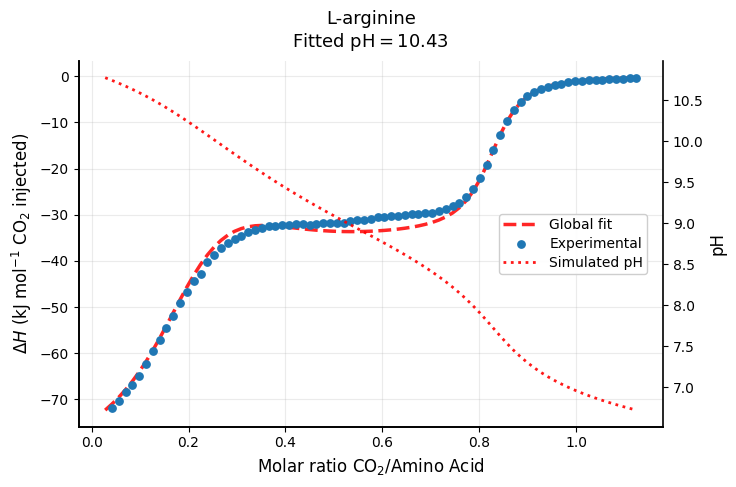

C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\raw_curves\argph11_ITC_with_pH.png
C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\raw_curves\argph11_ITC_with_pH.pdf


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ==========================================================
# INPUT
# ==========================================================

sim_file = (
r"C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\raw_curves\CO2ArgpH11DP33v1_simulated_curve.csv"
)

fit_file = (
r"C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\raw_curves\CO2ArgpH11DP33v1_fit_vs_exp.csv"
)

save_dir = (
r"C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\ITC\raw_curves"
)

save_name = (
"argph11_ITC_with_pH"
)

# ==========================================================
# MANUAL FITTED pH
# ==========================================================

fitted_pH = 10.43
# ==========================================================
# LOAD
# ==========================================================

sim = pd.read_csv(sim_file)

fit = pd.read_csv(fit_file)


# ==========================================================
# MOLAR RATIO
# (match ITC fitter exactly)
# ==========================================================

mr_dense = sim[
    "theta"
].to_numpy()

subsample = int(
    round(
        len(sim)
        /
        len(fit)
    )
)

mr_match = mr_dense[
    subsample-1::subsample
]

skip = 1

n = min(

    len(mr_match) - skip,

    len(fit) - skip
)

mr_exp = mr_match[
    skip:
    skip+n
]

q_exp = fit[
    "q_exp_kJ_per_mol"
].to_numpy()[
    skip:
    skip+n
]
# ==========================================================
# GLOBAL STYLE
# ==========================================================

plt.rcParams.update({

    "font.size":11,

    "axes.linewidth":1.2,

    "axes.labelsize":12,

    "axes.titlesize":13,

    "xtick.labelsize":10,

    "ytick.labelsize":10,

    "legend.fontsize":10
})


# ==========================================================
# FIGURE
# ==========================================================

fig = plt.figure(
    figsize=(7.5,5.0)
)

ax = fig.add_subplot(111)

ax_ph = ax.twinx()


# ==========================================================
# FIT CURVE
# ==========================================================

ax.plot(

    mr_dense,

    sim["q_sim_kJ_per_mol"],

    color="red",

    lw=2.5,

    ls="--",

    alpha=0.85,

    zorder=10,

    label="Global fit"
)


# ==========================================================
# RAW DATA
# ==========================================================

ax.scatter(

    mr_exp,

    q_exp,

    s=28,

    zorder=20,

    label="Experimental"
)

# ==========================================================
# pH OVERLAY
# ==========================================================

valid = np.isfinite(
    sim["pH"]
)

ax_ph.plot(

    mr_dense[valid],

    sim.loc[
        valid,
        "pH"
    ],

    color="red",

    lw=2.0,

    ls=":",

    alpha=0.9,

    label="Simulated pH"
)


# ==========================================================
# LABELS
# ==========================================================

ax.set_xlabel(
    r"Molar ratio CO$_2$/Amino Acid"
)

ax.set_ylabel(
    r"$\Delta H$ (kJ mol$^{-1}$ CO$_2$ injected)"
)

ax_ph.set_ylabel(
    "pH"
)


# ==========================================================
# TITLE
# ==========================================================

ax.set_title(

    rf"L-arginine" "\n"
    rf"$\mathrm{{Fitted\ pH}} = {fitted_pH:.2f}$",

    pad=10
)


# ==========================================================
# GRID
# ==========================================================

ax.grid(
    alpha=0.25
)


# ==========================================================
# LEGEND
# ==========================================================

h1,l1 = ax.get_legend_handles_labels()

h2,l2 = ax_ph.get_legend_handles_labels()

legend = ax.legend(

    h1+h2,

    l1+l2,

    loc="center right",

    bbox_to_anchor=(0.985,0.50),

    handlelength=2.5,

    borderpad=0.30,

    labelspacing=0.35,

    framealpha=0.95
)

legend.set_zorder(
    30
)

# ==========================================================
# CLEAN SPINES
# ==========================================================

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

ax_ph.spines["top"].set_visible(
    False
)


# ==========================================================
# SAVE
# ==========================================================

out_png = (
    Path(save_dir)
    /
    f"{save_name}.png"
)

out_pdf = (
    Path(save_dir)
    /
    f"{save_name}.pdf"
)

plt.tight_layout()

plt.savefig(

    out_png,

    dpi=600,

    bbox_inches="tight"
)

plt.savefig(

    out_pdf,

    bbox_inches="tight"
)

plt.show()

print(out_png)
print(out_pdf)

In [26]:
#### import numpy as np
import matplotlib.pyplot as plt
import copy

from joblib import (
    Parallel,
    delayed
)

SAVED_FIGS = []
# ==========================================================
# MASTER SWEEP CONTROLS
# edit here only
# ==========================================================

sweep = {

    # -------------------------------
    # experiment
    # -------------------------------

    "pH_test": 12.5,

    "n_inj": 1000,


    # -------------------------------
    # sweep variable
    # choose ONE
    # -------------------------------

    "vary": "AA_cell",

    # options:
    #
    # "CO2_syr"
    # "AA_cell"
    # "pH"
    # "logK10_alpha"
    # "logK10_eps"
    # "logK_double"
    # "pKa_alpha"
    # "pKa_eps"
    # "V_inj"


    # -------------------------------
    # sweep range
    # -------------------------------
    
    "min": 1,
    "max": 5,
    "n_points": 10,
    
    "unit_scale": None

}
# ==========================================================
# HEATMAP SETTINGS
# ==========================================================

heatmap = {

    "enable": True,

    "pH_min": 8.0,

    "pH_max": 13.0,

    "pH_points": 5

}
# ==========================================================
# SWEEP OVERRIDES ONLY
# DEFAULT = ITC FIT x0
# ==========================================================

params_override = {

    # ----------------------------------
    # pKa
    # ----------------------------------

    "pKa1": 6.351,

    "pKa2": 10.329,

    "pKa_alpha": 8.95,

    "pKa_eps": 10.53,

    "pKa_cooh": 2.18,


    # ----------------------------------
    # carbamate equilibrium
    # ----------------------------------

    "logK10_alpha": -4.3125,

    "logK10_eps": -3.23429,

    "logK_double": -1.0,


    # ----------------------------------
    # enthalpy
    # used by temperature screen
    # ----------------------------------

    "dH_bicarb": 9.35,

    "dH_carbonate": 14.22,

    "dH_carb_alpha": -33.5938,

    "dH_carb_eps": -24.2857,

    "dH_carb_double": -59.4,

    "dH_prot_alpha": 48.61,

    "dH_prot_eps": 50.0186,

    "dH_cooh": 5.0,

    "dH_prot_double": 0.0,

    "dH_HCl_dilution": 0.0,


    # ----------------------------------
    # switches
    # ----------------------------------

    "use_alpha": True,

    "use_eps": True,

    "use_naoh": True

}


settings_override = {

    "CO2_syr": 33e-3,

    "CO2_contam_frac": 0.0,

    "CO2_cell_init": 0.0e-3,

    "AA_cell": 1e-3,

    "AA_norm": 1e-3,

    "V_cell0": 1.4e-3,

    "V_inj": 10e-6,

    "lock_pKa_sites": False,

    "lock_kcarb_sites": False

}
# ==========================================================
# BUILD SWEEP GRID
# ==========================================================

grid = np.linspace(

    sweep["min"],

    sweep["max"],

    sweep["n_points"]

)


if sweep["unit_scale"] is not None:

    grid *= sweep["unit_scale"]


x_plot = np.copy(
    grid
)


if sweep["unit_scale"] is not None:

    x_plot /= sweep["unit_scale"]


pH_default = sweep[
    "pH_test"
]
# ==========================================================
# LABEL LIBRARY
# ==========================================================

LABELS = {

    "pH":
        "Initial pH",

    "CO2_syr":
        r"Injected [CO$_2$] (mM)",

    "AA_cell":
        r"[AA] (mM)",

    "V_inj":
        r"Injection Volume (µL)",

    "logK10_alpha":
        r"log $K_{\alpha}$",

    "logK10_eps":
        r"log $K_{\varepsilon}$",

    "logK_double":
        r"log $K_{double}$",

    "pKa_alpha":
        r"$pK_a$ α",

    "pKa_eps":
        r"$pK_a$ ε",
    "Temperature":
        r"Temperature (°C)",
}

# ==========================================================
# AVAILABLE SWEEP AXES
# ==========================================================

AXES = [

    "pH",

    "Temperature",

    "CO2_syr",

    "AA_cell",

    "V_inj",

    "logK10_alpha",

    "logK10_eps",

    "logK_double",

    "pKa_alpha",

    "pKa_eps"

]
# ==========================================================
# UNIT CONVERSION LIBRARY
# UI → INTERNAL
# ==========================================================

UNIT_SCALE = {

    "pH": 1.0,

    "CO2_syr": 1e-3,      # mM → M

    "AA_cell": 1e-3,      # mM → M

    "V_inj": 1e-6,        # µL → L

    "logK10_alpha": 1.0,

    "logK10_eps": 1.0,

    "logK_double": 1.0,

    "pKa_alpha": 1.0,

    "pKa_eps": 1.0,
    "Temperature": 1.0,

}
def axis_label(name):

    return LABELS.get(
        name,
        str(name)
    )
# ==========================================================
# DYNAMIC SUBTITLE
# ==========================================================
# ==========================================================
# DYNAMIC SUBTITLE
# ==========================================================

def sweep_subtitle():

    parts = []

    swept = {

        sweep["vary"],

        heatmap.get(
            "y_var",
            None
        )

    }


    # ----------------------------------
    # AA swept → show CO2
    # ----------------------------------

    if (

        "AA_cell" in swept

        and

        "CO2_syr" not in swept

    ):

        parts.append(

            f"Injected [CO$_2$]="
            f"{settings_override['CO2_syr']*1e3:.1f} mM"

        )


    # ----------------------------------
    # CO2 swept → show AA
    # ----------------------------------

    elif (

        "CO2_syr" in swept

        and

        "AA_cell" not in swept

    ):

        parts.append(

            f"[AA]="
            f"{settings_override['AA_cell']*1e3:.1f} mM"

        )


    # ----------------------------------
    # BOTH swept → show pH
    # ----------------------------------

    elif (

        "AA_cell" in swept

        and

        "CO2_syr" in swept

    ):

        parts.append(

            f"Initial pH="
            f"{sweep['pH_test']:.2f}"

        )


    # ----------------------------------
    # neither swept → show both
    # ----------------------------------

    else:

        parts.append(

            f"[AA]="
            f"{settings_override['AA_cell']*1e3:.1f} mM"

        )

        parts.append(

            f"Injected [CO$_2$]="
            f"{settings_override['CO2_syr']*1e3:.1f} mM"

        )


    return "\n" + " | ".join(parts)
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================================
# BUTTON UI
# ==========================================================

load_btn = widgets.Button(
    description="Load",
    button_style="primary",
    icon="play"
)
save_btn = widgets.Button(

    description="Save plots",

    button_style="success",

    icon="save"

)

batch_btn = widgets.Button(

    description="Run Batch",

    button_style="warning",

    icon="layer-group"

)
output = widgets.Output()
SAVE_DIR = r"C:\Users\nicpe\OneDrive - Aarhus universitet\Research\Projects\CPM\CPM Paper\heatmaps"

SAVED_FIGS = []

# ==========================================================
# MOVE YOUR ENTIRE CURRENT SCRIPT INTO HERE
# ==========================================================
# ==========================================================
# ADAPTIVE PEAK SEARCH
# ==========================================================

# ==========================================================
# SINGLE RUN + EARLY PEAK DETECTION
# ==========================================================

def simulate_to_peak(

    pH_start,

    params,

    settings,

    mode="ITC CO2",

    n_max=10000,

    plateau_window=50,

    rel_tol=1e-3

):

    # ==================================================
    # RETRY SIMULATION UP TO 5 TIMES
    # ==================================================
    
    sim = None
    
    for attempt in range(2):
    
        sim = simulate(
    
            pH_start=pH_start,
    
            n_inj=n_max,
    
            mode=mode,
    
            params=params,
    
            settings=settings
    
        )
    
        if sim is not None:
    
            if attempt > 0:
    
                print(
                    f"Recovered after {attempt+1} attempts"
                )
    
            break
    
    
        # -----------------------------------
        # perturb initial pH slightly
        # -----------------------------------
    
        pH_start += np.random.uniform(
    
            -0.05,
    
            0.05
    
        )
    
    
    if sim is None:
    
        print(
    
            f"Skipped point "
    
            f"(pH={pH_start:.2f}, "
    
            f"AA={settings['AA_cell']*1e3:.2f} mM)"
    
        )
    
        return None


    capture = np.asarray(

        sim[
            "capture_total"
        ]

    )


    running_peak = np.maximum.accumulate(
        capture
    )


    # --------------------------------------------------
    # detect first stable peak
    # --------------------------------------------------

    stop_idx = len(
        capture
    ) - 1


    for i in range(

        plateau_window,

        len(capture)

    ):

        recent = running_peak[

            i-plateau_window:i

        ]


        if (

            np.nanmax(
                recent
            )

            -

            np.nanmin(
                recent
            )

        ) < (

            rel_tol

            *

            max(

                1e-12,

                running_peak[i]

            )

        ):

            stop_idx = i

            break


    # --------------------------------------------------
    # truncate arrays safely
    # --------------------------------------------------
    
    for k, v in sim.items():
    
        if isinstance(v, list):
    
            if len(v) > stop_idx:
    
                sim[k] = v[:stop_idx+1]
    
        elif isinstance(v, np.ndarray):
    
            # skip scalar arrays
            if v.ndim > 0:
    
                if v.shape[0] > stop_idx:
    
                    sim[k] = v[:stop_idx+1]


    return sim
# ==========================================================
# INTERPOLATE FAILED HEATMAP POINTS
# ==========================================================
# ==========================================================
# REJECT OUTLIERS + INTERPOLATE (2 PASSES)
# ==========================================================

def fill_nan_heatmap(

    arr,

    max_drop=0.5,

    passes=3

):

    arr = arr.copy()


    for _ in range(passes):

        # ----------------------------------
        # detect suspicious low outliers
        # ----------------------------------

        rejected = 0


        for r in range(arr.shape[0]):

            for c in range(arr.shape[1]):


                val = arr[r, c]


                if not np.isfinite(val):

                    continue


                r0 = max(0, r-1)
                r1 = min(arr.shape[0], r+2)

                c0 = max(0, c-1)
                c1 = min(arr.shape[1], c+2)


                neigh = arr[r0:r1, c0:c1]


                neigh = neigh[

                    np.isfinite(
                        neigh
                    )

                ]


                if len(neigh) < 5:

                    continue


                med = np.median(
                    neigh
                )


                if (

                    val

                    <

                    med * max_drop

                ):

                    arr[r, c] = np.nan

                    rejected += 1


        # ----------------------------------
        # interpolate rows
        # ----------------------------------

        for r in range(arr.shape[0]):

            row = arr[r]

            good = np.isfinite(row)

            if good.sum() >= 2:

                row[~good] = np.interp(

                    np.flatnonzero(~good),

                    np.flatnonzero(good),

                    row[good]

                )

                arr[r] = row


        # ----------------------------------
        # interpolate columns
        # ----------------------------------

        for c in range(arr.shape[1]):

            col = arr[:, c]

            good = np.isfinite(col)

            if good.sum() >= 2:

                col[~good] = np.interp(

                    np.flatnonzero(~good),

                    np.flatnonzero(good),

                    col[good]

                )

                arr[:, c] = col


        print(
            f"Repair pass rejected {rejected} points"
        )


    return arr
# ==========================================================
# APPLY TEMPERATURE TO EQUILIBRIA
# ==========================================================

R = 8.314
T_REF = 298.15


def apply_temperature(
    p,
    T_C
):

    T = T_C + 273.15

    p = copy.deepcopy(
        p
    )


    # ----------------------------------
    # carbamate K
    # reference = ITC x0 values
    # ----------------------------------
    
    K_REF = {
    
        "logK10_alpha": -4.3125,
    
        "logK10_eps": -3.23429
    
    }
    
    for K,dH in [
    
        (
    
            "logK10_alpha",
    
            "dH_carb_alpha"
    
        ),
    
        (
    
            "logK10_eps",
    
            "dH_carb_eps"
    
        )
    
    ]:
    
        logK_ref = K_REF[K]
    
        dH_kJ = p[dH]
    
    
        p[K] = (
    
            logK_ref
    
            -
    
            (
    
                dH_kJ
    
                *
    
                1000
    
            )
    
            /
    
            (
    
                2.303
    
                *
    
                R
    
            )
    
            *
    
            (
    
                1/T
    
                -
    
                1/T_REF
    
            )
    
        )


    # ----------------------------------
    # pKa
    # ----------------------------------

    for pKa,dH in [

        (

            "pKa_alpha",

            "dH_prot_alpha"

        ),

        (

            "pKa_eps",

            "dH_prot_eps"

        ),

        (

            "pKa_cooh",

            "dH_cooh"

        ),

        (

            "pKa1",

            "dH_bicarb"

        ),

        (

            "pKa2",

            "dH_carbonate"

        )

    ]:

        p[pKa] += (

            (

                p[dH]

                *

                1000

            )

            /

            (

                2.303

                *

                R

            )

        ) * (

            1/T

            -

            1/T_REF

        )

    return p 
    # ==========================================================
# REGISTER FIGURE FOR SAVING
# ==========================================================

SAVE_TAGS = []


def register_fig(fig, tag):

    global SAVED_FIGS
    global SAVE_TAGS

    SAVED_FIGS.append(
        fig
    )

    SAVE_TAGS.append(
        tag
    )
# ==========================================================
# ADAPTIVE COLORBAR UNITS
# mol/L → mM → µM → nM
# ==========================================================

from matplotlib.ticker import FuncFormatter


def adaptive_cbar(cbar, data):

    vmax = np.nanmax(data)


    if vmax >= 1e-3:

        scale = 1e3
        unit = "mM"

    elif vmax >= 1e-6:

        scale = 1e6
        unit = "µM"

    elif vmax >= 1e-9:

        scale = 1e9
        unit = "nM"

    else:

        scale = 1.0
        unit = "M"


    cbar.formatter = FuncFormatter(

        lambda x, pos:

        f"{x*scale:.0f}"

    )

    cbar.update_ticks()

    return unit
# ==========================================================
# SINGLE POINT WORKER
# ==========================================================

def run_point(job):

    iy, i, y_value, value = job


    s_sample = copy.deepcopy(
        settings
    )

    p_local = copy.deepcopy(
        params
    )

    s_sample.update(
        settings_override
    )

    p_local.update(
        params_override
    )


    pH_run = sweep["pH_test"]


    # -----------------------
    # temperature
    # -----------------------

    if sweep["vary"] == "Temperature":

        p_local = apply_temperature(
            p_local,
            value
        )


    if heatmap["y_var"] == "Temperature":

        p_local = apply_temperature(
            p_local,
            y_value
        )


    # -----------------------
    # X
    # -----------------------

    if sweep["vary"] == "pH":

        pH_run = value

    elif sweep["vary"] in s_sample:

        s_sample[
            sweep["vary"]
        ] = value

    elif sweep["vary"] in p_local:

        p_local[
            sweep["vary"]
        ] = value


    # -----------------------
    # Y
    # -----------------------

    if heatmap["y_var"] == "pH":

        pH_run = y_value

    elif heatmap["y_var"] in s_sample:

        s_sample[
            heatmap["y_var"]
        ] = y_value

    elif heatmap["y_var"] in p_local:

        p_local[
            heatmap["y_var"]
        ] = y_value


    s_blank = copy.deepcopy(
        s_sample
    )

    s_blank["AA_cell"] = 0


    sim_sample = simulate_to_peak(

        pH_start=pH_run,

        params=p_local,

        settings=s_sample

    )

    sim_blank = simulate_to_peak(

        pH_start=pH_run,

        params=p_local,

        settings=s_blank

    )


    if (

        sim_sample is None

        or

        sim_blank is None

    ):

        return (
            iy,
            i,
            None
        )


    sample_max = np.nanmax(

        sim_sample[
            "capture_total"
        ]

    )

    blank_max = np.nanmax(

        sim_blank[
            "capture_total"
        ]

    )

    carb_max = np.nanmax(

        sim_sample[
            "carb_total"
        ]

    )


    return (
    
        iy,
        i,
    
        {
    
            "sample": sample_max,
    
            "blank": blank_max,
    
            "gain": sample_max-blank_max,
    
            "carb": carb_max,
    
            "kalpha": p_local["logK10_alpha"],
    
            "keps": p_local["logK10_eps"],
    
            "sim_sample": sim_sample,
    
            "sim_blank": sim_blank
    
        }
    
    )
def run_sweep():

    # ======================================================
    # STORAGE
    # ======================================================
    
    if heatmap["enable"]:
    
        capture_heat = np.full(
    
            (
    
                heatmap["pH_points"],
    
                len(grid)
    
            ),
    
            np.nan
    
        )
    
        sample_heat = np.full(
    
            (
    
                heatmap["pH_points"],
    
                len(grid)
    
            ),
    
            np.nan
    
        )
    
        blank_heat = np.full(
    
            (
    
                heatmap["pH_points"],
    
                len(grid)
    
            ),
    
            np.nan
    
        )
        carb_heat = np.full_like(
            capture_heat,
            np.nan
        )
        kalpha_heat = np.full_like(
            capture_heat,
            np.nan
        )
        
        keps_heat = np.full_like(
            capture_heat,
            np.nan
        )
        y_scale = UNIT_SCALE.get(
        
            heatmap.get(
        
                "y_var",
        
                "pH"
        
            ),
        
            1.0
        
        )
        
        
        y_grid = (
        
            np.linspace(
        
                heatmap["pH_min"],
        
                heatmap["pH_max"],
        
                heatmap["pH_points"]
        
            )
        
            *
        
            y_scale
        
        )
        
        
        y_name = heatmap.get(
        
            "y_var",
        
            "pH"
        
        )
        
        
        pH_grid = y_grid
    
    else:
    
        pH_grid = grid
    
        capture_heat = np.full(
    
            len(pH_grid),
    
            np.nan
    
        )
    
        sample_heat = np.full(
    
            len(pH_grid),
    
            np.nan
    
        )
    
        blank_heat = np.full(
    
            len(pH_grid),
    
            np.nan
    
        )
        carb_heat = np.full(
        
            len(pH_grid),
        
            np.nan
        
        )  
    
    corner_sims = {}
    
    
    # ======================================================
    # SWEEP
    # ======================================================
    
    if heatmap["enable"]:
    
        # --------------------------------------------------
        # BUILD JOBS
        # --------------------------------------------------
    
        jobs = [
    
            (
    
                iy,
    
                i,
    
                y,
    
                x
    
            )
    
            for iy, y in enumerate(
    
                y_grid
    
            )
    
            for i, x in enumerate(
    
                grid
    
            )
    
        ]
    
    
        print()
    
        print(
    
            f"Submitting "
    
            f"{len(jobs)} "
    
            f"simulations"
    
        )
    
    
        # --------------------------------------------------
        # PARALLEL
        # --------------------------------------------------
    
        from joblib import (
    
            Parallel,
    
            delayed
    
        )
    
        import time
    
    
        N_WORKERS = min(
    
            10,
    
            len(jobs)
    
        )
    
    
        print(
    
            f"Workers = "
    
            f"{N_WORKERS}"
    
        )
    
    
        t0 = time.time()
    
    
        results = Parallel(
    
            n_jobs=N_WORKERS,
    
            backend="loky",
    
            verbose=10,
    
            return_as="list"
    
        )(
    
            delayed(
    
                run_point
    
            )(job)
    
            for job in jobs
    
        )
    
    
        print()
    
        print(
    
            f"Elapsed "
    
            f"{time.time()-t0:.1f}s"
    
        )
    
    
        # --------------------------------------------------
        # STORE
        # --------------------------------------------------
    
        corner_positions = {
    
            (0,0),
    
            (
    
                0,
    
                len(grid)-1
    
            ),
    
            (
    
                len(y_grid)-1,
    
                0
    
            ),
    
            (
    
                len(y_grid)-1,
    
                len(grid)-1
    
            )
    
        }
    
    
        completed = 0
    
    
        for result in results:
    
    
            iy, i, res = result
    
    
            completed += 1
    
    
            if (
    
                completed % 10 == 0
    
                or
    
                completed == len(results)
    
            ):
    
                print(
    
                    f"{completed}/"
    
                    f"{len(results)}"
    
                )
    
    
            if res is None:
    
                continue
    
    
            sample_heat[
    
                iy,
    
                i
    
            ] = res[
    
                "sample"
    
            ]
    
    
            blank_heat[
    
                iy,
    
                i
    
            ] = res[
    
                "blank"
    
            ]
    
    
            capture_heat[
    
                iy,
    
                i
    
            ] = res[
    
                "gain"
    
            ]
    
    
            carb_heat[
    
                iy,
    
                i
    
            ] = res[
    
                "carb"
    
            ]
    
    
            kalpha_heat[
    
                iy,
    
                i
    
            ] = res[
    
                "kalpha"
    
            ]
    
    
            keps_heat[
    
                iy,
    
                i
    
            ] = res[
    
                "keps"
    
            ]
    
    
            if (
    
                iy,
    
                i
    
            ) in corner_positions:
    
    
                corner_sims[
    
                    (
    
                        iy,
    
                        i,
    
                        "sample"
    
                    )
    
                ] = res[
    
                    "sim_sample"
    
                ]
    
    
                corner_sims[
    
                    (
    
                        iy,
    
                        i,
    
                        "blank"
    
                    )
    
                ] = res[
    
                    "sim_blank"
    
                ]
    
    
        print()
    # ==========================================================
    # PLOTTING
    # ==========================================================
    
    selected = {
    
        "capture": show_capture.value,
    
        "saturation": show_saturation.value,
    
        "amine": show_amine.value
    
    }
    
    # ======================================================
    # HEATMAP MODE
    # ======================================================
    
    if heatmap["enable"]:
            
        sample_map = fill_nan_heatmap(
            sample_heat
        )
        
        blank_map = fill_nan_heatmap(
            blank_heat
        )
        
        delta_map = fill_nan_heatmap(
            capture_heat
        )
        
        carb_heat = fill_nan_heatmap(
            carb_heat
        )
        
        print()
        
        print(
            "Interpolated failed heatmap points"
        )
        n_missing = np.isnan(capture_heat).sum()
        
        print(
            f"Filled {n_missing} failed points"
        )
        fig, axes = plt.subplots(
    
            1,
    
            3,
    
            figsize=(18,7),
    
            constrained_layout=True
    
        )
    
    
        maps = [
        
            (
        
                sample_map,
        
                "Total CO$_2$ Retention"
        
            ),
        
            (
        
                blank_map,
        
                "NaOH-mediated CO$_2$ Retention"
        
            ),
        
            (
        
                delta_map,
        
                "Amine-mediated CO$_2$ Retention"
        
            )
        
        ]
    
        for ax,(data,title) in zip(
    
            axes,
    
            maps
    
        ):
    
    
            im = ax.imshow(
            
                data,
            
                origin="lower",
            
                aspect="auto",
            
                extent=[
            
                    x_plot.min(),
            
                    x_plot.max(),
            
                    heatmap["pH_min"],
            
                    heatmap["pH_max"]
            
                ]
            
            )
    
    
            cbar = plt.colorbar(
            
                im,
            
                ax=ax,
            
                shrink=0.9
            
            )
            
            unit = adaptive_cbar(
            
                cbar,
            
                data
            
            )
            
            cbar.set_label(
            
                rf"Max retained CO$_2$ ({unit})"
            
            )
    
    
            ax.set_title(
                title
                +
                sweep_subtitle()
            )
    
    
            ax.set_xlabel(
            
                axis_label(
            
                    sweep["vary"]
            
                )
            
            )
            
            
            ax.set_ylabel(
            
                axis_label(
            
                    heatmap.get(
            
                        "y_var",
            
                        "pH"
            
                    )
            
                )
            
            )
    
    
        register_fig(
        
            plt.gcf(),
        
            "capture"
        
        )
        
        plt.show()
    else:
    
        delta = capture_heat
    
    
        fig, ax = plt.subplots(
    
            figsize=(8,6)
    
        )
    
            
        ax.plot(
            x_plot,
            delta,
            
            marker="o",
    
            linewidth=3
    
        )
    
    
        ymax = np.nanmax(
    
            delta
    
        )
    
    
        ax.set_ylim(
    
            0,
    
            ymax*1.08
    
        )
    
    
        ax.set_xlabel(
        
            axis_label(
                sweep["vary"]
            )
        
        )
    
    
        ax.set_ylabel(
    
            r"Max extra retained CO$_2$"
    
        )
    
    
        ax.set_title(
            f"Δ CO$_2$ Capture\n"
            +
            sweep_subtitle()
        
        )
    
    
        ax.grid(
    
            alpha=0.25
    
        )
    
    
        plt.tight_layout()
    
        SAVED_FIGS.append(
            plt.gcf()
        )
        
        plt.show()
    # ==========================================================
    # FIGURE 2
    # SATURATION CORNERS
    # ==========================================================
    
    if selected["saturation"]:
    
        fig, axes = plt.subplots(
    
            2,
    
            2,
    
            figsize=(12,10)
    
        )
    
    
        positions = [
    
            (
    
                0,
    
                0,
    
                "Low pH / Low"
    
            ),
    
            (
    
                0,
    
                len(grid)-1,
    
                "Low pH / High"
    
            ),
    
            (
    
                len(pH_grid)-1,
    
                0,
    
                "High pH / Low"
    
            ),
    
            (
    
                len(pH_grid)-1,
    
                len(grid)-1,
    
                "High pH / High"
    
            )
    
        ]
    
    
        for ax,(ipH,i,title) in zip(
    
            axes.flat,
    
            positions
    
        ):
    
            for typ,style in [
    
                (
    
                    "sample",
    
                    "-"
    
                ),
    
                (
    
                    "blank",
    
                    "--"
    
                )
    
            ]:
    
                sim = corner_sims.get(
    
                    (
    
                        ipH,
    
                        i,
    
                        typ
    
                    )
    
                )
    
    
                if sim is None:
    
                    continue
    
    
                n = min(
    
                    len(
                        sim[
                            "theta"
                        ]
                    ),
    
                    len(
                        sim[
                            "capture_total"
                        ]
                    )
    
                )
    
    
                theta = np.asarray(
    
                    sim[
                        "theta"
                    ][:n]
    
                )
    
    
                capture = np.asarray(
    
                    sim[
                        "capture_total"
                    ][:n]
    
                )
    
    
                ax.plot(
    
                    theta,
    
                    capture*1e3,
    
                    style,
    
                    linewidth=2.5,
    
                    label=typ
    
                )
    
    
            ax.set_title(
    
                (
    
                    title
    
                    +
    
                    "\n"
    
                    +
    
                    f"{axis_label(heatmap['y_var'])}={pH_grid[ipH]:.2f}"
    
                    +
    
                    ", "
    
                    +
    
                    f"{axis_label(sweep['vary'])}={x_plot[i]:.2f}"
    
                )
    
            )
    
            ax.set_xlabel(
    
                "Molar ratio"
    
            )
    
            ax.set_ylabel(
    
                "Captured CO$_2$ (mM)"
    
            )
    
            ax.grid(
    
                alpha=0.25
    
            )
    
            ax.legend()
    
    
        plt.tight_layout()
    
        register_fig(
        
            plt.gcf(),
        
            "saturation"
        
        )
        
        plt.show()
                
    # ==========================================================
    # FIGURE 3
    # CARBAMATE ONLY
    # ==========================================================
    
    if selected["amine"]:
    
        if heatmap["enable"]:
    
            fig, ax = plt.subplots(
                figsize=(8,7)
            )
    
            im = ax.imshow(
            
                fill_nan_heatmap(
                    carb_heat
                ),
    
                origin="lower",
    
                aspect="auto",
    
                extent=[
    
                    x_plot.min(),
    
                    x_plot.max(),
    
                    heatmap["pH_min"],
    
                    heatmap["pH_max"]
    
                ]
    
            )
    
            cbar = plt.colorbar(
                im,
                ax=ax
            )
            
            unit = adaptive_cbar(
            
                cbar,
            
                carb_heat
            
            )
            
            cbar.set_label(
            
                rf"Max CO$_2$ as Carbamate ({unit})"
            
            )
    
            ax.set_title(
                "Carbamate Contribution"
                +
                sweep_subtitle()
            )
    
            ax.set_xlabel(
                axis_label(
                    sweep["vary"]
                )
            )
    
            ax.set_ylabel(
                axis_label(
                    heatmap["y_var"]
                )
            )
    
        else:
    
            fig, ax = plt.subplots(
                figsize=(8,5)
            )
    
            ax.plot(
    
                x_plot,
    
                carb_heat * 1e3,
    
                marker="o",
    
                linewidth=3
    
            )
    
            ax.set_xlabel(
                axis_label(
                    sweep["vary"]
                )
            )
    
            ax.set_ylabel(
                r"Max carbamate retained CO$_2$ (mM)"
            )
    
            ax.set_title(
                "Carbamate Contribution"
                +
                sweep_subtitle()
            )
    
            ax.grid(
                alpha=0.25
            )
    
        plt.tight_layout()
    
        register_fig(
        
            plt.gcf(),
        
            "carbamate"
        
        )
        
        plt.show()
    # ======================================================
    # FIGURE 4
    # KCARB VS TEMPERATURE
    # ======================================================
    
    if (
    
        sweep["vary"] == "Temperature"
    
    ):
    
        fig, ax = plt.subplots(
    
            figsize=(8,6)
    
        )
    
        if heatmap["enable"]:
    
            kalpha = np.nanmean(
    
                kalpha_heat,
    
                axis=0
    
            )
    
            keps = np.nanmean(
    
                keps_heat,
    
                axis=0
    
            )
    
        else:
    
            kalpha = kalpha_heat
    
            keps = keps_heat
    
    
        ax.plot(
        
            x_plot,
        
            kalpha,
        
            linewidth=3,
        
            label=r"$K_{carb,\alpha}$"
        
        )
        
        ax.plot(
        
            x_plot,
        
            keps,
        
            linewidth=3,
        
            label=r"$K_{carb,\varepsilon}$"
        
        )
    
        ax.set_xlabel(
    
            "Temperature (°C)"
    
        )
    
        ax.set_ylabel(
    
            r"Apparent log $K_{carb}$"
    
        )
    
        ax.set_title(
    
            "Temperature Dependence of Carbamate Equilibrium"
    
        )
    
        ax.grid(
    
            alpha=0.25
    
        )
    
        ax.legend()
    
        register_fig(
        
            plt.gcf(),
        
            "kcarb"
        
        )
            
        plt.show()
    return {
    
        "sample":
    
            sample_map,
    
        "blank":
    
            blank_map,
    
        "capture":
    
            delta_map,
    
        "carb":
    
            carb_heat,
    
        "y":
    
            y_grid
    
    }

# ==========================================================
# CALLBACK
# ==========================================================
import os

# ==========================================================
# SAVE ALL OPEN FIGURES
# ==========================================================
def save_all_figures():

    global SAVE_TAGS

    os.makedirs(

        SAVE_DIR,

        exist_ok=True

    )


    KEEP = {

        "capture",

        "carbamate",

        "kcarb"

    }


    saved = 0


    for i,(fig,tag) in enumerate(

        zip(

            SAVED_FIGS,

            SAVE_TAGS

        ),

        start=1

    ):


        if tag not in KEEP:

            continue


        try:

            title = (

                fig.axes[0]

                .get_title()

            )

        except:

            title = (

                tag

            )


        title = (

            title

            .replace("\n","_")

            .replace("/","-")

            .replace("|","_")

            .replace(":","-")

            [:120]

        )


        png = os.path.join(

            SAVE_DIR,

            f"{i:02d}_{tag}_{title}.png"

        )


        pdf = os.path.join(

            SAVE_DIR,

            f"{i:02d}_{tag}_{title}.pdf"

        )


        fig.savefig(

            png,

            dpi=600,

            bbox_inches="tight"

        )


        fig.savefig(

            pdf,

            bbox_inches="tight"

        )


        saved += 1


    print()

    print(

        f"Saved "

        f"{saved} "

        f"figure(s)"

    )

    print()

    print(
        SAVE_DIR
    )
# ==========================================================
# BATCH HEATMAP AUTOMATION
# ==========================================================

import copy
import os


BATCH = {

    "enable": True,

    "save_root": SAVE_DIR,


    # each dict = one heatmap
    "jobs": [

# Example:
#
# {
#
# "name":"AA_vs_pH",
#
# "x":"AA_cell",
#
# "xmin":1,
#
# "xmax":15,
#
# "xn":20,
#
# "y":"pH",
#
# "ymin":8,
#
# "ymax":13,
#
# "yn":10
#
# },

    ]

}
# ==========================================================
# DEFINE BATCH EXPERIMENTS
# ==========================================================

BATCH["enable"] = False

BATCH["jobs"] = [
{
"name":"Vinj_vs_pH",
"x":"V_inj",
"xmin":2,
"xmax":20,
"xn":30,
"y":"pH",
"ymin":7,
"ymax":13,
"yn":40
},

{
"name":"Vinj_vs_AA",
"x":"V_inj",
"xmin":2,
"xmax":20,
"xn":30,
"y":"AA_cell",
"ymin":1,
"ymax":20,
"yn":40
},

{
"name":"Vinj_vs_CO2",
"x":"V_inj",
"xmin":2,
"xmax":20,
"xn":30,
"y":"CO2_syr",
"ymin":10,
"ymax":100,
"yn":50
},
]
# ==========================================================
# EXPORT TOP 20% OF HEATMAP
# ==========================================================

import pandas as pd


def save_top_heatmap_csv(

    matrix,

    x_vals,

    y_vals,

    folder,

    name,

    value_name

):

    mat = np.asarray(
        matrix
    )


    good = np.isfinite(
        mat
    )


    if good.sum() == 0:

        return


    cutoff = np.nanpercentile(

        mat,

        80

    )


    rows = []


    for iy in range(

        mat.shape[0]

    ):

        for ix in range(

            mat.shape[1]

        ):


            value = mat[
                iy,
                ix
            ]


            if (

                not np.isfinite(
                    value
                )

                or

                value < cutoff

            ):

                continue


            rows.append(

                {

                    "x":

                        float(
                            x_vals[ix]
                        ),

                    "y":

                        float(
                            y_vals[iy]
                        ),

                    value_name:

                        float(
                            value
                        ),

                    value_name+"_mM":

                        float(
                            value
                        )

                        *

                        1e3

                }

            )


    df = pd.DataFrame(
        rows
    )


    df = df.sort_values(

        value_name,

        ascending=False

    )


    csv = os.path.join(

        folder,

        f"{name}.csv"

    )


    df.to_csv(

        csv,

        index=False

    )


    print(

        f"Saved "

        f"{len(df)} "

        f" rows"

    )
def run_batch():

    global SAVE_TAGS
    
    SAVED_FIGS = []
    
    SAVE_TAGS = []
    global SAVE_DIR


    original = {

        "sweep":

            copy.deepcopy(
                sweep
            ),

        "heatmap":

            copy.deepcopy(
                heatmap
            ),

        "save":

            SAVE_DIR

    }


    njobs = len(
        BATCH["jobs"]
    )


    print()

    print(
        f"Running "
        f"{njobs} "
        f"heatmaps"
    )


    for k,job in enumerate(

        BATCH["jobs"],

        start=1

    ):


        print()

        print(
            "="*70
        )

        print(

            f"{k}/{njobs}"

        )

        print(

            job["name"]

        )

        print(
            "="*70
        )


        SAVED_FIGS = []


        sweep["vary"] = job["x"]

        sweep["min"] = job["xmin"]

        sweep["max"] = job["xmax"]

        sweep["n_points"] = job["xn"]


        heatmap["enable"] = True

        heatmap["y_var"] = job["y"]

        heatmap["pH_min"] = job["ymin"]

        heatmap["pH_max"] = job["ymax"]

        heatmap["pH_points"] = job["yn"]


        scale = UNIT_SCALE.get(

            sweep["vary"],

            1

        )


        global grid
        global x_plot


        grid = (

            np.linspace(

                sweep["min"],

                sweep["max"],

                sweep["n_points"]

            )

            *

            scale

        )


        x_plot = np.linspace(

            sweep["min"],

            sweep["max"],

            sweep["n_points"]

        )


        SAVE_DIR = os.path.join(

            BATCH["save_root"],

            job["name"]

        )


        os.makedirs(

            SAVE_DIR,

            exist_ok=True

        )


        result = run_sweep()
        
        save_all_figures()
        
        
        # -------------------------
        # export only saved plots
        # -------------------------
        
        EXPORTS = [
        
            (
                "plot1_total_retention",
        
                result["sample"],
        
                "total_retention"
        
            ),
        
            (
        
                "plot1_naoh_retention",
        
                result["blank"],
        
                "naoh_retention"
        
            ),
        
            (
        
                "plot1_amine_retention",
        
                result["capture"],
        
                "amine_retention"
        
            ),
        
            (
        
                "plot3_carbamate",
        
                result["carb"],
        
                "carbamate"
        
            )
        
        ]
        
        
        for fname,matrix,valname in EXPORTS:
        
            save_top_heatmap_csv(
        
                matrix,
        
                x_plot,
        
                result["y"],
        
                SAVE_DIR,
        
                f"{job['name']}_{fname}",
        
                valname
        
            )


    SAVE_DIR = original["save"]

    sweep.update(
        original["sweep"]
    )

    heatmap.update(
        original["heatmap"]
    )


    print()

    print(
        "Batch complete"
    )
def on_load_clicked(b):
    global SAVED_FIGS
    
    global SAVE_TAGS
    
    SAVED_FIGS = []
    
    SAVE_TAGS = []
    with output:

        clear_output(wait=True)

        print("Running sweep...")
        sweep["vary"] = (
        
            x_var.value
        
        )
        
        heatmap["y_var"] = (
        
            y_var.value
        
        )
        heatmap["enable"] = (
        
            heat_enable.value
        
        )
        
        
        sweep["min"] = (
        
            x_min.value
        
        )
        
        sweep["max"] = (
        
            x_max.value
        
        )
        
        sweep["n_points"] = (
        
            x_points.value
        
        )
        
        
        heatmap["pH_min"] = (
        
            y_min.value
        
        )
        
        heatmap["pH_max"] = (
        
            y_max.value
        
        )
        
        heatmap["pH_points"] = (
        
            y_points.value
        
        )
        
        
        global grid
        global x_plot
        
        
        scale = UNIT_SCALE.get(
        
            sweep["vary"],
        
            1.0
        
        )
        
        
        grid = (
        
            np.linspace(
        
                sweep["min"],
        
                sweep["max"],
        
                sweep["n_points"]
        
            )
        
            *
        
            scale
        
        )
        
        
        x_plot = np.linspace(
        
            sweep["min"],
        
            sweep["max"],
        
            sweep["n_points"]
        
        )
        try:
        
            if BATCH["enable"]:
            
                run_batch()
            
            else:
            
                run_sweep()
        
            print("Done.")
        
        except Exception as e:
        
            print(
        
                f"Error: {e}"
        
            )
def on_save_clicked(b):

    with output:

        save_all_figures()
def on_batch_clicked(b):

    global SAVED_FIGS
    global SAVE_TAGS


    SAVED_FIGS = []

    SAVE_TAGS = []


    with output:

        clear_output(
            wait=True
        )


        print(

            "Running batch..."

        )


        try:

            run_batch()

            print()

            print(

                "Batch complete."

            )

        except Exception as e:

            print(

                f"Batch failed: {e}"

            )
load_btn.on_click(
    on_load_clicked
)
save_btn.on_click(
    on_save_clicked
)
batch_btn.on_click(

    on_batch_clicked

)
# ==========================================================
# PLOT TOGGLES
# ==========================================================

show_capture = widgets.Checkbox(

    value=True,

    description="Capture"

)

show_saturation = widgets.Checkbox(

    value=True,

    description="Saturation"

)

show_amine = widgets.Checkbox(

    value=True,

    description="Amine contribution"

)


plot_toggle = widgets.VBox([

    widgets.HTML(
        "<b>Plots</b>"
    ),

    show_capture,

    show_saturation,

    show_amine

])

output = widgets.Output()
# ==========================================================
# HEATMAP CONTROLS
# ==========================================================

heat_enable = widgets.Checkbox(

    value=heatmap["enable"],

    description="Heatmap"

)

x_var = widgets.Dropdown(

    options=AXES,

    value=sweep["vary"],

    description="X"

)


y_var = widgets.Dropdown(

    options=AXES,

    value="pH",

    description="Y"

)
x_min = widgets.FloatText(

    value=sweep["min"],

    description="X min",

    layout=widgets.Layout(width="180px")

)


x_max = widgets.FloatText(

    value=sweep["max"],

    description="X max",

    layout=widgets.Layout(width="180px")

)


x_points = widgets.IntText(

    value=sweep["n_points"],

    description="X points",

    layout=widgets.Layout(width="180px")

)


y_min = widgets.FloatText(

    value=heatmap["pH_min"],

    description="Y min",

    layout=widgets.Layout(width="180px")

)


y_max = widgets.FloatText(

    value=heatmap["pH_max"],

    description="Y max",

    layout=widgets.Layout(width="180px")

)


y_points = widgets.IntText(

    value=heatmap["pH_points"],

    description="Y points",

    layout=widgets.Layout(width="180px")

)


heat_controls = widgets.VBox([

    widgets.HTML(

        "<b>Heatmap axes</b>"

    ),

    widgets.HBox([

        x_var,

        x_min,

        x_max,

        x_points

    ]),

    widgets.HBox([

        y_var,

        y_min,

        y_max,

        y_points

    ]),

    heat_enable

])
display(

    widgets.VBox([

        plot_toggle,

        heat_controls,

        load_btn,
        save_btn,
        batch_btn,

        output

    ])

)


Saved: itc_ph_nmr_plot.png


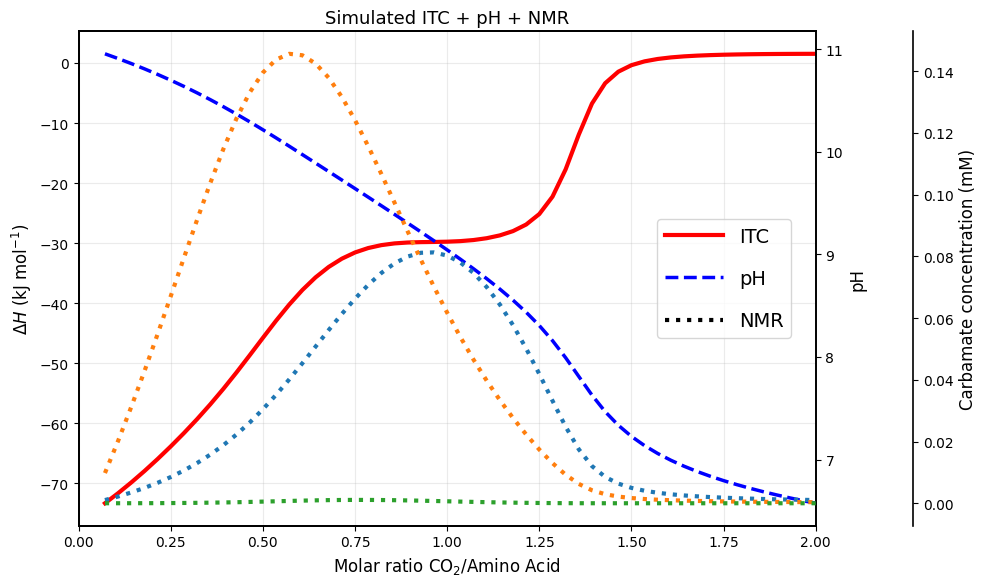

In [59]:
# ============================================================
# pH 11 → ITC + pH + TRUE NMR
# x = molar ratio
# ============================================================

p = params.copy()

# ------------------------------------------------------------
# expose carbamate constants
# ------------------------------------------------------------

p["logK10_alpha"] = -4.30
p["logK10_eps"]   = -3.20
p["logK_double"]  = -1.00

# ------------------------------------------------------------
# run
# ------------------------------------------------------------

sim = simulate(

    pH_start=11.0,

    n_inj=100,

    mode="ITC CO2",

    params=p,

    settings=settings
)

# ------------------------------------------------------------
# arrays
# ------------------------------------------------------------

n = min(

    len(sim["theta"]),

    len(sim["heat"]),

    len(sim["pH"]),

    len(sim["carb_alpha"]),

    len(sim["carb_eps"]),

    len(sim["carb_double"])
)

theta = np.asarray(
    sim["theta"][:n]
)

keep = theta <= 2

theta = theta[keep]

# ------------------------------------------------------------
# ITC
# ------------------------------------------------------------

heat = np.asarray(

    sim["heat"][:n]

)[keep]

# ------------------------------------------------------------
# pH
# ------------------------------------------------------------

pH = np.asarray(

    sim["pH"][:n]

)[keep]

# ------------------------------------------------------------
# TRUE NMR OBSERVABLES
# ------------------------------------------------------------

alpha = (

    np.asarray(

        sim["carb_alpha"][:n]

    )

    * 1000

)[keep]

eps = (

    np.asarray(

        sim["carb_eps"][:n]

    )

    * 1000

)[keep]

double = (

    np.asarray(

        sim["carb_double"][:n]

    )

    * 1000

)[keep]

# ============================================================
# FIGURE
# ============================================================

fig, ax1 = plt.subplots(

    figsize=(10,6)

)

ax2 = ax1.twinx()

ax3 = ax1.twinx()

ax3.spines["right"].set_position(

    ("outward",70)

)

# ------------------------------------------------------------
# ITC
# ------------------------------------------------------------

ax1.plot(

    theta,

    heat,

    lw=3,

    color="red",

    label="ITC"
)

# ------------------------------------------------------------
# pH
# ------------------------------------------------------------

ax2.plot(

    theta,

    pH,

    lw=2.5,

    ls="--",

    color="blue",

    label="pH"
)

# ------------------------------------------------------------
# NMR
# (all same style, different from ITC and pH)
# ------------------------------------------------------------

nmr_style = ":"

ax3.plot(

    theta,

    alpha,

    lw=3,

    ls=nmr_style,

    label="α carbamate"
)

ax3.plot(

    theta,

    eps,

    lw=3,

    ls=nmr_style,

    label="ε carbamate"
)

ax3.plot(

    theta,

    double,

    lw=3,

    ls=nmr_style,

    label="double carbamate"
)

# ============================================================
# labels
# ============================================================

ax1.set_xlim(

    0,

    2

)

ax1.set_xlabel(

    r"Molar ratio CO$_2$/Amino Acid"

)

ax1.set_ylabel(

    r"$\Delta H$ (kJ mol$^{-1}$)"

)

ax2.set_ylabel(

    "pH"

)

ax3.set_ylabel(

    "Carbamate concentration (mM)"

)

ax1.set_title(

    "Simulated ITC + pH + NMR"

)

ax1.grid(

    alpha=0.25
)

# ------------------------------------------------------------
# legend
# ------------------------------------------------------------

from matplotlib.lines import Line2D

legend_handles = [

    Line2D(
        [0],[0],

        color="red",

        lw=3,

        ls="-",

        label="ITC"
    ),

    Line2D(
        [0],[0],

        color="blue",

        lw=2.5,

        ls="--",

        label="pH"
    ),

    Line2D(
        [0],[0],

        color="black",

        lw=3,

        ls=":",

        label="NMR"
    )
]

ax1.legend(

    handles=legend_handles,

    loc="center right",

    bbox_to_anchor=(0.98,0.5),

    fontsize=14,

    handlelength=3,

    labelspacing=1.2
)
plt.tight_layout()
# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

plt.savefig(

    "itc_ph_nmr_plot.png",

    dpi=600,

    bbox_inches="tight",

    facecolor="white"

)

print(
    "Saved: itc_ph_nmr_plot.png"
)

plt.show()
plt.show()